In [28]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE, AUC, NDCG, Precision, Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR, LightGCN, SVD, MostPop, VAECF
import pandas as pd
import numpy as np
import random
import math
from collections import OrderedDict
import seaborn as sns
import matplotlib.pyplot as plt

In [29]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/ml-100k/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
rating_data = rating_data_pd.to_numpy()
rating_data.__len__()
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,3,881250949
1,1,1,3,891717742
2,2,2,1,878887116
3,3,3,2,880606923
4,4,4,1,886397596
...,...,...,...,...
99282,875,173,3,880175444
99283,708,247,5,879795543
99284,37,982,1,874795795
99285,58,442,2,882399156


In [30]:
df_m = pd.read_csv(
    "./cornac/data_c/ml-100K/u.item",
    sep="|",
    names=[
        "movieID",
        "Name",
        "Date",
        "Video_Date",
        "IMDB_URL",
        "unknown",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ],
    header=None,
    encoding="latin-1",
)
print(df_m.shape)
df_m = df_m[
    [
        "movieID",
        "Action",
        "Adventure",
        "Animation",
        "Children's",
        "Comedy",
        "Crime",
        "Documentary",
        "Drama",
        "Fantasy",
        "Film-Noir",
        "Horror",
        "Musical",
        "Mystery",
        "Romance",
        "Sci-Fi",
        "Thriller",
        "War",
        "Western",
    ]
]

df_movies_mapped = pd.read_csv(
    "./cornac/data_c/ml-100K/i_id_mapping.csv",
    sep="\t",
    names=["movieID", "itemID"],
    header=None,
    encoding="latin-1",
)
movies = pd.merge(df_m, df_movies_mapped, how="inner", on="movieID")
movies

(1682, 24)


,movieID,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,24
1,2,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,147
2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,233
3,4,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,47
4,5,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1344,1592,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1305
1345,1597,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1324
1346,1598,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1319
1347,1615,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1341


In [31]:
movies = movies.drop(columns=["movieID"])

In [32]:
movies = movies.sort_values(by="itemID")

In [33]:
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347


In [34]:

unique_genres = [
    "Action",
    "Thriller",
    "Romance",
    "Western",
    "Children's",
    "Mystery",
    "Fantasy",
    "Film-Noir",
    "Documentary",
    "Comedy",
    "Adventure",
    "Sci-Fi",
    "Horror",
    "Crime",
    "Musical",
    "War",
    "Animation",
    "Drama",
]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()

users = pd.read_csv("./cornac/data_c/ml-100k/u_id_mapping.csv", sep="\t")

users = users.sort_values(by="userID")

users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
user_features_numpy = users.to_numpy()
users

,Gender,userID
0,0,0
1,1,1
2,0,2
3,0,3
4,0,4
...,...,...
938,1,938
939,0,939
940,1,940
941,1,941


In [35]:
def create_genre_column(r):
    all_genres = [g for g in unique_genres if r[g] == 1]
    return "|".join(all_genres)


movies["genres"] = movies.apply(create_genre_column, axis=1)
movies

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,itemID,genres
240,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Comedy
300,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,1,0,0,1,Thriller|Mystery|Film-Noir|Crime
375,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,2,Children's|Comedy
50,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,3,Romance|Western|War|Drama
344,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,4,Crime|Drama
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1248,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1344,Drama
1192,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1345,Comedy
1176,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1346,Drama
1261,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1347,Drama


In [36]:
dataset = rating_data
unique_genres.__len__()

18

In [37]:
# inter_movies
# unique_iids = inter_movies['userID'].unique()
# unique_iids.__len__()
# # movies = movies[movies['itemID'].isin(unique_iids)]
user_features_numpy[:, 0]
# item_features_numpy[0]

array([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,

In [38]:
rating_data_pd

,userID,itemID,Rating,Timestamp
0,0,0,3,881250949
1,1,1,3,891717742
2,2,2,1,878887116
3,3,3,2,880606923
4,4,4,1,886397596
...,...,...,...,...
99282,875,173,3,880175444
99283,708,247,5,879795543
99284,37,982,1,874795795
99285,58,442,2,882399156


In [39]:
alpha_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]


In [40]:

from cornac.models import DNNTSP
from cornac.eval_methods import NextBasketEvaluation

ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0,
    val_size=0.1,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 0],
    item_features=item_features_numpy,
    exclude_unknowns=False,
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
prec = cornac.metrics.Precision(k=50)
hr = cornac.metrics.HitRatio(k=50)
mrr = cornac.metrics.MRR()
map = cornac.metrics.MAP()
f1 = cornac.metrics.FMeasure(k=50)


models = []

alpha_values = [0,0.1,0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,0.99999999999 ]
for i in range(len(alpha_values)):
    # learning
    models.append(
        MF(
            k=20,
            seed=123,
            name=f"a={alpha_values[i]} mf",
            backend="pytorch",
            verbose=True,
            optimizer="adam",batch_size=256,
            alpha=alpha_values[i],
            learning_rate=0.001,
            top_k=50, max_iter=51,
            # early_stopping=True
        )
    )
    

cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50, ndcg_50, auc, prec, hr, mrr, map, f1]
).run()

# - best epoch = 51, stopped epoch = 61
# - best monitored value = 0.041282 (delta = 0.000036)


rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
(array([  0,   0,   0, ..., 942, 942, 942]), array([  0,   1,   2, ..., 880, 632, 261]), array([4., 4., 4., ..., 1., 5., 4.]))
Number of users = 943
Number of items = 1348
Number of ratings = 68674
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
Global mean Imolicit= 1.0
::::::::
OrderedDict([(101, 0), (845, 1), (705, 2), (20, 3), (635, 4), (593, 5), (153, 6), (37, 7), (915, 8), (522, 9), (810, 10), (18, 11), (34, 12), (809, 13), (239, 14), (749, 15), (889, 16), (928, 17), (542, 18), (501, 19), (342, 20), (175, 21), (116, 22), (144, 23), (618, 24), (118, 25), (860, 26), (335, 27), (263, 28), (825, 29), (405, 30), (942, 31), (867, 32), (286, 33), (393, 34), (224, 35), (146, 36), (792, 37), (416, 38), (652, 39), (147, 40), (368, 41), (773, 42), (727, 43), (194, 44), (246, 45), (75, 46), (446, 47), (76, 48), (461, 49), (793, 50), (912, 51), (110, 52), (504, 53), (84, 54), (

100%|██████████| 51/51 [00:06<00:00,  7.53it/s, loss=0.333]


[294.7196044921875, 361.0678405761719, 320.986083984375, 307.817626953125, 280.4860534667969, 350.66461181640625, 298.8372802734375, 303.0100402832031, 280.9540100097656, 325.2540283203125, 339.8428649902344, 310.67205810546875, 310.7219543457031, 307.5111083984375, 257.5977783203125, 335.1020202636719, 280.0852355957031, 309.46307373046875, 288.895751953125, 317.80975341796875, 292.32568359375, 298.1026916503906, 308.71685791015625, 294.02252197265625, 292.5393371582031, 277.7213439941406, 298.2445983886719, 306.4815673828125, 280.97564697265625, 294.1807861328125, 347.7889709472656, 274.00201416015625, 329.1974792480469, 345.2244873046875, 325.98504638671875, 322.4717102050781, 318.4559326171875, 315.2992858886719, 310.25299072265625, 312.83349609375, 300.51885986328125, 297.691162109375, 307.5010681152344, 278.891357421875, 308.2222900390625, 310.82513427734375, 294.1680908203125, 309.798583984375, 257.1056213378906, 286.3899841308594, 295.3870849609375, 256.8753662109375, 282.25555

Ranking: 100%|██████████| 943/943 [00:00<00:00, 2352.51it/s]



[a=0.1 mf] Training started!


...

100%|██████████| 51/51 [03:41<00:00,  4.35s/it, loss=0.734]


[461.963623046875, 508.63177490234375, 480.3770751953125, 471.3555908203125, 451.94287109375, 501.50543212890625, 465.5147705078125, 468.606201171875, 453.24603271484375, 484.5973205566406, 495.4461364746094, 474.6075134277344, 474.6165771484375, 471.99273681640625, 437.0040588378906, 491.41802978515625, 453.5845947265625, 473.7921142578125, 458.90362548828125, 480.7073669433594, 461.702392578125, 466.11358642578125, 474.07745361328125, 462.67822265625, 463.7384338378906, 451.343994140625, 467.18304443359375, 473.35662841796875, 452.5956726074219, 462.125, 502.3179016113281, 450.53704833984375, 487.366943359375, 498.7236328125, 489.10284423828125, 483.8087158203125, 479.014892578125, 479.9476013183594, 475.6590270996094, 479.1739196777344, 470.3836669921875, 467.7713317871094, 474.49591064453125, 451.69610595703125, 477.6470947265625, 475.381103515625, 464.51837158203125, 476.079833984375, 443.63934326171875, 456.5408935546875, 467.1480712890625, 437.3248596191406, 455.0380859375, 481.

Ranking: 100%|██████████| 943/943 [00:00<00:00, 2322.78it/s]



[a=0.4 mf] Training started!


 45%|████▌     | 23/51 [01:46<02:04,  4.46s/it, loss=1.18]

In [17]:
user_ids = users.to_numpy()[:, 1]
item_ids = movies.to_numpy()[:, 2]
item_ids.__len__()

1349

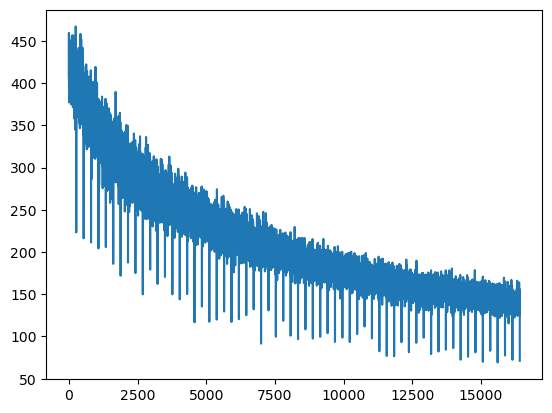

In [14]:
y = [406.215576171875, 459.4427490234375, 427.2496643066406, 416.84429931640625, 394.78375244140625, 451.21923828125, 409.9549255371094, 413.4002380371094, 395.842529296875, 431.47784423828125, 443.58404541015625, 419.95208740234375, 419.9910583496094, 417.1493835449219, 377.2149963378906, 439.348388671875, 395.7764587402344, 419.0196228027344, 402.26239013671875, 426.41363525390625, 405.2242431640625, 410.1225280761719, 418.93853759765625, 406.452392578125, 406.67333984375, 393.498779296875, 410.89599609375, 417.745361328125, 395.4150390625, 406.1576843261719, 450.83038330078125, 391.71307373046875, 434.64251708984375, 447.633056640625, 434.777587890625, 430.02911376953125, 425.4882507324219, 425.08416748046875, 420.55401611328125, 423.7444763183594, 413.8065490722656, 411.18536376953125, 418.91864013671875, 394.1422119140625, 421.22509765625, 420.5373840332031, 407.7632141113281, 420.673095703125, 381.54852294921875, 399.90216064453125, 410.0426330566406, 377.21270751953125, 397.53955078125, 426.4065246582031, 423.5926513671875, 422.8079833984375, 415.5067138671875, 439.58709716796875, 436.0239562988281, 420.5121765136719, 408.83233642578125, 434.2686767578125, 426.59027099609375, 436.63299560546875, 381.3333740234375, 399.635986328125, 423.8334045410156, 448.95184326171875, 421.98553466796875, 400.44549560546875, 401.2041015625, 418.4185485839844, 429.2930908203125, 398.37109375, 391.5937194824219, 431.42486572265625, 404.593994140625, 423.44805908203125, 414.50030517578125, 405.9656982421875, 396.9150390625, 406.8829345703125, 374.9354248046875, 413.05047607421875, 416.4552917480469, 402.137451171875, 429.7381286621094, 436.01513671875, 389.55902099609375, 393.0508728027344, 397.279541015625, 426.34918212890625, 414.8085021972656, 416.25970458984375, 396.0445556640625, 418.70538330078125, 437.04412841796875, 378.74468994140625, 412.56268310546875, 415.54425048828125, 425.5213928222656, 383.9095458984375, 404.1744384765625, 407.681396484375, 388.3013916015625, 399.1734313964844, 404.13348388671875, 430.7477111816406, 456.17095947265625, 408.3122253417969, 451.176025390625, 431.5008544921875, 402.6638488769531, 424.14434814453125, 386.4747314453125, 430.8111572265625, 417.88983154296875, 398.04638671875, 425.8685302734375, 390.2037353515625, 406.07769775390625, 454.5162353515625, 412.2158508300781, 400.345703125, 388.89752197265625, 391.27227783203125, 426.14453125, 439.59918212890625, 402.43988037109375, 377.60357666015625, 418.822265625, 413.51025390625, 436.19915771484375, 403.22900390625, 400.2388000488281, 450.9126892089844, 419.2524108886719, 410.2342224121094, 419.8418884277344, 415.79547119140625, 374.64215087890625, 438.1005859375, 422.0472412109375, 397.48046875, 424.87054443359375, 371.40899658203125, 425.3049011230469, 445.73065185546875, 404.03668212890625, 412.3198547363281, 396.67657470703125, 428.3204345703125, 445.19647216796875, 456.833740234375, 393.0818786621094, 391.3719787597656, 427.87109375, 380.4739990234375, 397.2802734375, 383.22149658203125, 389.7223205566406, 401.4958190917969, 427.6983947753906, 400.57000732421875, 398.9216003417969, 419.36260986328125, 423.4646301269531, 411.0196533203125, 378.8643493652344, 417.023681640625, 414.44281005859375, 381.2709655761719, 415.6070556640625, 393.26361083984375, 422.074462890625, 422.16162109375, 420.98748779296875, 409.7870788574219, 422.8271484375, 416.5448913574219, 412.3148498535156, 370.87335205078125, 442.223388671875, 433.07733154296875, 424.2885437011719, 403.52294921875, 420.1222229003906, 425.57330322265625, 358.067138671875, 395.091064453125, 415.730712890625, 420.4411315917969, 439.4987487792969, 366.7647705078125, 396.82818603515625, 386.24481201171875, 414.97552490234375, 411.9154968261719, 418.08367919921875, 392.45709228515625, 447.30230712890625, 372.15045166015625, 384.74334716796875, 391.3410339355469, 386.4140625, 388.7965393066406, 388.42645263671875, 428.85626220703125, 416.98577880859375, 404.890380859375, 371.6588134765625, 412.5005187988281, 409.528564453125, 417.4810791015625, 392.406982421875, 387.5404968261719, 376.1344909667969, 396.60345458984375, 417.767333984375, 382.184326171875, 398.67254638671875, 405.704345703125, 438.013671875, 397.1592102050781, 398.94403076171875, 417.1664123535156, 433.13177490234375, 422.45556640625, 397.4459228515625, 426.95001220703125, 408.47943115234375, 379.9210205078125, 381.5049743652344, 397.09423828125, 413.04241943359375, 388.52606201171875, 401.7236633300781, 404.88641357421875, 422.5314025878906, 431.956298828125, 410.7221984863281, 344.53692626953125, 428.32000732421875, 432.76336669921875, 381.941162109375, 400.1124267578125, 421.8311767578125, 467.1028137207031, 425.5378723144531, 405.98992919921875, 458.25836181640625, 407.41461181640625, 407.5142822265625, 387.7467346191406, 401.7709655761719, 404.152587890625, 414.7730712890625, 408.35882568359375, 407.45074462890625, 422.16033935546875, 401.8343505859375, 410.4134826660156, 365.45062255859375, 411.48992919921875, 411.746826171875, 401.111572265625, 396.5865783691406, 398.30517578125, 223.3221435546875, 348.7239990234375, 405.85894775390625, 399.36297607421875, 376.0176696777344, 395.3045349121094, 384.2130432128906, 438.2777099609375, 396.6519775390625, 397.127197265625, 386.30950927734375, 367.576416015625, 423.74542236328125, 368.2440185546875, 389.22344970703125, 367.39666748046875, 404.3271484375, 391.30780029296875, 399.32464599609375, 403.1285400390625, 391.7884216308594, 391.79339599609375, 402.4112548828125, 401.235595703125, 389.18853759765625, 378.0838623046875, 394.8631591796875, 411.89447021484375, 395.9825134277344, 400.9342346191406, 400.8502197265625, 396.1654968261719, 397.71942138671875, 426.7173767089844, 408.6891784667969, 422.0418701171875, 367.58343505859375, 392.34136962890625, 362.6339416503906, 392.4912109375, 393.4936828613281, 420.2093505859375, 381.82696533203125, 401.3692932128906, 415.0718994140625, 397.9073486328125, 400.6830749511719, 407.7735290527344, 399.9083251953125, 423.75787353515625, 419.3572692871094, 429.2982177734375, 399.10302734375, 417.63623046875, 384.20220947265625, 399.69586181640625, 395.4432373046875, 367.11346435546875, 403.0081787109375, 374.96502685546875, 416.02362060546875, 386.40826416015625, 432.9984130859375, 408.5013427734375, 379.9532470703125, 413.3118896484375, 378.27386474609375, 388.53277587890625, 406.3346252441406, 410.11614990234375, 421.303955078125, 403.48663330078125, 412.0878601074219, 399.481201171875, 380.7809753417969, 437.7987060546875, 436.0611267089844, 385.3092956542969, 384.1492919921875, 365.8775329589844, 368.16058349609375, 372.0408935546875, 382.76202392578125, 404.824462890625, 392.1546630859375, 398.2763671875, 416.04656982421875, 409.7962341308594, 441.7704772949219, 359.2225341796875, 382.685546875, 361.3841247558594, 399.65667724609375, 375.60980224609375, 396.02789306640625, 379.3045654296875, 391.4917907714844, 377.00408935546875, 429.74639892578125, 389.3830871582031, 427.62945556640625, 395.18682861328125, 390.45001220703125, 357.36004638671875, 412.7728271484375, 395.2541198730469, 377.4341125488281, 389.5107421875, 398.9933166503906, 422.049560546875, 417.5882568359375, 383.419189453125, 364.3763427734375, 373.0139465332031, 413.28515625, 382.9261474609375, 396.7070007324219, 421.54827880859375, 408.3145751953125, 365.53790283203125, 399.6787414550781, 416.5355224609375, 383.703857421875, 351.9408874511719, 361.7593994140625, 398.79473876953125, 385.456298828125, 396.9127197265625, 413.6112060546875, 401.48626708984375, 377.59100341796875, 346.6812744140625, 396.59307861328125, 367.08392333984375, 364.9057922363281, 379.42572021484375, 393.7218017578125, 371.2364501953125, 416.53839111328125, 379.37420654296875, 375.77984619140625, 427.6239013671875, 351.31878662109375, 377.0254211425781, 389.13165283203125, 409.20306396484375, 371.47906494140625, 371.80609130859375, 368.2559509277344, 396.7132568359375, 413.126220703125, 355.71026611328125, 458.2506103515625, 394.04443359375, 359.79888916015625, 401.1636962890625, 352.17840576171875, 390.181396484375, 397.43316650390625, 364.80194091796875, 379.59326171875, 390.94683837890625, 384.99407958984375, 367.9373779296875, 387.1571044921875, 364.35076904296875, 419.5536804199219, 367.32232666015625, 368.02899169921875, 377.2458190917969, 397.64984130859375, 397.04644775390625, 369.95025634765625, 390.46697998046875, 409.66357421875, 368.91558837890625, 370.0946044921875, 376.32025146484375, 408.39764404296875, 384.5787353515625, 451.8687744140625, 405.493408203125, 402.58416748046875, 391.47100830078125, 396.29998779296875, 376.53167724609375, 351.06402587890625, 388.37615966796875, 374.70001220703125, 393.7535400390625, 363.870361328125, 402.4754638671875, 408.61248779296875, 426.7481689453125, 390.889892578125, 392.04156494140625, 387.90643310546875, 386.151611328125, 391.21466064453125, 393.64544677734375, 400.3786315917969, 375.1505126953125, 375.56158447265625, 414.4031677246094, 405.6135559082031, 406.1197204589844, 404.22442626953125, 388.5141296386719, 352.79925537109375, 387.21893310546875, 376.4971008300781, 366.0610656738281, 428.314697265625, 404.6100769042969, 390.29608154296875, 360.1234130859375, 437.0643310546875, 384.06927490234375, 391.41326904296875, 414.0943603515625, 408.34307861328125, 409.6784362792969, 416.056884765625, 427.20220947265625, 371.8835144042969, 363.64984130859375, 393.82098388671875, 365.4009094238281, 370.6354675292969, 387.1380310058594, 384.478515625, 380.8982849121094, 441.83148193359375, 405.970458984375, 395.70855712890625, 382.36212158203125, 376.9881591796875, 422.884521484375, 392.4710388183594, 405.8858947753906, 363.7900390625, 419.84228515625, 419.89202880859375, 353.1020812988281, 386.7425537109375, 381.3564453125, 359.2095031738281, 386.61114501953125, 359.58416748046875, 409.6086730957031, 377.2405090332031, 360.4961242675781, 393.15960693359375, 389.2283020019531, 369.946044921875, 396.212158203125, 420.0163269042969, 385.0632629394531, 354.28485107421875, 400.19659423828125, 359.45477294921875, 393.39422607421875, 395.70660400390625, 362.1365966796875, 402.962158203125, 397.89898681640625, 376.3582763671875, 351.3245849609375, 376.33856201171875, 216.21533203125, 346.35479736328125, 383.3768005371094, 402.5909118652344, 371.43829345703125, 409.7274475097656, 350.57940673828125, 373.0645751953125, 351.3674621582031, 340.41351318359375, 336.8115234375, 412.49066162109375, 360.78387451171875, 403.18365478515625, 372.8826599121094, 401.10693359375, 352.83428955078125, 390.37664794921875, 388.64447021484375, 356.72906494140625, 382.6325988769531, 355.50616455078125, 364.62518310546875, 387.4394226074219, 410.7012634277344, 333.6175537109375, 399.98590087890625, 363.78558349609375, 375.31622314453125, 356.162841796875, 383.21990966796875, 366.484375, 410.4910583496094, 369.7119140625, 356.11248779296875, 375.1392822265625, 389.62872314453125, 382.62847900390625, 348.013427734375, 405.6319274902344, 403.2414245605469, 395.0789489746094, 387.019287109375, 403.1830749511719, 384.3985595703125, 364.00604248046875, 378.1812744140625, 353.46954345703125, 374.4273681640625, 379.1151123046875, 374.1328125, 355.1773681640625, 386.49310302734375, 347.86334228515625, 392.2582702636719, 375.65045166015625, 369.2697448730469, 382.7451171875, 375.035400390625, 380.32293701171875, 379.6972961425781, 360.35589599609375, 341.70147705078125, 383.8837585449219, 349.6571350097656, 360.19769287109375, 359.56683349609375, 389.6146240234375, 387.9584045410156, 351.427001953125, 365.7305603027344, 370.75775146484375, 390.92340087890625, 357.47369384765625, 362.3814697265625, 376.364501953125, 363.9211730957031, 385.66357421875, 375.6982421875, 352.123779296875, 360.9109191894531, 394.1947326660156, 357.4407958984375, 387.450439453125, 345.0531311035156, 372.7110595703125, 355.5375061035156, 379.4717102050781, 371.9635314941406, 335.4074401855469, 357.2108154296875, 381.4402770996094, 406.8712463378906, 422.2729187011719, 386.7346496582031, 352.10504150390625, 327.84552001953125, 370.28924560546875, 338.37359619140625, 367.347412109375, 399.52587890625, 375.57989501953125, 412.0086669921875, 383.7706298828125, 391.82720947265625, 364.080322265625, 362.4446105957031, 379.380859375, 376.96337890625, 378.03265380859375, 387.02020263671875, 361.50469970703125, 381.94085693359375, 371.0702209472656, 321.58148193359375, 384.07635498046875, 362.52398681640625, 351.75274658203125, 366.28057861328125, 353.1432189941406, 353.59716796875, 387.597412109375, 375.75689697265625, 374.37957763671875, 413.98858642578125, 370.16607666015625, 352.12255859375, 383.03411865234375, 404.237060546875, 357.7167663574219, 372.451904296875, 352.1557312011719, 370.9407958984375, 371.3627624511719, 368.97320556640625, 387.66766357421875, 360.388916015625, 341.4377746582031, 378.98101806640625, 394.7642822265625, 341.7200012207031, 389.13165283203125, 341.877197265625, 352.033447265625, 372.6080322265625, 349.25787353515625, 352.5420837402344, 351.39263916015625, 338.0296630859375, 389.38372802734375, 359.6869812011719, 354.54266357421875, 378.646240234375, 383.5516052246094, 390.77362060546875, 348.26654052734375, 362.7904052734375, 364.11627197265625, 380.98345947265625, 331.84881591796875, 383.5677795410156, 347.10748291015625, 381.346923828125, 379.99114990234375, 326.65399169921875, 365.0167236328125, 362.1314697265625, 352.9967041015625, 324.19805908203125, 356.91473388671875, 389.98583984375, 384.18914794921875, 373.2408142089844, 379.82464599609375, 370.56903076171875, 359.85137939453125, 372.91790771484375, 364.0528564453125, 388.48358154296875, 350.499267578125, 361.039794921875, 370.2583312988281, 340.2937316894531, 358.26361083984375, 367.22314453125, 347.4039306640625, 356.66180419921875, 352.2470397949219, 398.32568359375, 374.6563720703125, 364.6294860839844, 370.59783935546875, 354.11181640625, 349.54412841796875, 350.47540283203125, 401.2012939453125, 407.7779541015625, 349.922119140625, 355.9354248046875, 349.58160400390625, 326.9773864746094, 389.960693359375, 340.96160888671875, 355.4500732421875, 393.2804870605469, 386.88299560546875, 373.05133056640625, 385.7542724609375, 369.53143310546875, 369.4893798828125, 382.666015625, 397.17425537109375, 369.20697021484375, 354.38232421875, 385.8960266113281, 347.01129150390625, 358.62945556640625, 377.173583984375, 382.50238037109375, 377.2131652832031, 393.38067626953125, 378.78094482421875, 357.02520751953125, 370.55352783203125, 352.54425048828125, 383.77093505859375, 329.7335205078125, 370.82757568359375, 348.34405517578125, 362.8985290527344, 387.0556640625, 395.6280822753906, 407.173095703125, 376.34393310546875, 355.0299072265625, 343.1146240234375, 399.653564453125, 360.16729736328125, 374.77545166015625, 325.91925048828125, 327.3148193359375, 382.681884765625, 357.2349853515625, 368.917236328125, 367.178466796875, 332.45391845703125, 377.77508544921875, 333.7388916015625, 345.16632080078125, 338.21136474609375, 368.16168212890625, 352.83123779296875, 349.25579833984375, 397.0397644042969, 344.5121765136719, 357.41705322265625, 346.3655700683594, 358.21826171875, 351.0030517578125, 355.05523681640625, 342.512451171875, 415.1619873046875, 344.37994384765625, 338.76837158203125, 348.65802001953125, 356.235595703125, 321.3399658203125, 367.71368408203125, 380.2208251953125, 211.25186157226562, 336.90679931640625, 398.64691162109375, 324.4781799316406, 325.37969970703125, 341.503173828125, 380.67095947265625, 330.92578125, 359.5250244140625, 365.39666748046875, 355.3795166015625, 357.690185546875, 352.5425720214844, 328.60003662109375, 336.30322265625, 376.5445251464844, 356.2415466308594, 344.53033447265625, 387.14471435546875, 369.177001953125, 327.7825927734375, 337.59088134765625, 355.5382080078125, 343.24359130859375, 365.90191650390625, 309.83984375, 286.768798828125, 323.424072265625, 362.42913818359375, 348.17431640625, 358.896484375, 356.2565612792969, 365.9888916015625, 346.283203125, 385.05133056640625, 369.146728515625, 386.167724609375, 360.79949951171875, 354.60723876953125, 363.56085205078125, 372.19244384765625, 364.48590087890625, 359.6544189453125, 349.48101806640625, 347.769287109375, 358.055419921875, 345.99346923828125, 331.78057861328125, 350.69976806640625, 392.35162353515625, 356.56353759765625, 357.92694091796875, 356.1458435058594, 354.3929443359375, 351.0059509277344, 340.69525146484375, 390.9080810546875, 401.40557861328125, 359.1595764160156, 361.5374450683594, 346.23309326171875, 363.5247497558594, 376.248046875, 361.3857421875, 346.3988037109375, 348.75494384765625, 363.1680908203125, 349.0540771484375, 339.18487548828125, 337.8802490234375, 386.185302734375, 320.6649475097656, 347.001953125, 351.14569091796875, 352.629638671875, 314.79119873046875, 355.917724609375, 352.9556884765625, 311.5184326171875, 320.34539794921875, 361.39300537109375, 346.8525695800781, 318.24835205078125, 343.22283935546875, 350.8166198730469, 369.16143798828125, 340.0882263183594, 322.08489990234375, 358.3545227050781, 368.86322021484375, 330.4347839355469, 363.778076171875, 371.9703063964844, 353.52587890625, 343.6983642578125, 355.51007080078125, 336.01971435546875, 357.5113525390625, 330.7920227050781, 339.855224609375, 330.30438232421875, 387.57073974609375, 346.22406005859375, 364.2510986328125, 347.51641845703125, 346.9321594238281, 358.03411865234375, 358.272705078125, 343.2893981933594, 350.31689453125, 357.5780334472656, 371.0169982910156, 364.3458251953125, 332.0919494628906, 366.0963439941406, 359.67791748046875, 365.8088073730469, 345.244384765625, 354.66180419921875, 377.3460388183594, 338.86407470703125, 368.3564453125, 354.32806396484375, 381.6798095703125, 376.5670166015625, 347.2875671386719, 364.687255859375, 375.195556640625, 365.58526611328125, 351.80450439453125, 351.5694274902344, 343.3961486816406, 375.084228515625, 352.26495361328125, 374.5991516113281, 345.63671875, 370.9437255859375, 351.091552734375, 370.3118896484375, 403.46820068359375, 360.9443359375, 330.0767822265625, 319.7588806152344, 340.30072021484375, 386.6429443359375, 350.74591064453125, 347.7371826171875, 370.50006103515625, 354.74749755859375, 352.4551086425781, 381.8772277832031, 315.3759765625, 330.81646728515625, 353.9438171386719, 350.8000793457031, 310.2793273925781, 330.1990966796875, 353.04754638671875, 346.2798767089844, 343.3004150390625, 333.07281494140625, 419.241943359375, 367.37091064453125, 339.4033508300781, 372.82781982421875, 313.36846923828125, 340.651611328125, 334.3940124511719, 342.6414489746094, 335.3524169921875, 363.8831787109375, 370.24420166015625, 353.80108642578125, 343.6824035644531, 318.6368408203125, 370.08453369140625, 369.90631103515625, 346.5194091796875, 333.25128173828125, 366.74700927734375, 338.79803466796875, 341.20892333984375, 332.8970031738281, 339.375, 343.3167724609375, 336.1929931640625, 342.8853759765625, 346.0865783691406, 349.0350036621094, 364.3860168457031, 324.1795959472656, 317.88555908203125, 329.4903564453125, 352.7618408203125, 358.69708251953125, 336.26025390625, 378.798583984375, 338.3409423828125, 336.421142578125, 378.1607666015625, 354.4554138183594, 358.1509704589844, 325.958740234375, 378.93212890625, 320.23626708984375, 330.36639404296875, 366.5559997558594, 357.66595458984375, 364.7415466308594, 331.2557678222656, 342.5340270996094, 348.4219055175781, 373.9390869140625, 374.9052734375, 332.8074951171875, 353.7314453125, 318.304443359375, 356.17059326171875, 400.5645751953125, 341.89794921875, 366.4080810546875, 318.86932373046875, 361.84649658203125, 337.10919189453125, 348.14581298828125, 374.7618408203125, 368.04718017578125, 378.6428527832031, 369.32464599609375, 370.1523742675781, 340.15216064453125, 317.4481201171875, 333.156005859375, 328.814453125, 326.1702880859375, 364.54803466796875, 328.63775634765625, 348.80023193359375, 378.69677734375, 350.4383544921875, 344.6045837402344, 333.84454345703125, 350.9952392578125, 355.1951904296875, 342.2896728515625, 379.10845947265625, 363.2285461425781, 366.6781005859375, 344.1367492675781, 338.6727294921875, 332.30535888671875, 350.67803955078125, 331.9571533203125, 348.7768859863281, 358.3842468261719, 321.7471618652344, 288.53936767578125, 353.3536376953125, 323.61260986328125, 362.48187255859375, 348.80194091796875, 377.8280944824219, 381.47314453125, 335.47271728515625, 353.25811767578125, 370.62158203125, 369.26605224609375, 318.2004089355469, 367.4577941894531, 204.28701782226562, 327.00311279296875, 359.87255859375, 320.1517639160156, 380.32489013671875, 314.16485595703125, 380.589599609375, 354.1425476074219, 333.14007568359375, 355.7421875, 341.28826904296875, 348.8447570800781, 328.7161865234375, 353.6964111328125, 358.95611572265625, 329.26202392578125, 324.19927978515625, 361.56817626953125, 308.42156982421875, 346.14508056640625, 356.6480712890625, 341.840576171875, 346.4375, 315.3505859375, 307.51446533203125, 356.42730712890625, 279.07025146484375, 314.85986328125, 320.231201171875, 334.21722412109375, 375.3281555175781, 343.0245666503906, 331.2000732421875, 341.9173278808594, 340.0201416015625, 356.6591796875, 325.356689453125, 343.69775390625, 340.00592041015625, 342.9210510253906, 341.25909423828125, 339.8927001953125, 323.19976806640625, 373.4575500488281, 359.83099365234375, 362.5520324707031, 365.05517578125, 350.603759765625, 349.85247802734375, 329.739990234375, 336.296630859375, 322.0150146484375, 336.40814208984375, 346.50067138671875, 340.83111572265625, 312.90362548828125, 338.346435546875, 342.0638732910156, 341.9871520996094, 326.5929260253906, 331.92608642578125, 325.1460876464844, 341.4324645996094, 338.85809326171875, 376.00592041015625, 330.5334167480469, 318.068359375, 333.72027587890625, 348.0291442871094, 346.5542297363281, 339.43695068359375, 329.9794921875, 378.1521301269531, 364.12335205078125, 310.8053283691406, 349.46435546875, 317.4584655761719, 319.3594970703125, 328.1029968261719, 350.019287109375, 323.5482177734375, 343.6214904785156, 308.657470703125, 338.17486572265625, 305.7191162109375, 327.4668884277344, 340.08538818359375, 361.65631103515625, 341.1941223144531, 347.6514892578125, 349.852294921875, 345.975830078125, 347.28643798828125, 314.23455810546875, 349.34942626953125, 366.251220703125, 356.58929443359375, 347.8968200683594, 351.802001953125, 333.93505859375, 376.7481384277344, 334.70135498046875, 353.442626953125, 325.9093017578125, 349.805419921875, 341.29510498046875, 344.90057373046875, 342.3263854980469, 318.682373046875, 372.218017578125, 327.50634765625, 357.32025146484375, 339.55242919921875, 346.733154296875, 341.2020263671875, 359.28436279296875, 366.197265625, 354.5081787109375, 348.8121032714844, 311.8101806640625, 339.3226318359375, 328.6903076171875, 358.15948486328125, 335.709228515625, 337.8323974609375, 350.04730224609375, 346.3424377441406, 345.6085205078125, 314.81829833984375, 315.8919982910156, 312.3555908203125, 384.06689453125, 330.46063232421875, 337.740478515625, 353.417724609375, 334.59381103515625, 313.362060546875, 345.90045166015625, 344.84405517578125, 366.98785400390625, 365.10333251953125, 356.5592041015625, 337.25775146484375, 308.14154052734375, 351.3524169921875, 357.72674560546875, 317.1612548828125, 333.2467041015625, 342.23785400390625, 301.8363037109375, 336.8325500488281, 333.43255615234375, 351.51898193359375, 336.51495361328125, 275.525634765625, 338.66485595703125, 328.60052490234375, 329.6355895996094, 336.29461669921875, 363.365234375, 335.2441711425781, 335.0211181640625, 351.436767578125, 348.6824645996094, 333.2161865234375, 312.4721374511719, 354.0835876464844, 325.29998779296875, 302.4102783203125, 295.151611328125, 371.7646484375, 351.9295654296875, 335.7843322753906, 335.46502685546875, 321.2052001953125, 336.5604248046875, 334.697021484375, 340.01806640625, 319.040283203125, 339.2262268066406, 333.8682861328125, 319.750732421875, 345.7578430175781, 351.6577453613281, 354.6105651855469, 319.74261474609375, 334.5121765136719, 320.767822265625, 318.413330078125, 349.1567077636719, 325.54669189453125, 330.2535705566406, 355.2710266113281, 333.26611328125, 349.8480529785156, 331.4560546875, 330.04107666015625, 346.28094482421875, 315.39581298828125, 330.88067626953125, 362.11419677734375, 353.9093017578125, 333.338623046875, 339.45556640625, 330.33392333984375, 332.5733642578125, 344.055419921875, 345.7564697265625, 334.737548828125, 364.65850830078125, 333.83892822265625, 350.2065124511719, 326.64263916015625, 357.7123107910156, 350.29852294921875, 354.9446716308594, 322.088134765625, 332.59454345703125, 344.5608215332031, 333.7059326171875, 331.14422607421875, 322.7339782714844, 313.64874267578125, 345.6459045410156, 348.14129638671875, 334.8956298828125, 367.46875, 333.4605407714844, 346.30804443359375, 315.52569580078125, 326.8380432128906, 341.8475036621094, 322.83099365234375, 334.9652099609375, 348.417724609375, 365.4388427734375, 330.92535400390625, 345.16741943359375, 318.009765625, 340.1922912597656, 304.63970947265625, 333.7078857421875, 335.76983642578125, 278.11944580078125, 318.85760498046875, 336.60125732421875, 325.9447937011719, 328.90130615234375, 321.23486328125, 329.31378173828125, 348.38446044921875, 323.4813232421875, 362.42889404296875, 345.509033203125, 336.7977294921875, 315.8055419921875, 332.7503662109375, 368.80645751953125, 313.26824951171875, 381.38909912109375, 346.23736572265625, 335.66925048828125, 349.6782531738281, 342.6416320800781, 359.1077880859375, 353.4415283203125, 341.6068115234375, 341.5459289550781, 305.38134765625, 205.7846221923828, 332.23028564453125, 301.6795654296875, 308.10418701171875, 325.2196960449219, 346.9180603027344, 339.943603515625, 324.9919128417969, 354.03436279296875, 326.17919921875, 332.67364501953125, 321.53228759765625, 325.4288330078125, 337.2085876464844, 324.043212890625, 335.9818420410156, 325.13232421875, 334.5751953125, 315.2175598144531, 342.5569763183594, 284.367431640625, 346.272216796875, 339.7592468261719, 315.18548583984375, 317.99151611328125, 271.48187255859375, 376.209228515625, 334.4265441894531, 311.4781799316406, 343.7413330078125, 324.65228271484375, 354.153076171875, 316.5888671875, 320.51416015625, 328.60540771484375, 322.0408935546875, 335.67889404296875, 329.14349365234375, 302.2516784667969, 322.624755859375, 307.78765869140625, 347.1954345703125, 309.92156982421875, 312.543701171875, 359.91546630859375, 325.03826904296875, 318.89453125, 319.8713073730469, 318.6370849609375, 346.83441162109375, 346.77679443359375, 338.4006042480469, 309.21221923828125, 301.8096008300781, 339.2608947753906, 338.80450439453125, 274.25396728515625, 367.83978271484375, 349.2599182128906, 297.13165283203125, 314.3271484375, 317.11602783203125, 337.22686767578125, 309.24285888671875, 348.7227783203125, 330.552734375, 315.4476318359375, 337.3590087890625, 337.6837158203125, 325.9518127441406, 327.3810729980469, 347.24346923828125, 329.73907470703125, 323.4010925292969, 342.33990478515625, 338.34686279296875, 329.591552734375, 300.98040771484375, 300.7314453125, 344.2286682128906, 340.32537841796875, 273.4332275390625, 323.95416259765625, 321.67645263671875, 334.45867919921875, 327.63299560546875, 321.52197265625, 330.42919921875, 335.44329833984375, 341.01641845703125, 314.9817199707031, 295.2925109863281, 335.33660888671875, 321.14349365234375, 311.9554443359375, 305.8673400878906, 310.9986572265625, 345.3673400878906, 330.324951171875, 324.11285400390625, 328.3328857421875, 301.8204345703125, 342.79998779296875, 330.8900146484375, 326.0713806152344, 334.9395446777344, 342.966064453125, 323.1393737792969, 324.1706848144531, 346.9394836425781, 334.986083984375, 289.6884765625, 321.1722412109375, 321.12506103515625, 320.1473388671875, 370.12890625, 345.56011962890625, 317.61956787109375, 343.798095703125, 321.6328125, 324.39910888671875, 319.3837890625, 335.1727294921875, 328.15081787109375, 324.6133728027344, 337.89154052734375, 318.77825927734375, 307.1415100097656, 306.3268127441406, 356.4112548828125, 332.49853515625, 311.33221435546875, 317.8296203613281, 361.8009033203125, 332.70947265625, 299.52569580078125, 346.33538818359375, 344.3121643066406, 315.7187194824219, 326.80224609375, 297.4066162109375, 315.0179443359375, 338.86212158203125, 324.945068359375, 314.1804504394531, 276.61639404296875, 351.5510559082031, 320.91162109375, 342.1131591796875, 330.38861083984375, 364.302978515625, 321.20928955078125, 318.08343505859375, 280.4730224609375, 344.404296875, 332.75201416015625, 349.6557922363281, 336.1668395996094, 258.2506103515625, 340.6295166015625, 340.8916320800781, 337.32147216796875, 307.21392822265625, 363.4101867675781, 342.4722900390625, 332.6623229980469, 338.77978515625, 325.11810302734375, 341.0735168457031, 329.6126708984375, 350.1268615722656, 313.9592590332031, 327.2149658203125, 306.17266845703125, 330.53118896484375, 322.03607177734375, 312.20721435546875, 325.9208679199219, 361.330810546875, 319.6002502441406, 326.92608642578125, 335.0186767578125, 337.3358154296875, 345.13763427734375, 358.630126953125, 327.02569580078125, 355.07476806640625, 328.98358154296875, 311.4261474609375, 343.16021728515625, 309.5530700683594, 335.46282958984375, 351.40289306640625, 323.35540771484375, 309.83209228515625, 356.1656188964844, 315.901611328125, 318.481689453125, 310.57061767578125, 310.568359375, 322.256591796875, 323.0479736328125, 300.30340576171875, 302.4455871582031, 349.0762939453125, 305.23095703125, 348.725830078125, 299.5150146484375, 314.24017333984375, 329.4563293457031, 262.70684814453125, 339.28857421875, 351.41119384765625, 310.11590576171875, 318.9582824707031, 328.50933837890625, 298.38751220703125, 317.137451171875, 346.53375244140625, 326.48858642578125, 323.5290222167969, 353.56719970703125, 314.398193359375, 304.56512451171875, 330.74346923828125, 310.03460693359375, 338.0509033203125, 324.93182373046875, 303.85626220703125, 308.94085693359375, 299.02947998046875, 311.46649169921875, 329.79278564453125, 349.3534851074219, 310.52850341796875, 303.0487060546875, 324.241943359375, 345.2698974609375, 334.821044921875, 330.6523132324219, 307.2884521484375, 337.7454833984375, 348.12115478515625, 341.34368896484375, 311.2305908203125, 324.3760681152344, 321.8785095214844, 310.88873291015625, 328.448974609375, 341.1247253417969, 323.23199462890625, 326.38848876953125, 349.99798583984375, 323.09124755859375, 339.3720397949219, 341.07171630859375, 331.788330078125, 327.40924072265625, 306.7755126953125, 303.47528076171875, 321.89666748046875, 353.5293273925781, 327.45611572265625, 332.46417236328125, 334.1656494140625, 350.046875, 323.7770080566406, 312.38836669921875, 331.0755615234375, 185.95298767089844, 303.99298095703125, 304.4154052734375, 320.2257080078125, 325.02960205078125, 339.80352783203125, 334.6857604980469, 348.5374755859375, 309.6807556152344, 325.9437255859375, 313.101806640625, 315.460205078125, 304.37225341796875, 338.2769470214844, 340.9605712890625, 310.111328125, 300.47100830078125, 287.0081787109375, 290.0050354003906, 308.9314270019531, 331.4056701660156, 337.11053466796875, 352.0588073730469, 319.4656982421875, 287.865478515625, 351.9991760253906, 310.9086608886719, 288.89752197265625, 343.10052490234375, 299.388916015625, 310.7935791015625, 330.5086975097656, 339.6563415527344, 325.3028564453125, 324.8924560546875, 326.6044921875, 337.5025634765625, 307.265380859375, 332.6162414550781, 307.5246276855469, 309.9130859375, 311.45538330078125, 324.19024658203125, 322.3447265625, 296.88873291015625, 357.5921630859375, 311.59356689453125, 322.4426574707031, 340.9298400878906, 286.45819091796875, 313.21356201171875, 306.126220703125, 309.3699951171875, 358.6275634765625, 311.74273681640625, 324.2151184082031, 305.90618896484375, 316.02886962890625, 313.6142883300781, 331.945068359375, 317.65618896484375, 288.7529602050781, 334.56097412109375, 348.060791015625, 309.452392578125, 309.838623046875, 353.8038330078125, 337.81292724609375, 334.43408203125, 324.26226806640625, 338.47320556640625, 306.8875732421875, 338.42291259765625, 324.0245361328125, 294.1566162109375, 317.88092041015625, 304.6151123046875, 332.06365966796875, 315.43450927734375, 336.01690673828125, 324.7232666015625, 325.36468505859375, 329.40625, 336.7813720703125, 322.9552001953125, 322.5802001953125, 320.8955078125, 389.605224609375, 324.4913330078125, 299.88134765625, 303.621826171875, 282.38397216796875, 326.1746826171875, 305.04644775390625, 324.4685363769531, 313.74127197265625, 320.42144775390625, 320.79852294921875, 315.5335998535156, 302.53704833984375, 331.9740905761719, 309.0877685546875, 318.463623046875, 311.23223876953125, 293.9183044433594, 307.95379638671875, 349.6167907714844, 329.8315734863281, 326.7650146484375, 318.4764404296875, 322.7217102050781, 318.8719482421875, 344.4349365234375, 319.81854248046875, 309.4219665527344, 310.20111083984375, 321.33160400390625, 325.190673828125, 334.50439453125, 329.7220764160156, 310.50457763671875, 331.223876953125, 326.23626708984375, 330.02984619140625, 322.0473937988281, 334.85723876953125, 301.38525390625, 321.98773193359375, 320.99951171875, 290.037353515625, 339.01251220703125, 308.40142822265625, 333.5941162109375, 288.0974426269531, 329.3903503417969, 308.849365234375, 319.4298095703125, 310.01995849609375, 305.6536865234375, 332.80712890625, 346.495849609375, 298.1016845703125, 316.26275634765625, 322.4958801269531, 323.872314453125, 297.795654296875, 324.1336975097656, 292.2317199707031, 312.6070251464844, 309.283447265625, 300.20257568359375, 341.0299072265625, 332.86224365234375, 334.396728515625, 328.9577331542969, 327.2073669433594, 333.69866943359375, 290.9155578613281, 305.92529296875, 324.1829528808594, 333.704833984375, 318.73126220703125, 300.58477783203125, 314.1985168457031, 322.83990478515625, 306.07647705078125, 317.09918212890625, 294.79266357421875, 301.6913146972656, 310.7755432128906, 327.8956298828125, 303.37310791015625, 293.5186767578125, 349.31268310546875, 302.664306640625, 323.19256591796875, 306.6742248535156, 316.38287353515625, 319.2159423828125, 278.3092041015625, 290.9752502441406, 302.6544189453125, 306.6117248535156, 314.33544921875, 340.2928466796875, 289.01824951171875, 325.03875732421875, 308.43927001953125, 328.68011474609375, 311.33892822265625, 310.1900634765625, 298.2938537597656, 283.0666809082031, 309.29766845703125, 319.34674072265625, 360.8497314453125, 329.11016845703125, 298.56341552734375, 290.20281982421875, 256.7090148925781, 337.0714111328125, 302.74951171875, 308.60150146484375, 316.3650817871094, 277.5210876464844, 307.00115966796875, 337.0419616699219, 329.98895263671875, 311.3149719238281, 303.40313720703125, 315.734375, 315.8897705078125, 336.2020263671875, 338.0958251953125, 329.18743896484375, 320.09039306640625, 292.35675048828125, 322.36712646484375, 324.0863037109375, 316.58740234375, 292.4897766113281, 310.14324951171875, 284.9592590332031, 300.31195068359375, 290.31219482421875, 325.21649169921875, 293.8270263671875, 317.0414123535156, 344.89483642578125, 299.55859375, 321.4723205566406, 327.665283203125, 285.477783203125, 331.0218505859375, 322.1546630859375, 327.7022705078125, 312.9188537597656, 325.77996826171875, 269.1221618652344, 316.8200988769531, 295.7365417480469, 347.5064697265625, 319.56817626953125, 364.84466552734375, 287.76312255859375, 343.35693359375, 327.6033630371094, 333.63043212890625, 314.07928466796875, 300.0369873046875, 312.0103759765625, 288.7081298828125, 340.50433349609375, 342.6758728027344, 283.19439697265625, 336.23248291015625, 292.2901306152344, 328.96319580078125, 323.20068359375, 283.00604248046875, 354.04864501953125, 300.89642333984375, 305.0513916015625, 320.43035888671875, 329.2287902832031, 299.25732421875, 295.201171875, 295.64697265625, 312.7508544921875, 171.9412841796875, 333.4151306152344, 302.2358703613281, 301.63006591796875, 291.04974365234375, 323.415283203125, 336.14105224609375, 296.0004577636719, 285.51226806640625, 312.66070556640625, 287.8323974609375, 289.4134521484375, 319.0838623046875, 312.4476318359375, 310.50567626953125, 285.4029541015625, 313.7093811035156, 324.65338134765625, 325.0926513671875, 297.25927734375, 289.60693359375, 280.156494140625, 301.19122314453125, 308.97772216796875, 309.615966796875, 307.6947937011719, 285.2439270019531, 288.4294738769531, 329.164306640625, 310.7244567871094, 290.61834716796875, 330.0374755859375, 312.11016845703125, 329.62115478515625, 315.7625732421875, 343.73590087890625, 289.3039245605469, 308.15838623046875, 310.117919921875, 313.34783935546875, 312.188720703125, 306.086181640625, 294.1650390625, 323.97735595703125, 305.3904724121094, 296.05413818359375, 331.011962890625, 300.55755615234375, 299.04742431640625, 329.91448974609375, 295.45037841796875, 342.16864013671875, 301.8018798828125, 314.0292663574219, 301.9281005859375, 294.433837890625, 321.3477783203125, 326.07257080078125, 303.2542724609375, 307.0852966308594, 290.72119140625, 287.40216064453125, 328.0115966796875, 313.8182373046875, 263.8193054199219, 311.5843200683594, 302.26251220703125, 296.78863525390625, 331.06732177734375, 310.6498718261719, 287.69854736328125, 318.7021179199219, 286.27581787109375, 311.6651611328125, 311.7913818359375, 316.66094970703125, 294.2401428222656, 308.0636901855469, 323.889892578125, 302.3313293457031, 313.80865478515625, 303.3529052734375, 267.3903503417969, 301.7911376953125, 321.9806823730469, 327.86151123046875, 273.15045166015625, 338.51434326171875, 311.64886474609375, 312.0279541015625, 301.8843078613281, 306.8106384277344, 296.75634765625, 293.049560546875, 283.7147216796875, 306.5201110839844, 312.0752868652344, 333.373046875, 311.7181396484375, 311.58148193359375, 317.89044189453125, 295.5743408203125, 339.1920166015625, 290.3236999511719, 328.7215576171875, 279.8157958984375, 340.3233947753906, 310.19598388671875, 275.8970947265625, 280.1304931640625, 335.16619873046875, 283.39764404296875, 324.95904541015625, 303.3841552734375, 325.28582763671875, 308.265625, 300.47161865234375, 315.8071594238281, 325.9404296875, 336.2601318359375, 278.18780517578125, 316.06231689453125, 311.9915771484375, 301.602294921875, 283.04144287109375, 287.2237548828125, 294.408935546875, 332.22503662109375, 328.8271484375, 308.59832763671875, 292.218505859375, 296.2255554199219, 322.10540771484375, 298.6426696777344, 286.0960388183594, 305.8186340332031, 317.74786376953125, 288.71527099609375, 270.8690490722656, 312.70703125, 280.93756103515625, 331.4373474121094, 327.1114196777344, 278.49066162109375, 293.7987060546875, 296.2580871582031, 284.81756591796875, 337.25677490234375, 308.934326171875, 312.2114562988281, 313.11944580078125, 316.91278076171875, 298.6617431640625, 248.02194213867188, 281.412841796875, 281.8426513671875, 342.1995849609375, 298.21527099609375, 311.3299560546875, 321.7784423828125, 316.145263671875, 305.2193908691406, 324.5882568359375, 308.79541015625, 316.4287109375, 321.52081298828125, 313.2017822265625, 285.9816589355469, 301.35198974609375, 320.9344482421875, 296.35235595703125, 311.13592529296875, 309.4660339355469, 342.227783203125, 318.6075439453125, 303.2573547363281, 336.243896484375, 298.30810546875, 298.89105224609375, 323.5930480957031, 320.76971435546875, 312.32427978515625, 304.919189453125, 279.268310546875, 312.5351867675781, 286.5063171386719, 289.20037841796875, 296.706787109375, 307.46099853515625, 307.35906982421875, 313.58123779296875, 298.0840759277344, 295.35321044921875, 304.1853332519531, 329.41851806640625, 321.5149841308594, 275.3052062988281, 272.88128662109375, 335.4404296875, 260.0643005371094, 308.9064636230469, 259.9918518066406, 283.9007873535156, 300.319580078125, 299.4719543457031, 313.7767639160156, 282.168212890625, 350.4537353515625, 302.4306945800781, 300.9197998046875, 313.82763671875, 327.45086669921875, 318.94122314453125, 283.06378173828125, 300.85345458984375, 329.41796875, 302.5047607421875, 293.31597900390625, 296.68804931640625, 312.3739013671875, 327.63604736328125, 281.4823303222656, 281.78424072265625, 331.855224609375, 316.5987548828125, 310.55712890625, 323.38433837890625, 277.70611572265625, 306.60491943359375, 333.039306640625, 296.3616943359375, 255.73997497558594, 325.7043762207031, 333.31915283203125, 321.252685546875, 321.388916015625, 297.9854431152344, 286.0178527832031, 312.17095947265625, 295.0911560058594, 295.151123046875, 299.837890625, 307.9467468261719, 331.70208740234375, 320.17559814453125, 305.1239013671875, 271.57330322265625, 337.5421447753906, 326.02874755859375, 347.7137756347656, 305.81768798828125, 308.0723876953125, 286.1892395019531, 287.8474426269531, 284.3629455566406, 306.48583984375, 349.63916015625, 325.0981750488281, 315.2640075683594, 307.8977355957031, 333.60760498046875, 330.8434753417969, 292.34356689453125, 326.90771484375, 283.8049621582031, 318.90643310546875, 318.3793640136719, 280.0859375, 303.00909423828125, 187.5839385986328, 281.18841552734375, 297.204833984375, 312.3299865722656, 287.33917236328125, 309.2454833984375, 318.97418212890625, 324.6292419433594, 297.9690856933594, 301.61175537109375, 310.5788879394531, 298.03521728515625, 316.44073486328125, 284.61920166015625, 311.2942810058594, 297.76287841796875, 275.7282409667969, 304.21160888671875, 284.0433654785156, 329.1894226074219, 289.06695556640625, 323.15618896484375, 270.8402099609375, 321.74127197265625, 302.906982421875, 300.9504089355469, 308.97601318359375, 300.14599609375, 283.42596435546875, 291.1512451171875, 326.27532958984375, 300.33148193359375, 314.51593017578125, 314.0939025878906, 312.6414794921875, 297.1954040527344, 313.16790771484375, 293.82476806640625, 275.6678161621094, 285.57879638671875, 257.60015869140625, 279.2989196777344, 247.42355346679688, 308.2357482910156, 311.8683166503906, 324.79241943359375, 275.55010986328125, 286.1318664550781, 301.9412536621094, 312.3531494140625, 323.40899658203125, 305.57794189453125, 284.2748718261719, 256.1463317871094, 285.3095703125, 277.8323974609375, 314.8411560058594, 280.6025390625, 305.2564697265625, 276.4034118652344, 304.344482421875, 289.00213623046875, 287.3071594238281, 304.5966796875, 283.692138671875, 293.40960693359375, 270.32037353515625, 299.26702880859375, 254.273681640625, 319.66302490234375, 276.0186462402344, 291.6158447265625, 294.899658203125, 319.5796203613281, 305.6568908691406, 306.1380615234375, 280.9715576171875, 316.56622314453125, 290.2187805175781, 307.37945556640625, 307.4988708496094, 288.57733154296875, 292.92840576171875, 272.3719482421875, 308.75164794921875, 288.6943359375, 322.73736572265625, 288.0949401855469, 296.5001220703125, 285.6583251953125, 292.7092590332031, 282.5025634765625, 291.7162780761719, 292.2366943359375, 286.90606689453125, 295.19158935546875, 285.99334716796875, 267.3896484375, 297.55377197265625, 308.79852294921875, 300.28094482421875, 305.8443298339844, 292.56378173828125, 292.7357177734375, 285.0199890136719, 288.0081787109375, 313.73052978515625, 306.6158447265625, 298.1849060058594, 314.3177490234375, 271.41314697265625, 298.05096435546875, 301.0489501953125, 312.7532043457031, 315.32586669921875, 303.3720703125, 320.3028564453125, 274.5414123535156, 326.5671691894531, 324.41143798828125, 288.4405517578125, 293.8695373535156, 305.0848083496094, 313.74285888671875, 294.36669921875, 300.6959228515625, 301.43035888671875, 294.56756591796875, 313.5587158203125, 301.562744140625, 295.53631591796875, 329.65924072265625, 315.48492431640625, 320.1993408203125, 294.19854736328125, 303.136474609375, 305.13433837890625, 290.619384765625, 303.3045654296875, 309.5526123046875, 278.98199462890625, 295.6983642578125, 302.09912109375, 303.7269287109375, 286.29229736328125, 291.43695068359375, 286.83642578125, 301.94195556640625, 263.2139892578125, 297.91400146484375, 280.7413330078125, 266.2430419921875, 280.5818786621094, 273.75689697265625, 258.96868896484375, 299.74072265625, 317.59271240234375, 308.27825927734375, 303.16070556640625, 258.22540283203125, 307.0323181152344, 315.1484375, 319.4725341796875, 293.6748046875, 294.35791015625, 272.69891357421875, 303.90814208984375, 285.52777099609375, 296.503173828125, 274.65863037109375, 297.43292236328125, 287.29595947265625, 290.53662109375, 313.1372985839844, 308.58428955078125, 270.5389404296875, 297.3140869140625, 303.4935302734375, 284.501220703125, 298.3136901855469, 297.8233337402344, 307.751708984375, 304.80206298828125, 301.6115417480469, 302.11163330078125, 305.6708679199219, 273.4474182128906, 310.76043701171875, 319.76434326171875, 322.5736083984375, 297.44140625, 295.54071044921875, 295.0977783203125, 319.6161193847656, 302.09014892578125, 297.08056640625, 299.400634765625, 319.5560607910156, 295.20599365234375, 331.41021728515625, 330.894287109375, 287.8955078125, 300.29510498046875, 316.035400390625, 302.61322021484375, 307.64752197265625, 283.7962646484375, 308.76678466796875, 305.22802734375, 308.7226257324219, 286.2573547363281, 294.73193359375, 319.486328125, 316.3143310546875, 322.00830078125, 340.41778564453125, 319.2970275878906, 295.09197998046875, 287.1228332519531, 313.6408386230469, 316.0573425292969, 285.48651123046875, 318.9002380371094, 306.8514404296875, 320.21197509765625, 298.81048583984375, 299.98486328125, 305.10711669921875, 289.3919982910156, 320.8880920410156, 287.8561706542969, 294.7545471191406, 307.99560546875, 308.70404052734375, 304.14813232421875, 266.7741394042969, 308.947021484375, 323.684326171875, 293.61572265625, 305.61260986328125, 302.62652587890625, 291.8978271484375, 313.2315673828125, 297.20281982421875, 290.0535888671875, 308.2458801269531, 304.347412109375, 302.62860107421875, 283.6053466796875, 306.2127685546875, 294.99658203125, 286.53057861328125, 308.5992431640625, 285.7542724609375, 293.64569091796875, 298.35992431640625, 303.952880859375, 294.56231689453125, 306.76385498046875, 309.618408203125, 282.03338623046875, 332.45880126953125, 297.9162292480469, 323.90374755859375, 305.00006103515625, 284.23516845703125, 295.1434020996094, 293.42486572265625, 308.4426574707031, 175.09164428710938, 324.1959228515625, 240.67221069335938, 300.0700988769531, 308.64471435546875, 267.81036376953125, 291.1123962402344, 295.03106689453125, 288.95562744140625, 290.54425048828125, 306.1839904785156, 282.56591796875, 296.88726806640625, 289.5120544433594, 280.8680114746094, 284.865478515625, 250.57821655273438, 306.3836975097656, 284.6955261230469, 284.87628173828125, 307.6041259765625, 297.8668212890625, 289.305419921875, 287.5137023925781, 319.2118835449219, 307.55804443359375, 306.41497802734375, 291.97882080078125, 268.197998046875, 276.93310546875, 323.63702392578125, 293.75091552734375, 279.66046142578125, 294.54937744140625, 272.990478515625, 284.49249267578125, 271.427490234375, 274.94891357421875, 276.974853515625, 308.0556945800781, 269.7661437988281, 287.40142822265625, 314.5087890625, 298.2849426269531, 296.0343017578125, 281.8516540527344, 304.67242431640625, 306.7578125, 308.813232421875, 262.576904296875, 270.2916564941406, 293.11376953125, 291.0089111328125, 298.33953857421875, 298.59063720703125, 273.20123291015625, 276.5356750488281, 293.00860595703125, 294.9023132324219, 302.46624755859375, 271.13067626953125, 267.7982482910156, 304.2208251953125, 306.7730712890625, 262.613037109375, 298.34320068359375, 307.13427734375, 301.7159729003906, 285.919921875, 300.5482482910156, 288.6769104003906, 281.9139709472656, 297.22406005859375, 282.4956359863281, 292.27008056640625, 305.15350341796875, 293.9459228515625, 300.41607666015625, 252.6160888671875, 280.29083251953125, 284.1382141113281, 286.57586669921875, 292.87750244140625, 300.8475646972656, 312.48822021484375, 287.2464294433594, 271.1829833984375, 308.353515625, 293.072265625, 303.7063293457031, 293.24755859375, 273.00286865234375, 311.3406982421875, 274.87982177734375, 288.11676025390625, 306.2978210449219, 285.1749267578125, 243.06700134277344, 263.91668701171875, 251.52972412109375, 316.57379150390625, 301.69622802734375, 290.4534912109375, 303.62530517578125, 276.34429931640625, 310.28057861328125, 309.49560546875, 291.33331298828125, 281.59185791015625, 294.26104736328125, 318.96600341796875, 284.90478515625, 301.9378356933594, 273.64111328125, 295.15216064453125, 280.9796142578125, 296.2872619628906, 311.8165283203125, 317.98046875, 274.20751953125, 311.4172668457031, 299.2098388671875, 304.64093017578125, 305.87567138671875, 287.2020568847656, 316.1131591796875, 285.38653564453125, 271.4666748046875, 301.20172119140625, 306.53826904296875, 287.9149169921875, 290.55181884765625, 321.6192321777344, 293.80169677734375, 308.6789245605469, 302.5906677246094, 327.94610595703125, 281.2894287109375, 300.8648681640625, 301.2876281738281, 304.8613586425781, 290.0919494628906, 308.8046875, 301.2999267578125, 318.3968505859375, 302.048095703125, 309.5687255859375, 291.19927978515625, 288.7370300292969, 286.40863037109375, 322.865478515625, 319.8558654785156, 295.604736328125, 282.62237548828125, 261.73541259765625, 292.63995361328125, 292.509033203125, 316.65704345703125, 296.82794189453125, 292.0211486816406, 254.0843048095703, 290.56878662109375, 263.7889404296875, 301.29290771484375, 305.24017333984375, 270.4789733886719, 288.9365234375, 301.15777587890625, 314.022216796875, 337.0272216796875, 303.4212341308594, 250.72784423828125, 310.3647766113281, 261.2716064453125, 291.93829345703125, 267.36260986328125, 318.96343994140625, 291.13677978515625, 279.75408935546875, 305.94439697265625, 263.987548828125, 274.26593017578125, 267.8976135253906, 299.328857421875, 286.3438720703125, 291.02655029296875, 293.7548828125, 266.80255126953125, 299.27801513671875, 285.64306640625, 291.20452880859375, 305.55206298828125, 313.9559631347656, 276.65045166015625, 306.60931396484375, 292.55999755859375, 270.0096130371094, 274.2926940917969, 289.9788818359375, 276.4071960449219, 296.3805236816406, 275.8525390625, 314.9187316894531, 284.7784423828125, 298.33367919921875, 308.35125732421875, 263.8489990234375, 304.77520751953125, 282.58447265625, 300.9739685058594, 285.1517028808594, 287.7855224609375, 286.5057373046875, 288.20391845703125, 273.7862548828125, 281.9936218261719, 296.17608642578125, 263.06817626953125, 300.9234619140625, 312.37115478515625, 279.33349609375, 287.62689208984375, 280.9498596191406, 272.87353515625, 298.3736877441406, 303.26446533203125, 248.80291748046875, 307.0790100097656, 272.68585205078125, 309.12939453125, 272.9612731933594, 279.38824462890625, 301.39617919921875, 271.06146240234375, 294.01837158203125, 305.03582763671875, 266.76116943359375, 302.2884521484375, 271.6990966796875, 282.1089782714844, 272.067626953125, 276.35650634765625, 296.25421142578125, 287.15118408203125, 298.86444091796875, 298.95703125, 293.96319580078125, 291.14703369140625, 260.60626220703125, 283.94647216796875, 293.40362548828125, 287.4187927246094, 294.5954284667969, 295.802978515625, 296.4926452636719, 265.5419921875, 291.6617126464844, 291.55902099609375, 300.70782470703125, 294.5058898925781, 296.3873291015625, 291.286865234375, 288.164794921875, 316.428955078125, 264.78570556640625, 288.3581848144531, 284.80718994140625, 287.69879150390625, 292.1782531738281, 149.80393981933594, 268.32672119140625, 271.3763122558594, 281.88958740234375, 274.7528381347656, 259.6727294921875, 289.77410888671875, 283.5185241699219, 300.98602294921875, 250.66983032226562, 285.98388671875, 269.2762451171875, 282.8873596191406, 286.67828369140625, 292.9619140625, 278.910400390625, 285.1198425292969, 297.3918151855469, 272.8838195800781, 266.9342041015625, 296.70904541015625, 283.4636535644531, 308.63897705078125, 290.07781982421875, 259.563720703125, 278.6557312011719, 291.17913818359375, 275.32171630859375, 289.78741455078125, 284.0794982910156, 294.9704895019531, 302.1668701171875, 257.2894592285156, 288.2677307128906, 313.245849609375, 266.7812805175781, 290.3421936035156, 267.91082763671875, 259.4591369628906, 265.0201416015625, 297.10699462890625, 271.1808166503906, 293.09686279296875, 276.5147705078125, 280.38836669921875, 248.11062622070312, 289.007080078125, 244.35433959960938, 265.69171142578125, 277.3868408203125, 299.33233642578125, 296.2005310058594, 306.14312744140625, 298.5958251953125, 273.8046875, 306.5140686035156, 272.40155029296875, 281.4424743652344, 270.4078369140625, 288.31787109375, 289.2755432128906, 299.89752197265625, 239.35308837890625, 249.29888916015625, 275.741943359375, 285.92877197265625, 293.919921875, 257.878173828125, 293.6177062988281, 255.53163146972656, 257.7117919921875, 282.64208984375, 253.01522827148438, 275.2286376953125, 281.16107177734375, 284.27392578125, 289.2677001953125, 269.2635498046875, 286.8335266113281, 287.74932861328125, 296.83868408203125, 308.16558837890625, 277.9217224121094, 290.276123046875, 266.7577819824219, 298.8857421875, 272.42449951171875, 286.2826843261719, 270.65960693359375, 283.50872802734375, 293.3396911621094, 307.02618408203125, 267.8129577636719, 306.38690185546875, 303.9239196777344, 295.56103515625, 289.8641357421875, 292.2109375, 263.14306640625, 276.26629638671875, 272.0585632324219, 257.137451171875, 270.8045349121094, 288.04779052734375, 269.6798095703125, 323.8863220214844, 303.1947021484375, 287.02716064453125, 306.7410888671875, 269.364990234375, 263.1844482421875, 264.98663330078125, 278.5279541015625, 293.8018798828125, 292.22735595703125, 273.9231872558594, 284.88818359375, 302.5221252441406, 299.5209045410156, 280.9976806640625, 336.24615478515625, 302.924560546875, 281.169677734375, 293.0246276855469, 258.7464599609375, 283.54925537109375, 270.06988525390625, 270.3192138671875, 293.11370849609375, 294.8321533203125, 295.39581298828125, 264.6094970703125, 285.1925048828125, 267.4100646972656, 293.2103576660156, 238.8179473876953, 298.16607666015625, 282.0679931640625, 271.96099853515625, 305.0830383300781, 294.771240234375, 284.42095947265625, 270.3225402832031, 280.2749938964844, 281.8038635253906, 272.82696533203125, 268.6545715332031, 290.5169982910156, 273.7436828613281, 287.20941162109375, 271.091796875, 284.9952392578125, 294.8924560546875, 263.92352294921875, 273.0491027832031, 279.83087158203125, 289.51629638671875, 298.3499755859375, 259.6733093261719, 275.9819030761719, 262.7168884277344, 250.52896118164062, 288.5386657714844, 285.3543701171875, 300.2891845703125, 285.99267578125, 279.1103515625, 262.96337890625, 269.2091979980469, 295.0252990722656, 261.1582946777344, 298.556884765625, 278.51776123046875, 282.7042541503906, 269.75750732421875, 261.46820068359375, 279.0568542480469, 309.84112548828125, 295.6186828613281, 293.99566650390625, 268.6395568847656, 271.9296875, 252.9892120361328, 268.0893249511719, 273.8635559082031, 281.1044921875, 290.64300537109375, 316.7120056152344, 261.11541748046875, 261.9629211425781, 326.95294189453125, 312.82464599609375, 279.025634765625, 290.9456787109375, 272.760498046875, 294.83111572265625, 284.174560546875, 264.0335693359375, 268.55438232421875, 279.73187255859375, 288.5621032714844, 301.60113525390625, 286.009033203125, 289.54827880859375, 266.2016296386719, 259.5993957519531, 301.16534423828125, 293.221435546875, 264.0740051269531, 259.42822265625, 262.26324462890625, 289.08538818359375, 292.2564697265625, 266.6020202636719, 316.0032958984375, 302.83331298828125, 269.1485595703125, 277.18426513671875, 268.6288757324219, 272.50775146484375, 239.4681396484375, 294.8153991699219, 277.1920471191406, 291.51275634765625, 312.33026123046875, 304.8902282714844, 272.9468994140625, 284.5946960449219, 301.09246826171875, 296.1258544921875, 281.52203369140625, 270.5994567871094, 267.06103515625, 288.1451110839844, 292.96881103515625, 317.2933654785156, 281.22418212890625, 289.5865783691406, 279.65887451171875, 278.505126953125, 268.7657775878906, 299.5623779296875, 279.37896728515625, 309.3062438964844, 308.1136474609375, 298.359619140625, 288.24310302734375, 272.3990478515625, 292.41204833984375, 282.9181823730469, 281.59735107421875, 267.43096923828125, 308.50567626953125, 310.35693359375, 303.8421325683594, 276.88470458984375, 300.91094970703125, 284.79010009765625, 287.3183288574219, 266.53717041015625, 316.42822265625, 298.0396728515625, 275.6492919921875, 313.22454833984375, 263.2210693359375, 299.236328125, 265.06146240234375, 294.0260314941406, 300.27215576171875, 179.1213836669922, 262.076904296875, 264.7210998535156, 274.6230163574219, 287.9925537109375, 268.84490966796875, 282.18524169921875, 268.03558349609375, 283.248291015625, 276.88262939453125, 294.55126953125, 294.0706481933594, 298.83807373046875, 297.987548828125, 284.483154296875, 256.9666748046875, 282.23712158203125, 272.17730712890625, 261.7044677734375, 272.6540222167969, 258.68438720703125, 252.20138549804688, 277.7614440917969, 299.32647705078125, 274.34124755859375, 252.43429565429688, 268.1852722167969, 264.50311279296875, 263.79150390625, 271.2571105957031, 288.8960266113281, 270.9591064453125, 275.0610656738281, 304.57354736328125, 291.0694274902344, 275.23162841796875, 263.6303405761719, 275.591796875, 278.4364013671875, 271.3274841308594, 268.4130859375, 278.53485107421875, 268.915771484375, 242.1598663330078, 278.37115478515625, 285.3836975097656, 257.66839599609375, 292.93402099609375, 256.7218933105469, 268.2432556152344, 269.86712646484375, 269.4567565917969, 274.80023193359375, 290.4097595214844, 273.19073486328125, 259.0751037597656, 277.5188903808594, 265.9015808105469, 286.96441650390625, 286.5982666015625, 266.29974365234375, 283.1018371582031, 276.09625244140625, 274.4399108886719, 263.42108154296875, 260.658447265625, 268.37982177734375, 272.5337219238281, 280.66510009765625, 307.28277587890625, 282.3502197265625, 290.1676940917969, 254.31573486328125, 288.79052734375, 274.55609130859375, 269.2322082519531, 279.01318359375, 260.747314453125, 263.8614501953125, 260.36077880859375, 277.4639587402344, 285.3027648925781, 271.7052307128906, 258.98907470703125, 278.0030212402344, 277.6684875488281, 272.87091064453125, 241.11294555664062, 280.696044921875, 261.55950927734375, 230.23715209960938, 273.03173828125, 273.7612609863281, 266.6532897949219, 304.5708923339844, 273.41778564453125, 280.3677978515625, 256.27947998046875, 286.7255859375, 282.3233642578125, 295.78363037109375, 275.1575622558594, 288.66748046875, 306.77947998046875, 256.0009460449219, 276.5367736816406, 264.39520263671875, 289.7732238769531, 253.88404846191406, 268.28375244140625, 278.7950134277344, 277.03228759765625, 285.9283447265625, 258.39111328125, 278.454833984375, 293.95733642578125, 265.80267333984375, 283.33282470703125, 285.4508056640625, 267.70458984375, 294.7963562011719, 236.01840209960938, 279.18865966796875, 286.87982177734375, 273.5244140625, 269.0036926269531, 262.9295654296875, 275.07501220703125, 275.95947265625, 283.1309509277344, 255.85354614257812, 280.40692138671875, 313.49383544921875, 283.1468200683594, 259.52081298828125, 277.60565185546875, 284.08642578125, 269.4142150878906, 295.932373046875, 312.07598876953125, 282.5791320800781, 250.397216796875, 263.05767822265625, 273.2689208984375, 278.300048828125, 267.97882080078125, 282.6758117675781, 279.49261474609375, 273.4037170410156, 274.39453125, 275.8782043457031, 289.66748046875, 280.260009765625, 278.2129211425781, 278.979248046875, 279.9525146484375, 279.971435546875, 284.1145935058594, 273.7259521484375, 268.24432373046875, 284.0941162109375, 272.6755676269531, 249.70700073242188, 300.0091552734375, 270.5273742675781, 246.44937133789062, 293.8209533691406, 291.7568359375, 289.0360107421875, 272.733642578125, 264.5782775878906, 263.6319885253906, 270.58575439453125, 253.7465057373047, 261.17120361328125, 269.81787109375, 281.937744140625, 263.9707336425781, 291.99359130859375, 247.71176147460938, 265.0545654296875, 266.41357421875, 267.19818115234375, 287.91290283203125, 267.433837890625, 293.1610412597656, 266.8631591796875, 299.3097229003906, 295.515869140625, 304.345947265625, 298.95074462890625, 283.04852294921875, 266.595703125, 271.18634033203125, 286.6974182128906, 294.1194152832031, 263.75238037109375, 250.33750915527344, 259.10223388671875, 264.0188293457031, 279.2647399902344, 279.9010009765625, 281.5067138671875, 255.2133026123047, 278.44158935546875, 261.54608154296875, 293.3028564453125, 284.02691650390625, 278.0061950683594, 273.4501647949219, 304.6277770996094, 296.57342529296875, 225.13223266601562, 296.2239074707031, 264.0195007324219, 294.7619934082031, 281.647705078125, 294.0789794921875, 278.595458984375, 285.4730224609375, 289.9998474121094, 252.7113037109375, 285.8711242675781, 279.76129150390625, 273.9657287597656, 263.0801086425781, 275.6551818847656, 257.0312194824219, 309.8597717285156, 276.1584167480469, 282.17523193359375, 263.84820556640625, 269.06591796875, 275.3996887207031, 294.96502685546875, 272.97308349609375, 294.9312744140625, 269.98504638671875, 292.382568359375, 271.8064270019531, 276.7066955566406, 288.88397216796875, 268.264892578125, 294.553955078125, 281.4078674316406, 297.3385009765625, 304.6251525878906, 297.2987976074219, 280.76513671875, 264.3604431152344, 250.26516723632812, 260.7562255859375, 279.1029968261719, 268.9654846191406, 228.41336059570312, 294.1239013671875, 290.97332763671875, 272.0736389160156, 262.53851318359375, 254.3646240234375, 255.8342742919922, 288.21575927734375, 276.6670837402344, 277.08782958984375, 268.62677001953125, 276.6152038574219, 300.111328125, 289.7475891113281, 261.66986083984375, 162.20469665527344, 301.7146301269531, 268.43634033203125, 268.94940185546875, 283.8463439941406, 249.26588439941406, 266.0817565917969, 266.4068908691406, 250.5858154296875, 281.506103515625, 263.50067138671875, 299.30828857421875, 266.43096923828125, 257.7777404785156, 278.7967834472656, 273.4505615234375, 263.4190979003906, 266.40875244140625, 256.5469970703125, 283.2803649902344, 265.2335205078125, 259.7222900390625, 283.43109130859375, 280.9346923828125, 257.2727966308594, 268.4483642578125, 257.0151062011719, 274.1845703125, 253.6167449951172, 245.31472778320312, 252.00088500976562, 249.45045471191406, 260.7106628417969, 291.15020751953125, 263.3663024902344, 265.8360290527344, 256.1585693359375, 262.1114196777344, 254.70675659179688, 259.58685302734375, 271.9240417480469, 260.5618591308594, 277.7090759277344, 286.16693115234375, 270.5784606933594, 250.17138671875, 265.93994140625, 276.788818359375, 272.6864318847656, 273.26593017578125, 259.8941650390625, 256.0950927734375, 257.2591857910156, 271.7247314453125, 268.3694152832031, 252.6241912841797, 269.6060791015625, 248.12890625, 246.10769653320312, 252.88270568847656, 271.1685485839844, 268.61773681640625, 250.20962524414062, 284.80364990234375, 274.6568603515625, 265.4549560546875, 266.709228515625, 279.2431945800781, 273.22357177734375, 283.8194885253906, 289.86248779296875, 274.815185546875, 279.120361328125, 266.883544921875, 265.0802307128906, 270.3959655761719, 264.24810791015625, 281.0856018066406, 290.14923095703125, 268.27679443359375, 261.00732421875, 263.72271728515625, 260.2234191894531, 234.59738159179688, 248.98817443847656, 290.5364990234375, 242.1944580078125, 262.9207763671875, 273.6940612792969, 270.3791198730469, 265.57568359375, 261.1935729980469, 273.27777099609375, 260.40948486328125, 268.0265808105469, 264.8875427246094, 280.18060302734375, 281.66107177734375, 250.97186279296875, 282.7892150878906, 267.6513366699219, 270.2094421386719, 259.86798095703125, 278.5602722167969, 283.4859924316406, 271.8111572265625, 253.75906372070312, 257.7803039550781, 252.60025024414062, 264.7629089355469, 254.97998046875, 252.0203857421875, 282.03070068359375, 272.2782897949219, 292.8938293457031, 276.079345703125, 283.60430908203125, 261.10369873046875, 310.3662109375, 255.92706298828125, 251.85072326660156, 290.58197021484375, 258.3663024902344, 267.6690368652344, 263.9197082519531, 276.55120849609375, 258.9114074707031, 254.62710571289062, 279.1929931640625, 266.0869445800781, 269.3258056640625, 263.46600341796875, 258.82977294921875, 265.1481018066406, 283.23675537109375, 284.4729309082031, 236.89743041992188, 279.778564453125, 273.871826171875, 274.47216796875, 241.41510009765625, 267.9658203125, 261.2620849609375, 257.3854064941406, 300.62359619140625, 263.5841369628906, 268.209716796875, 270.7691955566406, 274.8612060546875, 262.73980712890625, 276.371337890625, 262.59552001953125, 264.3683166503906, 287.31378173828125, 277.5772705078125, 270.9205322265625, 245.64881896972656, 309.2791442871094, 296.5756530761719, 266.15118408203125, 235.673583984375, 267.240234375, 249.99815368652344, 279.66339111328125, 255.25466918945312, 258.407958984375, 290.10601806640625, 274.31439208984375, 260.407958984375, 263.8266906738281, 279.4244384765625, 275.30352783203125, 255.44491577148438, 262.8455505371094, 304.39068603515625, 280.1802978515625, 280.5802307128906, 261.5201110839844, 263.5708923339844, 275.47943115234375, 259.2989196777344, 284.7097473144531, 269.20245361328125, 270.03387451171875, 282.96234130859375, 234.837646484375, 268.3366394042969, 253.45428466796875, 285.96514892578125, 264.6166076660156, 274.63623046875, 291.2548828125, 284.55303955078125, 275.43524169921875, 262.35699462890625, 263.69976806640625, 283.9529724121094, 266.9352722167969, 273.11212158203125, 260.7637939453125, 289.04681396484375, 271.69512939453125, 265.26513671875, 288.0341491699219, 288.6751403808594, 261.8344421386719, 277.8857421875, 245.9666748046875, 236.7828826904297, 263.15789794921875, 248.25486755371094, 271.92578125, 291.0136413574219, 257.9602966308594, 287.9082336425781, 256.30291748046875, 279.0632629394531, 269.85467529296875, 280.49285888671875, 261.5686340332031, 258.3967590332031, 265.3824157714844, 292.97845458984375, 280.6177978515625, 283.8726501464844, 288.2032775878906, 259.609619140625, 274.0904541015625, 264.16192626953125, 261.2496032714844, 257.5045471191406, 279.64984130859375, 258.43359375, 256.6724853515625, 263.880615234375, 274.1651916503906, 225.904541015625, 273.57763671875, 271.504638671875, 279.278564453125, 242.34378051757812, 288.85980224609375, 274.3061828613281, 243.941650390625, 282.3291931152344, 262.86175537109375, 292.349365234375, 253.70693969726562, 260.32427978515625, 281.0635986328125, 276.7044372558594, 276.976318359375, 281.9259033203125, 266.499755859375, 295.59466552734375, 284.16229248046875, 261.41278076171875, 258.34771728515625, 283.6197509765625, 274.879638671875, 274.589111328125, 259.2944030761719, 295.8174743652344, 264.7920837402344, 267.9676513671875, 263.72509765625, 279.9459228515625, 262.810546875, 263.7027893066406, 170.48934936523438, 262.3072204589844, 265.3851318359375, 264.48602294921875, 266.65985107421875, 254.83975219726562, 247.37954711914062, 255.00457763671875, 250.5321807861328, 261.6144714355469, 254.11703491210938, 260.74688720703125, 264.7696533203125, 267.74847412109375, 295.5924987792969, 238.44320678710938, 272.3465576171875, 266.54736328125, 249.2641143798828, 243.01492309570312, 277.64935302734375, 265.7575988769531, 270.30999755859375, 254.69461059570312, 296.9237060546875, 261.105712890625, 236.42422485351562, 266.9481201171875, 258.8245849609375, 268.5491027832031, 268.56964111328125, 245.20571899414062, 284.3553466796875, 237.50367736816406, 257.5189208984375, 254.90646362304688, 254.23350524902344, 256.9779357910156, 237.96487426757812, 253.15621948242188, 256.80706787109375, 265.51373291015625, 269.50537109375, 268.0714111328125, 267.44244384765625, 267.250732421875, 284.029052734375, 239.18673706054688, 266.8059387207031, 271.5491943359375, 258.13848876953125, 286.92767333984375, 294.4206237792969, 280.5912780761719, 294.1029357910156, 268.013427734375, 247.58102416992188, 272.60833740234375, 270.5224609375, 267.08203125, 240.01022338867188, 261.53228759765625, 237.4707489013672, 262.1696472167969, 285.6779479980469, 257.6669616699219, 282.4517517089844, 261.7640686035156, 266.88031005859375, 251.99734497070312, 289.53363037109375, 266.44195556640625, 261.6091003417969, 264.4466857910156, 263.47802734375, 240.1142578125, 262.6638488769531, 232.21429443359375, 253.68063354492188, 265.43243408203125, 272.0368347167969, 268.88800048828125, 247.24111938476562, 235.0560302734375, 264.417236328125, 242.48838806152344, 276.25677490234375, 262.36590576171875, 246.36468505859375, 256.6465148925781, 253.67306518554688, 259.3411865234375, 218.82640075683594, 249.5456085205078, 234.15078735351562, 245.9718017578125, 255.13818359375, 264.2453308105469, 252.68038940429688, 269.8668518066406, 284.16864013671875, 248.64126586914062, 268.8212585449219, 259.76409912109375, 273.2584533691406, 254.90431213378906, 278.1019287109375, 282.82208251953125, 271.5068359375, 266.8179931640625, 238.11460876464844, 273.90185546875, 272.78369140625, 271.4331970214844, 269.1166076660156, 249.7782440185547, 250.08233642578125, 256.5473937988281, 258.70751953125, 262.41632080078125, 235.79037475585938, 252.6727752685547, 243.9662322998047, 272.63983154296875, 253.91561889648438, 283.38800048828125, 253.84759521484375, 240.45022583007812, 241.5267333984375, 268.8774108886719, 278.66302490234375, 256.79095458984375, 254.7308807373047, 279.65740966796875, 231.66336059570312, 284.6141662597656, 274.8660888671875, 303.55126953125, 271.85137939453125, 261.46319580078125, 267.42138671875, 274.8760070800781, 264.8011779785156, 264.4904479980469, 289.5679931640625, 255.85740661621094, 268.9179382324219, 254.30364990234375, 246.35366821289062, 274.0836181640625, 266.17626953125, 282.3089294433594, 261.4331359863281, 258.7738037109375, 254.78237915039062, 253.97659301757812, 253.7027130126953, 260.7503967285156, 313.0746765136719, 251.12936401367188, 268.4589538574219, 253.76979064941406, 262.40325927734375, 282.5584716796875, 265.0994873046875, 259.5876159667969, 255.08297729492188, 276.04925537109375, 268.7514343261719, 258.538818359375, 233.763427734375, 261.5516052246094, 279.978271484375, 267.6455993652344, 247.6711883544922, 275.7145690917969, 274.413330078125, 254.873779296875, 268.5443115234375, 258.156982421875, 232.24008178710938, 236.56002807617188, 263.0510559082031, 277.7454833984375, 277.2687072753906, 268.17498779296875, 269.49993896484375, 275.2015075683594, 263.4376220703125, 256.21636962890625, 292.36517333984375, 254.25082397460938, 265.91162109375, 262.00311279296875, 276.29510498046875, 241.654296875, 266.8690185546875, 269.1170654296875, 257.9072570800781, 291.38800048828125, 249.57827758789062, 290.7471923828125, 273.5414123535156, 261.528564453125, 247.99392700195312, 275.9255676269531, 277.5389099121094, 241.96417236328125, 247.77694702148438, 251.65847778320312, 248.4250030517578, 302.4284362792969, 260.12054443359375, 243.4088134765625, 255.43820190429688, 282.6214294433594, 251.82725524902344, 244.90985107421875, 269.0634765625, 285.0086669921875, 272.68084716796875, 279.42681884765625, 270.1709289550781, 255.192138671875, 271.4471435546875, 252.3102264404297, 245.5779266357422, 277.93609619140625, 264.1773986816406, 262.8222351074219, 234.38604736328125, 272.49884033203125, 280.0653076171875, 272.07421875, 247.72711181640625, 281.8251037597656, 267.21783447265625, 266.62841796875, 261.44573974609375, 269.1526184082031, 273.54718017578125, 236.858642578125, 263.93536376953125, 254.5841522216797, 273.64703369140625, 284.6216735839844, 259.4747314453125, 253.4370880126953, 286.6807556152344, 258.73944091796875, 255.53411865234375, 265.91143798828125, 271.008056640625, 266.9024353027344, 285.67486572265625, 293.6070251464844, 249.5345458984375, 270.2246398925781, 284.9748229980469, 246.75875854492188, 273.5898742675781, 259.9736328125, 253.29180908203125, 264.89935302734375, 237.1642303466797, 264.0118408203125, 257.3536682128906, 279.48236083984375, 246.20651245117188, 149.83868408203125, 248.70582580566406, 252.53347778320312, 238.869140625, 254.0665283203125, 250.85098266601562, 240.5406494140625, 248.22377014160156, 249.82952880859375, 254.73751831054688, 269.01641845703125, 252.39199829101562, 229.3851318359375, 249.77603149414062, 266.4144592285156, 258.6717529296875, 240.99984741210938, 253.31100463867188, 262.33203125, 258.014892578125, 245.10116577148438, 273.9193115234375, 256.8044128417969, 251.85690307617188, 243.1663360595703, 251.41397094726562, 263.2257080078125, 277.4037170410156, 267.4997253417969, 278.35272216796875, 254.78619384765625, 258.1249694824219, 260.1138916015625, 227.04940795898438, 251.629638671875, 255.54507446289062, 273.3844299316406, 243.096435546875, 252.765869140625, 247.986572265625, 259.2234191894531, 235.76332092285156, 256.9479064941406, 257.027587890625, 241.8514404296875, 232.72540283203125, 258.8618469238281, 272.763427734375, 268.80035400390625, 261.333740234375, 248.47164916992188, 258.00970458984375, 237.37440490722656, 239.16676330566406, 246.39840698242188, 254.38699340820312, 254.5766143798828, 265.55718994140625, 254.93099975585938, 265.5362243652344, 264.061767578125, 262.23773193359375, 269.2464904785156, 245.71038818359375, 248.42848205566406, 251.0640869140625, 244.8753662109375, 254.4834747314453, 250.35552978515625, 237.7911376953125, 247.8197021484375, 258.1318359375, 247.4932403564453, 276.2806701660156, 258.93634033203125, 242.11373901367188, 253.05160522460938, 259.00958251953125, 238.5614013671875, 256.44171142578125, 216.74591064453125, 269.79779052734375, 281.4117431640625, 252.44638061523438, 255.112548828125, 254.84169006347656, 262.947998046875, 250.88076782226562, 266.8793640136719, 252.9803466796875, 242.92880249023438, 240.9337158203125, 256.1327209472656, 247.95126342773438, 261.10943603515625, 253.4442138671875, 264.61090087890625, 262.3627624511719, 262.59991455078125, 244.36911010742188, 253.40255737304688, 292.74554443359375, 234.62918090820312, 267.00201416015625, 241.8937225341797, 232.2416229248047, 239.52780151367188, 250.74819946289062, 260.0876770019531, 269.1108093261719, 240.70587158203125, 227.5218048095703, 268.2847900390625, 261.4817810058594, 244.94400024414062, 285.08233642578125, 272.4770812988281, 266.1289367675781, 261.98602294921875, 241.48223876953125, 255.13995361328125, 239.38296508789062, 249.65283203125, 255.54176330566406, 269.69647216796875, 272.5420227050781, 254.49354553222656, 259.83148193359375, 277.2706298828125, 267.8306884765625, 261.57830810546875, 258.2637634277344, 280.0167236328125, 277.1905517578125, 232.87875366210938, 246.36380004882812, 262.3552551269531, 272.982177734375, 271.410888671875, 228.61532592773438, 258.66217041015625, 253.3023681640625, 267.1835632324219, 277.52728271484375, 252.251953125, 237.63888549804688, 261.3760681152344, 262.8551330566406, 247.6646728515625, 252.962646484375, 232.40460205078125, 244.2191925048828, 245.40243530273438, 263.11761474609375, 274.3150329589844, 252.85491943359375, 248.50198364257812, 236.864013671875, 278.35919189453125, 262.5587158203125, 262.78509521484375, 264.481689453125, 260.036376953125, 281.8609619140625, 271.73162841796875, 288.1282958984375, 250.5668487548828, 271.9848327636719, 262.7848205566406, 268.09185791015625, 247.5135955810547, 264.4874267578125, 253.68475341796875, 256.0561828613281, 258.1966857910156, 266.4913024902344, 257.4367370605469, 255.99856567382812, 275.6468505859375, 258.3201904296875, 283.8520202636719, 259.30194091796875, 248.30535888671875, 254.5310821533203, 270.0963134765625, 275.65863037109375, 250.72618103027344, 260.07489013671875, 254.57681274414062, 257.3942565917969, 247.50723266601562, 269.431396484375, 241.41453552246094, 261.20831298828125, 268.7616882324219, 253.63650512695312, 266.75567626953125, 272.71551513671875, 223.82481384277344, 249.3441162109375, 248.01412963867188, 251.43597412109375, 251.8743896484375, 258.0994567871094, 234.95628356933594, 257.0591735839844, 255.95736694335938, 225.11953735351562, 260.4146423339844, 241.02224731445312, 256.5928039550781, 267.39178466796875, 270.8847961425781, 290.22125244140625, 255.76956176757812, 238.46002197265625, 298.64581298828125, 262.2516784667969, 256.533447265625, 263.69342041015625, 268.8477478027344, 242.58224487304688, 261.4628601074219, 271.6788635253906, 276.6919250488281, 254.92935180664062, 244.7506866455078, 244.7890167236328, 261.5971374511719, 240.48321533203125, 276.7225341796875, 262.196044921875, 244.38861083984375, 244.80368041992188, 272.1226806640625, 259.8551940917969, 239.8837890625, 237.4434356689453, 259.54541015625, 263.6321105957031, 263.21734619140625, 244.01290893554688, 262.48773193359375, 263.7001037597656, 279.455078125, 255.073486328125, 251.49822998046875, 273.72296142578125, 238.15737915039062, 246.62014770507812, 260.970947265625, 262.9059143066406, 276.7451477050781, 237.417236328125, 277.277587890625, 276.65667724609375, 258.4643249511719, 259.3402404785156, 248.62933349609375, 246.2285614013672, 274.0473937988281, 242.3133544921875, 257.9621887207031, 241.50347900390625, 263.5347595214844, 266.98614501953125, 249.78529357910156, 264.9254455566406, 245.85675048828125, 143.9005889892578, 241.38125610351562, 250.69833374023438, 269.3230285644531, 236.92758178710938, 246.243896484375, 248.9132843017578, 265.3538818359375, 241.9664764404297, 239.11431884765625, 249.30569458007812, 268.7684631347656, 278.4261169433594, 243.2292938232422, 254.6291961669922, 267.76312255859375, 238.19931030273438, 263.2828674316406, 260.00360107421875, 266.17474365234375, 244.57350158691406, 248.20803833007812, 245.56161499023438, 270.013427734375, 261.3815612792969, 248.94241333007812, 242.115478515625, 254.98904418945312, 256.91748046875, 250.97622680664062, 246.95310974121094, 236.1062469482422, 266.1741943359375, 263.34747314453125, 255.47984313964844, 222.9392852783203, 248.0382080078125, 252.3519287109375, 243.92214965820312, 245.76199340820312, 250.18307495117188, 232.1175537109375, 282.9459228515625, 252.6265411376953, 239.41297912597656, 242.7398223876953, 243.97943115234375, 224.06698608398438, 245.28866577148438, 253.32078552246094, 258.6864929199219, 229.13987731933594, 255.24295043945312, 260.6037902832031, 246.5279541015625, 257.81573486328125, 254.12136840820312, 236.93312072753906, 247.26187133789062, 260.4415283203125, 264.05377197265625, 263.8504943847656, 240.27801513671875, 249.34957885742188, 254.37701416015625, 244.30474853515625, 254.58966064453125, 231.56304931640625, 250.03720092773438, 251.83572387695312, 266.4803161621094, 289.28875732421875, 256.0768127441406, 218.07980346679688, 235.67208862304688, 241.9002685546875, 247.67306518554688, 244.22335815429688, 234.15638732910156, 258.396240234375, 252.44757080078125, 231.95755004882812, 241.06976318359375, 238.09254455566406, 259.7698974609375, 245.97564697265625, 248.45802307128906, 249.23434448242188, 258.4476013183594, 258.5431823730469, 259.84234619140625, 234.259033203125, 258.87725830078125, 267.5668029785156, 235.44366455078125, 254.1837158203125, 253.04396057128906, 234.06167602539062, 266.82720947265625, 245.5133056640625, 262.4340515136719, 246.1982421875, 250.5740966796875, 272.25079345703125, 274.0621337890625, 246.79751586914062, 242.1884765625, 264.882080078125, 256.00140380859375, 257.6262512207031, 258.73480224609375, 263.4792175292969, 221.269287109375, 275.12103271484375, 224.844970703125, 248.02346801757812, 242.31675720214844, 237.99221801757812, 255.4978485107422, 247.699462890625, 263.0701904296875, 238.10122680664062, 254.703369140625, 266.53485107421875, 240.30728149414062, 260.81976318359375, 257.60675048828125, 243.32412719726562, 245.43142700195312, 236.79595947265625, 266.6763610839844, 245.3582305908203, 247.76010131835938, 240.95501708984375, 266.18359375, 246.1192626953125, 238.19522094726562, 275.53125, 242.80276489257812, 256.7692565917969, 252.753662109375, 256.068359375, 241.87051391601562, 232.88671875, 238.6663360595703, 235.77410888671875, 256.3350830078125, 242.9421844482422, 283.2005615234375, 248.55935668945312, 249.46237182617188, 245.27883911132812, 252.53768920898438, 256.31634521484375, 250.83010864257812, 242.06594848632812, 277.6964111328125, 245.6525115966797, 237.00286865234375, 243.46676635742188, 238.18984985351562, 271.9999694824219, 243.9896240234375, 259.2340087890625, 255.39617919921875, 243.20318603515625, 244.48678588867188, 235.24224853515625, 228.36398315429688, 239.1208038330078, 259.93878173828125, 245.987548828125, 243.50830078125, 228.79037475585938, 249.7647705078125, 262.3587646484375, 246.40353393554688, 255.9634246826172, 274.9059753417969, 243.22476196289062, 249.3189697265625, 254.16493225097656, 257.7313232421875, 247.80035400390625, 277.69171142578125, 252.0482177734375, 244.99012756347656, 262.2430419921875, 267.0501403808594, 240.81832885742188, 264.5920715332031, 257.68280029296875, 248.3626708984375, 265.6526184082031, 260.25616455078125, 270.86328125, 248.2793731689453, 246.58944702148438, 235.37538146972656, 266.52313232421875, 257.7865295410156, 242.91937255859375, 257.40771484375, 273.235595703125, 294.06512451171875, 259.2229919433594, 258.2704772949219, 232.24789428710938, 259.75048828125, 260.4387512207031, 270.61767578125, 239.08218383789062, 252.49575805664062, 244.19012451171875, 246.38571166992188, 219.96820068359375, 265.12493896484375, 235.14553833007812, 258.7639465332031, 246.06260681152344, 233.51669311523438, 219.78402709960938, 224.99212646484375, 240.33642578125, 272.2636413574219, 251.2882537841797, 263.77288818359375, 239.17044067382812, 256.64892578125, 242.52041625976562, 265.9752197265625, 253.3359375, 269.25421142578125, 234.532470703125, 256.24151611328125, 249.3358612060547, 237.83016967773438, 261.4371337890625, 260.56182861328125, 236.60028076171875, 247.33587646484375, 247.1920166015625, 257.63812255859375, 230.07174682617188, 233.53831481933594, 238.9022216796875, 258.88336181640625, 259.525146484375, 286.143310546875, 266.78631591796875, 257.0538330078125, 267.68011474609375, 266.7997131347656, 238.92825317382812, 273.76983642578125, 273.6334228515625, 242.41561889648438, 263.37109375, 263.06671142578125, 256.5088806152344, 257.6239318847656, 233.85891723632812, 259.04931640625, 243.5108184814453, 247.1993408203125, 243.78848266601562, 288.61541748046875, 244.998046875, 261.3743591308594, 150.19027709960938, 233.3448944091797, 247.40643310546875, 248.52139282226562, 243.70651245117188, 230.554443359375, 253.88368225097656, 230.6195068359375, 255.73138427734375, 254.1549835205078, 244.35263061523438, 234.24290466308594, 248.6876678466797, 256.6018371582031, 250.80514526367188, 254.240234375, 248.00045776367188, 256.01068115234375, 229.53392028808594, 212.48837280273438, 242.95120239257812, 251.261962890625, 251.78787231445312, 247.20506286621094, 261.3798828125, 276.52581787109375, 261.4502868652344, 243.78750610351562, 231.8974609375, 229.384033203125, 234.7765655517578, 249.77999877929688, 256.6137390136719, 242.72142028808594, 217.31932067871094, 232.62973022460938, 250.12059020996094, 249.5513916015625, 254.11328125, 244.9647216796875, 217.16049194335938, 241.43478393554688, 230.56600952148438, 263.18719482421875, 228.54656982421875, 265.9373779296875, 250.22955322265625, 243.74856567382812, 237.62374877929688, 239.32737731933594, 261.1761169433594, 256.76336669921875, 269.60406494140625, 231.5159912109375, 254.83956909179688, 239.2259521484375, 245.03497314453125, 233.44338989257812, 241.85818481445312, 247.61203002929688, 240.52723693847656, 239.5443115234375, 241.12384033203125, 235.17337036132812, 264.497802734375, 226.22190856933594, 240.1085662841797, 226.71987915039062, 248.0773468017578, 254.09579467773438, 243.31387329101562, 253.85513305664062, 241.67344665527344, 246.6964569091797, 263.65533447265625, 250.31448364257812, 236.776123046875, 273.73431396484375, 240.68701171875, 236.37200927734375, 240.46853637695312, 261.749755859375, 240.55548095703125, 232.56832885742188, 260.5319519042969, 226.7694091796875, 251.30819702148438, 247.52333068847656, 247.4039306640625, 251.3135223388672, 245.72738647460938, 237.1175537109375, 262.93798828125, 230.59339904785156, 227.9597625732422, 233.11074829101562, 240.8765106201172, 255.46109008789062, 244.7638702392578, 235.39910888671875, 253.04620361328125, 257.29144287109375, 236.9185333251953, 234.73971557617188, 246.76541137695312, 231.45248413085938, 271.4933776855469, 253.9510498046875, 236.11428833007812, 245.31930541992188, 251.12594604492188, 254.87034606933594, 263.30987548828125, 253.82180786132812, 252.14212036132812, 225.57852172851562, 242.63430786132812, 241.3145751953125, 242.01290893554688, 244.31863403320312, 235.46987915039062, 267.2403869628906, 245.09213256835938, 254.84742736816406, 251.10049438476562, 239.12667846679688, 267.25115966796875, 251.10739135742188, 244.2080078125, 236.164306640625, 265.29547119140625, 256.2420654296875, 238.8295440673828, 245.60504150390625, 236.4644317626953, 258.58746337890625, 271.39520263671875, 242.82586669921875, 247.91384887695312, 263.04248046875, 264.6641540527344, 231.71014404296875, 230.71649169921875, 276.14752197265625, 216.385009765625, 245.04495239257812, 254.63333129882812, 258.7349853515625, 244.38848876953125, 236.9754638671875, 271.401123046875, 241.740234375, 246.57461547851562, 226.91525268554688, 252.35546875, 229.79693603515625, 269.9757080078125, 242.19691467285156, 247.36817932128906, 259.1058349609375, 257.48516845703125, 241.92446899414062, 228.81454467773438, 252.48199462890625, 260.8627014160156, 229.6367645263672, 243.60736083984375, 252.88336181640625, 243.80307006835938, 243.5830841064453, 225.7366180419922, 247.40121459960938, 240.12355041503906, 251.535888671875, 227.03213500976562, 232.72984313964844, 235.96401977539062, 258.88848876953125, 234.26927185058594, 232.1134033203125, 230.004150390625, 220.75491333007812, 249.57757568359375, 255.55337524414062, 255.61431884765625, 278.7050476074219, 242.1442413330078, 253.31370544433594, 241.53363037109375, 249.24859619140625, 249.39273071289062, 270.92376708984375, 277.4974670410156, 273.3099670410156, 256.39605712890625, 252.72303771972656, 253.00408935546875, 258.1201171875, 254.6182861328125, 240.63522338867188, 256.3806457519531, 240.1383819580078, 239.18405151367188, 235.32077026367188, 218.46408081054688, 243.35391235351562, 267.6159362792969, 246.2742919921875, 261.63916015625, 237.97564697265625, 240.79568481445312, 252.51998901367188, 264.39630126953125, 258.9652099609375, 244.78671264648438, 248.3885498046875, 222.32537841796875, 240.48886108398438, 220.25926208496094, 249.16310119628906, 249.68531799316406, 242.49188232421875, 263.0465087890625, 257.59588623046875, 238.40945434570312, 212.36514282226562, 244.70606994628906, 247.4342041015625, 265.6002197265625, 258.29345703125, 238.83126831054688, 240.70204162597656, 232.5529327392578, 238.8046875, 250.04718017578125, 259.41864013671875, 250.03448486328125, 249.22491455078125, 238.89044189453125, 234.62850952148438, 254.86306762695312, 248.1195831298828, 258.90625, 237.73069763183594, 245.847412109375, 256.3426513671875, 244.94039916992188, 258.0342712402344, 236.24240112304688, 261.5076904296875, 252.99758911132812, 268.74444580078125, 246.53775024414062, 254.6065673828125, 243.79620361328125, 233.00775146484375, 260.2354736328125, 226.28799438476562, 250.39312744140625, 268.6348876953125, 236.21023559570312, 237.647216796875, 245.15806579589844, 263.888427734375, 250.71356201171875, 230.58045959472656, 210.20599365234375, 235.34716796875, 263.04547119140625, 116.71636962890625, 238.61383056640625, 212.99847412109375, 250.3000030517578, 232.10943603515625, 235.1961669921875, 237.82803344726562, 249.73007202148438, 235.41738891601562, 226.5015869140625, 250.6863555908203, 252.87022399902344, 212.83859252929688, 258.4898986816406, 229.1911163330078, 225.19900512695312, 247.25868225097656, 239.91302490234375, 233.36907958984375, 245.62258911132812, 235.47027587890625, 270.7240905761719, 230.30712890625, 235.13079833984375, 222.21884155273438, 237.24037170410156, 245.16934204101562, 233.5626220703125, 256.659423828125, 222.6986083984375, 248.06777954101562, 264.7355651855469, 243.5452117919922, 239.70291137695312, 258.8705139160156, 224.18495178222656, 237.04226684570312, 248.163330078125, 238.85549926757812, 262.39202880859375, 231.89022827148438, 251.65228271484375, 259.8026123046875, 219.92596435546875, 221.87120056152344, 230.58663940429688, 255.44635009765625, 240.60382080078125, 246.09124755859375, 219.85870361328125, 259.1527099609375, 261.51104736328125, 240.77825927734375, 208.13858032226562, 236.91212463378906, 247.77841186523438, 231.17913818359375, 251.7818603515625, 222.8662109375, 276.8650817871094, 242.21560668945312, 229.17471313476562, 256.438232421875, 209.167236328125, 231.4722137451172, 244.82293701171875, 225.6253662109375, 214.2745361328125, 241.22018432617188, 258.8945617675781, 239.9903106689453, 241.58929443359375, 227.225341796875, 241.43417358398438, 242.88348388671875, 232.1156005859375, 265.255615234375, 231.64044189453125, 236.7792510986328, 233.87606811523438, 237.59994506835938, 238.03111267089844, 227.96957397460938, 224.66647338867188, 251.06787109375, 226.8431396484375, 248.61293029785156, 253.26998901367188, 259.1048889160156, 237.21316528320312, 233.2166748046875, 230.72116088867188, 222.94775390625, 233.808837890625, 237.451904296875, 231.795166015625, 227.12890625, 242.73544311523438, 236.55215454101562, 248.87388610839844, 230.0364990234375, 244.18324279785156, 263.62152099609375, 255.79656982421875, 250.63333129882812, 225.97621154785156, 257.8763427734375, 233.17559814453125, 235.447021484375, 244.81228637695312, 237.31982421875, 234.02059936523438, 253.66233825683594, 256.06304931640625, 208.91868591308594, 243.01031494140625, 244.36090087890625, 237.11465454101562, 250.10604858398438, 224.85064697265625, 230.57693481445312, 241.14370727539062, 224.51022338867188, 249.5414276123047, 223.7104034423828, 252.3385467529297, 247.45111083984375, 245.26321411132812, 258.91534423828125, 242.2816162109375, 244.17291259765625, 247.66403198242188, 249.95046997070312, 235.1409454345703, 245.3999481201172, 254.48779296875, 232.7486572265625, 245.9763946533203, 240.73171997070312, 224.1790771484375, 221.93783569335938, 234.1580810546875, 240.51559448242188, 238.07867431640625, 242.6201629638672, 240.7762451171875, 221.86483764648438, 243.88296508789062, 248.42282104492188, 249.2668914794922, 247.96348571777344, 239.03411865234375, 244.90679931640625, 230.86740112304688, 243.56944274902344, 269.629150390625, 242.1128387451172, 246.15194702148438, 234.2517547607422, 256.4691467285156, 254.91395568847656, 237.3446044921875, 222.0584259033203, 248.46397399902344, 253.95614624023438, 254.66358947753906, 262.7270202636719, 248.0045928955078, 245.82498168945312, 258.9879455566406, 269.8559875488281, 240.69210815429688, 236.1512451171875, 238.16122436523438, 235.55551147460938, 256.7916564941406, 228.73416137695312, 228.13168334960938, 244.49942016601562, 243.998779296875, 257.54937744140625, 264.956298828125, 221.55221557617188, 255.24725341796875, 234.03118896484375, 261.42724609375, 250.39938354492188, 240.86526489257812, 236.44024658203125, 226.23886108398438, 243.60025024414062, 249.7936553955078, 242.38589477539062, 259.50164794921875, 235.8316192626953, 245.64573669433594, 249.88291931152344, 237.89227294921875, 245.20669555664062, 254.79403686523438, 244.72369384765625, 241.5198516845703, 243.34716796875, 228.98019409179688, 249.8114013671875, 242.535888671875, 234.06655883789062, 243.4747772216797, 221.5794677734375, 243.60098266601562, 246.38136291503906, 238.287841796875, 243.4673614501953, 248.4479217529297, 237.71612548828125, 233.28244018554688, 217.22317504882812, 233.36947631835938, 238.71229553222656, 228.85025024414062, 251.74334716796875, 235.17666625976562, 228.49215698242188, 249.8866729736328, 254.9929962158203, 247.17860412597656, 255.14874267578125, 236.0556640625, 242.38058471679688, 242.0909881591797, 237.3981170654297, 271.17498779296875, 237.04066467285156, 253.62222290039062, 237.2354736328125, 237.94613647460938, 251.99008178710938, 226.63909912109375, 248.9068603515625, 240.66525268554688, 252.77096557617188, 246.00967407226562, 231.12631225585938, 256.93975830078125, 244.09823608398438, 232.5322265625, 235.38626098632812, 234.29925537109375, 252.05007934570312, 276.62115478515625, 266.9772033691406, 240.06605529785156, 246.7562255859375, 255.47311401367188, 238.70758056640625, 227.7652587890625, 247.89613342285156, 245.28863525390625, 238.86505126953125, 231.0231170654297, 264.9103698730469, 256.9101257324219, 238.94891357421875, 277.66070556640625, 232.792236328125, 244.4847412109375, 250.0847625732422, 248.2054443359375, 223.03306579589844, 135.3954315185547, 244.14859008789062, 238.976806640625, 230.59085083007812, 235.43609619140625, 255.574951171875, 228.51547241210938, 240.70672607421875, 232.7947998046875, 245.5082244873047, 234.11029052734375, 250.67816162109375, 221.26470947265625, 231.88394165039062, 232.92822265625, 233.37139892578125, 256.5585632324219, 227.0593719482422, 235.05337524414062, 256.9423522949219, 256.04583740234375, 219.17626953125, 206.10842895507812, 225.9698944091797, 244.96328735351562, 220.5435333251953, 242.44972229003906, 233.561767578125, 256.8973388671875, 255.16094970703125, 249.3719482421875, 255.8036651611328, 244.74530029296875, 237.7394561767578, 243.61056518554688, 236.8625946044922, 228.88519287109375, 227.747314453125, 233.798828125, 221.21018981933594, 215.2508544921875, 229.91238403320312, 229.9320068359375, 228.42962646484375, 225.54942321777344, 234.62771606445312, 245.2421875, 246.69943237304688, 227.37579345703125, 242.33944702148438, 239.22657775878906, 241.51797485351562, 236.1630096435547, 223.70925903320312, 237.9629669189453, 229.965576171875, 224.8437042236328, 235.17532348632812, 245.95700073242188, 249.2785186767578, 236.59854125976562, 235.58895874023438, 219.5703125, 235.46229553222656, 230.77731323242188, 233.51519775390625, 274.14715576171875, 242.69271850585938, 224.96829223632812, 233.78492736816406, 246.5618896484375, 230.87957763671875, 245.38784790039062, 244.39834594726562, 244.12939453125, 254.87921142578125, 248.42083740234375, 242.23936462402344, 257.2603759765625, 233.6500244140625, 237.12989807128906, 251.33316040039062, 217.94610595703125, 218.43296813964844, 223.33316040039062, 231.15362548828125, 241.74826049804688, 233.52401733398438, 224.62112426757812, 214.87887573242188, 236.48228454589844, 243.76498413085938, 224.19937133789062, 232.498291015625, 245.2724151611328, 218.51641845703125, 243.5819091796875, 235.55223083496094, 227.43653869628906, 264.158935546875, 249.9757080078125, 242.61465454101562, 242.89749145507812, 250.9761962890625, 243.54959106445312, 232.14895629882812, 237.7638702392578, 218.87339782714844, 246.94473266601562, 249.51486206054688, 224.32656860351562, 239.05862426757812, 234.74664306640625, 259.69317626953125, 239.5442657470703, 224.08621215820312, 237.27490234375, 270.94830322265625, 234.21548461914062, 212.0946044921875, 212.5592498779297, 211.0127716064453, 227.6051483154297, 235.56307983398438, 220.64175415039062, 246.68069458007812, 236.3477783203125, 235.910888671875, 246.86151123046875, 237.39151000976562, 238.40545654296875, 243.3861846923828, 237.47555541992188, 253.51370239257812, 239.0578155517578, 225.56805419921875, 237.45849609375, 231.2906951904297, 230.29507446289062, 222.76971435546875, 230.66864013671875, 238.064697265625, 233.17941284179688, 222.41378784179688, 233.01943969726562, 244.2200927734375, 222.29208374023438, 224.0157012939453, 239.68844604492188, 252.83721923828125, 234.97479248046875, 221.12945556640625, 242.22842407226562, 222.74240112304688, 223.82870483398438, 237.04051208496094, 272.2888488769531, 236.56430053710938, 235.71746826171875, 240.93089294433594, 232.25772094726562, 260.4527587890625, 241.12307739257812, 229.2830047607422, 213.29449462890625, 225.42181396484375, 255.1636962890625, 253.6512451171875, 236.71804809570312, 231.83810424804688, 261.2384948730469, 232.38272094726562, 237.8900146484375, 238.65155029296875, 232.21713256835938, 236.5123291015625, 238.49337768554688, 246.38482666015625, 217.02862548828125, 270.86871337890625, 225.40902709960938, 241.56527709960938, 227.84405517578125, 226.0601806640625, 228.85626220703125, 214.25405883789062, 237.08094787597656, 255.059326171875, 243.35150146484375, 247.05319213867188, 226.28408813476562, 243.24398803710938, 241.3491668701172, 232.08763122558594, 229.782958984375, 235.43658447265625, 260.96502685546875, 234.83035278320312, 236.98876953125, 242.21011352539062, 238.84234619140625, 248.09051513671875, 248.21792602539062, 260.4014587402344, 216.55801391601562, 221.67349243164062, 253.31100463867188, 217.29287719726562, 226.70370483398438, 233.5599365234375, 235.57676696777344, 219.20480346679688, 264.350830078125, 245.02301025390625, 239.68182373046875, 230.43197631835938, 257.8135986328125, 224.23324584960938, 243.5342559814453, 240.17745971679688, 238.39804077148438, 262.51043701171875, 233.18313598632812, 238.22283935546875, 236.87017822265625, 233.44369506835938, 238.32241821289062, 231.60708618164062, 245.9356689453125, 242.99716186523438, 234.6873016357422, 251.59115600585938, 240.389892578125, 247.87588500976562, 220.81886291503906, 230.0986328125, 246.3596954345703, 242.09951782226562, 251.24658203125, 258.2960205078125, 211.83718872070312, 258.62432861328125, 219.76548767089844, 231.07557678222656, 262.74346923828125, 245.72311401367188, 253.01124572753906, 215.14773559570312, 228.63214111328125, 233.12094116210938, 229.50201416015625, 237.64309692382812, 215.00253295898438, 235.39833068847656, 241.6298828125, 229.9879150390625, 231.94094848632812, 243.4136962890625, 233.8658447265625, 235.29249572753906, 225.3228759765625, 239.63250732421875, 215.6457061767578, 220.1087646484375, 241.03541564941406, 241.037353515625, 254.9969482421875, 226.2287139892578, 238.71197509765625, 117.40533447265625, 236.8216552734375, 237.19598388671875, 227.70741271972656, 256.0946960449219, 232.36764526367188, 241.6189422607422, 235.8874969482422, 222.7440185546875, 234.76040649414062, 241.68157958984375, 222.81948852539062, 232.683349609375, 241.82916259765625, 222.4495086669922, 205.9593505859375, 211.32464599609375, 248.41107177734375, 222.00057983398438, 232.69393920898438, 228.95367431640625, 239.98883056640625, 247.93441772460938, 230.1846466064453, 228.46942138671875, 232.95260620117188, 233.57806396484375, 227.60723876953125, 245.5050811767578, 240.29721069335938, 235.47877502441406, 225.79544067382812, 234.610595703125, 254.06602478027344, 225.39666748046875, 210.25881958007812, 232.13497924804688, 229.80923461914062, 227.3465118408203, 225.67904663085938, 241.76022338867188, 234.3592987060547, 247.33316040039062, 257.2508544921875, 226.26992797851562, 237.28115844726562, 250.11984252929688, 222.6080780029297, 232.779052734375, 233.8463134765625, 237.04437255859375, 225.15298461914062, 234.78884887695312, 234.0992431640625, 221.18899536132812, 223.9371337890625, 225.17965698242188, 231.74288940429688, 202.89125061035156, 229.96939086914062, 247.83135986328125, 237.03009033203125, 201.96339416503906, 226.63446044921875, 231.44166564941406, 216.55601501464844, 214.7250518798828, 235.78384399414062, 245.13450622558594, 252.9097900390625, 227.79446411132812, 226.21923828125, 241.35928344726562, 237.57122802734375, 227.64572143554688, 232.81219482421875, 222.41378784179688, 226.58908081054688, 238.40451049804688, 242.72869873046875, 245.2310028076172, 202.94717407226562, 232.55938720703125, 223.98622131347656, 229.4963836669922, 215.7279052734375, 232.9672088623047, 232.03738403320312, 231.93528747558594, 228.71759033203125, 255.45555114746094, 219.9620361328125, 212.62644958496094, 218.90542602539062, 206.8551788330078, 229.00250244140625, 229.58319091796875, 214.7100372314453, 237.60797119140625, 244.46624755859375, 248.6588134765625, 223.85308837890625, 240.20022583007812, 238.65293884277344, 245.7095489501953, 219.87210083007812, 234.06820678710938, 213.46142578125, 250.38211059570312, 221.83071899414062, 240.85208129882812, 246.45254516601562, 226.00991821289062, 248.23094177246094, 234.95437622070312, 229.8238067626953, 241.61175537109375, 244.97085571289062, 213.68008422851562, 233.33273315429688, 232.7469482421875, 223.02139282226562, 239.53536987304688, 206.64376831054688, 217.15008544921875, 232.7875213623047, 251.84207153320312, 223.92591857910156, 238.90809631347656, 213.22018432617188, 240.05743408203125, 236.100341796875, 233.61062622070312, 235.44540405273438, 227.20228576660156, 235.76644897460938, 218.0675811767578, 243.41348266601562, 249.49835205078125, 255.9254608154297, 226.72860717773438, 253.63743591308594, 244.45703125, 255.43093872070312, 244.88754272460938, 220.38095092773438, 242.26641845703125, 220.84317016601562, 221.534912109375, 232.6653289794922, 214.1051788330078, 223.53863525390625, 216.71063232421875, 225.4354248046875, 216.68838500976562, 233.48834228515625, 241.08387756347656, 208.35861206054688, 250.8216552734375, 244.41342163085938, 222.14453125, 229.64471435546875, 226.3245391845703, 228.1613006591797, 235.05227661132812, 224.29428100585938, 243.00082397460938, 247.76919555664062, 233.9734344482422, 230.98577880859375, 215.46685791015625, 213.25640869140625, 219.78988647460938, 234.0028533935547, 258.7716369628906, 242.68658447265625, 221.87664794921875, 204.6031494140625, 241.2432861328125, 236.83932495117188, 205.53363037109375, 219.02291870117188, 219.87448120117188, 222.05075073242188, 248.76565551757812, 243.770751953125, 254.17771911621094, 250.96142578125, 231.38336181640625, 243.0878143310547, 240.020751953125, 235.09939575195312, 200.23773193359375, 234.62734985351562, 228.0343780517578, 218.9137725830078, 249.52786254882812, 233.0452423095703, 210.941162109375, 256.5740051269531, 231.66864013671875, 245.9141387939453, 207.5257110595703, 253.17115783691406, 235.56784057617188, 219.89697265625, 225.26968383789062, 227.31668090820312, 223.65383911132812, 205.88534545898438, 219.73699951171875, 232.77890014648438, 234.99835205078125, 251.35256958007812, 236.17086791992188, 239.713134765625, 214.09442138671875, 237.4120330810547, 219.5819091796875, 236.5333251953125, 223.07199096679688, 261.10150146484375, 207.60891723632812, 246.34933471679688, 248.93051147460938, 237.2715606689453, 219.74136352539062, 262.11419677734375, 236.99124145507812, 259.831298828125, 240.19998168945312, 223.24717712402344, 239.39559936523438, 225.9142608642578, 235.10089111328125, 238.08657836914062, 251.0223388671875, 251.6407928466797, 247.1220703125, 240.22900390625, 222.5745391845703, 233.83810424804688, 227.44766235351562, 224.77078247070312, 226.54837036132812, 245.02664184570312, 230.91888427734375, 228.44223022460938, 232.36944580078125, 226.40087890625, 260.6526184082031, 238.15481567382812, 241.18780517578125, 246.68649291992188, 223.31822204589844, 247.16563415527344, 217.2801513671875, 238.23309326171875, 260.560791015625, 228.12042236328125, 250.2467803955078, 233.53451538085938, 231.47393798828125, 244.31997680664062, 210.97976684570312, 216.74392700195312, 226.8419189453125, 218.90687561035156, 246.82913208007812, 119.98123168945312, 240.6772918701172, 243.83377075195312, 208.52908325195312, 224.7862548828125, 237.76312255859375, 229.82473754882812, 222.72415161132812, 274.3681640625, 223.5475311279297, 215.40280151367188, 207.18968200683594, 218.1046142578125, 215.22520446777344, 204.74119567871094, 232.9884033203125, 218.2107696533203, 234.49496459960938, 223.39535522460938, 216.57041931152344, 228.084228515625, 257.29302978515625, 218.1826171875, 220.212158203125, 217.980224609375, 208.47998046875, 215.59820556640625, 208.76751708984375, 249.3423309326172, 245.7103271484375, 240.78172302246094, 243.718505859375, 234.5333251953125, 230.69175720214844, 236.61004638671875, 220.03855895996094, 236.07049560546875, 224.419189453125, 233.97140502929688, 254.15451049804688, 222.52655029296875, 237.541748046875, 247.14260864257812, 222.48117065429688, 230.1324462890625, 225.64503479003906, 217.482421875, 222.93563842773438, 234.6932373046875, 228.7860107421875, 241.93304443359375, 236.44418334960938, 206.75973510742188, 214.83474731445312, 241.08642578125, 242.51214599609375, 256.0700988769531, 223.2543487548828, 224.69692993164062, 246.126953125, 233.23818969726562, 225.7508544921875, 209.35830688476562, 237.45416259765625, 205.46359252929688, 229.71481323242188, 214.82168579101562, 243.72515869140625, 247.8170623779297, 225.39303588867188, 211.8846435546875, 205.0906982421875, 251.08517456054688, 248.08590698242188, 224.55780029296875, 228.16644287109375, 232.9257049560547, 226.578369140625, 234.8629150390625, 219.33941650390625, 225.22164916992188, 229.35147094726562, 225.72607421875, 235.5845184326172, 212.368896484375, 241.0911865234375, 203.33717346191406, 249.5069580078125, 238.47862243652344, 224.52371215820312, 206.5615234375, 191.94052124023438, 237.13986206054688, 206.89398193359375, 205.48016357421875, 227.01168823242188, 221.80233764648438, 223.0481719970703, 220.02609252929688, 248.58724975585938, 217.25291442871094, 225.7054901123047, 213.68824768066406, 237.67440795898438, 221.5248565673828, 213.82461547851562, 215.2357177734375, 218.68252563476562, 213.4122314453125, 229.2411651611328, 236.0349578857422, 223.3487548828125, 219.02545166015625, 216.8303985595703, 208.02371215820312, 217.00990295410156, 240.95359802246094, 238.57261657714844, 217.02639770507812, 221.12490844726562, 231.13455200195312, 213.130126953125, 219.40423583984375, 250.87408447265625, 224.73480224609375, 246.58645629882812, 217.63919067382812, 215.41485595703125, 213.74085998535156, 230.8793182373047, 219.31838989257812, 237.16873168945312, 216.18284606933594, 229.70555114746094, 209.0238494873047, 221.1514129638672, 201.53298950195312, 237.61544799804688, 222.70159912109375, 205.91075134277344, 222.04676818847656, 229.986572265625, 228.3871307373047, 227.63330078125, 213.21578979492188, 220.99588012695312, 218.2323760986328, 223.599853515625, 231.44537353515625, 243.09194946289062, 214.0704345703125, 241.01531982421875, 238.71717834472656, 219.19650268554688, 227.85482788085938, 217.74459838867188, 239.908447265625, 196.005126953125, 245.4795379638672, 220.65673828125, 227.25149536132812, 227.24647521972656, 235.61343383789062, 233.24099731445312, 239.8533935546875, 231.77108764648438, 228.55960083007812, 232.56451416015625, 217.21316528320312, 233.80563354492188, 231.05010986328125, 226.3173828125, 207.61895751953125, 237.94784545898438, 234.58456420898438, 246.86854553222656, 238.98687744140625, 220.77926635742188, 218.94113159179688, 230.69491577148438, 222.07968139648438, 236.03453063964844, 224.13063049316406, 265.357666015625, 231.95806884765625, 236.95794677734375, 214.93679809570312, 235.81668090820312, 250.34799194335938, 215.36981201171875, 240.39736938476562, 236.74362182617188, 224.76724243164062, 219.98516845703125, 233.23641967773438, 236.90054321289062, 227.00201416015625, 229.56723022460938, 229.69699096679688, 217.68356323242188, 210.9899444580078, 227.39181518554688, 241.9276123046875, 218.38751220703125, 237.435791015625, 235.23681640625, 229.4615478515625, 236.95455932617188, 212.22384643554688, 251.72206115722656, 251.15170288085938, 233.94271850585938, 250.65814208984375, 212.0177001953125, 212.0413818359375, 215.85189819335938, 227.29507446289062, 238.47817993164062, 227.14593505859375, 230.99359130859375, 233.3044891357422, 235.5583038330078, 224.75765991210938, 237.81930541992188, 248.73336791992188, 199.62005615234375, 244.3056182861328, 248.70223999023438, 217.88255310058594, 205.22409057617188, 227.93325805664062, 261.4838562011719, 252.85037231445312, 244.52127075195312, 227.6875, 198.3556365966797, 213.28970336914062, 221.16351318359375, 230.3695526123047, 243.79132080078125, 238.19223022460938, 227.55862426757812, 266.62066650390625, 244.28634643554688, 224.22174072265625, 216.04913330078125, 242.87924194335938, 233.74134826660156, 224.95611572265625, 219.48175048828125, 250.5433349609375, 221.46527099609375, 203.68157958984375, 209.40367126464844, 248.65280151367188, 253.49853515625, 245.11001586914062, 228.16629028320312, 219.691650390625, 224.03143310546875, 241.4210205078125, 209.78558349609375, 232.96566772460938, 212.92141723632812, 248.6205596923828, 241.5966339111328, 253.69361877441406, 249.81405639648438, 238.80331420898438, 129.52008056640625, 227.12417602539062, 222.60342407226562, 216.54977416992188, 241.41468811035156, 202.81668090820312, 215.28042602539062, 213.69137573242188, 211.4396209716797, 220.2255859375, 241.2862548828125, 214.72705078125, 229.15843200683594, 205.82984924316406, 217.54049682617188, 213.62533569335938, 227.68934631347656, 195.3660888671875, 251.86172485351562, 228.9627227783203, 221.1959228515625, 237.0431671142578, 213.25119018554688, 232.3009796142578, 205.96109008789062, 222.06951904296875, 229.09811401367188, 242.6190185546875, 207.906982421875, 224.475341796875, 206.0860595703125, 233.287109375, 234.9547576904297, 217.98477172851562, 199.7786407470703, 225.02532958984375, 211.66635131835938, 210.4930419921875, 223.86814880371094, 208.31857299804688, 206.81924438476562, 209.2935791015625, 217.3726806640625, 226.58935546875, 216.21580505371094, 231.9623260498047, 219.71627807617188, 216.5668487548828, 236.78514099121094, 210.033203125, 230.29190063476562, 210.7625732421875, 206.5780029296875, 215.97628784179688, 215.1937255859375, 230.22332763671875, 228.19085693359375, 212.01910400390625, 227.11468505859375, 205.22604370117188, 222.38702392578125, 235.07546997070312, 225.35987854003906, 212.90997314453125, 219.74392700195312, 209.17935180664062, 236.45748901367188, 232.1070098876953, 239.22509765625, 194.8857879638672, 235.37103271484375, 221.33460998535156, 235.5462646484375, 224.28274536132812, 207.13108825683594, 212.0607147216797, 235.99522399902344, 250.67088317871094, 223.85464477539062, 229.9407958984375, 226.08901977539062, 218.93487548828125, 214.02828979492188, 202.82278442382812, 238.7397918701172, 231.42718505859375, 222.89697265625, 217.18899536132812, 217.04931640625, 227.89320373535156, 205.8935089111328, 220.19467163085938, 233.8934326171875, 205.66761779785156, 212.3009033203125, 221.35110473632812, 237.8221435546875, 246.7500762939453, 233.22463989257812, 241.54864501953125, 219.86785888671875, 208.3455810546875, 216.7222900390625, 203.48728942871094, 205.93502807617188, 214.54190063476562, 223.29794311523438, 212.7241973876953, 223.67135620117188, 185.88311767578125, 232.8798828125, 226.63778686523438, 204.16253662109375, 233.56085205078125, 237.13558959960938, 240.79220581054688, 226.77593994140625, 233.424560546875, 223.67239379882812, 233.2015380859375, 217.74893188476562, 226.38011169433594, 246.79598999023438, 217.6982879638672, 223.7603759765625, 214.87767028808594, 234.68228149414062, 200.1978759765625, 227.860595703125, 206.84698486328125, 259.8262023925781, 193.14828491210938, 218.59326171875, 222.43731689453125, 225.41387939453125, 231.8180694580078, 221.34527587890625, 218.70541381835938, 239.4622039794922, 243.06582641601562, 232.09747314453125, 224.281005859375, 202.29884338378906, 234.2962188720703, 222.9642333984375, 233.95513916015625, 241.66690063476562, 222.87625122070312, 212.74606323242188, 239.7623291015625, 223.5919189453125, 209.25930786132812, 220.0989990234375, 240.03594970703125, 237.88623046875, 224.78433227539062, 218.59075927734375, 241.09764099121094, 222.84634399414062, 235.76300048828125, 225.47512817382812, 257.0566711425781, 215.0098876953125, 243.09365844726562, 234.43276977539062, 231.06893920898438, 229.30931091308594, 230.04104614257812, 227.797607421875, 232.24392700195312, 243.43096923828125, 233.61851501464844, 217.68319702148438, 217.49240112304688, 245.6465606689453, 194.46038818359375, 224.31785583496094, 237.92047119140625, 230.58338928222656, 222.43130493164062, 235.05758666992188, 230.23289489746094, 242.22927856445312, 238.05767822265625, 225.35174560546875, 227.52032470703125, 218.97698974609375, 227.96817016601562, 246.22314453125, 224.78521728515625, 254.1064910888672, 218.1058349609375, 229.62197875976562, 206.69854736328125, 213.951904296875, 234.81027221679688, 219.79876708984375, 221.8995361328125, 222.4389190673828, 251.78033447265625, 220.78533935546875, 206.08212280273438, 231.39569091796875, 233.2222137451172, 233.90908813476562, 228.51443481445312, 220.90829467773438, 239.30673217773438, 242.32296752929688, 230.33865356445312, 222.14053344726562, 231.62435913085938, 242.98333740234375, 238.80438232421875, 235.12539672851562, 211.00254821777344, 222.3549346923828, 238.27862548828125, 237.97427368164062, 231.41468811035156, 209.85430908203125, 211.41273498535156, 235.14193725585938, 221.59201049804688, 232.91299438476562, 237.39715576171875, 245.4319305419922, 222.43605041503906, 213.91685485839844, 229.846435546875, 214.75894165039062, 233.73178100585938, 223.93197631835938, 205.46734619140625, 219.82672119140625, 221.53692626953125, 250.39910888671875, 224.60968017578125, 238.9345703125, 247.55548095703125, 241.82904052734375, 239.8968505859375, 214.8576202392578, 220.07513427734375, 221.99209594726562, 230.1565704345703, 218.40968322753906, 231.67007446289062, 248.28518676757812, 227.50469970703125, 227.78099060058594, 221.47943115234375, 220.89564514160156, 244.81393432617188, 217.8095245361328, 210.7657012939453, 228.1603546142578, 233.06375122070312, 231.2791748046875, 227.81439208984375, 248.7164306640625, 213.86582946777344, 224.20877075195312, 215.70849609375, 224.38438415527344, 220.52076721191406, 246.32919311523438, 212.621337890625, 217.4578857421875, 117.17109680175781, 201.33502197265625, 213.57012939453125, 245.7359619140625, 228.62777709960938, 204.4774627685547, 215.01409912109375, 213.74346923828125, 195.2850341796875, 226.0906524658203, 220.34481811523438, 215.643798828125, 203.2382049560547, 234.59820556640625, 217.79315185546875, 203.14170837402344, 223.04739379882812, 209.11932373046875, 230.94691467285156, 219.13555908203125, 222.5439453125, 215.37437438964844, 205.1734619140625, 239.73590087890625, 219.59317016601562, 237.7093505859375, 216.483642578125, 204.97378540039062, 207.35028076171875, 204.56948852539062, 213.53805541992188, 233.94699096679688, 208.54754638671875, 227.07400512695312, 207.21807861328125, 214.1278076171875, 239.4631805419922, 214.98220825195312, 214.83868408203125, 214.8741455078125, 222.39334106445312, 243.3264617919922, 204.92849731445312, 224.24378967285156, 225.56787109375, 214.11602783203125, 224.59361267089844, 216.14483642578125, 224.4686279296875, 204.47781372070312, 212.23880004882812, 211.65261840820312, 218.06124877929688, 211.27737426757812, 238.02725219726562, 210.37571716308594, 218.04832458496094, 196.6934814453125, 245.66497802734375, 217.81214904785156, 225.81637573242188, 234.5067138671875, 224.33932495117188, 230.84371948242188, 223.72705078125, 221.14010620117188, 243.8232879638672, 222.72695922851562, 224.74615478515625, 209.63009643554688, 215.513427734375, 220.4530029296875, 233.50653076171875, 212.21572875976562, 192.70614624023438, 237.6032257080078, 203.7109375, 190.5552978515625, 215.04248046875, 218.9486083984375, 204.0570068359375, 235.85256958007812, 198.96185302734375, 218.1146697998047, 175.93191528320312, 229.88583374023438, 232.4518585205078, 224.19265747070312, 210.39016723632812, 223.21798706054688, 225.25680541992188, 210.52777099609375, 212.60586547851562, 216.75547790527344, 223.6244354248047, 229.7953643798828, 202.23880004882812, 232.49826049804688, 235.92559814453125, 206.821044921875, 215.85177612304688, 195.3869171142578, 210.93359375, 198.25677490234375, 221.04168701171875, 242.25735473632812, 227.27899169921875, 226.3749542236328, 236.75790405273438, 236.58950805664062, 226.40699768066406, 236.83340454101562, 202.96978759765625, 231.97723388671875, 227.683837890625, 224.95602416992188, 237.076416015625, 226.4603729248047, 223.38223266601562, 226.87306213378906, 226.8192901611328, 203.6309814453125, 221.09735107421875, 231.79632568359375, 237.56283569335938, 219.52481079101562, 211.07513427734375, 207.69544982910156, 240.24868774414062, 205.52310180664062, 232.39443969726562, 214.3937225341797, 244.31141662597656, 216.86920166015625, 215.84161376953125, 219.5133056640625, 211.60845947265625, 184.113525390625, 219.71351623535156, 229.0823974609375, 220.6719512939453, 211.57611083984375, 214.99488830566406, 230.02613830566406, 224.17626953125, 209.02752685546875, 215.42974853515625, 208.08006286621094, 224.40155029296875, 230.6459197998047, 210.0789794921875, 219.39764404296875, 225.60739135742188, 206.63845825195312, 214.7164306640625, 200.25531005859375, 214.40199279785156, 224.09437561035156, 219.78663635253906, 213.91693115234375, 212.5906982421875, 226.02023315429688, 216.4230194091797, 250.50160217285156, 231.07388305664062, 221.17095947265625, 219.5516357421875, 212.00076293945312, 224.67947387695312, 227.19862365722656, 218.47584533691406, 222.32327270507812, 217.07913208007812, 231.6360626220703, 211.1500701904297, 234.1870880126953, 236.6531982421875, 224.34652709960938, 211.75048828125, 214.82273864746094, 206.41928100585938, 232.9495849609375, 230.20684814453125, 224.50933837890625, 215.90985107421875, 229.47357177734375, 247.6702423095703, 210.36282348632812, 230.20755004882812, 211.3629150390625, 227.56808471679688, 216.29490661621094, 234.73623657226562, 250.3294677734375, 215.15191650390625, 210.57046508789062, 213.69683837890625, 211.42544555664062, 216.7232666015625, 248.4785919189453, 221.70455932617188, 208.12539672851562, 220.288330078125, 216.9925994873047, 222.091552734375, 233.07254028320312, 213.70755004882812, 222.18911743164062, 245.6681365966797, 208.4105682373047, 219.81991577148438, 230.49249267578125, 228.19821166992188, 208.24880981445312, 203.44827270507812, 248.44473266601562, 228.61859130859375, 243.1691436767578, 231.0622100830078, 236.61428833007812, 205.71463012695312, 196.4047088623047, 220.30328369140625, 237.45217895507812, 241.65948486328125, 239.77780151367188, 212.5653076171875, 218.7091064453125, 214.99559020996094, 229.1480712890625, 226.6269073486328, 217.6954345703125, 203.20651245117188, 210.6248779296875, 227.25291442871094, 240.22335815429688, 232.9974822998047, 237.33047485351562, 231.79058837890625, 215.89404296875, 226.3546142578125, 236.40298461914062, 210.06983947753906, 232.3373260498047, 198.17022705078125, 221.1875457763672, 209.73114013671875, 218.27532958984375, 214.65835571289062, 231.38397216796875, 207.98834228515625, 230.07452392578125, 220.6624755859375, 233.75460815429688, 204.06781005859375, 210.30364990234375, 226.4876708984375, 220.23428344726562, 220.25294494628906, 229.02456665039062, 232.8895263671875, 212.53189086914062, 250.46673583984375, 204.41348266601562, 233.84652709960938, 238.64007568359375, 242.30221557617188, 227.87806701660156, 233.54403686523438, 120.47659301757812, 220.0958251953125, 203.69363403320312, 199.28585815429688, 229.65208435058594, 219.43019104003906, 225.49920654296875, 203.74069213867188, 212.83267211914062, 224.2745361328125, 213.59811401367188, 214.45196533203125, 198.52117919921875, 192.494873046875, 199.79251098632812, 205.011962890625, 214.0963134765625, 203.18661499023438, 207.5826416015625, 206.80694580078125, 209.25624084472656, 208.90982055664062, 222.85826110839844, 214.54525756835938, 219.6420440673828, 217.67080688476562, 225.9874267578125, 223.22100830078125, 228.05905151367188, 226.5513458251953, 212.01205444335938, 204.11480712890625, 202.08168029785156, 225.451904296875, 212.21133422851562, 215.03076171875, 194.16526794433594, 215.9079132080078, 230.32595825195312, 216.06675720214844, 214.45767211914062, 198.6812744140625, 205.85194396972656, 216.35061645507812, 214.55059814453125, 203.91259765625, 229.12852478027344, 210.0189971923828, 232.5001220703125, 215.81167602539062, 227.8936004638672, 207.34951782226562, 210.90869140625, 209.36929321289062, 215.97152709960938, 210.053466796875, 191.83712768554688, 198.05877685546875, 222.254638671875, 207.77996826171875, 216.23475646972656, 204.6793212890625, 223.6437225341797, 233.70359802246094, 218.81394958496094, 189.2026824951172, 222.52626037597656, 204.77490234375, 208.05422973632812, 221.38351440429688, 243.5030517578125, 217.84986877441406, 186.63308715820312, 216.0081787109375, 229.0945281982422, 218.80873107910156, 223.13308715820312, 194.40274047851562, 225.44821166992188, 210.87811279296875, 236.25802612304688, 227.15032958984375, 211.141845703125, 206.86654663085938, 203.12789916992188, 237.2100830078125, 189.48403930664062, 200.10440063476562, 239.08766174316406, 228.03555297851562, 222.46334838867188, 231.40692138671875, 193.65594482421875, 216.99600219726562, 218.2944793701172, 206.85076904296875, 211.6708984375, 203.21923828125, 219.51193237304688, 234.139892578125, 230.96322631835938, 214.6729278564453, 217.504638671875, 186.67385864257812, 229.078857421875, 201.05087280273438, 220.98175048828125, 218.19956970214844, 220.00743103027344, 201.9345703125, 191.14398193359375, 208.76138305664062, 224.71493530273438, 212.28558349609375, 214.48724365234375, 219.74937438964844, 216.22982788085938, 213.58218383789062, 210.7427520751953, 208.91473388671875, 223.07276916503906, 246.36459350585938, 208.34475708007812, 207.90814208984375, 230.5595703125, 207.64190673828125, 204.92398071289062, 210.87673950195312, 226.23341369628906, 208.23873901367188, 207.53561401367188, 213.4189453125, 214.6782684326172, 214.0558624267578, 207.632568359375, 238.75289916992188, 205.7725067138672, 225.2432861328125, 241.85195922851562, 224.0515899658203, 198.51556396484375, 207.97369384765625, 225.4583740234375, 215.848876953125, 204.79884338378906, 203.29257202148438, 222.62620544433594, 217.8667755126953, 219.83738708496094, 207.90626525878906, 205.72154235839844, 246.60464477539062, 223.79559326171875, 197.54342651367188, 227.4374542236328, 234.72799682617188, 222.6617431640625, 208.0621337890625, 235.38670349121094, 204.21884155273438, 213.05584716796875, 220.7146453857422, 214.23428344726562, 224.07241821289062, 227.12164306640625, 244.94366455078125, 204.41973876953125, 208.14480590820312, 198.53497314453125, 228.98716735839844, 205.1434326171875, 214.86114501953125, 234.72720336914062, 220.45419311523438, 209.484619140625, 216.87538146972656, 217.72463989257812, 228.84971618652344, 208.43649291992188, 204.96121215820312, 218.34149169921875, 214.12550354003906, 225.95762634277344, 187.08938598632812, 224.40188598632812, 213.71630859375, 217.97982788085938, 200.30380249023438, 235.0140380859375, 230.09881591796875, 212.53720092773438, 228.93374633789062, 245.1741943359375, 233.48898315429688, 221.19259643554688, 214.15643310546875, 242.0546875, 221.586669921875, 216.69699096679688, 224.09402465820312, 233.30091857910156, 218.45147705078125, 200.46701049804688, 207.5367889404297, 230.11090087890625, 214.7431640625, 226.81719970703125, 206.63104248046875, 218.56578063964844, 200.68978881835938, 212.2045135498047, 253.50601196289062, 234.70236206054688, 217.56582641601562, 221.58299255371094, 222.65023803710938, 215.98129272460938, 230.02117919921875, 224.23699951171875, 213.42901611328125, 230.78993225097656, 218.17129516601562, 240.32000732421875, 217.89016723632812, 227.46798706054688, 204.78656005859375, 221.9505615234375, 236.3002166748047, 245.0247802734375, 208.92550659179688, 231.85601806640625, 222.36334228515625, 226.88812255859375, 199.03909301757812, 205.07769775390625, 217.11386108398438, 212.00881958007812, 220.69613647460938, 218.02816772460938, 207.27462768554688, 242.99591064453125, 211.71768188476562, 215.07748413085938, 202.6610870361328, 224.35894775390625, 210.30592346191406, 211.5179443359375, 215.60572814941406, 219.95216369628906, 233.22715759277344, 226.90093994140625, 218.6688995361328, 251.28518676757812, 221.50643920898438, 223.89920043945312, 221.48471069335938, 210.98031616210938, 250.99020385742188, 213.68682861328125, 209.87942504882812, 210.593505859375, 225.82098388671875, 222.35025024414062, 216.4964599609375, 200.89344787597656, 205.01712036132812, 238.42086791992188, 208.16415405273438, 228.18238830566406, 125.11227416992188, 218.74520874023438, 206.75624084472656, 200.35902404785156, 197.1483917236328, 208.7162628173828, 210.93911743164062, 219.30783081054688, 198.66355895996094, 216.22055053710938, 219.58175659179688, 199.00753784179688, 234.122802734375, 211.3260498046875, 218.2726593017578, 232.24209594726562, 192.70973205566406, 212.82188415527344, 198.57867431640625, 205.28204345703125, 190.95248413085938, 245.03070068359375, 217.00816345214844, 209.0377197265625, 228.50460815429688, 213.3828125, 210.87130737304688, 210.83242797851562, 215.28680419921875, 210.7740478515625, 235.38845825195312, 194.86068725585938, 199.81997680664062, 213.0223388671875, 208.6578369140625, 225.06063842773438, 207.74978637695312, 217.76377868652344, 208.6547088623047, 200.7931671142578, 202.55511474609375, 200.37850952148438, 219.71884155273438, 218.5675048828125, 216.92410278320312, 213.58079528808594, 234.13235473632812, 235.6562042236328, 231.96365356445312, 224.17703247070312, 203.58445739746094, 218.47645568847656, 219.47291564941406, 197.40487670898438, 226.5063934326172, 211.84353637695312, 214.41104125976562, 197.3915252685547, 224.81118774414062, 210.4168701171875, 234.08157348632812, 214.19920349121094, 196.5361328125, 211.1036376953125, 221.91256713867188, 215.55450439453125, 210.33230590820312, 218.72463989257812, 220.0876922607422, 202.82730102539062, 215.90774536132812, 200.48538208007812, 203.392822265625, 208.33676147460938, 193.9776153564453, 231.36813354492188, 225.59524536132812, 225.48110961914062, 226.028564453125, 218.8577423095703, 206.422607421875, 221.50289916992188, 199.16717529296875, 208.2750244140625, 216.47714233398438, 220.4320068359375, 214.01904296875, 223.9142303466797, 200.81626892089844, 212.83856201171875, 203.17967224121094, 212.95358276367188, 207.26364135742188, 205.55224609375, 215.15640258789062, 227.56765747070312, 208.44558715820312, 201.60726928710938, 206.98092651367188, 209.3994903564453, 212.46755981445312, 209.96026611328125, 219.01840209960938, 212.9056396484375, 210.14605712890625, 215.31085205078125, 220.64080810546875, 194.8206787109375, 189.06275939941406, 217.59356689453125, 219.3126220703125, 234.05941772460938, 220.52047729492188, 222.50881958007812, 212.29278564453125, 216.37255859375, 215.5182647705078, 222.62704467773438, 203.27508544921875, 218.2207489013672, 206.14111328125, 210.93295288085938, 192.284912109375, 207.31942749023438, 192.45669555664062, 219.95278930664062, 202.5758514404297, 222.40289306640625, 189.3822479248047, 220.89117431640625, 210.99427795410156, 203.67877197265625, 250.83856201171875, 203.95985412597656, 201.9136962890625, 220.18899536132812, 182.45143127441406, 215.00039672851562, 197.94825744628906, 209.8858184814453, 208.28956604003906, 219.4930877685547, 205.69244384765625, 206.2635498046875, 214.93746948242188, 205.30555725097656, 217.91702270507812, 209.341064453125, 225.2431640625, 207.67718505859375, 203.25765991210938, 208.89834594726562, 220.4872589111328, 234.14297485351562, 224.3532257080078, 204.22909545898438, 225.22286987304688, 204.58544921875, 221.05963134765625, 233.01683044433594, 231.09214782714844, 208.7979736328125, 214.8251953125, 230.31881713867188, 229.9105224609375, 229.35296630859375, 212.67547607421875, 218.25634765625, 206.56719970703125, 208.306640625, 218.98187255859375, 218.16650390625, 208.82154846191406, 233.61947631835938, 204.11468505859375, 205.03146362304688, 201.80032348632812, 219.8994140625, 214.02334594726562, 198.5166473388672, 229.00765991210938, 218.43594360351562, 232.1827392578125, 232.32933044433594, 208.9253387451172, 216.57411193847656, 195.20712280273438, 215.85775756835938, 211.09385681152344, 202.00250244140625, 206.88967895507812, 207.72621154785156, 196.0388946533203, 225.51541137695312, 206.44937133789062, 208.52586364746094, 211.3827667236328, 233.9613037109375, 223.78378295898438, 206.25144958496094, 214.72564697265625, 204.127197265625, 215.73190307617188, 223.10498046875, 212.00494384765625, 212.26458740234375, 209.33026123046875, 210.1044158935547, 243.45619201660156, 227.70468139648438, 216.28761291503906, 202.70855712890625, 221.20803833007812, 183.0815887451172, 211.9449920654297, 215.8789825439453, 205.75473022460938, 218.00009155273438, 205.94903564453125, 215.18499755859375, 239.50216674804688, 217.986083984375, 213.81256103515625, 197.0224609375, 234.7461395263672, 216.84805297851562, 205.56637573242188, 205.86985778808594, 196.23660278320312, 222.16513061523438, 210.12637329101562, 220.92831420898438, 219.98892211914062, 230.23178100585938, 225.40017700195312, 205.34979248046875, 215.25657653808594, 198.59133911132812, 215.43978881835938, 209.35891723632812, 194.14599609375, 223.2014617919922, 212.64639282226562, 237.32611083984375, 215.9029541015625, 205.20095825195312, 202.8043975830078, 216.51190185546875, 235.9705047607422, 202.68609619140625, 208.99609375, 219.4220428466797, 221.47265625, 217.15342712402344, 214.54733276367188, 227.174072265625, 206.55020141601562, 225.96356201171875, 212.75140380859375, 213.07180786132812, 202.95108032226562, 223.24472045898438, 218.9979248046875, 213.99024963378906, 205.99859619140625, 212.39151000976562, 223.6072998046875, 225.14283752441406, 220.40426635742188, 132.11239624023438, 203.72915649414062, 204.4468536376953, 216.35787963867188, 205.42617797851562, 188.43746948242188, 205.53457641601562, 198.15679931640625, 207.58465576171875, 215.71157836914062, 229.40853881835938, 179.0584259033203, 212.94338989257812, 219.69920349121094, 204.359130859375, 202.61480712890625, 228.431640625, 200.88992309570312, 197.43667602539062, 197.9593505859375, 215.76107788085938, 204.9580841064453, 198.54876708984375, 188.4087677001953, 191.595947265625, 208.85006713867188, 192.22598266601562, 200.41632080078125, 213.6087188720703, 190.04208374023438, 216.0383758544922, 198.3907470703125, 225.03109741210938, 217.06072998046875, 207.31297302246094, 200.65066528320312, 177.677978515625, 218.89181518554688, 218.7281494140625, 200.32644653320312, 205.8668212890625, 198.30624389648438, 201.5492401123047, 222.5326385498047, 207.67730712890625, 214.81069946289062, 220.2449188232422, 228.48782348632812, 212.84881591796875, 206.87744140625, 208.21597290039062, 202.29977416992188, 209.2303466796875, 226.7707977294922, 211.5631103515625, 212.74688720703125, 219.91363525390625, 198.50108337402344, 223.0952911376953, 223.57037353515625, 224.22769165039062, 219.61102294921875, 223.87399291992188, 210.61776733398438, 210.1397705078125, 202.90704345703125, 214.30670166015625, 211.72967529296875, 220.35079956054688, 200.54144287109375, 211.77005004882812, 211.570556640625, 219.09732055664062, 199.06097412109375, 214.58912658691406, 213.88528442382812, 200.6046905517578, 206.48443603515625, 218.29269409179688, 197.4873046875, 216.4506378173828, 190.19882202148438, 195.89625549316406, 214.51585388183594, 221.74722290039062, 212.15496826171875, 219.2152557373047, 199.4290313720703, 215.0533447265625, 192.16128540039062, 210.93524169921875, 214.59628295898438, 213.92672729492188, 208.07289123535156, 213.20631408691406, 215.79022216796875, 200.8863067626953, 203.58026123046875, 216.62313842773438, 205.2965850830078, 206.28114318847656, 214.33236694335938, 206.98464965820312, 217.52967834472656, 213.77218627929688, 206.06802368164062, 226.40769958496094, 217.6724853515625, 197.5067901611328, 223.67364501953125, 204.23150634765625, 204.75717163085938, 201.9704132080078, 214.71670532226562, 190.29141235351562, 206.0159912109375, 222.44967651367188, 201.1785888671875, 205.2822723388672, 245.83538818359375, 220.4866180419922, 203.8817138671875, 183.6142578125, 210.39031982421875, 196.7615966796875, 222.73367309570312, 217.96160888671875, 211.40933227539062, 224.80435180664062, 203.32107543945312, 213.234375, 193.810791015625, 212.29119873046875, 204.7149658203125, 210.90408325195312, 189.88894653320312, 202.48695373535156, 196.37982177734375, 206.40036010742188, 220.7437744140625, 200.48184204101562, 213.640625, 214.595458984375, 212.07615661621094, 200.23245239257812, 199.52056884765625, 229.23846435546875, 219.8060302734375, 203.86782836914062, 225.26278686523438, 194.04879760742188, 208.794677734375, 210.438720703125, 225.61427307128906, 190.1068115234375, 235.4139862060547, 202.884033203125, 223.38006591796875, 213.66241455078125, 210.73532104492188, 224.4965362548828, 194.76834106445312, 211.55575561523438, 204.41058349609375, 209.96054077148438, 203.47775268554688, 217.20123291015625, 217.90509033203125, 208.8017578125, 209.9453887939453, 220.27206420898438, 196.83810424804688, 199.89471435546875, 220.610595703125, 198.0554656982422, 185.819091796875, 224.1270751953125, 183.19729614257812, 187.60720825195312, 201.0222625732422, 231.41993713378906, 210.48797607421875, 207.2980499267578, 210.63925170898438, 199.14915466308594, 199.26785278320312, 242.55532836914062, 210.46241760253906, 215.4773712158203, 187.40745544433594, 230.12232971191406, 199.6607208251953, 206.53640747070312, 222.621337890625, 187.01828002929688, 221.6427459716797, 193.65774536132812, 207.59603881835938, 213.368896484375, 177.82647705078125, 209.32342529296875, 226.75552368164062, 213.97848510742188, 198.84811401367188, 224.5133514404297, 201.03973388671875, 220.5602264404297, 222.09861755371094, 220.21633911132812, 209.9234619140625, 208.22300720214844, 213.74620056152344, 217.52828979492188, 204.24383544921875, 212.52667236328125, 221.04891967773438, 209.39097595214844, 220.58070373535156, 207.0013427734375, 226.16964721679688, 215.54110717773438, 220.29849243164062, 218.98150634765625, 207.07118225097656, 221.9735565185547, 188.35211181640625, 215.90423583984375, 195.43885803222656, 204.35125732421875, 193.31863403320312, 225.70706176757812, 220.5671844482422, 206.99362182617188, 237.6931610107422, 200.41397094726562, 211.8918914794922, 209.20068359375, 214.50135803222656, 229.16644287109375, 204.33409118652344, 207.9476318359375, 228.58154296875, 209.345947265625, 220.26034545898438, 221.16030883789062, 230.0970001220703, 194.90602111816406, 201.6339874267578, 209.42645263671875, 213.75277709960938, 212.52914428710938, 217.0932159423828, 204.65396118164062, 225.73609924316406, 195.7282257080078, 190.9101104736328, 225.40487670898438, 202.22169494628906, 218.09060668945312, 208.08688354492188, 215.15623474121094, 210.20669555664062, 230.48843383789062, 220.28970336914062, 199.1431427001953, 203.5662078857422, 219.09701538085938, 229.54632568359375, 218.07394409179688, 91.50174713134766, 186.00665283203125, 219.66619873046875, 216.49044799804688, 202.92127990722656, 209.7247772216797, 192.86026000976562, 199.926513671875, 200.1140899658203, 206.83180236816406, 197.96939086914062, 214.85324096679688, 181.55606079101562, 198.47776794433594, 208.99569702148438, 203.7481231689453, 206.9188995361328, 181.33267211914062, 188.13966369628906, 198.15261840820312, 226.12086486816406, 192.48817443847656, 204.98715209960938, 203.67156982421875, 202.84095764160156, 185.087646484375, 224.97386169433594, 217.69813537597656, 206.33413696289062, 215.38150024414062, 200.6464385986328, 214.17071533203125, 219.43026733398438, 218.91754150390625, 196.9875946044922, 185.78070068359375, 216.6096954345703, 206.688720703125, 200.6102752685547, 194.22625732421875, 221.4580078125, 196.251953125, 211.06201171875, 207.14906311035156, 206.173095703125, 192.81039428710938, 198.21714782714844, 194.82073974609375, 224.35763549804688, 213.13186645507812, 214.81472778320312, 201.35218811035156, 182.12008666992188, 215.70748901367188, 225.2391357421875, 199.7320556640625, 208.1589813232422, 220.04254150390625, 222.04171752929688, 204.84934997558594, 207.47640991210938, 214.49899291992188, 207.50497436523438, 211.07247924804688, 202.919189453125, 206.56918334960938, 196.87533569335938, 222.00048828125, 224.69000244140625, 194.10208129882812, 214.38829040527344, 185.06727600097656, 218.25588989257812, 192.0701446533203, 218.75538635253906, 198.88262939453125, 229.83840942382812, 202.47061157226562, 203.86972045898438, 187.101318359375, 247.6311798095703, 203.1108856201172, 200.18545532226562, 217.93838500976562, 223.0714111328125, 190.3487548828125, 209.5108642578125, 212.80201721191406, 204.12643432617188, 222.29864501953125, 198.99002075195312, 204.69479370117188, 210.76870727539062, 197.65203857421875, 192.0200653076172, 211.72042846679688, 198.86524963378906, 197.49960327148438, 224.25674438476562, 206.51959228515625, 217.32070922851562, 208.29794311523438, 184.18264770507812, 205.265869140625, 213.45211791992188, 226.280517578125, 222.67636108398438, 205.40847778320312, 213.84963989257812, 194.0338134765625, 224.57205200195312, 194.8437042236328, 215.67816162109375, 213.44219970703125, 203.6407928466797, 219.57516479492188, 191.6756134033203, 210.5373992919922, 207.9141082763672, 210.45407104492188, 201.33074951171875, 203.31527709960938, 201.40493774414062, 206.30703735351562, 200.07347106933594, 195.41476440429688, 207.24928283691406, 206.5988311767578, 220.34005737304688, 199.5883331298828, 211.33180236816406, 203.73611450195312, 201.3515167236328, 191.4556884765625, 190.83876037597656, 197.5196075439453, 207.28260803222656, 218.91775512695312, 211.37060546875, 231.28018188476562, 177.0262451171875, 183.51585388183594, 220.1322021484375, 233.1219024658203, 183.62417602539062, 212.3494873046875, 209.47967529296875, 209.8477783203125, 178.38571166992188, 208.04327392578125, 193.9563446044922, 209.64443969726562, 201.89346313476562, 186.23812866210938, 219.90472412109375, 222.24468994140625, 221.40228271484375, 210.6139373779297, 202.896484375, 217.61663818359375, 204.60179138183594, 215.62478637695312, 205.96661376953125, 223.71380615234375, 216.58615112304688, 218.36611938476562, 202.24339294433594, 208.07675170898438, 201.19232177734375, 206.55279541015625, 186.05197143554688, 208.77908325195312, 213.71044921875, 201.96875, 196.4783935546875, 209.4075469970703, 246.0518798828125, 205.65823364257812, 211.00064086914062, 204.38601684570312, 226.43002319335938, 212.2904815673828, 220.82449340820312, 187.83094787597656, 194.72418212890625, 191.31674194335938, 197.14190673828125, 206.9154052734375, 200.930419921875, 227.10647583007812, 214.2864990234375, 218.8486328125, 214.67575073242188, 201.40496826171875, 224.89450073242188, 200.83148193359375, 196.02561950683594, 196.53280639648438, 218.3466796875, 199.15423583984375, 196.54336547851562, 214.80303955078125, 215.07717895507812, 207.21450805664062, 205.24069213867188, 201.3181610107422, 200.4062042236328, 225.56353759765625, 202.2589874267578, 216.07733154296875, 206.39627075195312, 194.93939208984375, 204.9951934814453, 234.9011688232422, 201.4404296875, 196.39105224609375, 201.71759033203125, 217.02297973632812, 194.30911254882812, 210.379150390625, 197.7803955078125, 218.88888549804688, 229.0365753173828, 195.02426147460938, 223.6865692138672, 213.78634643554688, 228.9445343017578, 190.50942993164062, 187.5822296142578, 197.11009216308594, 223.24478149414062, 222.76956176757812, 208.36569213867188, 198.13934326171875, 214.1243896484375, 195.32376098632812, 203.38418579101562, 182.5352783203125, 217.2559814453125, 200.3843536376953, 207.41256713867188, 215.21311950683594, 196.71826171875, 202.20095825195312, 209.88699340820312, 211.22116088867188, 207.724853515625, 179.35064697265625, 195.09768676757812, 205.53782653808594, 195.00265502929688, 227.43106079101562, 204.6156005859375, 208.98638916015625, 205.3675994873047, 214.40411376953125, 200.3974609375, 220.2900390625, 206.0098876953125, 194.8497314453125, 216.75592041015625, 185.3669891357422, 208.59609985351562, 203.78158569335938, 224.4970703125, 200.62677001953125, 212.59353637695312, 205.24777221679688, 211.59840393066406, 130.80760192871094, 216.222412109375, 193.81427001953125, 206.49441528320312, 194.57928466796875, 225.3887939453125, 199.78651428222656, 197.65164184570312, 188.59197998046875, 212.93994140625, 218.46221923828125, 194.93472290039062, 207.38265991210938, 184.18002319335938, 202.72317504882812, 222.22308349609375, 201.1783905029297, 209.95111083984375, 194.90292358398438, 191.50894165039062, 187.90545654296875, 209.35125732421875, 202.07855224609375, 195.44825744628906, 187.37640380859375, 218.64816284179688, 203.81552124023438, 208.0043182373047, 203.8465118408203, 187.40399169921875, 180.010009765625, 201.06549072265625, 206.85365295410156, 188.9273223876953, 195.59207153320312, 200.8865966796875, 204.54339599609375, 197.80538940429688, 211.60238647460938, 203.38612365722656, 206.41448974609375, 199.39862060546875, 209.628662109375, 200.18211364746094, 230.06027221679688, 210.36080932617188, 206.28677368164062, 181.56825256347656, 206.28993225097656, 198.97088623046875, 205.75485229492188, 181.37625122070312, 189.56492614746094, 228.58621215820312, 201.30479431152344, 201.9400634765625, 215.2487030029297, 205.27261352539062, 207.87835693359375, 202.5374755859375, 199.39547729492188, 217.5308837890625, 195.31753540039062, 220.4564208984375, 179.10565185546875, 203.8720245361328, 214.06826782226562, 215.36965942382812, 195.90054321289062, 191.40904235839844, 187.2858123779297, 200.65011596679688, 206.57968139648438, 190.91275024414062, 201.64236450195312, 209.00865173339844, 215.53794860839844, 185.91824340820312, 194.68487548828125, 215.6701202392578, 191.54867553710938, 193.53274536132812, 228.49911499023438, 208.61380004882812, 201.98861694335938, 192.52157592773438, 224.9099578857422, 206.37063598632812, 208.000732421875, 213.6979522705078, 205.7783203125, 200.76116943359375, 202.8641357421875, 178.64126586914062, 205.34793090820312, 203.3589324951172, 192.3381805419922, 199.15472412109375, 193.36175537109375, 199.15882873535156, 198.2678680419922, 202.6313018798828, 190.63453674316406, 231.49725341796875, 192.6222686767578, 196.04705810546875, 186.9420928955078, 228.57186889648438, 202.7738037109375, 193.9276885986328, 198.5459747314453, 212.74342346191406, 219.5323486328125, 208.1710968017578, 207.12881469726562, 231.94082641601562, 195.8163604736328, 201.78965759277344, 221.91159057617188, 222.59193420410156, 207.92723083496094, 222.25296020507812, 202.45838928222656, 193.22027587890625, 180.7324676513672, 205.07937622070312, 194.48292541503906, 210.23306274414062, 199.01502990722656, 205.08090209960938, 198.28256225585938, 203.3213348388672, 193.1759796142578, 203.9276885986328, 215.45529174804688, 202.3515625, 193.6561737060547, 205.71682739257812, 200.03887939453125, 202.65374755859375, 202.8931884765625, 199.41836547851562, 188.55319213867188, 216.37713623046875, 197.38949584960938, 199.49102783203125, 182.01156616210938, 227.60079956054688, 203.082275390625, 204.04486083984375, 205.54473876953125, 186.3757781982422, 201.10479736328125, 204.4604034423828, 194.17074584960938, 200.28652954101562, 203.56060791015625, 196.74285888671875, 218.40756225585938, 205.20779418945312, 200.43576049804688, 203.5419464111328, 195.52647399902344, 202.17877197265625, 196.1414794921875, 210.5769500732422, 194.14724731445312, 197.1463623046875, 185.85044860839844, 217.81393432617188, 202.55398559570312, 194.8145751953125, 192.252197265625, 213.49905395507812, 212.83786010742188, 187.09576416015625, 218.00753784179688, 224.16860961914062, 228.26864624023438, 194.88565063476562, 184.94473266601562, 201.16305541992188, 205.87216186523438, 199.57464599609375, 225.96607971191406, 194.9598388671875, 185.9468231201172, 195.95599365234375, 211.26498413085938, 212.8259735107422, 200.79986572265625, 213.17724609375, 203.74853515625, 182.7047119140625, 210.2496337890625, 216.33419799804688, 206.174072265625, 198.9810791015625, 217.07269287109375, 193.00579833984375, 195.76495361328125, 204.96658325195312, 193.3732452392578, 200.97169494628906, 194.69692993164062, 214.25926208496094, 201.2305908203125, 199.5792236328125, 204.16390991210938, 208.60498046875, 199.3338165283203, 220.74002075195312, 200.40213012695312, 213.017333984375, 195.6495819091797, 187.59689331054688, 191.16265869140625, 196.00927734375, 202.53045654296875, 201.49166870117188, 193.15603637695312, 209.65676879882812, 203.7388153076172, 200.12850952148438, 200.99545288085938, 217.7859344482422, 213.7935791015625, 210.22256469726562, 227.07716369628906, 190.77841186523438, 213.51611328125, 221.40426635742188, 209.0635986328125, 204.74462890625, 201.63351440429688, 191.09686279296875, 198.719970703125, 196.59146118164062, 211.43495178222656, 190.7670135498047, 198.76681518554688, 195.56277465820312, 210.5457763671875, 202.85621643066406, 201.7786865234375, 203.91368103027344, 209.2913360595703, 210.80322265625, 184.934326171875, 213.06695556640625, 212.99044799804688, 226.49623107910156, 186.7230224609375, 202.01242065429688, 173.2076416015625, 197.72259521484375, 221.80514526367188, 212.25613403320312, 206.2467041015625, 221.6105194091797, 199.34832763671875, 219.48574829101562, 209.49417114257812, 212.10821533203125, 197.27735900878906, 209.94107055664062, 216.51339721679688, 207.31007385253906, 189.56895446777344, 99.67447662353516, 193.28468322753906, 192.805908203125, 190.69711303710938, 217.48646545410156, 192.27371215820312, 185.50799560546875, 203.70877075195312, 221.42526245117188, 191.20423889160156, 206.63145446777344, 187.08895874023438, 198.86117553710938, 197.30087280273438, 189.43380737304688, 214.47366333007812, 226.68215942382812, 195.31512451171875, 195.2978515625, 191.50625610351562, 194.7833251953125, 186.66114807128906, 208.23147583007812, 199.06509399414062, 196.2601318359375, 205.424072265625, 188.0387725830078, 199.67446899414062, 211.38150024414062, 196.1710205078125, 199.25575256347656, 204.11807250976562, 210.8953857421875, 192.63043212890625, 215.6966094970703, 189.70611572265625, 190.17245483398438, 184.43460083007812, 204.370361328125, 190.13613891601562, 207.9544677734375, 195.66119384765625, 187.9649658203125, 191.48899841308594, 200.86102294921875, 199.8865966796875, 189.95803833007812, 196.03717041015625, 209.1463623046875, 166.7064208984375, 216.6834716796875, 210.5470428466797, 204.617431640625, 201.45095825195312, 192.20545959472656, 202.35641479492188, 211.7657012939453, 186.63140869140625, 191.18682861328125, 215.22952270507812, 195.13514709472656, 180.33837890625, 191.62823486328125, 181.96517944335938, 195.69073486328125, 200.6546630859375, 188.3990020751953, 210.38124084472656, 181.3297119140625, 187.97393798828125, 194.69058227539062, 206.85304260253906, 192.617431640625, 199.77682495117188, 192.71273803710938, 213.6194305419922, 207.33030700683594, 211.53759765625, 195.40048217773438, 192.95001220703125, 195.84127807617188, 203.99295043945312, 195.25241088867188, 198.70401000976562, 206.59219360351562, 210.17747497558594, 194.89683532714844, 204.6949462890625, 189.43344116210938, 202.21258544921875, 208.085693359375, 206.07241821289062, 200.18399047851562, 197.80526733398438, 200.19979858398438, 209.22442626953125, 205.72804260253906, 191.28067016601562, 192.45831298828125, 187.6334228515625, 208.29620361328125, 200.8214874267578, 202.4327850341797, 205.87063598632812, 209.30068969726562, 212.2889404296875, 200.6038818359375, 196.09579467773438, 182.62371826171875, 207.62892150878906, 211.54397583007812, 196.5057373046875, 192.64175415039062, 191.93673706054688, 175.07040405273438, 196.3872528076172, 200.9044952392578, 179.62957763671875, 182.27516174316406, 205.851806640625, 211.18228149414062, 210.7015380859375, 206.47286987304688, 191.33688354492188, 207.27305603027344, 184.25860595703125, 207.72030639648438, 198.7449951171875, 205.66123962402344, 207.49490356445312, 196.9243621826172, 184.40786743164062, 220.45587158203125, 211.551025390625, 178.04721069335938, 187.89889526367188, 214.28631591796875, 195.95660400390625, 184.8870849609375, 201.4025421142578, 221.05374145507812, 192.1707305908203, 209.62290954589844, 207.8873291015625, 204.78509521484375, 192.83938598632812, 194.17129516601562, 196.20144653320312, 206.8636474609375, 193.3644256591797, 217.11309814453125, 204.51846313476562, 204.9244384765625, 222.4879150390625, 207.41793823242188, 201.449462890625, 189.46743774414062, 200.67031860351562, 206.16757202148438, 193.736572265625, 210.13162231445312, 226.2715301513672, 193.108154296875, 205.9261932373047, 203.40713500976562, 207.44973754882812, 201.65322875976562, 210.89703369140625, 192.22073364257812, 208.62930297851562, 189.19924926757812, 199.47323608398438, 194.44508361816406, 190.76333618164062, 216.692626953125, 194.53253173828125, 206.461669921875, 207.19119262695312, 191.47406005859375, 209.2030029296875, 185.29666137695312, 198.04647827148438, 201.0731964111328, 197.03302001953125, 190.704833984375, 190.50372314453125, 190.67233276367188, 199.36666870117188, 216.333740234375, 200.28125, 201.23699951171875, 187.81295776367188, 195.95492553710938, 197.55946350097656, 211.3194580078125, 186.8681640625, 191.95310974121094, 192.6234130859375, 205.79119873046875, 202.35037231445312, 200.90625, 201.52719116210938, 201.71038818359375, 214.7576446533203, 191.2221221923828, 200.88949584960938, 209.6248779296875, 189.0727081298828, 211.75479125976562, 220.48519897460938, 195.57940673828125, 179.97242736816406, 195.52410888671875, 204.14646911621094, 193.03369140625, 204.94015502929688, 203.1532440185547, 190.0167999267578, 215.92501831054688, 188.3565673828125, 202.96685791015625, 193.98426818847656, 210.241455078125, 211.31808471679688, 184.91580200195312, 212.25637817382812, 189.31085205078125, 203.7887725830078, 184.6926727294922, 195.13571166992188, 196.8220672607422, 198.35577392578125, 192.4300537109375, 199.96279907226562, 216.0405731201172, 217.8863983154297, 211.83975219726562, 207.82086181640625, 185.84283447265625, 190.03994750976562, 209.8595733642578, 192.93702697753906, 211.77139282226562, 208.7910614013672, 196.3497314453125, 185.16644287109375, 194.91207885742188, 194.33409118652344, 207.09136962890625, 204.130859375, 199.69000244140625, 199.53858947753906, 209.30197143554688, 222.15933227539062, 214.3167724609375, 211.0418243408203, 209.4483642578125, 207.56344604492188, 209.094482421875, 209.68026733398438, 206.02279663085938, 204.28822326660156, 207.38812255859375, 216.9473419189453, 201.95692443847656, 205.71279907226562, 204.8189697265625, 204.83160400390625, 196.28424072265625, 118.49783325195312, 212.21163940429688, 189.20986938476562, 175.57936096191406, 193.58377075195312, 189.1651611328125, 209.73716735839844, 186.38348388671875, 213.63742065429688, 191.9437255859375, 196.48297119140625, 209.13978576660156, 194.37155151367188, 177.26107788085938, 181.78335571289062, 192.40185546875, 200.48277282714844, 198.07998657226562, 194.33450317382812, 184.75228881835938, 192.3283233642578, 194.31997680664062, 188.830078125, 188.46392822265625, 187.86776733398438, 209.2257080078125, 198.85702514648438, 194.36288452148438, 207.99008178710938, 176.66529846191406, 199.33876037597656, 194.72689819335938, 206.77734375, 192.58782958984375, 185.0819091796875, 194.93984985351562, 184.141845703125, 193.3680419921875, 192.6143798828125, 194.49838256835938, 197.92819213867188, 204.71209716796875, 195.91761779785156, 206.08181762695312, 187.57815551757812, 199.73220825195312, 192.70419311523438, 203.5533447265625, 183.5654296875, 198.8917236328125, 186.97879028320312, 185.53933715820312, 189.129638671875, 189.32366943359375, 200.79733276367188, 190.84762573242188, 201.4175262451172, 201.04119873046875, 189.63253784179688, 181.5587615966797, 200.90240478515625, 183.80487060546875, 186.17967224121094, 181.51351928710938, 188.15322875976562, 201.58340454101562, 196.4615020751953, 209.56658935546875, 178.13937377929688, 182.06903076171875, 188.9349365234375, 199.0628662109375, 178.97259521484375, 206.40457153320312, 176.87008666992188, 193.39651489257812, 223.1595001220703, 203.35659790039062, 219.00161743164062, 189.5159454345703, 205.46377563476562, 192.84353637695312, 201.94488525390625, 212.7882843017578, 200.00314331054688, 204.36058044433594, 209.43646240234375, 200.05374145507812, 190.65597534179688, 188.88577270507812, 206.8819580078125, 197.84210205078125, 193.04788208007812, 187.75466918945312, 189.61712646484375, 209.14361572265625, 188.04840087890625, 191.51666259765625, 198.1904296875, 192.8132781982422, 171.99652099609375, 186.46817016601562, 196.4957275390625, 194.24977111816406, 220.2508087158203, 205.26780700683594, 198.21084594726562, 187.5572509765625, 195.35256958007812, 195.22943115234375, 197.87893676757812, 198.509521484375, 204.75747680664062, 199.16282653808594, 177.6815643310547, 203.9036865234375, 197.3138427734375, 204.2451629638672, 203.39846801757812, 193.96209716796875, 191.94813537597656, 175.45663452148438, 202.83367919921875, 216.04104614257812, 195.926513671875, 185.42623901367188, 209.4757843017578, 213.253173828125, 190.61566162109375, 187.76641845703125, 209.93698120117188, 212.110107421875, 192.85784912109375, 177.67291259765625, 175.95162963867188, 193.40127563476562, 195.57411193847656, 194.6675567626953, 202.59475708007812, 203.9691619873047, 194.85653686523438, 197.88720703125, 197.13189697265625, 193.17076110839844, 189.7159881591797, 185.15032958984375, 207.55902099609375, 207.81985473632812, 190.88368225097656, 187.89340209960938, 186.69931030273438, 194.89901733398438, 218.87100219726562, 187.07672119140625, 195.42877197265625, 195.58285522460938, 194.71705627441406, 204.58059692382812, 184.18893432617188, 182.8797607421875, 204.45858764648438, 198.25933837890625, 177.88919067382812, 187.50482177734375, 184.9903564453125, 184.7214813232422, 199.60504150390625, 207.27410888671875, 187.269287109375, 193.43582153320312, 180.92526245117188, 190.2843017578125, 197.90731811523438, 185.81893920898438, 215.7279052734375, 202.26390075683594, 214.3065643310547, 186.11282348632812, 216.19708251953125, 209.18690490722656, 191.7042694091797, 200.13145446777344, 208.1170654296875, 194.52481079101562, 207.29397583007812, 195.95343017578125, 197.1300811767578, 195.4066925048828, 207.91445922851562, 198.1904296875, 182.11756896972656, 187.00167846679688, 205.843017578125, 194.4203338623047, 214.21212768554688, 196.71176147460938, 192.13723754882812, 211.56265258789062, 192.8634796142578, 205.85317993164062, 192.19375610351562, 204.4774169921875, 212.36502075195312, 191.14810180664062, 202.788330078125, 213.19668579101562, 186.4712371826172, 213.6896514892578, 196.61419677734375, 207.17063903808594, 209.25741577148438, 213.6214599609375, 211.18356323242188, 207.57077026367188, 191.31698608398438, 212.361083984375, 204.77935791015625, 184.57144165039062, 192.99484252929688, 201.22427368164062, 207.60079956054688, 195.80227661132812, 199.04983520507812, 210.0031280517578, 193.28204345703125, 193.72769165039062, 188.82286071777344, 179.56399536132812, 197.50135803222656, 208.2763671875, 190.9508056640625, 197.5368194580078, 189.42898559570312, 206.04034423828125, 200.21795654296875, 185.01431274414062, 201.36236572265625, 201.30007934570312, 193.03961181640625, 194.91091918945312, 192.0251007080078, 202.22433471679688, 192.39935302734375, 218.4907684326172, 176.9186248779297, 198.45779418945312, 191.10653686523438, 208.33233642578125, 211.01910400390625, 202.43280029296875, 186.92523193359375, 218.27969360351562, 204.92056274414062, 191.70797729492188, 221.493408203125, 201.0096893310547, 210.2442626953125, 198.32940673828125, 194.70547485351562, 185.66485595703125, 201.8917694091797, 173.18890380859375, 209.1858367919922, 212.5749053955078, 200.49996948242188, 189.64837646484375, 189.55755615234375, 223.47731018066406, 191.226806640625, 100.93717956542969, 193.97216796875, 195.58358764648438, 193.10302734375, 200.96810913085938, 187.93499755859375, 191.53468322753906, 182.5830078125, 181.56423950195312, 199.37149047851562, 181.14898681640625, 194.203125, 200.12994384765625, 208.57244873046875, 193.05438232421875, 186.20005798339844, 208.1089630126953, 180.5310821533203, 174.22930908203125, 171.83016967773438, 184.6888885498047, 198.6393280029297, 204.0074462890625, 184.78536987304688, 182.87911987304688, 213.08644104003906, 193.45623779296875, 186.4527130126953, 195.95175170898438, 199.1831512451172, 166.84866333007812, 189.7215576171875, 195.35885620117188, 204.77297973632812, 199.01792907714844, 184.7965087890625, 179.63246154785156, 187.49049377441406, 191.51513671875, 189.10809326171875, 188.1510772705078, 186.13433837890625, 193.07046508789062, 178.56143188476562, 188.44700622558594, 196.53594970703125, 213.18031311035156, 184.8446044921875, 167.53201293945312, 204.68182373046875, 180.56976318359375, 204.98724365234375, 195.8378448486328, 200.67672729492188, 186.79541015625, 204.84075927734375, 164.57345581054688, 190.21456909179688, 181.51004028320312, 192.31163024902344, 205.714599609375, 193.9187774658203, 192.8580322265625, 179.25274658203125, 193.53848266601562, 193.91014099121094, 204.64183044433594, 187.93423461914062, 188.22073364257812, 174.82693481445312, 176.37147521972656, 196.95315551757812, 193.41293334960938, 198.739501953125, 200.58399963378906, 193.53195190429688, 191.93807983398438, 194.52490234375, 183.86080932617188, 195.20571899414062, 196.0423126220703, 195.55332946777344, 180.4222869873047, 191.6297607421875, 186.3574981689453, 193.87130737304688, 174.8267822265625, 194.48098754882812, 187.7731475830078, 194.53216552734375, 194.6851806640625, 199.24261474609375, 186.87371826171875, 177.78106689453125, 179.23585510253906, 200.0814208984375, 190.68438720703125, 193.63702392578125, 187.93765258789062, 198.54266357421875, 188.88722229003906, 205.73074340820312, 196.90464782714844, 198.70758056640625, 199.3234100341797, 198.8652801513672, 213.76092529296875, 203.08059692382812, 201.06341552734375, 195.69879150390625, 200.98468017578125, 192.94911193847656, 198.66783142089844, 196.52186584472656, 211.73117065429688, 190.52003479003906, 203.51443481445312, 195.5841064453125, 199.09536743164062, 204.37814331054688, 203.2694549560547, 193.30906677246094, 184.78395080566406, 192.05899047851562, 204.05758666992188, 192.16510009765625, 204.28842163085938, 193.26608276367188, 190.11679077148438, 203.50375366210938, 197.71902465820312, 175.75167846679688, 204.65904235839844, 200.24777221679688, 212.33070373535156, 188.93228149414062, 196.04254150390625, 181.5404510498047, 193.03533935546875, 186.97959899902344, 206.40103149414062, 199.13499450683594, 180.65936279296875, 199.80081176757812, 200.46121215820312, 206.33218383789062, 229.69674682617188, 189.9150390625, 197.63157653808594, 208.0984649658203, 184.93167114257812, 190.03172302246094, 185.07191467285156, 197.2476806640625, 183.3321990966797, 205.59893798828125, 162.77471923828125, 204.57281494140625, 192.0264892578125, 206.4840087890625, 205.1584930419922, 210.25685119628906, 177.7484893798828, 186.251953125, 202.31820678710938, 183.36053466796875, 195.96810913085938, 193.08285522460938, 174.42056274414062, 202.21005249023438, 198.86053466796875, 192.08560180664062, 198.41587829589844, 203.6043243408203, 176.82785034179688, 209.82504272460938, 198.54063415527344, 198.27764892578125, 204.90756225585938, 198.88592529296875, 195.76470947265625, 204.1116180419922, 187.585205078125, 190.77261352539062, 202.0503692626953, 191.38641357421875, 195.36013793945312, 201.62466430664062, 180.67459106445312, 202.03268432617188, 193.32156372070312, 185.62069702148438, 202.44515991210938, 172.83065795898438, 177.85865783691406, 191.0880126953125, 173.3314208984375, 197.2573699951172, 201.56556701660156, 192.3223876953125, 196.9984130859375, 196.61917114257812, 190.0381622314453, 199.23736572265625, 178.63919067382812, 207.42886352539062, 214.70574951171875, 188.48838806152344, 187.83587646484375, 190.82479858398438, 181.00209045410156, 196.5892333984375, 208.46974182128906, 207.1878204345703, 194.363037109375, 191.42047119140625, 179.37750244140625, 201.57949829101562, 201.31295776367188, 190.1207275390625, 195.12530517578125, 179.15065002441406, 198.90077209472656, 213.9954833984375, 213.9500732421875, 193.06243896484375, 200.20851135253906, 189.78390502929688, 201.70791625976562, 197.5386962890625, 204.2615509033203, 196.67709350585938, 208.55567932128906, 163.5019989013672, 205.3479766845703, 207.77474975585938, 204.66354370117188, 206.92071533203125, 203.9314727783203, 181.62725830078125, 194.236572265625, 206.6544189453125, 195.37646484375, 170.7102813720703, 202.661376953125, 199.69363403320312, 190.38290405273438, 193.3753662109375, 201.24990844726562, 208.71795654296875, 167.1806640625, 197.190673828125, 196.42315673828125, 200.18128967285156, 181.28671264648438, 197.5450439453125, 190.49957275390625, 182.9763641357422, 195.10214233398438, 208.25460815429688, 187.34762573242188, 183.97451782226562, 215.3311309814453, 186.8043212890625, 192.36297607421875, 194.163330078125, 191.33538818359375, 189.66192626953125, 204.36965942382812, 96.8963851928711, 205.84042358398438, 193.28660583496094, 205.57235717773438, 187.32508850097656, 194.42727661132812, 167.64181518554688, 188.00827026367188, 179.49497985839844, 176.97439575195312, 199.04022216796875, 196.4066619873047, 184.01931762695312, 193.40802001953125, 178.10531616210938, 183.7490997314453, 186.6865234375, 173.71456909179688, 183.49478149414062, 185.10684204101562, 209.1204833984375, 195.98748779296875, 188.01101684570312, 191.25335693359375, 184.23251342773438, 189.23660278320312, 190.38583374023438, 182.0812225341797, 186.79010009765625, 216.84873962402344, 186.27288818359375, 183.8533935546875, 171.40386962890625, 192.92723083496094, 178.69802856445312, 201.2086639404297, 204.53390502929688, 195.7802734375, 199.7657470703125, 188.9442138671875, 194.667724609375, 177.46478271484375, 202.72186279296875, 184.53961181640625, 196.68798828125, 189.51321411132812, 173.29754638671875, 188.24734497070312, 172.64459228515625, 177.72561645507812, 193.7220458984375, 193.45443725585938, 187.43801879882812, 194.44967651367188, 191.76608276367188, 189.80776977539062, 185.98388671875, 171.99191284179688, 197.51052856445312, 183.26861572265625, 176.02200317382812, 163.275634765625, 188.523681640625, 183.80917358398438, 195.29034423828125, 184.1082763671875, 198.49237060546875, 198.70431518554688, 186.2350616455078, 180.8186492919922, 196.60272216796875, 191.762451171875, 195.08639526367188, 179.5634765625, 196.56471252441406, 174.94247436523438, 190.09591674804688, 193.4929656982422, 187.927734375, 179.86175537109375, 195.105224609375, 176.86697387695312, 187.45912170410156, 209.62515258789062, 208.18167114257812, 185.57913208007812, 189.4494171142578, 182.9447479248047, 187.41070556640625, 181.86343383789062, 185.30368041992188, 190.46633911132812, 188.8519287109375, 187.69970703125, 207.53237915039062, 183.36575317382812, 187.62295532226562, 202.0550537109375, 195.216796875, 182.2637939453125, 180.82415771484375, 216.37413024902344, 191.36962890625, 180.63316345214844, 185.55709838867188, 200.76377868652344, 184.97120666503906, 203.02301025390625, 173.72418212890625, 202.26065063476562, 168.72225952148438, 214.80194091796875, 189.11671447753906, 193.78469848632812, 203.99044799804688, 186.0255584716797, 193.81613159179688, 191.203857421875, 195.99635314941406, 202.0014190673828, 188.45889282226562, 186.93585205078125, 184.53594970703125, 193.70933532714844, 181.6515350341797, 211.33447265625, 209.35003662109375, 196.32925415039062, 202.36163330078125, 198.99700927734375, 181.70681762695312, 191.7584228515625, 195.04754638671875, 183.95693969726562, 193.74476623535156, 185.64242553710938, 191.657958984375, 198.1145477294922, 178.11489868164062, 205.3804168701172, 187.73492431640625, 188.33599853515625, 185.29656982421875, 200.8052215576172, 182.19496154785156, 196.24447631835938, 187.05355834960938, 180.40234375, 190.646728515625, 191.9313507080078, 175.8131103515625, 198.23509216308594, 205.92088317871094, 188.06446838378906, 188.6339111328125, 184.4582977294922, 200.33401489257812, 182.24732971191406, 189.58457946777344, 188.7588653564453, 182.20632934570312, 216.8076171875, 193.69215393066406, 182.82640075683594, 194.880859375, 200.36734008789062, 186.20327758789062, 206.85580444335938, 178.33535766601562, 177.51943969726562, 179.26931762695312, 208.2796630859375, 181.60179138183594, 188.43589782714844, 206.5526123046875, 170.78204345703125, 202.90452575683594, 184.69595336914062, 204.3496856689453, 206.69549560546875, 195.48190307617188, 200.71902465820312, 209.10862731933594, 191.35531616210938, 209.9410858154297, 184.75, 199.25106811523438, 184.2886962890625, 193.09239196777344, 194.6540985107422, 200.17999267578125, 179.73736572265625, 195.4364013671875, 188.58804321289062, 201.981201171875, 181.91099548339844, 195.63720703125, 195.16522216796875, 193.94808959960938, 191.93292236328125, 205.80166625976562, 194.259521484375, 191.93447875976562, 197.87432861328125, 195.38113403320312, 182.6614227294922, 207.07395935058594, 185.17523193359375, 187.96534729003906, 182.10467529296875, 192.38406372070312, 200.01983642578125, 188.6273193359375, 181.12229919433594, 163.13787841796875, 187.41683959960938, 195.45433044433594, 193.47161865234375, 174.26312255859375, 194.70278930664062, 179.7552490234375, 171.87344360351562, 204.48138427734375, 206.81143188476562, 188.267822265625, 196.8687286376953, 200.10946655273438, 189.57260131835938, 185.50390625, 186.88510131835938, 186.8883056640625, 183.7947235107422, 188.12557983398438, 205.69847106933594, 202.74105834960938, 205.6853485107422, 195.19326782226562, 188.14144897460938, 212.4044189453125, 204.23011779785156, 203.61363220214844, 216.5437469482422, 210.7310028076172, 183.51007080078125, 178.365966796875, 187.99392700195312, 184.332763671875, 189.80508422851562, 193.8532257080078, 207.06375122070312, 197.36944580078125, 179.80369567871094, 188.11370849609375, 187.9735565185547, 187.74375915527344, 191.3182373046875, 203.70767211914062, 183.35916137695312, 158.03970336914062, 182.25753784179688, 196.80999755859375, 208.2906494140625, 206.56640625, 192.39651489257812, 189.04681396484375, 196.0843505859375, 183.58641052246094, 181.0952606201172, 195.9944305419922, 108.43759155273438, 171.45120239257812, 169.07029724121094, 184.911376953125, 184.04696655273438, 194.900634765625, 179.57546997070312, 204.28273010253906, 172.67694091796875, 171.60781860351562, 187.21273803710938, 186.20443725585938, 179.86013793945312, 185.35418701171875, 179.82095336914062, 190.55226135253906, 199.84144592285156, 191.38658142089844, 203.9063262939453, 192.41488647460938, 174.44467163085938, 185.80099487304688, 189.70526123046875, 184.888671875, 189.08248901367188, 191.0282440185547, 191.8060302734375, 186.5463104248047, 182.66839599609375, 202.83154296875, 187.40802001953125, 187.87319946289062, 178.806884765625, 183.65005493164062, 179.76834106445312, 182.78414916992188, 178.99546813964844, 171.63429260253906, 178.91273498535156, 185.92132568359375, 173.26873779296875, 187.84225463867188, 191.79733276367188, 183.97157287597656, 186.94622802734375, 186.7933349609375, 177.60791015625, 187.57595825195312, 194.9365692138672, 185.71932983398438, 182.22802734375, 191.7584991455078, 194.17324829101562, 185.6829833984375, 187.4136505126953, 188.57901000976562, 169.0225830078125, 185.64120483398438, 190.989013671875, 185.3538818359375, 191.78829956054688, 166.9678955078125, 181.49862670898438, 184.8609619140625, 182.83599853515625, 191.1082000732422, 192.06289672851562, 187.97413635253906, 194.03195190429688, 186.55477905273438, 185.1693878173828, 197.54176330566406, 195.49961853027344, 193.72622680664062, 170.32681274414062, 201.58547973632812, 181.38674926757812, 192.59048461914062, 184.70773315429688, 193.11843872070312, 183.6153564453125, 184.83189392089844, 179.5443878173828, 180.59646606445312, 194.0338134765625, 176.84136962890625, 188.4508819580078, 178.2299041748047, 182.567138671875, 201.73651123046875, 194.76141357421875, 192.92105102539062, 193.28988647460938, 179.7283935546875, 194.37026977539062, 191.97972106933594, 194.44534301757812, 207.92184448242188, 171.96041870117188, 180.35504150390625, 208.8683319091797, 193.9407501220703, 199.904541015625, 190.65093994140625, 190.8070526123047, 198.30299377441406, 181.77215576171875, 198.47555541992188, 189.34063720703125, 203.4971923828125, 191.57608032226562, 187.773681640625, 183.62493896484375, 201.2429962158203, 202.900634765625, 185.34625244140625, 184.81588745117188, 177.16265869140625, 199.56651306152344, 198.750732421875, 198.81332397460938, 173.04803466796875, 178.65248107910156, 197.64932250976562, 182.47225952148438, 203.16346740722656, 192.0232391357422, 186.41921997070312, 185.73023986816406, 170.9954376220703, 189.08677673339844, 197.59609985351562, 159.99636840820312, 180.91015625, 198.06646728515625, 175.7841033935547, 207.26687622070312, 188.20346069335938, 190.703369140625, 178.95355224609375, 196.44773864746094, 184.9385986328125, 196.47108459472656, 198.86280822753906, 187.45309448242188, 191.22381591796875, 186.42266845703125, 177.48202514648438, 187.35386657714844, 191.00721740722656, 211.67526245117188, 170.24069213867188, 207.30325317382812, 169.20086669921875, 195.39642333984375, 194.8328857421875, 168.30111694335938, 207.56687927246094, 172.07437133789062, 187.43263244628906, 194.84307861328125, 191.50933837890625, 191.1390380859375, 171.32327270507812, 185.34527587890625, 189.25942993164062, 177.11866760253906, 179.72027587890625, 179.51170349121094, 193.86032104492188, 181.13059997558594, 197.54254150390625, 173.5687255859375, 200.87374877929688, 201.88516235351562, 211.386962890625, 187.40939331054688, 178.21937561035156, 196.6266326904297, 198.318115234375, 185.39181518554688, 198.35812377929688, 196.69635009765625, 179.495361328125, 191.07388305664062, 182.1319122314453, 186.16941833496094, 180.12974548339844, 185.9330596923828, 192.49539184570312, 171.08375549316406, 193.3704833984375, 199.59059143066406, 183.81903076171875, 170.61181640625, 193.12657165527344, 188.21212768554688, 170.38516235351562, 193.85247802734375, 196.22824096679688, 177.78993225097656, 184.45272827148438, 187.8718719482422, 192.50115966796875, 179.1598663330078, 197.06251525878906, 191.84893798828125, 186.408935546875, 186.11105346679688, 163.3315887451172, 204.146728515625, 188.93206787109375, 192.84716796875, 176.3391571044922, 192.44955444335938, 186.94900512695312, 186.04466247558594, 203.1368408203125, 191.09771728515625, 187.787109375, 177.75897216796875, 191.56494140625, 205.057373046875, 181.76841735839844, 172.75625610351562, 197.08798217773438, 200.51019287109375, 204.484619140625, 181.38967895507812, 187.826171875, 203.246337890625, 192.39102172851562, 184.65472412109375, 193.794677734375, 201.7335205078125, 188.03350830078125, 181.30197143554688, 197.20510864257812, 176.20758056640625, 169.2135009765625, 187.86683654785156, 192.83123779296875, 180.83729553222656, 193.20193481445312, 213.5752410888672, 199.66082763671875, 171.61912536621094, 208.0274658203125, 203.04515075683594, 203.25868225097656, 195.36114501953125, 193.53160095214844, 184.77337646484375, 189.20050048828125, 180.0625457763672, 186.13571166992188, 174.64944458007812, 172.50601196289062, 180.25469970703125, 173.0489501953125, 187.86270141601562, 215.29066467285156, 206.4919891357422, 190.7639923095703, 189.7553253173828, 199.39822387695312, 193.2425994873047, 180.43450927734375, 186.43887329101562, 97.44230651855469, 188.75094604492188, 167.4202880859375, 179.6475830078125, 175.40773010253906, 180.4246826171875, 170.810546875, 177.62823486328125, 179.75027465820312, 200.26451110839844, 185.83441162109375, 190.53369140625, 188.9110870361328, 195.2067413330078, 179.95932006835938, 190.14993286132812, 181.90443420410156, 185.0856475830078, 191.40330505371094, 179.5177001953125, 190.55433654785156, 194.68536376953125, 174.9111785888672, 183.932861328125, 177.38587951660156, 178.38323974609375, 169.965576171875, 193.19070434570312, 183.25579833984375, 169.82266235351562, 165.57345581054688, 167.9107208251953, 181.92210388183594, 183.5546875, 195.17332458496094, 181.14340209960938, 187.3982391357422, 185.7406005859375, 181.71153259277344, 184.059326171875, 169.26129150390625, 180.10293579101562, 175.3781280517578, 179.94891357421875, 182.7772216796875, 191.6229705810547, 183.04318237304688, 175.1848602294922, 170.4534149169922, 195.8894805908203, 173.48236083984375, 193.5645751953125, 179.45289611816406, 188.3806915283203, 171.98684692382812, 172.59231567382812, 192.18521118164062, 197.07093811035156, 182.37554931640625, 169.38525390625, 183.95986938476562, 195.16075134277344, 169.86163330078125, 200.70101928710938, 178.41366577148438, 197.67999267578125, 193.8047332763672, 191.79156494140625, 187.83395385742188, 202.9233856201172, 166.25582885742188, 166.65267944335938, 172.6079559326172, 178.76931762695312, 192.3729705810547, 194.929443359375, 188.69390869140625, 193.48654174804688, 181.76156616210938, 190.37991333007812, 198.03616333007812, 180.50689697265625, 181.54031372070312, 184.03182983398438, 201.99276733398438, 199.42654418945312, 198.38206481933594, 195.86058044433594, 183.27069091796875, 181.35400390625, 170.45877075195312, 185.3289031982422, 192.4488067626953, 184.3438720703125, 178.79940795898438, 197.90142822265625, 180.53623962402344, 187.20272827148438, 190.51422119140625, 191.03530883789062, 169.26351928710938, 184.30538940429688, 190.31137084960938, 178.53762817382812, 186.6392059326172, 185.1261444091797, 190.00721740722656, 199.47586059570312, 180.4024658203125, 180.05596923828125, 180.64793395996094, 175.47048950195312, 184.29718017578125, 179.52674865722656, 194.32247924804688, 185.4116668701172, 175.42913818359375, 188.52294921875, 190.73794555664062, 189.34857177734375, 185.24874877929688, 175.2880401611328, 186.28363037109375, 178.24880981445312, 169.57394409179688, 190.15830993652344, 170.57156372070312, 167.86294555664062, 195.94363403320312, 177.600830078125, 177.1858367919922, 175.08370971679688, 174.9351043701172, 183.570556640625, 179.2769775390625, 194.50234985351562, 171.8428955078125, 196.18414306640625, 186.95834350585938, 182.59176635742188, 193.64846801757812, 188.98980712890625, 191.24240112304688, 181.92800903320312, 160.23023986816406, 182.5026092529297, 172.255859375, 201.16432189941406, 197.80789184570312, 188.29641723632812, 190.37451171875, 195.1707305908203, 178.89901733398438, 175.34359741210938, 197.89749145507812, 191.1239471435547, 176.63925170898438, 181.03643798828125, 190.34765625, 208.09371948242188, 179.591064453125, 182.8740234375, 185.89984130859375, 170.00607299804688, 187.49151611328125, 186.02944946289062, 173.4503631591797, 191.52847290039062, 189.0003662109375, 176.56419372558594, 193.08554077148438, 181.73605346679688, 192.39614868164062, 193.6160125732422, 197.80349731445312, 184.01072692871094, 185.47564697265625, 183.75054931640625, 205.9048309326172, 184.99407958984375, 168.82904052734375, 174.51072692871094, 210.9529266357422, 165.6543426513672, 193.62384033203125, 210.53475952148438, 178.3916015625, 183.67800903320312, 163.66456604003906, 187.89759826660156, 197.8787384033203, 195.0181884765625, 199.82186889648438, 196.3092498779297, 178.85873413085938, 198.11984252929688, 177.03872680664062, 184.78640747070312, 199.31478881835938, 198.86669921875, 185.29904174804688, 169.96273803710938, 187.7742919921875, 184.20648193359375, 184.27154541015625, 179.6594696044922, 188.63919067382812, 179.27301025390625, 172.0174560546875, 198.91062927246094, 192.77325439453125, 194.03683471679688, 185.62051391601562, 197.84890747070312, 191.68716430664062, 205.6743621826172, 206.8421630859375, 205.50357055664062, 176.75270080566406, 184.5689697265625, 198.46759033203125, 169.33590698242188, 161.9677276611328, 178.272216796875, 171.34500122070312, 175.63275146484375, 197.43740844726562, 183.5738983154297, 188.78753662109375, 203.9272003173828, 189.71780395507812, 179.41909790039062, 205.12686157226562, 178.1414337158203, 194.4688262939453, 199.9891357421875, 181.21954345703125, 191.863525390625, 189.093994140625, 178.3641357421875, 172.68658447265625, 189.15652465820312, 172.09414672851562, 191.12017822265625, 206.08750915527344, 190.40036010742188, 195.26022338867188, 179.3792724609375, 201.01573181152344, 182.18545532226562, 184.92987060546875, 193.60757446289062, 196.06494140625, 171.065185546875, 184.3173828125, 194.7740478515625, 164.44192504882812, 190.28103637695312, 177.82113647460938, 179.15386962890625, 203.87448120117188, 171.55169677734375, 207.62448120117188, 187.16539001464844, 206.9052734375, 201.97821044921875, 181.8027801513672, 175.29165649414062, 185.653076171875, 99.5478515625, 185.9425048828125, 201.48666381835938, 175.9068603515625, 177.7176513671875, 179.7607421875, 185.8880615234375, 195.2216796875, 196.63966369628906, 181.5465850830078, 177.69894409179688, 193.11175537109375, 171.46202087402344, 172.69149780273438, 190.88558959960938, 158.01202392578125, 186.9632568359375, 177.93545532226562, 196.52597045898438, 172.38995361328125, 167.99969482421875, 189.66769409179688, 168.22189331054688, 156.53640747070312, 186.58074951171875, 192.83453369140625, 185.42417907714844, 172.62326049804688, 187.79129028320312, 180.20480346679688, 186.9190673828125, 191.7082061767578, 178.32958984375, 173.60060119628906, 190.9412841796875, 171.54949951171875, 184.90963745117188, 163.19723510742188, 189.98390197753906, 178.94512939453125, 179.16139221191406, 174.29937744140625, 172.5104217529297, 190.31723022460938, 192.61520385742188, 176.98995971679688, 180.34970092773438, 190.31640625, 169.71253967285156, 178.26376342773438, 182.823486328125, 169.6291961669922, 186.40960693359375, 175.16934204101562, 176.24197387695312, 176.97140502929688, 182.14480590820312, 169.60304260253906, 194.64244079589844, 157.7127227783203, 175.42835998535156, 188.63108825683594, 176.34507751464844, 187.09725952148438, 169.23812866210938, 185.61471557617188, 193.99948120117188, 181.57550048828125, 189.86392211914062, 202.2066650390625, 192.76344299316406, 186.13278198242188, 194.02932739257812, 191.68905639648438, 190.33956909179688, 170.60476684570312, 183.82257080078125, 189.0819854736328, 192.18338012695312, 173.09500122070312, 201.86575317382812, 173.86700439453125, 182.17198181152344, 184.4521942138672, 180.14688110351562, 185.55673217773438, 168.66864013671875, 173.24285888671875, 184.41163635253906, 195.17245483398438, 175.12554931640625, 189.06094360351562, 188.67091369628906, 187.9869842529297, 187.6707305908203, 180.72232055664062, 165.63690185546875, 188.73883056640625, 174.36358642578125, 178.8223114013672, 171.7064208984375, 183.35704040527344, 194.68215942382812, 191.16708374023438, 180.79290771484375, 177.40335083007812, 194.92584228515625, 195.32122802734375, 178.943115234375, 202.6754913330078, 184.17318725585938, 165.79098510742188, 184.67227172851562, 191.8665771484375, 215.55914306640625, 195.17788696289062, 173.87698364257812, 172.55897521972656, 188.22352600097656, 188.91653442382812, 165.8282470703125, 178.88104248046875, 195.98728942871094, 171.90692138671875, 172.966796875, 200.42913818359375, 176.90896606445312, 184.0830078125, 165.31707763671875, 177.39405822753906, 196.44158935546875, 171.25189208984375, 166.92193603515625, 188.2262420654297, 188.11672973632812, 169.7837677001953, 181.8119659423828, 175.60946655273438, 183.22320556640625, 182.36419677734375, 191.82901000976562, 185.719482421875, 187.79864501953125, 189.96661376953125, 181.55166625976562, 179.68115234375, 176.75379943847656, 180.3376922607422, 194.14419555664062, 190.4606170654297, 190.28488159179688, 172.8626708984375, 177.81982421875, 202.95684814453125, 172.73245239257812, 198.8076629638672, 167.9664306640625, 173.290283203125, 163.78167724609375, 167.26962280273438, 194.9313507080078, 190.28305053710938, 197.41888427734375, 190.35498046875, 188.42823791503906, 202.1038818359375, 191.41448974609375, 179.853759765625, 172.00241088867188, 191.79550170898438, 165.44235229492188, 195.3408203125, 179.07183837890625, 173.7560577392578, 172.64727783203125, 187.54922485351562, 178.6228790283203, 183.28521728515625, 174.09280395507812, 181.62246704101562, 186.55502319335938, 174.98629760742188, 195.2663116455078, 180.715087890625, 195.00267028808594, 177.88876342773438, 182.71543884277344, 177.50897216796875, 195.07489013671875, 192.45326232910156, 173.1087188720703, 175.34042358398438, 171.20457458496094, 185.49169921875, 179.29083251953125, 171.8076171875, 173.28359985351562, 191.27865600585938, 172.47039794921875, 182.67820739746094, 173.9818572998047, 192.3485565185547, 194.317138671875, 196.99334716796875, 192.08987426757812, 201.91961669921875, 187.1140594482422, 175.87261962890625, 180.37493896484375, 196.55560302734375, 173.72824096679688, 188.17269897460938, 180.27996826171875, 191.84552001953125, 198.23036193847656, 186.91024780273438, 182.78329467773438, 188.0865936279297, 173.1649169921875, 177.12722778320312, 182.80929565429688, 167.21128845214844, 175.96798706054688, 192.11451721191406, 179.92433166503906, 182.79945373535156, 175.79135131835938, 178.60931396484375, 177.63946533203125, 174.5170135498047, 193.53091430664062, 174.3748016357422, 181.33123779296875, 188.9197998046875, 178.67454528808594, 189.22972106933594, 168.42535400390625, 189.4647216796875, 185.0751495361328, 182.14361572265625, 175.79672241210938, 184.28897094726562, 197.93621826171875, 185.65505981445312, 185.13186645507812, 192.07455444335938, 198.54092407226562, 191.82757568359375, 181.1260528564453, 185.73379516601562, 187.4063262939453, 179.56924438476562, 180.35983276367188, 174.52133178710938, 183.9750518798828, 164.9630126953125, 174.0281982421875, 177.21041870117188, 189.3793182373047, 193.24224853515625, 196.82647705078125, 177.6446533203125, 182.19879150390625, 197.6141357421875, 179.26339721679688, 160.09954833984375, 179.9232635498047, 195.44644165039062, 203.4071807861328, 103.869140625, 181.75045776367188, 165.5980682373047, 175.37803649902344, 186.81948852539062, 170.36082458496094, 179.69039916992188, 167.19766235351562, 183.47308349609375, 178.1356201171875, 156.1818084716797, 196.68931579589844, 192.69122314453125, 178.87680053710938, 207.31985473632812, 185.8568878173828, 192.33407592773438, 182.23626708984375, 181.030029296875, 169.83815002441406, 179.03277587890625, 175.1605987548828, 173.70663452148438, 170.53475952148438, 199.7560577392578, 189.0633544921875, 183.82302856445312, 178.75604248046875, 185.62710571289062, 184.2700653076172, 172.89309692382812, 186.63995361328125, 175.4227294921875, 178.87625122070312, 177.06515502929688, 175.2234344482422, 176.88897705078125, 170.69961547851562, 181.34835815429688, 157.613525390625, 194.971435546875, 179.58535766601562, 179.02313232421875, 178.2208709716797, 176.03721618652344, 175.56100463867188, 197.50799560546875, 170.60763549804688, 186.25927734375, 186.8548583984375, 191.88485717773438, 154.62396240234375, 175.99755859375, 174.94186401367188, 180.728271484375, 174.7001953125, 186.25613403320312, 191.44100952148438, 178.82070922851562, 169.32772827148438, 173.15609741210938, 188.26011657714844, 174.86160278320312, 201.76881408691406, 180.65750122070312, 195.92152404785156, 177.40286254882812, 179.38455200195312, 167.9473876953125, 180.8848876953125, 181.92547607421875, 195.01458740234375, 164.9070281982422, 184.34970092773438, 188.36338806152344, 170.31121826171875, 177.23883056640625, 169.24044799804688, 169.013916015625, 187.0979461669922, 185.05487060546875, 168.49859619140625, 184.27908325195312, 172.11639404296875, 180.54000854492188, 172.3856201171875, 174.80661010742188, 183.19357299804688, 179.67832946777344, 179.82931518554688, 182.32794189453125, 179.85621643066406, 170.9163055419922, 160.1641845703125, 189.24102783203125, 169.100341796875, 184.5524444580078, 201.84817504882812, 162.80300903320312, 174.15985107421875, 183.7496337890625, 184.95005798339844, 168.41122436523438, 198.56117248535156, 182.2338104248047, 170.11151123046875, 189.3645782470703, 185.10629272460938, 174.73199462890625, 165.31704711914062, 164.66064453125, 181.29383850097656, 177.39059448242188, 179.9583282470703, 183.29360961914062, 173.22711181640625, 176.03558349609375, 183.88314819335938, 185.56509399414062, 173.93170166015625, 158.61807250976562, 184.3044891357422, 191.0326690673828, 179.75796508789062, 172.00698852539062, 180.96670532226562, 186.48284912109375, 167.3187255859375, 188.9326629638672, 169.4750213623047, 181.474365234375, 199.90960693359375, 181.508056640625, 185.26602172851562, 194.53271484375, 193.2212677001953, 171.94212341308594, 192.60885620117188, 185.53427124023438, 175.8809814453125, 171.26116943359375, 180.19973754882812, 181.64834594726562, 185.88113403320312, 169.49862670898438, 187.28280639648438, 178.23837280273438, 168.68136596679688, 182.86508178710938, 182.41549682617188, 181.80755615234375, 177.22042846679688, 197.4083251953125, 188.0524139404297, 188.54190063476562, 183.6999969482422, 177.2650604248047, 175.54849243164062, 188.61422729492188, 185.6337127685547, 175.15914916992188, 171.61270141601562, 186.66233825683594, 169.7831268310547, 188.3462371826172, 182.2146759033203, 194.73182678222656, 185.69363403320312, 186.6793212890625, 176.36878967285156, 180.0323944091797, 174.49713134765625, 184.76406860351562, 179.39340209960938, 180.14950561523438, 174.14190673828125, 167.24856567382812, 175.72154235839844, 187.79959106445312, 182.66302490234375, 184.02066040039062, 164.67959594726562, 196.8149871826172, 177.21868896484375, 183.576416015625, 177.30630493164062, 178.704345703125, 183.64132690429688, 175.27511596679688, 195.86849975585938, 185.40960693359375, 179.84466552734375, 176.35348510742188, 175.5836639404297, 172.59121704101562, 185.22174072265625, 189.93057250976562, 178.86807250976562, 193.3953857421875, 179.65005493164062, 178.0332489013672, 176.8170623779297, 191.8094940185547, 178.91397094726562, 181.01071166992188, 181.544189453125, 192.23582458496094, 179.2015380859375, 181.236083984375, 176.37924194335938, 190.62673950195312, 181.13958740234375, 179.581787109375, 181.26876831054688, 178.1477508544922, 186.43930053710938, 178.78240966796875, 189.62962341308594, 173.00794982910156, 177.62344360351562, 180.14382934570312, 180.10061645507812, 170.32762145996094, 180.0750732421875, 170.6671142578125, 196.54690551757812, 155.86715698242188, 183.5145263671875, 171.6546630859375, 195.36404418945312, 197.46075439453125, 161.7485809326172, 157.24386596679688, 184.14898681640625, 198.39366149902344, 180.03477478027344, 164.08102416992188, 184.9854736328125, 175.81765747070312, 164.74688720703125, 171.23690795898438, 178.314208984375, 183.109619140625, 169.07708740234375, 174.7240753173828, 182.23052978515625, 177.366943359375, 191.3160400390625, 195.39227294921875, 193.48292541503906, 170.36300659179688, 189.95196533203125, 183.9957275390625, 166.0396728515625, 195.7495574951172, 206.03646850585938, 180.70867919921875, 177.14083862304688, 171.04998779296875, 177.48214721679688, 175.86422729492188, 189.8185272216797, 186.57229614257812, 175.3753662109375, 178.52496337890625, 176.88229370117188, 165.23294067382812, 187.548828125, 172.70755004882812, 93.56855773925781, 174.77281188964844, 164.6629638671875, 173.74215698242188, 169.79141235351562, 169.64808654785156, 187.35000610351562, 181.05801391601562, 180.19097900390625, 171.68016052246094, 186.8854522705078, 162.85101318359375, 155.84266662597656, 175.24624633789062, 165.43267822265625, 167.89007568359375, 179.31436157226562, 177.23025512695312, 184.9266815185547, 171.82260131835938, 171.92019653320312, 173.805419921875, 176.6970672607422, 193.00485229492188, 179.1097412109375, 186.4655303955078, 165.05972290039062, 166.1796875, 189.53822326660156, 194.8920440673828, 176.75360107421875, 184.63546752929688, 161.23995971679688, 170.69920349121094, 181.71766662597656, 177.01995849609375, 167.07119750976562, 176.41775512695312, 167.42453002929688, 191.66848754882812, 174.7103271484375, 179.58782958984375, 183.19248962402344, 182.93939208984375, 176.38162231445312, 174.13624572753906, 176.51492309570312, 174.97024536132812, 181.6689910888672, 179.43943786621094, 178.71754455566406, 165.67291259765625, 173.21432495117188, 182.8628692626953, 168.66891479492188, 185.23304748535156, 171.0546875, 175.2301025390625, 179.5786895751953, 186.51953125, 159.91998291015625, 171.81100463867188, 168.19821166992188, 188.85708618164062, 158.5095977783203, 200.18722534179688, 164.52899169921875, 186.13330078125, 172.32470703125, 173.94598388671875, 185.2996826171875, 165.08135986328125, 177.66632080078125, 186.61428833007812, 171.009033203125, 186.80166625976562, 183.0746307373047, 181.90353393554688, 170.7777099609375, 189.67669677734375, 168.07833862304688, 183.5254669189453, 177.84295654296875, 170.0738525390625, 171.41123962402344, 191.1642303466797, 175.91079711914062, 166.30746459960938, 175.9272003173828, 159.78475952148438, 173.7643280029297, 177.89324951171875, 176.25196838378906, 176.09022521972656, 180.1773223876953, 162.944091796875, 176.873779296875, 173.4708251953125, 178.98712158203125, 183.312744140625, 180.13140869140625, 175.78579711914062, 184.2527618408203, 170.87045288085938, 177.59701538085938, 172.055419921875, 206.9725341796875, 176.10494995117188, 178.37109375, 165.8375244140625, 169.57679748535156, 183.69577026367188, 187.4326171875, 165.2150115966797, 179.50454711914062, 175.01821899414062, 182.84597778320312, 182.20071411132812, 171.3947296142578, 174.61996459960938, 155.55197143554688, 195.89915466308594, 186.30419921875, 175.25750732421875, 183.19644165039062, 177.42422485351562, 187.8951416015625, 165.79519653320312, 187.91134643554688, 177.38211059570312, 180.43988037109375, 174.33444213867188, 169.3851318359375, 180.5521240234375, 160.4002685546875, 168.07357788085938, 185.81594848632812, 178.57537841796875, 159.1146240234375, 176.17137145996094, 191.16961669921875, 170.7451934814453, 175.25448608398438, 192.59136962890625, 179.5506591796875, 172.33807373046875, 177.14035034179688, 194.39767456054688, 163.02066040039062, 181.4956512451172, 188.54473876953125, 169.33535766601562, 184.30711364746094, 183.16250610351562, 187.09014892578125, 168.97613525390625, 199.63571166992188, 171.63983154296875, 182.8642578125, 175.14736938476562, 193.36158752441406, 182.09249877929688, 187.30865478515625, 196.18560791015625, 181.9114227294922, 157.96261596679688, 171.06863403320312, 175.08499145507812, 193.26400756835938, 190.98193359375, 160.296630859375, 170.8543243408203, 196.80377197265625, 182.92897033691406, 170.13491821289062, 166.80996704101562, 172.36224365234375, 170.42376708984375, 166.1604766845703, 181.9713592529297, 172.8900146484375, 186.322021484375, 199.1441650390625, 191.7447967529297, 182.78915405273438, 184.2899169921875, 177.93695068359375, 180.74761962890625, 176.38543701171875, 186.40066528320312, 164.89389038085938, 166.28118896484375, 166.39715576171875, 195.2544403076172, 144.99566650390625, 180.0626983642578, 180.5141143798828, 178.00918579101562, 188.51890563964844, 193.37570190429688, 181.63525390625, 177.17237854003906, 181.35528564453125, 186.74850463867188, 164.12567138671875, 177.89382934570312, 188.98355102539062, 161.37301635742188, 177.48574829101562, 179.2149658203125, 153.2385711669922, 177.5525665283203, 174.02328491210938, 181.4083251953125, 170.70692443847656, 182.3308868408203, 173.21853637695312, 181.74234008789062, 180.47610473632812, 186.656982421875, 181.89035034179688, 172.06556701660156, 183.99832153320312, 188.08203125, 182.79098510742188, 174.30584716796875, 177.38162231445312, 182.07696533203125, 178.2891845703125, 182.37998962402344, 167.01699829101562, 191.6617431640625, 167.9119873046875, 185.63824462890625, 183.227783203125, 168.83953857421875, 182.78631591796875, 188.4547576904297, 186.68545532226562, 178.92230224609375, 171.55670166015625, 182.18385314941406, 193.42762756347656, 170.73399353027344, 167.33689880371094, 179.84454345703125, 160.25442504882812, 191.85711669921875, 199.39682006835938, 189.50152587890625, 167.60919189453125, 183.3711395263672, 169.82476806640625, 167.7049560546875, 181.63601684570312, 183.9676513671875, 172.66073608398438, 191.2633056640625, 193.73782348632812, 185.34197998046875, 189.6279296875, 174.12855529785156, 200.3263397216797, 178.92364501953125, 173.98330688476562, 178.6021270751953, 184.7984619140625, 185.44747924804688, 170.6126708984375, 98.60932922363281, 168.94961547851562, 160.61453247070312, 181.7560577392578, 179.88211059570312, 162.89682006835938, 162.5177764892578, 167.541015625, 172.88294982910156, 156.061767578125, 175.8737335205078, 164.2902069091797, 163.2978515625, 159.19183349609375, 178.8289337158203, 178.020751953125, 164.4366455078125, 184.86758422851562, 169.62857055664062, 181.33352661132812, 158.2034912109375, 171.90858459472656, 163.07168579101562, 156.12586975097656, 166.06051635742188, 169.701171875, 172.23684692382812, 181.46102905273438, 183.6960906982422, 175.20211791992188, 185.48941040039062, 169.10891723632812, 181.4883575439453, 176.72601318359375, 162.9021759033203, 162.10757446289062, 180.86988830566406, 192.2913055419922, 167.22674560546875, 178.96041870117188, 171.36447143554688, 164.13905334472656, 173.43789672851562, 176.7045135498047, 171.66001892089844, 163.85250854492188, 181.1186065673828, 175.04763793945312, 173.41265869140625, 169.68017578125, 163.662109375, 169.37301635742188, 181.55264282226562, 168.87588500976562, 184.38919067382812, 178.25726318359375, 180.49085998535156, 158.96107482910156, 176.52239990234375, 169.3391876220703, 181.14279174804688, 183.998046875, 165.9093017578125, 170.74124145507812, 175.31861877441406, 186.74765014648438, 177.8375244140625, 178.041259765625, 172.78619384765625, 194.84100341796875, 171.29876708984375, 172.51629638671875, 167.2664794921875, 164.76373291015625, 181.76861572265625, 162.42495727539062, 179.36251831054688, 175.43704223632812, 186.3292236328125, 172.2547607421875, 177.8773193359375, 158.63607788085938, 162.05856323242188, 165.98211669921875, 194.12171936035156, 178.90103149414062, 171.22369384765625, 180.26382446289062, 167.93299865722656, 171.17227172851562, 168.74142456054688, 165.3544158935547, 193.125244140625, 180.42601013183594, 161.44992065429688, 178.9550323486328, 188.05703735351562, 164.078125, 171.4515380859375, 181.20816040039062, 180.0468292236328, 170.55316162109375, 179.44277954101562, 182.2531280517578, 174.4935302734375, 187.3172149658203, 177.45828247070312, 188.130126953125, 168.01876831054688, 175.74237060546875, 183.63400268554688, 182.56488037109375, 177.87559509277344, 165.2432861328125, 169.14047241210938, 182.50665283203125, 171.1770477294922, 192.78839111328125, 171.8030242919922, 172.0304412841797, 170.58914184570312, 178.75302124023438, 179.33209228515625, 197.58682250976562, 188.94216918945312, 167.77392578125, 167.22573852539062, 181.79592895507812, 163.25462341308594, 160.88427734375, 180.40060424804688, 173.87203979492188, 159.15850830078125, 170.7333984375, 183.15399169921875, 185.69357299804688, 179.912109375, 172.9727020263672, 169.54029846191406, 191.43521118164062, 184.45135498046875, 165.6865234375, 175.99301147460938, 177.4112091064453, 164.3668212890625, 174.8250732421875, 175.48252868652344, 168.42823791503906, 174.10269165039062, 176.67364501953125, 178.42257690429688, 168.62539672851562, 170.34744262695312, 177.33056640625, 155.98678588867188, 172.37408447265625, 184.1028594970703, 178.95846557617188, 184.87185668945312, 172.2959747314453, 184.3516845703125, 166.9341278076172, 185.49813842773438, 171.09619140625, 175.2980194091797, 170.45846557617188, 164.08273315429688, 182.29942321777344, 164.03347778320312, 179.65780639648438, 178.3249969482422, 169.89688110351562, 195.54454040527344, 186.54119873046875, 186.8961639404297, 187.33006286621094, 160.74252319335938, 179.40249633789062, 195.75711059570312, 168.6591796875, 193.42025756835938, 180.55479431152344, 168.7117919921875, 174.04559326171875, 170.43377685546875, 177.9632568359375, 166.87298583984375, 170.25259399414062, 166.3801727294922, 176.7494659423828, 182.9521942138672, 184.9687042236328, 182.54806518554688, 172.43569946289062, 198.3704833984375, 184.4358367919922, 193.64871215820312, 173.65968322753906, 184.92724609375, 184.67478942871094, 193.98670959472656, 166.85874938964844, 177.29714965820312, 172.91522216796875, 168.04693603515625, 181.68597412109375, 169.78854370117188, 190.70013427734375, 172.56991577148438, 171.8316650390625, 180.92047119140625, 165.84912109375, 183.15029907226562, 176.95391845703125, 181.04904174804688, 176.00538635253906, 177.42822265625, 179.71009826660156, 197.3568115234375, 165.4473876953125, 166.20025634765625, 173.92059326171875, 176.43365478515625, 171.87789916992188, 162.52981567382812, 166.3678741455078, 158.2291259765625, 185.29092407226562, 190.9741668701172, 177.19635009765625, 196.98631286621094, 187.9687042236328, 161.6295166015625, 174.62002563476562, 185.89044189453125, 170.0604248046875, 160.2304229736328, 168.72381591796875, 181.56910705566406, 186.168212890625, 194.5897979736328, 168.8650360107422, 184.82803344726562, 199.01156616210938, 173.27294921875, 181.79388427734375, 173.7454071044922, 170.3041229248047, 184.3744354248047, 179.4766082763672, 194.53887939453125, 166.35716247558594, 173.6885986328125, 187.88259887695312, 168.79530334472656, 171.24169921875, 177.5276641845703, 183.5208740234375, 180.44676208496094, 168.255859375, 161.8663330078125, 188.3175811767578, 179.61085510253906, 185.17312622070312, 174.75094604492188, 167.28427124023438, 175.40887451171875, 181.81390380859375, 178.35198974609375, 93.42349243164062, 180.86831665039062, 184.64642333984375, 178.73680114746094, 170.08938598632812, 168.56976318359375, 169.0786895751953, 165.6802520751953, 163.6496124267578, 156.60498046875, 172.30670166015625, 166.11322021484375, 159.30520629882812, 167.01336669921875, 171.6619873046875, 166.48983764648438, 168.68307495117188, 168.55738830566406, 176.11270141601562, 170.44439697265625, 165.49099731445312, 168.666748046875, 174.27781677246094, 163.37722778320312, 153.27151489257812, 177.4659423828125, 172.27499389648438, 164.75576782226562, 172.30905151367188, 152.84695434570312, 165.93011474609375, 179.07992553710938, 177.9165496826172, 177.96405029296875, 157.4293212890625, 161.52593994140625, 150.92074584960938, 179.45831298828125, 159.73153686523438, 183.68218994140625, 174.88429260253906, 168.0714569091797, 180.2440185546875, 176.7618408203125, 179.11572265625, 170.64266967773438, 169.60244750976562, 164.14552307128906, 167.28598022460938, 169.20526123046875, 161.73162841796875, 200.41110229492188, 170.58981323242188, 160.09750366210938, 159.17294311523438, 177.98196411132812, 182.68423461914062, 168.62698364257812, 173.74774169921875, 174.11770629882812, 176.71054077148438, 180.1708984375, 165.4300537109375, 167.6517333984375, 179.80545043945312, 173.81069946289062, 168.90640258789062, 175.05050659179688, 180.4315643310547, 189.87924194335938, 172.92523193359375, 175.89474487304688, 170.01138305664062, 177.17213439941406, 172.61083984375, 169.1711883544922, 169.07443237304688, 168.35543823242188, 165.92031860351562, 167.1788787841797, 181.19949340820312, 150.937744140625, 170.41561889648438, 173.30564880371094, 170.40695190429688, 176.86199951171875, 183.1188507080078, 176.96185302734375, 172.1131134033203, 186.2379150390625, 174.46334838867188, 176.61593627929688, 172.3385009765625, 177.88150024414062, 174.24119567871094, 173.8046417236328, 169.44122314453125, 175.4771270751953, 151.98513793945312, 177.09255981445312, 165.00927734375, 189.61785888671875, 164.92453002929688, 153.83731079101562, 177.13067626953125, 164.08897399902344, 175.91566467285156, 180.32577514648438, 158.5292205810547, 173.12298583984375, 167.9051513671875, 191.99659729003906, 174.4483184814453, 184.69244384765625, 167.62266540527344, 166.5791015625, 174.60244750976562, 176.94094848632812, 187.08203125, 161.21615600585938, 165.3741912841797, 168.22988891601562, 159.57009887695312, 158.54385375976562, 167.9392852783203, 174.34222412109375, 189.5368194580078, 178.84063720703125, 177.35107421875, 168.10357666015625, 177.22036743164062, 172.75527954101562, 162.53213500976562, 168.61123657226562, 180.90692138671875, 176.69741821289062, 171.93475341796875, 168.86720275878906, 172.9410400390625, 164.82522583007812, 167.78768920898438, 166.8155517578125, 173.4310760498047, 181.00897216796875, 175.4899444580078, 167.99249267578125, 196.65252685546875, 187.88050842285156, 161.37420654296875, 185.1878204345703, 164.70553588867188, 160.9896697998047, 191.3000030517578, 181.28897094726562, 179.5236358642578, 163.710693359375, 180.27322387695312, 184.30284118652344, 176.45448303222656, 189.19049072265625, 176.68722534179688, 177.42184448242188, 162.37884521484375, 183.5970458984375, 167.4824676513672, 170.83700561523438, 167.690673828125, 157.52346801757812, 170.08155822753906, 183.17312622070312, 167.9558868408203, 171.9642333984375, 192.26234436035156, 181.333740234375, 180.6287078857422, 185.90318298339844, 198.6886749267578, 189.6634521484375, 165.46400451660156, 171.901123046875, 168.43157958984375, 183.00531005859375, 159.11846923828125, 171.82424926757812, 177.59326171875, 170.880859375, 168.2349395751953, 176.89022827148438, 191.4453125, 181.86566162109375, 168.71942138671875, 174.73541259765625, 166.4453582763672, 170.0571746826172, 180.99383544921875, 172.94577026367188, 174.51571655273438, 182.64059448242188, 167.84146118164062, 160.6829071044922, 155.4604034423828, 164.76715087890625, 185.23828125, 180.52780151367188, 174.75070190429688, 182.970703125, 187.09722900390625, 176.8278045654297, 179.41090393066406, 163.4054412841797, 169.93270874023438, 171.55426025390625, 190.42184448242188, 164.55535888671875, 166.84458923339844, 180.57034301757812, 180.04574584960938, 178.912109375, 180.20831298828125, 169.11929321289062, 173.21060180664062, 184.76351928710938, 178.05479431152344, 175.57424926757812, 164.05462646484375, 183.36923217773438, 170.8903350830078, 163.1752471923828, 163.28756713867188, 164.62791442871094, 182.98574829101562, 189.43991088867188, 177.7239532470703, 186.54025268554688, 184.94924926757812, 160.60177612304688, 167.76858520507812, 171.3943328857422, 178.24508666992188, 166.7582244873047, 180.90817260742188, 178.20416259765625, 184.8527374267578, 171.85931396484375, 173.21728515625, 175.67327880859375, 171.34986877441406, 164.85745239257812, 190.92550659179688, 182.98574829101562, 156.27066040039062, 195.2623291015625, 164.68234252929688, 189.605712890625, 176.6828155517578, 176.4508056640625, 176.13906860351562, 189.66876220703125, 176.78805541992188, 185.40061950683594, 169.5494384765625, 168.4914093017578, 156.73126220703125, 173.88626098632812, 163.7273406982422, 171.33929443359375, 179.85986328125, 173.66558837890625, 178.33909606933594, 102.82125854492188, 179.3074951171875, 182.75975036621094, 173.45346069335938, 169.69985961914062, 162.96852111816406, 179.43753051757812, 174.5069580078125, 169.468505859375, 163.16969299316406, 165.62022399902344, 182.375732421875, 160.9785919189453, 175.443359375, 165.503662109375, 169.30859375, 167.4037322998047, 164.34310913085938, 169.71420288085938, 169.84710693359375, 161.89950561523438, 164.00735473632812, 167.1153564453125, 156.7315216064453, 157.07269287109375, 170.9237823486328, 171.22821044921875, 152.00547790527344, 170.68344116210938, 167.73602294921875, 176.44635009765625, 167.94090270996094, 162.84317016601562, 161.1680908203125, 175.5960235595703, 171.80722045898438, 186.30282592773438, 179.27926635742188, 170.47454833984375, 171.76858520507812, 171.18408203125, 152.39566040039062, 169.307861328125, 169.68649291992188, 167.28512573242188, 171.04476928710938, 181.1578369140625, 160.30197143554688, 179.15553283691406, 189.41058349609375, 162.44039916992188, 153.71383666992188, 178.2764892578125, 167.72438049316406, 171.63941955566406, 177.05838012695312, 194.14389038085938, 174.5726776123047, 185.15036010742188, 177.32110595703125, 176.48129272460938, 175.5904541015625, 172.59576416015625, 144.25177001953125, 162.39202880859375, 182.57778930664062, 179.32537841796875, 160.73348999023438, 170.75543212890625, 160.62777709960938, 181.89590454101562, 195.07321166992188, 165.83645629882812, 168.70974731445312, 164.12619018554688, 172.12879943847656, 173.34628295898438, 173.671142578125, 154.129638671875, 172.86672973632812, 166.54571533203125, 173.70787048339844, 181.8241729736328, 180.45603942871094, 175.40371704101562, 171.36045837402344, 164.74005126953125, 165.64694213867188, 162.847900390625, 158.97247314453125, 165.45022583007812, 181.46929931640625, 177.58413696289062, 176.89044189453125, 163.7650604248047, 166.22723388671875, 178.28033447265625, 164.50927734375, 169.07675170898438, 179.32510375976562, 157.2357635498047, 168.89590454101562, 155.98062133789062, 169.01678466796875, 179.89321899414062, 183.0599365234375, 168.5640869140625, 176.84219360351562, 175.09304809570312, 172.9750518798828, 161.04837036132812, 172.2388916015625, 159.91929626464844, 160.16671752929688, 182.48153686523438, 172.54917907714844, 160.4141082763672, 167.85179138183594, 166.38465881347656, 175.05184936523438, 184.06777954101562, 166.93460083007812, 148.43096923828125, 152.02313232421875, 166.26339721679688, 178.53465270996094, 164.6595001220703, 179.1213836669922, 172.657958984375, 167.96873474121094, 171.07891845703125, 175.2783203125, 172.7764892578125, 159.32122802734375, 173.04750061035156, 170.17355346679688, 178.39666748046875, 167.70980834960938, 170.48843383789062, 170.36251831054688, 166.77120971679688, 164.0662384033203, 171.69927978515625, 164.3109130859375, 174.47369384765625, 187.03216552734375, 155.44949340820312, 185.02059936523438, 173.69041442871094, 169.56414794921875, 165.8983154296875, 177.38107299804688, 168.82879638671875, 167.78884887695312, 166.03103637695312, 165.91213989257812, 163.70980834960938, 169.2799072265625, 156.85067749023438, 183.87286376953125, 171.69781494140625, 180.76329040527344, 163.88836669921875, 175.96038818359375, 179.72837829589844, 175.01278686523438, 159.45196533203125, 174.86146545410156, 172.97940063476562, 184.50320434570312, 170.13719177246094, 179.1435546875, 172.5366973876953, 158.88299560546875, 177.33102416992188, 182.38409423828125, 195.48306274414062, 175.2601318359375, 183.26724243164062, 178.18601989746094, 162.81808471679688, 172.88766479492188, 176.615234375, 156.12420654296875, 162.35130310058594, 170.81072998046875, 184.15283203125, 165.34805297851562, 179.53280639648438, 168.00657653808594, 169.0376434326172, 172.2279052734375, 180.1707305908203, 172.4169921875, 177.1126708984375, 173.81967163085938, 168.8648681640625, 179.22360229492188, 164.20751953125, 151.21554565429688, 146.08053588867188, 175.0986328125, 174.47903442382812, 185.6402587890625, 154.79302978515625, 161.97467041015625, 163.93600463867188, 174.62948608398438, 166.48175048828125, 155.6469268798828, 169.9849853515625, 188.7404327392578, 168.04798889160156, 181.14871215820312, 170.51724243164062, 160.326904296875, 180.3224639892578, 174.8143310546875, 166.85076904296875, 164.9619903564453, 182.11672973632812, 173.0590362548828, 168.5992431640625, 165.46444702148438, 167.28453063964844, 174.53024291992188, 180.25723266601562, 178.3901824951172, 185.6370849609375, 159.64443969726562, 178.7035675048828, 175.81637573242188, 152.00767517089844, 182.5943603515625, 176.82553100585938, 184.90313720703125, 182.24542236328125, 178.38397216796875, 169.76040649414062, 171.25302124023438, 180.20681762695312, 176.76560974121094, 172.2813720703125, 177.59593200683594, 169.693115234375, 171.58639526367188, 180.120849609375, 159.57342529296875, 179.40589904785156, 178.47930908203125, 175.947998046875, 178.040771484375, 177.99935913085938, 196.58270263671875, 167.3684539794922, 164.9573974609375, 180.8834991455078, 175.92742919921875, 157.33279418945312, 185.0105743408203, 171.30320739746094, 173.2742919921875, 184.06509399414062, 168.34259033203125, 177.98336791992188, 175.2892303466797, 169.7615509033203, 179.037109375, 168.06491088867188, 111.74653625488281, 157.70697021484375, 158.96981811523438, 156.0274200439453, 168.40936279296875, 161.1011962890625, 172.48033142089844, 180.7078399658203, 179.55242919921875, 173.02870178222656, 165.9705352783203, 163.0609130859375, 168.26272583007812, 163.0133056640625, 149.77163696289062, 167.72402954101562, 169.46444702148438, 150.15928649902344, 171.13502502441406, 165.03271484375, 181.24131774902344, 170.73731994628906, 151.20809936523438, 174.59446716308594, 152.5647430419922, 159.87966918945312, 179.86380004882812, 175.13330078125, 179.17056274414062, 159.07412719726562, 155.40847778320312, 177.0662841796875, 177.39736938476562, 184.2869415283203, 167.95948791503906, 161.6986083984375, 159.96791076660156, 165.5330810546875, 173.385498046875, 166.32278442382812, 159.4456024169922, 165.52902221679688, 160.19500732421875, 166.1700439453125, 146.11587524414062, 157.2635955810547, 198.90066528320312, 164.82119750976562, 170.45147705078125, 170.84127807617188, 176.47848510742188, 182.31509399414062, 175.57687377929688, 163.43890380859375, 170.75564575195312, 165.413330078125, 176.8462371826172, 175.23495483398438, 164.41680908203125, 170.44171142578125, 151.29115295410156, 155.32705688476562, 173.88211059570312, 167.13092041015625, 160.3895263671875, 184.96717834472656, 148.72535705566406, 171.482421875, 172.0633544921875, 164.00616455078125, 167.50543212890625, 162.28286743164062, 173.0240478515625, 165.34341430664062, 169.9320068359375, 144.74264526367188, 160.86978149414062, 179.56381225585938, 166.43875122070312, 167.4460906982422, 179.56332397460938, 171.92938232421875, 177.56097412109375, 171.1435546875, 169.1273193359375, 182.55526733398438, 152.0725860595703, 172.2598419189453, 163.75732421875, 174.18031311035156, 148.49740600585938, 173.0546875, 179.43997192382812, 161.75369262695312, 170.97836303710938, 169.50582885742188, 177.04470825195312, 179.51150512695312, 175.67059326171875, 175.52493286132812, 192.29043579101562, 174.59939575195312, 174.62442016601562, 165.0142822265625, 173.0012969970703, 175.81137084960938, 167.26675415039062, 158.17178344726562, 174.6441650390625, 183.40151977539062, 165.94720458984375, 168.32846069335938, 177.4049072265625, 175.58328247070312, 167.88931274414062, 175.34219360351562, 163.08462524414062, 171.23976135253906, 173.17880249023438, 154.93435668945312, 170.28541564941406, 180.35702514648438, 152.18392944335938, 167.54345703125, 176.8700714111328, 167.8109893798828, 166.93104553222656, 167.6547393798828, 182.81558227539062, 182.14833068847656, 149.3436279296875, 186.34963989257812, 159.7765350341797, 168.64056396484375, 171.1959228515625, 165.13230895996094, 177.00872802734375, 175.185791015625, 179.92169189453125, 175.4102325439453, 160.75308227539062, 170.03713989257812, 160.10760498046875, 165.99386596679688, 168.39801025390625, 176.08087158203125, 156.681884765625, 157.40802001953125, 170.61236572265625, 173.12359619140625, 183.23641967773438, 179.17691040039062, 172.62234497070312, 167.232421875, 186.50244140625, 167.4512939453125, 167.9925079345703, 169.24130249023438, 167.7309112548828, 160.73291015625, 171.454345703125, 169.92025756835938, 175.33929443359375, 161.85635375976562, 182.61578369140625, 170.31625366210938, 188.39895629882812, 164.30096435546875, 163.59181213378906, 182.24420166015625, 171.53378295898438, 149.38433837890625, 164.2940673828125, 158.0389404296875, 168.72723388671875, 166.68429565429688, 159.64266967773438, 170.15887451171875, 165.244140625, 174.92214965820312, 183.35455322265625, 181.473388671875, 179.05316162109375, 177.06272888183594, 168.46963500976562, 159.47030639648438, 172.1448211669922, 164.0352783203125, 188.0576629638672, 161.65786743164062, 164.42556762695312, 173.671630859375, 165.69534301757812, 166.637939453125, 161.01019287109375, 172.4980010986328, 170.10580444335938, 164.74468994140625, 172.69903564453125, 169.41409301757812, 177.66932678222656, 169.63832092285156, 171.41525268554688, 182.10252380371094, 157.86123657226562, 177.64556884765625, 174.9451141357422, 162.12301635742188, 163.03196716308594, 171.23565673828125, 175.37692260742188, 159.81594848632812, 181.14666748046875, 184.23483276367188, 152.08306884765625, 169.57852172851562, 166.8388671875, 178.49710083007812, 170.54241943359375, 153.75967407226562, 174.41453552246094, 169.02731323242188, 165.09185791015625, 180.15640258789062, 169.31573486328125, 184.54141235351562, 170.40225219726562, 175.4403076171875, 180.27865600585938, 169.21331787109375, 173.597412109375, 172.97705078125, 167.85520935058594, 181.22398376464844, 163.74591064453125, 165.56324768066406, 170.29379272460938, 172.888671875, 168.7750244140625, 169.9207763671875, 160.53099060058594, 173.07440185546875, 158.6710968017578, 160.63174438476562, 176.56968688964844, 162.13157653808594, 165.43832397460938, 172.72622680664062, 167.51504516601562, 178.8867950439453, 166.22097778320312, 161.47264099121094, 180.90054321289062, 167.0262908935547, 172.1456298828125, 157.80882263183594, 168.77793884277344, 173.70571899414062, 157.11962890625, 155.33523559570312, 181.67724609375, 171.190673828125, 163.62677001953125, 181.0020294189453, 169.66685485839844, 165.76406860351562, 185.2437286376953, 166.01136779785156, 170.24728393554688, 97.71414184570312, 170.53640747070312, 160.55015563964844, 165.04269409179688, 153.8473358154297, 170.15956115722656, 166.38658142089844, 174.76220703125, 151.72767639160156, 152.9329833984375, 171.4232177734375, 160.31869506835938, 173.8428497314453, 168.06771850585938, 166.50840759277344, 167.5519256591797, 159.24774169921875, 173.269287109375, 171.00030517578125, 168.21701049804688, 173.08042907714844, 166.19845581054688, 165.34873962402344, 150.3065948486328, 158.14503479003906, 166.5568084716797, 151.41290283203125, 166.65345764160156, 156.06634521484375, 161.7747344970703, 166.90060424804688, 166.31253051757812, 167.9316864013672, 147.20846557617188, 165.6041259765625, 157.8737030029297, 172.7142791748047, 158.412353515625, 164.3521728515625, 172.90541076660156, 150.35791015625, 163.29141235351562, 165.44561767578125, 157.54698181152344, 173.86184692382812, 157.24050903320312, 177.4435577392578, 155.87730407714844, 157.46267700195312, 164.95480346679688, 177.27493286132812, 183.15786743164062, 177.62356567382812, 158.11163330078125, 164.26138305664062, 160.96585083007812, 180.6306610107422, 173.77783203125, 165.7243194580078, 167.76483154296875, 179.7462158203125, 154.52769470214844, 153.0160369873047, 154.62498474121094, 163.40609741210938, 172.590087890625, 171.74600219726562, 164.01644897460938, 157.34637451171875, 159.87252807617188, 173.6337127685547, 154.7843475341797, 174.47174072265625, 144.45347595214844, 161.03500366210938, 166.70147705078125, 158.0660400390625, 171.0433349609375, 176.1533966064453, 157.8095703125, 148.91319274902344, 177.3068389892578, 162.10659790039062, 151.06549072265625, 169.16650390625, 176.94766235351562, 175.57656860351562, 164.90037536621094, 163.05079650878906, 175.23333740234375, 174.62445068359375, 160.80044555664062, 171.4114227294922, 149.23300170898438, 169.8562469482422, 162.64048767089844, 177.29547119140625, 164.07923889160156, 162.50323486328125, 171.33615112304688, 176.30401611328125, 172.24029541015625, 191.82606506347656, 168.00848388671875, 152.80349731445312, 167.32212829589844, 182.20997619628906, 171.81527709960938, 169.8941650390625, 168.35964965820312, 164.19436645507812, 159.1799774169922, 163.0078582763672, 159.27561950683594, 170.44972229003906, 157.86276245117188, 165.3271942138672, 162.9364013671875, 152.16253662109375, 176.85031127929688, 166.50848388671875, 167.71688842773438, 179.32899475097656, 187.12863159179688, 165.43777465820312, 158.52816772460938, 161.88966369628906, 166.5111083984375, 173.04977416992188, 169.73452758789062, 157.37075805664062, 177.4300079345703, 162.78494262695312, 164.6681365966797, 170.39297485351562, 171.480712890625, 171.97622680664062, 153.69131469726562, 158.6107177734375, 150.8114776611328, 172.24644470214844, 151.32037353515625, 184.29330444335938, 161.46768188476562, 172.51516723632812, 183.64508056640625, 163.43072509765625, 181.00357055664062, 166.70211791992188, 174.63528442382812, 163.4732208251953, 176.22344970703125, 172.44839477539062, 172.37655639648438, 165.51724243164062, 168.3352508544922, 161.96107482910156, 169.558837890625, 159.25448608398438, 184.95562744140625, 178.5124053955078, 170.42974853515625, 165.04608154296875, 153.014892578125, 160.62234497070312, 177.18191528320312, 168.51324462890625, 180.7566375732422, 164.96426391601562, 163.68515014648438, 178.44647216796875, 171.21530151367188, 161.75389099121094, 163.60269165039062, 174.63803100585938, 169.13861083984375, 165.71438598632812, 180.1058349609375, 151.8134765625, 162.13616943359375, 168.70339965820312, 172.6490478515625, 173.0296630859375, 160.2050018310547, 168.66615295410156, 171.19122314453125, 165.43795776367188, 167.31048583984375, 162.91664123535156, 167.14297485351562, 171.86715698242188, 162.0721435546875, 183.20437622070312, 171.470458984375, 161.02194213867188, 178.5137939453125, 166.0614013671875, 167.23233032226562, 164.14743041992188, 177.45947265625, 167.62648010253906, 182.52511596679688, 164.19622802734375, 161.81826782226562, 169.03195190429688, 175.2689971923828, 171.98074340820312, 173.05703735351562, 179.93344116210938, 173.53866577148438, 173.73275756835938, 175.1595458984375, 171.05303955078125, 170.3441162109375, 161.8062286376953, 160.21298217773438, 169.37820434570312, 180.28164672851562, 171.19525146484375, 171.333984375, 145.45687866210938, 172.98184204101562, 176.296630859375, 184.69317626953125, 166.67355346679688, 173.83363342285156, 164.750244140625, 162.32498168945312, 173.69247436523438, 156.1121826171875, 167.80072021484375, 175.55345153808594, 160.13609313964844, 169.28436279296875, 168.62637329101562, 173.8230743408203, 173.8304901123047, 180.98797607421875, 172.48867797851562, 161.11886596679688, 155.54476928710938, 187.96083068847656, 149.29852294921875, 194.4947967529297, 182.26507568359375, 161.46612548828125, 163.37094116210938, 179.59561157226562, 164.42007446289062, 142.0445556640625, 174.58761596679688, 159.8929443359375, 173.21620178222656, 178.7982940673828, 156.8901824951172, 184.7943115234375, 187.33489990234375, 178.33665466308594, 159.27365112304688, 184.91961669921875, 180.30133056640625, 175.20370483398438, 160.5095977783203, 162.51925659179688, 146.5174102783203, 173.27220153808594, 168.22084045410156, 148.56362915039062, 174.7511444091797, 82.49884796142578, 164.05899047851562, 163.17398071289062, 165.70974731445312, 176.2884521484375, 152.25796508789062, 155.8214569091797, 166.96585083007812, 157.35409545898438, 161.5287322998047, 164.89511108398438, 151.39334106445312, 157.77542114257812, 155.14364624023438, 159.88262939453125, 169.57516479492188, 168.6997833251953, 158.12472534179688, 162.08407592773438, 156.03176879882812, 166.14073181152344, 171.28787231445312, 163.90121459960938, 178.80917358398438, 160.1015625, 169.83326721191406, 169.5643768310547, 146.21524047851562, 156.7920684814453, 171.04847717285156, 150.5970458984375, 160.263427734375, 178.0947265625, 166.18682861328125, 163.28598022460938, 158.07846069335938, 169.1661376953125, 158.40994262695312, 163.49310302734375, 151.09519958496094, 172.8021697998047, 165.7251739501953, 150.5843048095703, 174.69891357421875, 156.89039611816406, 150.6968536376953, 169.4617919921875, 167.29495239257812, 166.0989990234375, 163.08889770507812, 159.7548065185547, 168.49557495117188, 166.08554077148438, 167.27857971191406, 166.00634765625, 152.94004821777344, 149.4193115234375, 154.4080810546875, 162.3236541748047, 167.26666259765625, 167.43548583984375, 166.7247314453125, 175.7579345703125, 163.60711669921875, 153.602783203125, 169.89700317382812, 165.01925659179688, 155.91844177246094, 156.6854248046875, 169.67648315429688, 191.51129150390625, 149.95169067382812, 172.98065185546875, 163.88343811035156, 174.28408813476562, 162.99728393554688, 165.72048950195312, 170.7514190673828, 161.71620178222656, 165.12020874023438, 159.4361572265625, 167.0308380126953, 181.97137451171875, 167.04037475585938, 169.7161102294922, 163.84100341796875, 168.96226501464844, 151.691162109375, 175.5857696533203, 162.1744384765625, 163.75125122070312, 166.91139221191406, 164.66070556640625, 148.831787109375, 164.32247924804688, 157.99978637695312, 152.17239379882812, 167.4420166015625, 169.1693572998047, 167.67849731445312, 158.74148559570312, 166.21353149414062, 167.421142578125, 161.85845947265625, 137.55661010742188, 163.59022521972656, 171.96485900878906, 165.42665100097656, 155.76882934570312, 164.31088256835938, 178.9471435546875, 181.153564453125, 160.05618286132812, 167.3773193359375, 164.412353515625, 155.64599609375, 177.00390625, 158.9441680908203, 168.71133422851562, 157.23562622070312, 172.32626342773438, 164.6309814453125, 153.53878784179688, 149.8461456298828, 157.93226623535156, 166.62130737304688, 192.15672302246094, 168.2611846923828, 160.1356201171875, 164.17471313476562, 178.01414489746094, 160.4918212890625, 169.4607391357422, 164.51425170898438, 163.8153076171875, 160.18701171875, 168.13522338867188, 161.6306915283203, 167.53443908691406, 169.82086181640625, 148.57069396972656, 166.8550262451172, 165.3876953125, 164.05960083007812, 156.05203247070312, 178.37368774414062, 172.20559692382812, 172.22557067871094, 164.25845336914062, 173.16522216796875, 167.25575256347656, 160.27496337890625, 164.1682586669922, 166.721435546875, 160.37002563476562, 156.54734802246094, 169.0234375, 163.46034240722656, 180.09033203125, 166.1040496826172, 174.957763671875, 168.31610107421875, 178.98831176757812, 176.6839599609375, 170.1675262451172, 152.55325317382812, 152.1729278564453, 156.52532958984375, 178.04641723632812, 168.3423309326172, 167.06951904296875, 168.345458984375, 164.6464080810547, 171.338623046875, 169.14364624023438, 167.2655487060547, 185.61288452148438, 160.97454833984375, 150.20257568359375, 168.6776580810547, 162.14340209960938, 155.44955444335938, 170.41143798828125, 159.23651123046875, 157.26016235351562, 158.08908081054688, 155.14358520507812, 170.41958618164062, 165.5610809326172, 175.66940307617188, 161.6100616455078, 158.70155334472656, 158.60528564453125, 164.06509399414062, 164.17027282714844, 159.12953186035156, 165.50845336914062, 165.93075561523438, 163.32916259765625, 179.53131103515625, 163.68533325195312, 174.5418243408203, 157.60105895996094, 164.69509887695312, 163.09991455078125, 177.83493041992188, 164.00497436523438, 162.84625244140625, 165.09410095214844, 167.5742950439453, 169.88522338867188, 169.907470703125, 161.85379028320312, 158.6257781982422, 171.226806640625, 161.25498962402344, 177.9596710205078, 170.98031616210938, 170.3619384765625, 164.27047729492188, 159.09365844726562, 166.658935546875, 178.21063232421875, 161.92300415039062, 178.8176727294922, 183.55780029296875, 155.03201293945312, 177.55828857421875, 161.702880859375, 159.00448608398438, 147.49639892578125, 186.29244995117188, 170.6080322265625, 173.04867553710938, 177.07025146484375, 166.76626586914062, 170.63262939453125, 175.43080139160156, 166.02468872070312, 182.64840698242188, 168.9896697998047, 149.4691162109375, 160.8038330078125, 166.99118041992188, 185.47946166992188, 180.56179809570312, 171.7223663330078, 164.8697509765625, 182.67630004882812, 156.84793090820312, 159.2802734375, 162.31314086914062, 159.66119384765625, 161.22390747070312, 152.2688751220703, 147.14730834960938, 176.79119873046875, 150.3308868408203, 171.2919921875, 168.8201904296875, 170.91293334960938, 146.24972534179688, 175.22866821289062, 159.58065795898438, 160.07435607910156, 167.78533935546875, 160.799560546875, 178.1824951171875, 172.3123016357422, 76.91075134277344, 163.71237182617188, 176.73971557617188, 170.4871826171875, 152.30767822265625, 161.0649871826172, 166.4210205078125, 158.92333984375, 158.50885009765625, 161.54139709472656, 173.31178283691406, 155.77366638183594, 158.8134765625, 163.79544067382812, 167.83119201660156, 164.49761962890625, 167.29266357421875, 165.17689514160156, 174.38067626953125, 147.58270263671875, 160.70474243164062, 161.97845458984375, 167.05776977539062, 174.20437622070312, 165.77685546875, 149.74453735351562, 164.22366333007812, 152.9166259765625, 171.6703338623047, 141.3865966796875, 167.1052703857422, 162.24191284179688, 147.05389404296875, 182.59194946289062, 149.7820281982422, 179.92857360839844, 150.1549530029297, 147.08267211914062, 164.67807006835938, 158.95635986328125, 157.61512756347656, 160.20437622070312, 155.297119140625, 166.77386474609375, 152.69081115722656, 179.05264282226562, 157.75523376464844, 145.8119659423828, 161.0186767578125, 158.91201782226562, 172.62762451171875, 157.76409912109375, 147.47512817382812, 169.3289794921875, 163.4381561279297, 153.109619140625, 172.78610229492188, 151.49501037597656, 163.62149047851562, 174.3983917236328, 165.83456420898438, 162.55184936523438, 157.46957397460938, 146.67752075195312, 173.25904846191406, 157.21646118164062, 161.30410766601562, 149.7054443359375, 188.10931396484375, 160.6904754638672, 156.14654541015625, 160.19796752929688, 172.78927612304688, 154.01516723632812, 156.76034545898438, 156.0811004638672, 152.94117736816406, 153.70526123046875, 157.32583618164062, 155.74575805664062, 164.3089599609375, 178.63912963867188, 163.8885498046875, 152.4871826171875, 141.53704833984375, 163.67532348632812, 163.09051513671875, 157.11669921875, 142.88687133789062, 161.87570190429688, 169.98599243164062, 153.9010009765625, 174.33514404296875, 158.8874969482422, 157.40621948242188, 164.05873107910156, 153.41439819335938, 172.0890350341797, 177.61383056640625, 160.70021057128906, 163.59109497070312, 173.07888793945312, 152.3697509765625, 152.18890380859375, 182.78591918945312, 157.5699462890625, 166.35147094726562, 161.26431274414062, 165.76962280273438, 161.45751953125, 152.2664337158203, 160.64529418945312, 161.5719451904297, 167.48037719726562, 163.33139038085938, 177.91891479492188, 158.17723083496094, 165.16590881347656, 179.0799102783203, 150.8211212158203, 172.36080932617188, 178.50387573242188, 172.209228515625, 155.7169647216797, 165.66799926757812, 172.02444458007812, 169.45321655273438, 162.79953002929688, 176.2344207763672, 166.88278198242188, 172.85386657714844, 157.83053588867188, 155.96461486816406, 173.1842041015625, 157.9690399169922, 156.11912536621094, 169.34280395507812, 164.29193115234375, 161.16400146484375, 167.8236083984375, 163.10403442382812, 171.5821075439453, 165.90826416015625, 171.66070556640625, 163.44979858398438, 166.1868896484375, 162.4171142578125, 170.781494140625, 160.43209838867188, 157.62545776367188, 168.96075439453125, 166.88565063476562, 154.21514892578125, 167.01846313476562, 174.0996551513672, 161.5801544189453, 184.671142578125, 153.80047607421875, 163.09255981445312, 158.97039794921875, 159.3089141845703, 154.91075134277344, 159.0270538330078, 162.45648193359375, 157.4622344970703, 166.6861114501953, 148.98031616210938, 164.33453369140625, 157.29608154296875, 162.3005828857422, 170.66650390625, 168.9353790283203, 168.08023071289062, 165.47755432128906, 179.2763671875, 155.25924682617188, 156.90908813476562, 163.0183563232422, 136.31109619140625, 163.11062622070312, 176.34249877929688, 160.1865234375, 166.9573516845703, 160.3207244873047, 180.90220642089844, 149.56332397460938, 165.20065307617188, 171.56919860839844, 167.61529541015625, 163.68759155273438, 161.25387573242188, 177.84945678710938, 166.3005828857422, 157.91368103027344, 158.9135284423828, 165.05987548828125, 165.74722290039062, 164.94012451171875, 164.51400756835938, 176.28619384765625, 157.92657470703125, 158.22463989257812, 174.70782470703125, 145.71505737304688, 161.49270629882812, 176.9059295654297, 148.37045288085938, 187.56195068359375, 164.20306396484375, 148.4136199951172, 167.90438842773438, 172.46524047851562, 180.8524627685547, 163.28298950195312, 174.03970336914062, 168.67556762695312, 152.4901123046875, 174.28955078125, 161.76336669921875, 174.98098754882812, 164.7554931640625, 161.6058349609375, 152.91717529296875, 155.96630859375, 156.59036254882812, 168.09243774414062, 159.15570068359375, 165.4664764404297, 148.22911071777344, 182.66937255859375, 165.31097412109375, 163.22882080078125, 179.77789306640625, 168.41932678222656, 154.68911743164062, 168.85244750976562, 163.9241943359375, 168.98046875, 170.10195922851562, 170.84298706054688, 157.59573364257812, 165.79397583007812, 162.60205078125, 160.5983123779297, 155.1068878173828, 171.50894165039062, 158.69790649414062, 167.4716796875, 168.5971221923828, 162.5849609375, 159.51150512695312, 160.64852905273438, 167.0596923828125, 168.8802490234375, 167.72235107421875, 178.4092559814453, 158.98056030273438, 156.19046020507812, 169.8890380859375, 162.92364501953125, 180.24972534179688, 183.246337890625, 174.08914184570312, 164.05404663085938, 166.6320343017578, 160.69992065429688, 167.34024047851562, 176.50894165039062, 173.50997924804688, 76.55982208251953, 160.33987426757812, 151.56019592285156, 170.42129516601562, 167.30014038085938, 154.47250366210938, 158.84951782226562, 158.918701171875, 163.14779663085938, 165.0271759033203, 171.30101013183594, 171.95248413085938, 159.9104766845703, 150.93824768066406, 169.25799560546875, 158.2421875, 151.85137939453125, 166.5766143798828, 168.03330993652344, 153.89126586914062, 178.0538330078125, 164.11962890625, 160.62466430664062, 163.64959716796875, 166.285400390625, 152.2589111328125, 164.387939453125, 165.08090209960938, 156.04669189453125, 161.71533203125, 157.6224365234375, 155.87454223632812, 178.87933349609375, 142.50738525390625, 161.5552978515625, 161.23904418945312, 167.723876953125, 155.19699096679688, 164.41995239257812, 165.520751953125, 152.5810546875, 165.03707885742188, 165.21823120117188, 164.30674743652344, 158.04888916015625, 159.72055053710938, 170.39743041992188, 154.21531677246094, 152.1143798828125, 153.16616821289062, 156.9772186279297, 158.19000244140625, 173.10337829589844, 166.67654418945312, 163.73428344726562, 158.4443817138672, 163.18759155273438, 161.111572265625, 165.39932250976562, 146.0892333984375, 158.98728942871094, 170.090576171875, 150.52926635742188, 158.3579864501953, 144.31764221191406, 149.9936981201172, 172.39952087402344, 161.90408325195312, 168.09100341796875, 158.837890625, 156.217041015625, 149.1541748046875, 164.4081573486328, 160.38035583496094, 158.25820922851562, 137.3198699951172, 151.77035522460938, 171.10670471191406, 159.25611877441406, 154.21871948242188, 165.44960021972656, 165.16036987304688, 163.231201171875, 166.33493041992188, 158.80799865722656, 157.39349365234375, 159.5892333984375, 168.38800048828125, 165.1187744140625, 161.07884216308594, 137.75454711914062, 159.03775024414062, 161.60906982421875, 155.7361602783203, 161.51321411132812, 157.45584106445312, 150.80563354492188, 170.19891357421875, 159.70541381835938, 183.72622680664062, 150.5228271484375, 155.77366638183594, 153.78341674804688, 174.83335876464844, 156.0014190673828, 159.23126220703125, 170.6011505126953, 174.85977172851562, 165.12835693359375, 160.7637939453125, 168.46368408203125, 169.72666931152344, 160.19500732421875, 164.483642578125, 164.7611083984375, 171.4945068359375, 151.61871337890625, 158.30606079101562, 166.08692932128906, 157.0423126220703, 150.45436096191406, 146.40374755859375, 165.79019165039062, 170.92984008789062, 164.86459350585938, 165.75962829589844, 170.8848876953125, 170.58389282226562, 166.46456909179688, 149.41046142578125, 167.21051025390625, 177.42703247070312, 169.8107147216797, 161.06423950195312, 151.42044067382812, 167.63348388671875, 177.8026123046875, 159.49729919433594, 136.66513061523438, 170.50704956054688, 153.24911499023438, 169.4769287109375, 150.97897338867188, 173.7138214111328, 155.161376953125, 162.1011505126953, 149.1298370361328, 161.54425048828125, 164.74252319335938, 153.13694763183594, 155.65682983398438, 160.93267822265625, 161.23960876464844, 165.3851318359375, 152.4791717529297, 141.9032745361328, 177.5012664794922, 156.8978271484375, 155.1617431640625, 158.05941772460938, 157.3465576171875, 158.9796142578125, 159.3275604248047, 166.1103515625, 153.03489685058594, 155.52223205566406, 158.7989044189453, 172.63943481445312, 176.4746551513672, 159.67578125, 175.4647979736328, 158.4601593017578, 147.8477325439453, 173.12779235839844, 162.73976135253906, 176.64593505859375, 162.80133056640625, 165.33624267578125, 154.34242248535156, 155.36244201660156, 163.3430633544922, 162.2776641845703, 162.644287109375, 149.11074829101562, 177.65194702148438, 158.5780029296875, 161.40365600585938, 169.38841247558594, 155.52256774902344, 162.99429321289062, 155.747802734375, 160.44024658203125, 173.43643188476562, 185.9156036376953, 170.97979736328125, 167.1779022216797, 160.51304626464844, 159.01145935058594, 171.35812377929688, 158.47669982910156, 166.40701293945312, 152.75677490234375, 152.15736389160156, 170.87646484375, 151.99136352539062, 170.7397003173828, 151.47178649902344, 167.39593505859375, 173.09927368164062, 169.21957397460938, 156.41665649414062, 166.1637420654297, 153.37518310546875, 151.69314575195312, 161.1203155517578, 152.57974243164062, 166.73263549804688, 167.70864868164062, 164.38626098632812, 155.1773681640625, 166.8297119140625, 155.43215942382812, 150.73904418945312, 158.91183471679688, 162.39207458496094, 165.94570922851562, 158.31063842773438, 162.77279663085938, 163.54922485351562, 175.89527893066406, 152.70855712890625, 160.58749389648438, 167.4716339111328, 144.54849243164062, 158.91143798828125, 170.82278442382812, 166.83792114257812, 159.3643798828125, 173.16397094726562, 168.7042236328125, 162.80966186523438, 151.43299865722656, 175.13577270507812, 145.29885864257812, 159.8481903076172, 168.01229858398438, 171.25929260253906, 184.06350708007812, 166.49386596679688, 154.8536376953125, 163.1603240966797, 154.0578155517578, 156.36026000976562, 164.1754913330078, 166.1399688720703, 173.8385009765625, 156.0211181640625, 157.2381134033203, 168.8199462890625, 168.33135986328125, 172.70730590820312, 162.39898681640625, 175.64659118652344, 179.7271270751953, 157.68060302734375, 168.795166015625, 154.86709594726562, 168.0128173828125, 162.0393829345703, 93.16261291503906, 173.45599365234375, 161.3157501220703, 159.91424560546875, 151.15589904785156, 160.22940063476562, 155.12203979492188, 156.2131805419922, 147.45265197753906, 150.57498168945312, 158.10208129882812, 157.06922912597656, 147.28668212890625, 145.22125244140625, 162.65335083007812, 154.999755859375, 149.35195922851562, 179.2425537109375, 152.09735107421875, 159.797607421875, 149.76449584960938, 144.16343688964844, 147.28018188476562, 152.96365356445312, 159.40603637695312, 149.35922241210938, 151.93299865722656, 165.69357299804688, 159.22891235351562, 160.90586853027344, 150.45326232910156, 162.99334716796875, 147.6885528564453, 155.79632568359375, 151.06307983398438, 150.24176025390625, 160.16860961914062, 154.2867431640625, 161.85833740234375, 158.1881103515625, 167.0357666015625, 151.1165313720703, 161.11917114257812, 163.3887939453125, 158.89837646484375, 154.239013671875, 155.72792053222656, 156.51336669921875, 159.0966033935547, 150.56533813476562, 171.60086059570312, 169.9842529296875, 163.375244140625, 159.52781677246094, 178.05435180664062, 156.91590881347656, 154.2030487060547, 152.666259765625, 161.58575439453125, 157.853271484375, 151.9193115234375, 170.87828063964844, 160.28221130371094, 148.7845001220703, 165.3892822265625, 155.2181396484375, 175.613525390625, 166.49534606933594, 174.1224822998047, 165.65182495117188, 160.86033630371094, 160.70819091796875, 147.1791229248047, 152.93006896972656, 176.96176147460938, 162.53369140625, 159.04931640625, 165.73468017578125, 153.3829345703125, 160.42068481445312, 177.1835479736328, 156.58506774902344, 163.81297302246094, 162.6415252685547, 164.51702880859375, 153.21835327148438, 144.56124877929688, 159.1514892578125, 163.23165893554688, 171.7313232421875, 170.27328491210938, 153.79342651367188, 148.01507568359375, 163.58889770507812, 158.24046325683594, 159.79632568359375, 169.44711303710938, 157.66160583496094, 159.09242248535156, 155.36036682128906, 154.38790893554688, 157.27320861816406, 147.5014190673828, 163.01895141601562, 150.07191467285156, 175.8068084716797, 162.88186645507812, 160.73516845703125, 160.61798095703125, 155.71759033203125, 168.72210693359375, 156.07284545898438, 165.03057861328125, 158.91835021972656, 174.91798400878906, 167.39100646972656, 150.83091735839844, 135.51043701171875, 160.69247436523438, 167.5780029296875, 154.68978881835938, 156.3599853515625, 165.64280700683594, 147.94369506835938, 164.85855102539062, 167.44769287109375, 150.96786499023438, 155.01016235351562, 155.12718200683594, 162.23451232910156, 155.84298706054688, 178.90835571289062, 175.81715393066406, 157.31491088867188, 161.03042602539062, 161.223388671875, 160.8295135498047, 162.32546997070312, 178.99127197265625, 167.8481903076172, 165.84439086914062, 168.72256469726562, 156.75038146972656, 164.89122009277344, 156.7338409423828, 158.15582275390625, 156.37686157226562, 159.39500427246094, 153.14227294921875, 159.87994384765625, 152.40634155273438, 146.71310424804688, 153.23712158203125, 166.41250610351562, 167.4025421142578, 151.20196533203125, 151.55792236328125, 163.76258850097656, 161.8594512939453, 150.69839477539062, 154.2082977294922, 154.92332458496094, 169.38328552246094, 161.1236572265625, 161.01129150390625, 152.6175079345703, 165.96347045898438, 161.3507537841797, 153.228271484375, 141.00936889648438, 160.05471801757812, 174.254150390625, 167.68650817871094, 166.5426025390625, 191.088134765625, 168.68980407714844, 160.48043823242188, 158.1154022216797, 165.30148315429688, 158.1993408203125, 177.4546661376953, 163.56253051757812, 162.00997924804688, 155.71119689941406, 144.9210205078125, 164.49728393554688, 169.3515167236328, 160.50830078125, 156.4138641357422, 170.24484252929688, 155.4714813232422, 156.18234252929688, 155.88491821289062, 162.19442749023438, 169.4698944091797, 184.33438110351562, 167.52593994140625, 168.09182739257812, 152.36721801757812, 153.74557495117188, 147.29103088378906, 164.5089874267578, 167.14944458007812, 161.69970703125, 159.13465881347656, 179.46905517578125, 163.94717407226562, 163.38197326660156, 153.46630859375, 170.11550903320312, 154.8463897705078, 161.16644287109375, 159.62796020507812, 164.951171875, 167.80917358398438, 149.4167938232422, 153.21859741210938, 175.2501983642578, 146.76100158691406, 166.72975158691406, 170.28485107421875, 174.62905883789062, 153.47555541992188, 171.02252197265625, 159.8886260986328, 158.86810302734375, 164.836669921875, 150.70291137695312, 157.51995849609375, 161.13705444335938, 165.68104553222656, 170.09532165527344, 161.26974487304688, 170.59031677246094, 156.3551025390625, 166.5048065185547, 163.52767944335938, 148.97244262695312, 164.86013793945312, 157.98377990722656, 164.2290496826172, 157.0487060546875, 160.55532836914062, 168.25845336914062, 176.732666015625, 151.17213439941406, 165.01800537109375, 168.90481567382812, 172.91822814941406, 172.87716674804688, 144.34255981445312, 157.4193572998047, 169.31765747070312, 155.51675415039062, 152.35076904296875, 158.65130615234375, 159.21804809570312, 153.6387939453125, 167.4980010986328, 159.17178344726562, 161.32138061523438, 146.61997985839844, 158.69131469726562, 162.71775817871094, 154.56858825683594, 173.23333740234375, 161.84588623046875, 160.0988006591797, 159.1995849609375, 81.42122650146484, 152.53713989257812, 148.26382446289062, 155.69235229492188, 164.88958740234375, 160.9199981689453, 153.3395538330078, 153.21302795410156, 159.9524688720703, 148.34417724609375, 156.31350708007812, 157.22532653808594, 151.96707153320312, 155.71023559570312, 161.8767547607422, 166.65939331054688, 144.6500244140625, 155.5596160888672, 161.582763671875, 147.72299194335938, 151.04421997070312, 157.43019104003906, 158.08456420898438, 158.56829833984375, 156.75784301757812, 167.88986206054688, 167.131591796875, 170.16036987304688, 153.77658081054688, 154.36050415039062, 156.4689483642578, 162.08303833007812, 142.10446166992188, 159.59649658203125, 169.27157592773438, 155.99937438964844, 159.51321411132812, 139.50363159179688, 148.06707763671875, 150.735107421875, 177.07611083984375, 150.5814971923828, 174.90328979492188, 141.8745574951172, 171.320068359375, 147.73597717285156, 146.99752807617188, 154.9828338623047, 159.41030883789062, 161.50851440429688, 152.5311279296875, 179.53564453125, 159.14920043945312, 167.09535217285156, 167.77159118652344, 148.41146850585938, 151.0391845703125, 165.2987060546875, 170.38417053222656, 170.23062133789062, 155.47303771972656, 163.75503540039062, 152.9583282470703, 159.47201538085938, 162.0955810546875, 160.57601928710938, 140.9524688720703, 170.59046936035156, 160.2740478515625, 143.1060791015625, 149.50840759277344, 153.2538604736328, 161.00408935546875, 143.3288116455078, 159.92251586914062, 146.19021606445312, 141.36936950683594, 178.73080444335938, 161.18099975585938, 130.56358337402344, 169.361083984375, 154.28567504882812, 153.63397216796875, 154.62750244140625, 169.04762268066406, 158.83670043945312, 157.458251953125, 159.03250122070312, 162.05996704101562, 151.1293182373047, 166.8795928955078, 143.56663513183594, 163.9276885986328, 164.48101806640625, 154.6237030029297, 158.95755004882812, 158.92855834960938, 156.8828125, 163.03640747070312, 156.41696166992188, 156.27593994140625, 155.32177734375, 168.20797729492188, 156.81964111328125, 145.11911010742188, 165.18994140625, 160.58697509765625, 147.94308471679688, 163.01634216308594, 152.8208465576172, 147.0326690673828, 155.84234619140625, 175.6219482421875, 160.9928741455078, 149.7821502685547, 160.73719787597656, 165.1597137451172, 154.443603515625, 170.336669921875, 143.83102416992188, 160.3933563232422, 148.375732421875, 154.4842529296875, 150.02220153808594, 166.10650634765625, 171.28775024414062, 157.94430541992188, 162.86453247070312, 150.21502685546875, 159.58633422851562, 161.41629028320312, 154.63967895507812, 171.18951416015625, 170.55905151367188, 158.44546508789062, 162.48214721679688, 150.50160217285156, 149.43740844726562, 147.1724853515625, 156.15699768066406, 168.31369018554688, 157.09129333496094, 165.70909118652344, 161.158935546875, 149.22073364257812, 159.87652587890625, 172.0823974609375, 149.82862854003906, 155.6551971435547, 147.34872436523438, 166.1501007080078, 167.72450256347656, 163.07501220703125, 139.4907989501953, 173.7805633544922, 170.44920349121094, 158.10525512695312, 159.53900146484375, 154.2178955078125, 165.0863494873047, 162.28662109375, 154.14093017578125, 172.51165771484375, 158.10244750976562, 171.67930603027344, 149.528564453125, 152.80661010742188, 150.741455078125, 157.90138244628906, 170.475341796875, 156.36276245117188, 154.57455444335938, 158.44073486328125, 162.83941650390625, 149.88687133789062, 161.1653289794922, 152.06326293945312, 166.95645141601562, 151.20040893554688, 168.26165771484375, 149.58926391601562, 154.05787658691406, 165.1509552001953, 171.26541137695312, 157.59417724609375, 159.63180541992188, 162.57044982910156, 149.6173095703125, 164.2464599609375, 161.35948181152344, 162.3390350341797, 141.75271606445312, 160.181884765625, 160.02374267578125, 158.88027954101562, 152.89205932617188, 161.67050170898438, 149.727783203125, 170.27713012695312, 169.38916015625, 156.91177368164062, 155.81756591796875, 164.5203857421875, 156.29489135742188, 163.0159912109375, 155.69796752929688, 150.06259155273438, 152.4832763671875, 161.78977966308594, 167.01217651367188, 163.32998657226562, 151.73880004882812, 163.32933044433594, 155.0435791015625, 166.49423217773438, 164.99269104003906, 157.71759033203125, 163.4503631591797, 158.00845336914062, 148.21359252929688, 143.0478973388672, 161.89053344726562, 165.05484008789062, 155.80801391601562, 166.26544189453125, 163.03680419921875, 144.11898803710938, 160.31695556640625, 167.11611938476562, 152.84751892089844, 164.9627685546875, 156.71385192871094, 166.7854461669922, 165.7777862548828, 156.70596313476562, 156.12054443359375, 153.10079956054688, 179.27493286132812, 175.09104919433594, 167.98081970214844, 166.09088134765625, 170.06982421875, 161.5167236328125, 160.5604705810547, 147.92117309570312, 168.3839111328125, 162.87811279296875, 161.48468017578125, 163.93687438964844, 159.03956604003906, 156.69956970214844, 160.19680786132812, 152.8082733154297, 167.98294067382812, 168.07937622070312, 166.12405395507812, 157.61282348632812, 155.84678649902344, 148.19129943847656, 163.90301513671875, 175.2411346435547, 149.6472930908203, 162.01702880859375, 164.68365478515625, 157.35501098632812, 149.49244689941406, 170.11026000976562, 164.5299072265625, 162.8759765625, 92.48312377929688, 146.04391479492188, 142.9355926513672, 158.9960479736328, 154.85963439941406, 142.92941284179688, 151.48313903808594, 189.78016662597656, 161.19717407226562, 150.96441650390625, 158.21475219726562, 151.26083374023438, 155.4346466064453, 148.0098419189453, 165.5755615234375, 150.36463928222656, 166.7869110107422, 151.6402587890625, 162.3896942138672, 155.07913208007812, 165.91641235351562, 162.39486694335938, 164.97555541992188, 165.47337341308594, 154.09649658203125, 154.50253295898438, 138.2657928466797, 152.4967498779297, 151.6501007080078, 161.2884521484375, 157.95730590820312, 155.17880249023438, 161.89828491210938, 161.98275756835938, 170.13125610351562, 157.63632202148438, 155.1492919921875, 159.38787841796875, 159.40264892578125, 159.12506103515625, 157.6259002685547, 157.69876098632812, 147.4735107421875, 148.25631713867188, 145.46629333496094, 158.49996948242188, 168.36729431152344, 159.54742431640625, 166.06039428710938, 140.77279663085938, 137.54055786132812, 152.1128692626953, 173.8587646484375, 155.21530151367188, 161.2608642578125, 161.20211791992188, 166.00755310058594, 160.9351806640625, 140.72653198242188, 168.57467651367188, 154.35215759277344, 147.08218383789062, 165.4091033935547, 152.1363067626953, 155.68756103515625, 152.85768127441406, 155.203125, 142.227294921875, 155.3271026611328, 150.6819610595703, 148.9271240234375, 158.59776306152344, 157.05404663085938, 155.98318481445312, 165.66424560546875, 172.86936950683594, 157.4580078125, 165.2165069580078, 156.68356323242188, 152.52967834472656, 156.093505859375, 156.76007080078125, 128.08241271972656, 162.4363250732422, 164.80177307128906, 166.68902587890625, 152.621826171875, 160.79550170898438, 164.20936584472656, 172.0093231201172, 157.0413055419922, 144.04425048828125, 150.9263458251953, 152.7723388671875, 162.92645263671875, 167.87112426757812, 158.01943969726562, 150.8979034423828, 166.00375366210938, 164.8020477294922, 155.65036010742188, 148.06915283203125, 160.88818359375, 154.86526489257812, 173.2807159423828, 165.28443908691406, 139.72894287109375, 151.58807373046875, 155.04051208496094, 152.54544067382812, 152.4818878173828, 164.86322021484375, 143.61056518554688, 141.124755859375, 150.76190185546875, 162.14300537109375, 162.10986328125, 161.888671875, 156.0153350830078, 146.0815887451172, 152.03985595703125, 151.12661743164062, 154.8649444580078, 165.63809204101562, 170.65322875976562, 160.8656768798828, 160.35369873046875, 131.22036743164062, 154.07168579101562, 155.2860107421875, 154.92446899414062, 157.03268432617188, 151.76214599609375, 155.0364990234375, 164.81248474121094, 148.1529998779297, 161.18582153320312, 147.54754638671875, 146.023193359375, 149.88565063476562, 156.4952392578125, 162.21173095703125, 154.33914184570312, 158.72792053222656, 154.4365234375, 151.47378540039062, 149.9359893798828, 167.31793212890625, 162.74252319335938, 161.77529907226562, 160.58212280273438, 168.82383728027344, 150.1331787109375, 157.6414794921875, 147.49044799804688, 150.4989776611328, 147.08331298828125, 165.3369903564453, 165.37557983398438, 153.40704345703125, 155.22462463378906, 173.2585906982422, 151.88406372070312, 168.58807373046875, 168.6688690185547, 141.2084197998047, 165.6738739013672, 161.71275329589844, 162.7808837890625, 159.92184448242188, 153.02615356445312, 159.26063537597656, 143.84011840820312, 156.66726684570312, 160.03640747070312, 169.06600952148438, 151.7146759033203, 158.88668823242188, 146.20750427246094, 153.284912109375, 163.1904754638672, 160.48193359375, 168.39266967773438, 151.6456756591797, 153.68849182128906, 149.0029754638672, 146.35824584960938, 157.12075805664062, 157.747802734375, 143.72711181640625, 159.5419158935547, 137.74954223632812, 159.46775817871094, 157.731689453125, 154.70945739746094, 156.46426391601562, 148.6750946044922, 163.47764587402344, 165.01303100585938, 156.55479431152344, 156.93634033203125, 139.53883361816406, 155.0749969482422, 157.97927856445312, 155.4919891357422, 154.2618408203125, 159.16416931152344, 161.81204223632812, 151.06951904296875, 159.25811767578125, 164.07693481445312, 154.69918823242188, 157.33489990234375, 150.13125610351562, 171.48040771484375, 152.95034790039062, 163.97946166992188, 156.82968139648438, 159.06689453125, 175.06631469726562, 152.33580017089844, 134.73516845703125, 149.57513427734375, 162.23951721191406, 168.12945556640625, 175.0257568359375, 163.0801544189453, 158.05690002441406, 156.22146606445312, 174.60562133789062, 145.42276000976562, 162.10630798339844, 170.43368530273438, 159.6563262939453, 164.01318359375, 161.57192993164062, 164.57046508789062, 148.41970825195312, 175.44589233398438, 158.28433227539062, 160.44100952148438, 155.02699279785156, 152.08071899414062, 170.8030242919922, 168.8020477294922, 149.59788513183594, 154.03427124023438, 161.9857940673828, 160.972900390625, 151.75196838378906, 166.14576721191406, 165.41030883789062, 153.42861938476562, 154.61648559570312, 168.9368896484375, 173.54605102539062, 160.01113891601562, 167.23348999023438, 157.62747192382812, 158.90432739257812, 156.68812561035156, 150.77261352539062, 142.123291015625, 164.0498046875, 166.0653076171875, 133.10623168945312, 164.27801513671875, 159.81781005859375, 156.8151092529297, 98.46940612792969, 159.5511474609375, 154.700439453125, 156.18869018554688, 151.3716583251953, 164.94918823242188, 151.2421417236328, 151.37478637695312, 164.3898468017578, 144.3767852783203, 157.62193298339844, 169.6562957763672, 154.85946655273438, 147.32376098632812, 165.40237426757812, 164.6085662841797, 136.3548126220703, 148.8397674560547, 147.9123992919922, 150.50320434570312, 133.8648223876953, 161.19796752929688, 160.8860626220703, 147.10305786132812, 158.15313720703125, 150.27301025390625, 166.49378967285156, 156.5125274658203, 150.7677459716797, 162.6920166015625, 140.25930786132812, 158.0172576904297, 153.15560913085938, 157.83116149902344, 160.58694458007812, 161.60125732421875, 167.96188354492188, 154.6573944091797, 149.6730499267578, 166.2515869140625, 169.9833984375, 163.38063049316406, 157.10076904296875, 155.09771728515625, 154.1265106201172, 146.67645263671875, 159.6696014404297, 139.29556274414062, 153.5587921142578, 154.84115600585938, 159.4379119873047, 158.1910400390625, 168.0111083984375, 153.43357849121094, 154.22409057617188, 164.79852294921875, 159.690185546875, 161.86865234375, 148.55722045898438, 159.83688354492188, 157.640869140625, 156.2018280029297, 157.6627960205078, 173.3896942138672, 144.07354736328125, 131.4735107421875, 145.76910400390625, 154.39352416992188, 153.7467498779297, 159.60345458984375, 153.95379638671875, 149.38888549804688, 145.48358154296875, 131.12435913085938, 154.43756103515625, 165.03411865234375, 160.39430236816406, 168.54212951660156, 148.10684204101562, 150.660400390625, 150.62071228027344, 154.39991760253906, 150.9889678955078, 151.0525665283203, 147.72555541992188, 154.66993713378906, 155.3566131591797, 154.9524688720703, 164.31796264648438, 167.69369506835938, 151.6197509765625, 146.36221313476562, 157.8774871826172, 157.59854125976562, 159.20803833007812, 142.0161590576172, 157.47381591796875, 152.31509399414062, 144.54791259765625, 168.59933471679688, 151.44749450683594, 155.63970947265625, 141.47421264648438, 140.55897521972656, 172.12686157226562, 153.28282165527344, 139.2122344970703, 149.67764282226562, 152.57615661621094, 154.99334716796875, 161.2395782470703, 155.18333435058594, 159.7473602294922, 147.41278076171875, 164.95603942871094, 165.7838897705078, 153.48562622070312, 142.77685546875, 150.3954620361328, 158.4355010986328, 152.96591186523438, 158.9084930419922, 156.69488525390625, 155.5281982421875, 159.52670288085938, 165.6519317626953, 159.3311004638672, 146.18499755859375, 154.3151092529297, 167.20437622070312, 145.53366088867188, 160.9909210205078, 153.48292541503906, 159.16098022460938, 145.99880981445312, 158.39620971679688, 161.66448974609375, 160.37510681152344, 144.61683654785156, 140.92852783203125, 161.40481567382812, 161.0557403564453, 168.17727661132812, 167.1599884033203, 149.07675170898438, 149.2267608642578, 169.86080932617188, 146.49072265625, 154.7356719970703, 149.81643676757812, 160.4877166748047, 148.27157592773438, 159.65975952148438, 163.45516967773438, 154.05526733398438, 149.4853057861328, 175.76519775390625, 140.254638671875, 155.51229858398438, 154.02711486816406, 155.6205596923828, 155.0955810546875, 169.3516845703125, 164.13002014160156, 162.3165283203125, 152.17816162109375, 172.9515838623047, 133.94630432128906, 149.2413330078125, 164.82330322265625, 146.36915588378906, 137.9791259765625, 159.26466369628906, 146.42979431152344, 155.93695068359375, 155.67953491210938, 159.27349853515625, 156.8965301513672, 130.4688262939453, 170.49514770507812, 169.88494873046875, 149.75550842285156, 146.13082885742188, 151.6166229248047, 157.24661254882812, 151.4022216796875, 154.58706665039062, 153.97531127929688, 167.95901489257812, 158.0588836669922, 156.74163818359375, 160.17745971679688, 156.16514587402344, 145.6651611328125, 168.38742065429688, 153.7218780517578, 144.63314819335938, 150.8493194580078, 150.0763702392578, 152.18319702148438, 168.85836791992188, 166.11151123046875, 172.28025817871094, 156.86917114257812, 165.13853454589844, 141.9039764404297, 151.38905334472656, 166.14418029785156, 162.1485137939453, 149.15457153320312, 170.61451721191406, 157.49478149414062, 150.6216278076172, 154.12728881835938, 150.99734497070312, 147.87869262695312, 169.24664306640625, 138.45819091796875, 161.84837341308594, 154.005859375, 158.87948608398438, 156.3587646484375, 144.24334716796875, 161.99795532226562, 171.03292846679688, 156.4932861328125, 156.50172424316406, 160.73971557617188, 143.07337951660156, 151.5171661376953, 162.95330810546875, 164.8008575439453, 154.43299865722656, 143.3943328857422, 152.5426483154297, 169.72938537597656, 144.68402099609375, 166.03273010253906, 157.53564453125, 147.65872192382812, 163.69732666015625, 153.58395385742188, 162.87156677246094, 155.82562255859375, 153.76077270507812, 159.50711059570312, 169.09292602539062, 156.55038452148438, 149.47085571289062, 162.09893798828125, 166.29513549804688, 153.13427734375, 175.78602600097656, 169.44313049316406, 136.54771423339844, 171.3185577392578, 151.72824096679688, 166.45462036132812, 151.5673828125, 148.1715850830078, 169.6592559814453, 169.87216186523438, 163.05615234375, 168.50808715820312, 149.3866424560547, 162.95394897460938, 161.5631103515625, 178.35586547851562, 146.09490966796875, 79.12975311279297, 145.9715576171875, 145.70660400390625, 161.34182739257812, 149.04579162597656, 163.6327362060547, 150.5999755859375, 139.35137939453125, 148.81011962890625, 130.75296020507812, 148.51806640625, 141.6355743408203, 153.9007110595703, 149.77427673339844, 153.3512420654297, 146.4307861328125, 159.77410888671875, 150.671630859375, 125.78435516357422, 144.0159149169922, 137.16030883789062, 142.3489990234375, 160.7867431640625, 158.15480041503906, 152.7402801513672, 149.77220153808594, 143.70838928222656, 146.88619995117188, 144.82891845703125, 150.16673278808594, 154.7060546875, 152.23521423339844, 150.49044799804688, 143.68287658691406, 143.71133422851562, 154.8077392578125, 162.8374481201172, 159.86224365234375, 154.23318481445312, 151.9480438232422, 157.57852172851562, 156.9249267578125, 156.25164794921875, 153.47802734375, 158.03384399414062, 141.14501953125, 155.29672241210938, 149.794677734375, 161.58111572265625, 143.64755249023438, 165.10906982421875, 159.36000061035156, 152.56072998046875, 152.81295776367188, 158.66529846191406, 149.67750549316406, 154.1539306640625, 148.38894653320312, 158.71109008789062, 145.70541381835938, 160.64920043945312, 155.687744140625, 149.54730224609375, 145.51434326171875, 147.4996795654297, 149.50631713867188, 171.56683349609375, 159.1847381591797, 167.67213439941406, 144.63995361328125, 151.3494110107422, 165.85116577148438, 140.90696716308594, 153.26409912109375, 149.07376098632812, 149.62081909179688, 144.3961181640625, 159.51400756835938, 152.66831970214844, 161.96188354492188, 155.9790802001953, 167.67642211914062, 152.30018615722656, 154.21432495117188, 151.72744750976562, 157.1664276123047, 147.60891723632812, 155.64129638671875, 158.80072021484375, 152.75343322753906, 166.36026000976562, 142.5458221435547, 173.71923828125, 149.3964385986328, 154.97467041015625, 164.58331298828125, 167.67941284179688, 152.76780700683594, 140.75375366210938, 159.01385498046875, 170.24952697753906, 148.71969604492188, 152.41802978515625, 144.81906127929688, 142.75518798828125, 139.0865478515625, 154.37103271484375, 147.54913330078125, 165.29554748535156, 163.74664306640625, 166.27154541015625, 146.8102569580078, 158.4993896484375, 162.75001525878906, 150.33663940429688, 149.26724243164062, 155.72776794433594, 138.47799682617188, 152.61497497558594, 154.65013122558594, 151.09605407714844, 158.28704833984375, 146.76197814941406, 148.4125213623047, 150.9285430908203, 160.46682739257812, 164.180908203125, 144.83953857421875, 154.20806884765625, 156.49159240722656, 158.81887817382812, 149.52232360839844, 149.94204711914062, 169.928466796875, 152.30178833007812, 157.85836791992188, 160.10813903808594, 159.05206298828125, 156.59622192382812, 159.87542724609375, 133.7821502685547, 146.61703491210938, 166.42779541015625, 155.90902709960938, 153.52427673339844, 152.03775024414062, 158.58599853515625, 176.2369384765625, 153.788330078125, 152.09039306640625, 140.40838623046875, 153.1014404296875, 147.4247589111328, 157.10008239746094, 152.4008026123047, 151.72415161132812, 138.6997833251953, 151.35198974609375, 145.4552459716797, 143.4683380126953, 150.97091674804688, 155.543212890625, 152.36244201660156, 161.30528259277344, 146.63436889648438, 165.9685821533203, 153.0980987548828, 154.43016052246094, 165.09603881835938, 153.675537109375, 160.48291015625, 144.82901000976562, 160.73788452148438, 148.17965698242188, 160.8715057373047, 155.83030700683594, 166.44888305664062, 143.5132293701172, 158.43955993652344, 155.6848907470703, 153.09140014648438, 167.41961669921875, 158.1398468017578, 137.9776153564453, 149.85440063476562, 138.08387756347656, 154.06051635742188, 165.52781677246094, 149.90737915039062, 160.53189086914062, 150.93115234375, 167.7396697998047, 169.70156860351562, 135.94955444335938, 152.41531372070312, 152.8299102783203, 149.637939453125, 150.37403869628906, 157.45693969726562, 139.92869567871094, 144.53555297851562, 152.82754516601562, 148.70101928710938, 149.212158203125, 155.37863159179688, 163.2344512939453, 145.52764892578125, 153.8457489013672, 142.35818481445312, 158.45431518554688, 156.64321899414062, 160.79522705078125, 159.5668182373047, 158.19097900390625, 146.8287353515625, 167.5967559814453, 153.006591796875, 151.04833984375, 164.14016723632812, 160.35069274902344, 167.75753784179688, 148.43685913085938, 142.7401123046875, 149.17257690429688, 147.87509155273438, 165.72586059570312, 146.25534057617188, 173.06402587890625, 172.91510009765625, 159.11492919921875, 157.38140869140625, 173.50079345703125, 154.96987915039062, 152.36268615722656, 160.1929931640625, 175.80967712402344, 150.65673828125, 154.76895141601562, 147.28330993652344, 161.54417419433594, 157.75108337402344, 161.99176025390625, 154.12550354003906, 156.16290283203125, 138.51834106445312, 157.05528259277344, 163.3096466064453, 156.16517639160156, 168.48040771484375, 155.7386474609375, 169.93093872070312, 169.52432250976562, 156.821044921875, 165.1917724609375, 166.70761108398438, 148.89886474609375, 146.9420166015625, 172.14199829101562, 151.5337677001953, 156.52552795410156, 157.3819580078125, 157.40631103515625, 165.99105834960938, 159.49044799804688, 163.20855712890625, 165.0847625732422, 150.95684814453125, 150.6443634033203, 169.4977569580078, 82.13236999511719, 141.9554443359375, 146.27877807617188, 150.66363525390625, 149.0926971435547, 167.21766662597656, 155.54745483398438, 155.0499725341797, 144.6932373046875, 147.3638916015625, 148.95315551757812, 155.91444396972656, 153.50880432128906, 153.08743286132812, 141.3359832763672, 136.1678466796875, 148.10617065429688, 149.88818359375, 154.0826416015625, 148.34475708007812, 147.8413848876953, 148.81314086914062, 143.93215942382812, 151.8568115234375, 150.7447967529297, 148.42384338378906, 152.93824768066406, 147.0643310546875, 157.05331420898438, 145.2947998046875, 140.74832153320312, 157.4241943359375, 160.84454345703125, 152.44960021972656, 142.62542724609375, 137.19630432128906, 147.1440887451172, 140.58119201660156, 163.59596252441406, 163.3740234375, 137.73580932617188, 151.24803161621094, 141.3092041015625, 150.81544494628906, 140.40989685058594, 165.99929809570312, 137.55612182617188, 150.3367156982422, 149.78018188476562, 143.2130889892578, 145.8106231689453, 136.7508087158203, 148.81753540039062, 159.43919372558594, 155.80712890625, 148.27151489257812, 153.59786987304688, 153.6327667236328, 141.38796997070312, 145.40151977539062, 144.03179931640625, 152.65628051757812, 144.0716552734375, 156.61407470703125, 163.8690948486328, 145.97398376464844, 144.0687713623047, 162.10787963867188, 169.18382263183594, 149.6392822265625, 138.4409942626953, 134.80984497070312, 153.02899169921875, 146.48495483398438, 146.31646728515625, 152.79104614257812, 144.9453125, 162.0623779296875, 154.3175506591797, 157.36141967773438, 157.2825164794922, 156.27987670898438, 152.92893981933594, 167.34170532226562, 149.44503784179688, 146.48724365234375, 171.96893310546875, 151.79437255859375, 151.44497680664062, 160.2581024169922, 162.4488983154297, 145.74481201171875, 153.0896759033203, 146.18771362304688, 157.88836669921875, 155.67164611816406, 177.1563720703125, 146.2677001953125, 141.36672973632812, 156.58726501464844, 146.6690673828125, 161.168701171875, 146.55679321289062, 162.02789306640625, 147.3609619140625, 138.12356567382812, 161.60797119140625, 137.98782348632812, 157.63601684570312, 140.13873291015625, 152.71560668945312, 173.55941772460938, 152.0095977783203, 149.81385803222656, 153.40122985839844, 156.29542541503906, 152.64511108398438, 154.1267547607422, 155.94723510742188, 159.78160095214844, 150.37200927734375, 145.1875457763672, 144.53781127929688, 146.94357299804688, 167.33755493164062, 144.70626831054688, 146.0327911376953, 160.3518829345703, 161.65945434570312, 144.73483276367188, 156.0834197998047, 154.07081604003906, 172.31607055664062, 147.85800170898438, 139.64366149902344, 141.7118682861328, 149.7685546875, 158.34109497070312, 146.38197326660156, 148.37985229492188, 143.03990173339844, 137.46295166015625, 152.304443359375, 166.11636352539062, 149.9168701171875, 161.5950927734375, 149.43768310546875, 162.5925750732422, 145.6199188232422, 164.34291076660156, 134.2020263671875, 168.23460388183594, 161.20315551757812, 149.86878967285156, 146.66314697265625, 142.96571350097656, 157.8234100341797, 153.19293212890625, 150.09857177734375, 141.91029357910156, 154.64364624023438, 153.24502563476562, 152.21400451660156, 145.43093872070312, 149.4483184814453, 160.97947692871094, 155.1641845703125, 157.24847412109375, 157.60208129882812, 161.68629455566406, 156.0640411376953, 141.35549926757812, 147.67514038085938, 153.1117401123047, 143.98512268066406, 172.27024841308594, 159.63967895507812, 162.16888427734375, 144.38880920410156, 144.35617065429688, 158.61148071289062, 157.75164794921875, 162.1948699951172, 151.7766876220703, 143.90774536132812, 164.68783569335938, 160.1781463623047, 150.94236755371094, 167.08657836914062, 159.152587890625, 149.10540771484375, 143.2972869873047, 144.57643127441406, 148.5270233154297, 154.69052124023438, 162.21530151367188, 147.92152404785156, 147.80091857910156, 162.4377899169922, 162.66287231445312, 149.09498596191406, 141.46560668945312, 153.89993286132812, 158.9596405029297, 148.3449249267578, 146.68447875976562, 141.4918975830078, 157.27235412597656, 165.46905517578125, 146.3267364501953, 147.23681640625, 143.86878967285156, 157.84600830078125, 155.4445037841797, 147.0113525390625, 160.92198181152344, 156.06478881835938, 154.04811096191406, 165.09112548828125, 158.8253173828125, 163.4075469970703, 166.13333129882812, 155.63363647460938, 161.78826904296875, 163.78485107421875, 158.21044921875, 150.82167053222656, 159.36593627929688, 148.77359008789062, 161.24130249023438, 152.3541717529297, 149.03245544433594, 144.21917724609375, 144.94677734375, 161.79246520996094, 157.85748291015625, 157.12136840820312, 160.47833251953125, 158.16839599609375, 146.66810607910156, 167.3287811279297, 142.17628479003906, 143.07986450195312, 149.15164184570312, 164.92742919921875, 142.1180419921875, 153.91650390625, 152.05038452148438, 163.84742736816406, 152.77645874023438, 162.20533752441406, 164.53271484375, 162.05882263183594, 162.89727783203125, 157.847412109375, 162.4282989501953, 145.44912719726562, 167.0718994140625, 165.8145751953125, 165.83734130859375, 165.88992309570312, 148.16378784179688, 178.35504150390625, 143.0465545654297, 152.35546875, 163.51031494140625, 149.21409606933594, 150.23312377929688, 160.43809509277344, 84.23631286621094, 138.78172302246094, 148.54457092285156, 132.23902893066406, 149.79385375976562, 151.2856903076172, 144.6837921142578, 140.82943725585938, 141.30068969726562, 137.091064453125, 157.1395263671875, 142.8798828125, 157.625732421875, 138.27511596679688, 158.29063415527344, 144.3136444091797, 144.02975463867188, 149.09597778320312, 150.31512451171875, 144.67706298828125, 149.08126831054688, 152.48199462890625, 145.6600799560547, 152.2914276123047, 145.3986053466797, 161.84332275390625, 159.0757598876953, 144.60409545898438, 158.109130859375, 142.00714111328125, 157.80453491210938, 152.3887176513672, 144.22116088867188, 156.220703125, 141.87245178222656, 172.9719696044922, 144.38299560546875, 141.01657104492188, 149.78729248046875, 153.39730834960938, 146.6748046875, 136.39366149902344, 147.0120849609375, 151.34642028808594, 147.31080627441406, 156.7076873779297, 149.41949462890625, 162.2684326171875, 147.1387176513672, 128.8055877685547, 130.17971801757812, 150.7771759033203, 148.44058227539062, 157.22572326660156, 162.5228271484375, 145.96826171875, 137.47816467285156, 167.58782958984375, 137.078125, 156.73745727539062, 139.933349609375, 142.30775451660156, 158.36680603027344, 157.12680053710938, 160.76486206054688, 153.0371551513672, 148.53329467773438, 149.17039489746094, 153.5094757080078, 156.24610900878906, 143.3302459716797, 154.78878784179688, 137.82394409179688, 155.85702514648438, 151.2808074951172, 144.5755615234375, 140.04103088378906, 142.47369384765625, 153.81573486328125, 145.0269317626953, 145.85012817382812, 146.01573181152344, 145.95126342773438, 163.06787109375, 156.93939208984375, 149.23452758789062, 154.42190551757812, 163.95257568359375, 148.35440063476562, 159.37454223632812, 147.84628295898438, 161.4332733154297, 147.32388305664062, 154.8179168701172, 156.42544555664062, 136.89599609375, 151.79815673828125, 150.90286254882812, 141.32640075683594, 148.8789825439453, 163.79295349121094, 147.3912811279297, 158.49765014648438, 154.05743408203125, 162.75746154785156, 147.02455139160156, 157.04774475097656, 143.38027954101562, 140.37115478515625, 153.61940002441406, 163.4661407470703, 143.20974731445312, 150.66091918945312, 163.167724609375, 141.47207641601562, 148.43585205078125, 157.76229858398438, 150.1795654296875, 144.16403198242188, 157.584716796875, 153.21669006347656, 153.64207458496094, 162.01901245117188, 151.4292755126953, 167.06362915039062, 178.3143768310547, 143.0784149169922, 147.1945343017578, 154.36900329589844, 137.14834594726562, 153.94049072265625, 157.7192840576172, 175.36810302734375, 154.13294982910156, 152.58230590820312, 148.1787872314453, 152.6860809326172, 147.99147033691406, 143.5620574951172, 145.8710479736328, 154.7599334716797, 155.5454559326172, 151.26284790039062, 155.82113647460938, 146.3531494140625, 146.58934020996094, 142.80123901367188, 144.68572998046875, 154.08554077148438, 153.4391326904297, 150.37380981445312, 156.16993713378906, 146.5386962890625, 159.01083374023438, 148.53976440429688, 147.01602172851562, 151.80836486816406, 159.01583862304688, 153.52130126953125, 154.47683715820312, 153.27650451660156, 143.27847290039062, 139.62176513671875, 154.73739624023438, 161.48301696777344, 160.3007049560547, 167.93359375, 151.79246520996094, 157.8929901123047, 155.6763916015625, 159.54034423828125, 151.67877197265625, 157.42398071289062, 148.94638061523438, 155.5647430419922, 161.45928955078125, 155.0689697265625, 155.14862060546875, 140.89720153808594, 148.50827026367188, 159.66351318359375, 147.61111450195312, 164.33792114257812, 168.19427490234375, 157.59365844726562, 150.38412475585938, 154.62509155273438, 162.78665161132812, 160.7457733154297, 143.82464599609375, 152.52740478515625, 155.78009033203125, 146.22433471679688, 156.51022338867188, 159.29473876953125, 164.60202026367188, 151.68023681640625, 151.85354614257812, 154.08018493652344, 157.07150268554688, 152.61038208007812, 143.45901489257812, 159.6839141845703, 154.118896484375, 153.28453063964844, 127.63522338867188, 156.59588623046875, 147.97946166992188, 152.68234252929688, 154.41213989257812, 149.89044189453125, 142.55569458007812, 154.38790893554688, 154.28160095214844, 155.6147003173828, 142.22943115234375, 147.5456085205078, 158.41293334960938, 168.2080078125, 159.84536743164062, 180.59609985351562, 158.90757751464844, 164.3074493408203, 140.9349365234375, 152.39288330078125, 148.1923370361328, 144.4724578857422, 150.73956298828125, 147.39059448242188, 143.39462280273438, 141.96932983398438, 141.67173767089844, 156.4847869873047, 147.58761596679688, 150.19984436035156, 159.4432373046875, 161.7454376220703, 160.61660766601562, 135.69921875, 167.10609436035156, 134.0697021484375, 148.67430114746094, 156.58245849609375, 159.84384155273438, 158.86741638183594, 152.10768127441406, 151.82656860351562, 151.0652313232422, 157.68008422851562, 123.37088775634766, 154.39187622070312, 156.7269287109375, 143.70472717285156, 159.68338012695312, 143.17568969726562, 154.6835174560547, 138.01637268066406, 160.8131103515625, 157.24461364746094, 155.36224365234375, 159.68319702148438, 155.6134033203125, 148.23329162597656, 150.8312530517578, 162.57437133789062, 164.9652862548828, 167.62539672851562, 161.92922973632812, 148.24517822265625, 86.22750854492188, 144.9403839111328, 147.79920959472656, 165.50753784179688, 155.52699279785156, 153.02883911132812, 141.34671020507812, 131.7777862548828, 135.24185180664062, 150.86964416503906, 138.15484619140625, 147.33396911621094, 160.28738403320312, 157.3336944580078, 140.60218811035156, 126.90470123291016, 149.38259887695312, 152.7613525390625, 138.55662536621094, 155.69839477539062, 145.66546630859375, 161.41671752929688, 141.3003387451172, 139.01571655273438, 142.5508575439453, 155.0126953125, 148.73455810546875, 150.5735321044922, 143.18865966796875, 154.5142822265625, 135.2629852294922, 155.3184356689453, 149.85809326171875, 153.84237670898438, 132.11215209960938, 156.18905639648438, 161.98477172851562, 153.17425537109375, 148.4619598388672, 141.74964904785156, 144.63829040527344, 143.48318481445312, 160.38522338867188, 154.552978515625, 150.2515869140625, 155.1766815185547, 148.3675537109375, 146.95823669433594, 151.42227172851562, 148.97430419921875, 146.07119750976562, 167.62191772460938, 144.68292236328125, 137.75047302246094, 154.13153076171875, 154.3441162109375, 154.29019165039062, 149.56011962890625, 162.8826904296875, 133.9227294921875, 157.2149200439453, 129.22291564941406, 158.48361206054688, 143.99880981445312, 138.7270965576172, 147.80282592773438, 140.58531188964844, 153.0902557373047, 147.52359008789062, 154.53749084472656, 141.96795654296875, 161.8060302734375, 156.8772735595703, 159.21998596191406, 155.0714111328125, 166.9792938232422, 156.46714782714844, 148.76324462890625, 152.7659912109375, 161.19761657714844, 141.96023559570312, 155.60633850097656, 155.23695373535156, 142.43185424804688, 134.75038146972656, 161.5018310546875, 148.08277893066406, 165.995361328125, 149.51687622070312, 159.01666259765625, 154.88937377929688, 171.4344024658203, 150.09033203125, 162.70681762695312, 146.903564453125, 146.83004760742188, 159.02508544921875, 148.32391357421875, 147.57078552246094, 167.72662353515625, 156.3450164794922, 147.0415496826172, 145.79666137695312, 145.8316650390625, 156.6472625732422, 141.74388122558594, 146.9794921875, 147.8633575439453, 140.6455841064453, 153.82296752929688, 153.64901733398438, 151.4249725341797, 159.1030731201172, 152.039794921875, 156.46484375, 150.74478149414062, 158.03659057617188, 144.7423858642578, 155.41525268554688, 154.62049865722656, 155.04710388183594, 151.34579467773438, 149.73846435546875, 152.10693359375, 134.31094360351562, 161.6637725830078, 163.96786499023438, 153.10006713867188, 137.62368774414062, 142.22991943359375, 155.62440490722656, 148.55477905273438, 151.75711059570312, 150.66598510742188, 150.6827392578125, 149.80941772460938, 135.8554229736328, 134.6328125, 144.8952178955078, 143.7098388671875, 137.50326538085938, 155.52317810058594, 156.98080444335938, 158.24659729003906, 137.44802856445312, 156.4468536376953, 162.84124755859375, 153.29263305664062, 147.03982543945312, 144.32057189941406, 143.28375244140625, 145.5420684814453, 146.42913818359375, 145.84231567382812, 145.66998291015625, 154.7885284423828, 151.17144775390625, 144.81727600097656, 146.2382354736328, 157.91432189941406, 155.51834106445312, 152.98963928222656, 166.96511840820312, 157.94046020507812, 152.10081481933594, 161.30123901367188, 155.24276733398438, 142.39935302734375, 139.17874145507812, 161.93167114257812, 154.1024169921875, 143.8206024169922, 140.69296264648438, 153.7315673828125, 160.99891662597656, 147.83485412597656, 150.91065979003906, 148.04031372070312, 150.96343994140625, 142.63978576660156, 130.67971801757812, 157.39114379882812, 144.97889709472656, 153.90879821777344, 146.22872924804688, 157.46714782714844, 144.93759155273438, 153.32986450195312, 159.8751678466797, 152.82516479492188, 162.96621704101562, 152.09976196289062, 149.81031799316406, 151.1161346435547, 155.45681762695312, 156.43260192871094, 147.22023010253906, 155.07464599609375, 161.0983123779297, 157.96514892578125, 145.4425811767578, 156.76416015625, 153.37802124023438, 141.66961669921875, 138.59561157226562, 155.27899169921875, 156.43789672851562, 147.033447265625, 167.30589294433594, 152.14500427246094, 149.57748413085938, 149.19317626953125, 155.49615478515625, 144.88909912109375, 154.6251983642578, 152.2322998046875, 143.96481323242188, 154.82421875, 143.20413208007812, 151.98477172851562, 144.6460723876953, 143.53811645507812, 143.47503662109375, 160.27491760253906, 146.9651336669922, 169.35195922851562, 146.76605224609375, 153.54637145996094, 149.18919372558594, 139.58004760742188, 155.42434692382812, 141.78469848632812, 160.1317138671875, 137.84288024902344, 145.68585205078125, 145.92247009277344, 150.77957153320312, 151.43934631347656, 135.8543701171875, 153.4925537109375, 152.39317321777344, 161.00379943847656, 137.9168701171875, 150.35467529296875, 147.82089233398438, 157.81863403320312, 143.18316650390625, 170.6013946533203, 154.14126586914062, 160.62112426757812, 145.33639526367188, 157.27752685546875, 164.17318725585938, 172.92535400390625, 161.97842407226562, 164.9929962158203, 162.2060546875, 159.75852966308594, 146.34906005859375, 154.6117401123047, 144.85943603515625, 149.00872802734375, 151.33810424804688, 151.82281494140625, 147.0496368408203, 162.6373291015625, 147.98312377929688, 149.3089599609375, 145.58294677734375, 72.44088745117188, 139.79376220703125, 146.5137939453125, 154.1625213623047, 145.43118286132812, 135.750244140625, 148.97540283203125, 158.06777954101562, 141.03683471679688, 135.13006591796875, 153.7725830078125, 153.7257537841797, 145.4315185546875, 146.79965209960938, 149.18711853027344, 143.14776611328125, 162.30474853515625, 151.2096710205078, 161.0660400390625, 153.34463500976562, 144.52005004882812, 128.30120849609375, 130.93719482421875, 156.0502166748047, 151.2948760986328, 149.93441772460938, 146.39071655273438, 137.26199340820312, 144.61834716796875, 151.8752899169922, 142.90367126464844, 150.60305786132812, 151.31292724609375, 148.646240234375, 140.00973510742188, 143.66983032226562, 139.38577270507812, 139.16152954101562, 148.36883544921875, 132.10037231445312, 164.0127410888672, 160.87387084960938, 132.32432556152344, 140.7103271484375, 148.6080780029297, 155.31167602539062, 143.0245361328125, 137.95950317382812, 149.89752197265625, 141.47897338867188, 147.37698364257812, 150.84042358398438, 161.2684326171875, 158.09054565429688, 149.31918334960938, 153.65975952148438, 133.00848388671875, 153.0658416748047, 159.26602172851562, 156.9320068359375, 142.76443481445312, 154.0078125, 134.55853271484375, 155.02207946777344, 143.59860229492188, 143.2919921875, 142.09461975097656, 141.8502197265625, 152.52706909179688, 146.4497528076172, 143.62103271484375, 146.45108032226562, 145.29150390625, 143.43344116210938, 137.64935302734375, 152.53831481933594, 157.41519165039062, 160.886962890625, 146.13702392578125, 143.05731201171875, 154.3399200439453, 155.25653076171875, 153.17691040039062, 154.0165557861328, 142.87356567382812, 145.59793090820312, 139.99896240234375, 143.8317413330078, 146.15011596679688, 170.3788299560547, 150.1571807861328, 147.48374938964844, 143.334228515625, 159.39688110351562, 150.57505798339844, 150.969482421875, 145.34214782714844, 155.75933837890625, 158.26083374023438, 163.7528076171875, 150.97793579101562, 145.65872192382812, 163.18844604492188, 144.78953552246094, 143.5195770263672, 141.80979919433594, 138.89093017578125, 145.1295928955078, 141.303955078125, 152.20016479492188, 142.76620483398438, 149.9750213623047, 159.41575622558594, 158.74624633789062, 137.14657592773438, 143.1472930908203, 147.51788330078125, 136.68927001953125, 150.62400817871094, 139.19981384277344, 162.92669677734375, 125.48257446289062, 163.60012817382812, 142.94723510742188, 141.71609497070312, 149.93051147460938, 159.52772521972656, 152.03421020507812, 133.05783081054688, 153.85806274414062, 152.3479766845703, 145.89385986328125, 145.63998413085938, 167.212158203125, 141.96726989746094, 146.64450073242188, 139.7804718017578, 132.1825408935547, 142.1687469482422, 138.81103515625, 140.68556213378906, 148.392333984375, 149.88800048828125, 153.45327758789062, 155.0648956298828, 157.79367065429688, 159.32125854492188, 163.797607421875, 146.7456817626953, 135.28701782226562, 154.13314819335938, 136.98501586914062, 146.3861083984375, 141.0174560546875, 136.69276428222656, 158.6548614501953, 133.62974548339844, 138.92100524902344, 151.35064697265625, 154.2905731201172, 159.31492614746094, 152.06124877929688, 138.07345581054688, 145.062744140625, 147.17019653320312, 162.891357421875, 145.853759765625, 133.02273559570312, 152.16380310058594, 144.31809997558594, 143.32025146484375, 157.1475372314453, 151.78497314453125, 134.27801513671875, 140.3370819091797, 156.14149475097656, 147.33596801757812, 147.75038146972656, 153.05032348632812, 140.77972412109375, 162.1748046875, 144.10597229003906, 149.55543518066406, 146.00839233398438, 151.0524139404297, 150.92160034179688, 159.4190673828125, 153.80409240722656, 159.33006286621094, 143.31773376464844, 158.1554412841797, 152.90335083007812, 140.13818359375, 156.4542694091797, 160.6237030029297, 147.71530151367188, 157.67160034179688, 153.55331420898438, 141.80499267578125, 160.56883239746094, 159.74029541015625, 139.0665740966797, 145.4703826904297, 158.94436645507812, 150.7334442138672, 142.3447723388672, 143.24888610839844, 148.8788299560547, 147.1018829345703, 148.38235473632812, 153.8133087158203, 146.68063354492188, 152.29904174804688, 160.83309936523438, 142.17221069335938, 148.70582580566406, 154.76644897460938, 146.1660919189453, 145.0895538330078, 145.81741333007812, 150.58322143554688, 140.27481079101562, 149.1971435546875, 142.49154663085938, 138.89071655273438, 156.7525634765625, 162.0092315673828, 159.18544006347656, 146.8859405517578, 157.2527618408203, 149.4858856201172, 164.99559020996094, 143.27108764648438, 163.51260375976562, 156.90896606445312, 172.6918182373047, 136.14047241210938, 164.77545166015625, 159.13645935058594, 144.54653930664062, 140.68589782714844, 160.50828552246094, 153.07936096191406, 147.81182861328125, 154.83885192871094, 143.8619384765625, 153.06695556640625, 148.99215698242188, 156.87890625, 157.1436004638672, 139.952880859375, 154.87867736816406, 147.05746459960938, 161.93695068359375, 168.2160186767578, 154.74725341796875, 143.40298461914062, 146.99986267089844, 160.6612548828125, 154.63711547851562, 148.996826171875, 163.20465087890625, 148.48379516601562, 157.48336791992188, 140.9324188232422, 140.38455200195312, 157.68540954589844, 169.44122314453125, 147.5122833251953, 75.8922119140625, 140.48614501953125, 158.6918487548828, 158.9903106689453, 148.45657348632812, 136.4670867919922, 150.61080932617188, 140.4571990966797, 145.33901977539062, 145.4710693359375, 130.8403778076172, 153.9395751953125, 140.74935913085938, 166.1748809814453, 152.20204162597656, 141.15667724609375, 146.02638244628906, 129.76678466796875, 158.559814453125, 135.03623962402344, 148.0567626953125, 152.0030975341797, 141.58383178710938, 146.89630126953125, 146.54495239257812, 153.10940551757812, 141.0304718017578, 137.1415252685547, 144.8517303466797, 130.21694946289062, 160.4254150390625, 154.32640075683594, 144.74998474121094, 141.0937957763672, 152.20623779296875, 149.6343994140625, 133.24264526367188, 154.94866943359375, 136.7719268798828, 149.3109130859375, 140.4461669921875, 144.05947875976562, 136.97669982910156, 141.00112915039062, 135.44229125976562, 143.9081573486328, 154.24191284179688, 149.86599731445312, 142.69387817382812, 157.42416381835938, 142.38241577148438, 135.98989868164062, 161.2091522216797, 153.37445068359375, 131.47171020507812, 158.87066650390625, 148.8891143798828, 142.1990966796875, 153.4819793701172, 149.9517364501953, 142.2005157470703, 151.00836181640625, 139.99864196777344, 152.80007934570312, 149.03359985351562, 136.234375, 151.97274780273438, 140.7864990234375, 157.41311645507812, 150.45941162109375, 150.6644287109375, 141.82342529296875, 155.16038513183594, 156.47268676757812, 153.57058715820312, 147.84463500976562, 147.31813049316406, 160.21273803710938, 147.34654235839844, 163.00112915039062, 160.97796630859375, 137.90440368652344, 139.9063262939453, 131.68063354492188, 151.85031127929688, 131.1307830810547, 140.8125762939453, 143.67156982421875, 150.1885528564453, 161.2939453125, 140.73739624023438, 149.20724487304688, 140.34048461914062, 145.31166076660156, 154.21670532226562, 140.78286743164062, 145.9951629638672, 144.8894805908203, 153.55194091796875, 145.39974975585938, 157.91966247558594, 144.63418579101562, 139.54605102539062, 147.1240234375, 147.98504638671875, 150.7007293701172, 141.10546875, 150.8238067626953, 146.17623901367188, 143.71315002441406, 139.50344848632812, 148.57574462890625, 141.53286743164062, 145.15664672851562, 144.4032440185547, 144.85179138183594, 147.1493377685547, 155.234619140625, 144.4817352294922, 143.53036499023438, 158.09877014160156, 141.1156005859375, 137.69955444335938, 142.400146484375, 166.15090942382812, 141.82530212402344, 153.4849395751953, 136.56832885742188, 153.20347595214844, 138.95620727539062, 156.64027404785156, 140.5447235107422, 155.21591186523438, 140.977783203125, 138.70042419433594, 142.78579711914062, 147.06423950195312, 148.6261749267578, 146.95217895507812, 142.7108917236328, 151.98394775390625, 142.8140869140625, 156.9568634033203, 146.43536376953125, 129.0062255859375, 152.95091247558594, 154.79652404785156, 147.07968139648438, 152.81838989257812, 144.83680725097656, 155.2608642578125, 140.5745086669922, 133.22506713867188, 155.7127685546875, 146.62582397460938, 140.77749633789062, 151.8741912841797, 136.2705841064453, 158.42889404296875, 150.85458374023438, 167.56857299804688, 156.2252960205078, 153.97021484375, 158.29603576660156, 147.22157287597656, 153.5641632080078, 144.9891357421875, 143.00601196289062, 153.03564453125, 144.380859375, 140.7646484375, 140.1169891357422, 145.2952880859375, 148.9036102294922, 143.50445556640625, 145.35858154296875, 147.83213806152344, 154.88824462890625, 148.12554931640625, 155.06214904785156, 156.9312744140625, 143.2252197265625, 146.7686004638672, 162.46044921875, 140.61679077148438, 159.0086669921875, 132.33865356445312, 152.09555053710938, 156.1483154296875, 144.51649475097656, 146.373046875, 147.62158203125, 157.120361328125, 149.38868713378906, 142.54681396484375, 145.16793823242188, 153.8085174560547, 154.82949829101562, 141.87332153320312, 144.66847229003906, 148.2537384033203, 157.45030212402344, 151.92608642578125, 153.7545623779297, 154.41497802734375, 143.97128295898438, 141.90118408203125, 158.4495849609375, 147.34634399414062, 147.12887573242188, 133.40797424316406, 148.58578491210938, 163.26425170898438, 147.4796600341797, 147.76666259765625, 155.28404235839844, 150.55599975585938, 146.55694580078125, 151.95567321777344, 165.12905883789062, 140.46527099609375, 149.87503051757812, 140.3052520751953, 154.06063842773438, 154.90394592285156, 160.10911560058594, 152.20802307128906, 159.7881622314453, 159.09571838378906, 141.329345703125, 165.90582275390625, 155.5311737060547, 147.656982421875, 164.1215057373047, 164.0015106201172, 147.1444091796875, 150.841552734375, 150.85885620117188, 157.3564453125, 147.65750122070312, 152.33331298828125, 139.0041961669922, 149.19451904296875, 142.9225616455078, 148.7171630859375, 142.44393920898438, 178.56503295898438, 140.20916748046875, 144.3494415283203, 140.33261108398438, 143.94964599609375, 139.4018096923828, 138.3290557861328, 143.11300659179688, 151.0010528564453, 145.53172302246094, 141.65980529785156, 149.9789276123047, 151.91433715820312, 146.79022216796875, 147.1788330078125, 138.08401489257812, 143.76429748535156, 156.80938720703125, 159.81552124023438, 156.60076904296875, 150.3031463623047, 148.61798095703125, 152.31301879882812, 81.2227554321289, 137.1438446044922, 165.2705078125, 151.48623657226562, 135.68873596191406, 152.3873748779297, 151.8138885498047, 139.73526000976562, 128.1280059814453, 142.0666046142578, 142.26687622070312, 150.6032257080078, 143.326904296875, 152.51783752441406, 144.13389587402344, 145.34097290039062, 140.36312866210938, 141.23828125, 147.87088012695312, 140.02098083496094, 157.2296142578125, 156.71701049804688, 145.8239288330078, 150.54791259765625, 149.07815551757812, 135.87261962890625, 139.12351989746094, 132.9591522216797, 145.2952880859375, 133.41099548339844, 138.32386779785156, 147.19244384765625, 138.80490112304688, 140.16412353515625, 144.03317260742188, 136.24478149414062, 150.01559448242188, 152.13084411621094, 155.43771362304688, 154.97425842285156, 159.8424072265625, 148.55130004882812, 135.896484375, 153.22935485839844, 130.69749450683594, 151.2488250732422, 143.3170623779297, 141.62347412109375, 146.4269561767578, 151.096435546875, 139.26895141601562, 147.2820281982422, 161.42149353027344, 151.10328674316406, 145.30184936523438, 141.01280212402344, 161.93099975585938, 149.98916625976562, 142.8516845703125, 141.354248046875, 147.34976196289062, 144.9055633544922, 146.44473266601562, 148.79666137695312, 135.75076293945312, 142.44371032714844, 145.30160522460938, 135.64920043945312, 134.52377319335938, 151.98878479003906, 152.43862915039062, 141.14173889160156, 164.47964477539062, 135.04420471191406, 136.53529357910156, 139.36837768554688, 149.40931701660156, 159.55465698242188, 149.8472900390625, 147.36605834960938, 151.4871826171875, 148.4783172607422, 163.61634826660156, 132.2856903076172, 131.68064880371094, 142.8524627685547, 157.23983764648438, 144.28573608398438, 134.06602478027344, 139.57791137695312, 161.62767028808594, 147.51760864257812, 162.3874969482422, 150.45777893066406, 151.04458618164062, 147.8623046875, 161.93841552734375, 150.45167541503906, 145.94815063476562, 145.44558715820312, 160.10638427734375, 162.33709716796875, 140.71603393554688, 152.27078247070312, 154.64541625976562, 147.4912872314453, 154.06271362304688, 147.49420166015625, 147.32501220703125, 135.20758056640625, 138.7161865234375, 154.515380859375, 143.39163208007812, 151.51593017578125, 136.05105590820312, 154.58424377441406, 138.615966796875, 140.7588653564453, 145.67645263671875, 148.6483612060547, 140.70669555664062, 147.61917114257812, 137.3407440185547, 143.98281860351562, 159.1773223876953, 138.13534545898438, 137.14784240722656, 151.06532287597656, 144.1461181640625, 143.19674682617188, 151.45606994628906, 153.3291778564453, 138.64425659179688, 138.47984313964844, 149.181884765625, 150.14126586914062, 151.73304748535156, 135.00064086914062, 131.40176391601562, 147.6748504638672, 154.9210205078125, 136.47207641601562, 139.77052307128906, 153.05203247070312, 164.3237762451172, 141.12425231933594, 154.4537353515625, 140.6995849609375, 138.79368591308594, 135.75180053710938, 136.18075561523438, 143.88409423828125, 161.9878692626953, 146.624755859375, 147.02951049804688, 146.281982421875, 145.45193481445312, 142.77359008789062, 138.53392028808594, 154.221923828125, 148.3696746826172, 141.25119018554688, 144.1751708984375, 144.55018615722656, 151.024169921875, 149.42796325683594, 145.96749877929688, 146.14089965820312, 147.69761657714844, 133.3544921875, 130.32049560546875, 148.06031799316406, 135.15037536621094, 129.2515869140625, 160.71543884277344, 153.28604125976562, 141.19735717773438, 141.4239501953125, 145.25221252441406, 160.5098876953125, 143.01817321777344, 151.24404907226562, 160.66465759277344, 140.28591918945312, 156.6297149658203, 148.42550659179688, 143.62384033203125, 148.71401977539062, 143.263671875, 156.56097412109375, 138.61383056640625, 131.59756469726562, 140.3511199951172, 153.55361938476562, 139.4784698486328, 142.83436584472656, 140.47268676757812, 151.0266876220703, 144.1202392578125, 145.89419555664062, 147.79986572265625, 161.21331787109375, 152.06838989257812, 147.69094848632812, 146.26388549804688, 153.46702575683594, 161.43759155273438, 142.05654907226562, 148.57565307617188, 150.04296875, 148.90635681152344, 138.16641235351562, 165.371337890625, 153.6549530029297, 155.6697540283203, 152.33433532714844, 145.498291015625, 140.94932556152344, 140.587646484375, 153.33763122558594, 142.4438018798828, 149.23715209960938, 126.15486145019531, 147.6915740966797, 149.82615661621094, 143.86854553222656, 158.60166931152344, 154.76934814453125, 153.36521911621094, 153.3138427734375, 137.87405395507812, 143.0696563720703, 141.3024139404297, 153.6487579345703, 145.34744262695312, 150.15069580078125, 150.0070037841797, 159.64230346679688, 155.4364471435547, 145.66160583496094, 141.2980499267578, 152.15419006347656, 152.5543212890625, 139.7631072998047, 154.88833618164062, 164.3421173095703, 148.97654724121094, 149.1591796875, 144.16143798828125, 142.45603942871094, 139.1360626220703, 158.12484741210938, 160.50711059570312, 147.21066284179688, 155.11715698242188, 145.40203857421875, 146.62432861328125, 147.9065704345703, 153.11056518554688, 146.12786865234375, 142.95001220703125, 166.5748748779297, 160.7222137451172, 145.54498291015625, 149.3849639892578, 145.77096557617188, 132.64898681640625, 152.3199005126953, 170.86575317382812, 69.93279266357422, 155.8633575439453, 138.3483123779297, 156.17726135253906, 139.34027099609375, 156.31556701660156, 136.3751220703125, 148.9207763671875, 144.27395629882812, 137.8863525390625, 134.6545867919922, 127.63516235351562, 139.77545166015625, 133.2711181640625, 153.81143188476562, 163.36314392089844, 149.67173767089844, 137.82131958007812, 133.4203643798828, 133.09774780273438, 141.32290649414062, 126.784912109375, 143.2886962890625, 142.2503662109375, 136.62933349609375, 136.11520385742188, 134.66531372070312, 145.65196228027344, 138.15185546875, 137.7650909423828, 140.81593322753906, 141.38894653320312, 151.78909301757812, 143.1553955078125, 142.74722290039062, 138.8119354248047, 153.3734893798828, 141.38330078125, 143.6078338623047, 142.79550170898438, 163.01361083984375, 143.25384521484375, 132.05064392089844, 136.89633178710938, 145.51480102539062, 149.649658203125, 153.89512634277344, 160.52041625976562, 129.19383239746094, 152.83778381347656, 137.83636474609375, 143.93569946289062, 135.2779998779297, 157.96542358398438, 147.7349853515625, 144.4782257080078, 138.66078186035156, 147.45333862304688, 144.9854278564453, 142.0146942138672, 148.06553649902344, 144.12161254882812, 147.25897216796875, 159.4391326904297, 145.27210998535156, 142.67575073242188, 141.9535369873047, 150.5130157470703, 139.31053161621094, 139.4783935546875, 145.31846618652344, 137.12176513671875, 153.29092407226562, 135.6120147705078, 138.39569091796875, 143.24514770507812, 127.7008056640625, 144.38357543945312, 145.29698181152344, 152.15745544433594, 133.91720581054688, 161.2501983642578, 155.30056762695312, 135.03932189941406, 155.5865478515625, 155.9878387451172, 137.6578826904297, 147.72732543945312, 144.7138671875, 136.08743286132812, 141.44692993164062, 131.53173828125, 166.64649963378906, 148.23019409179688, 147.94808959960938, 147.48915100097656, 144.49623107910156, 153.68443298339844, 135.45208740234375, 140.23873901367188, 131.90975952148438, 146.20391845703125, 139.46336364746094, 143.79830932617188, 140.4116668701172, 142.50270080566406, 142.06748962402344, 149.6087646484375, 144.87075805664062, 148.86135864257812, 147.16412353515625, 152.32290649414062, 139.81655883789062, 143.6511993408203, 132.24647521972656, 143.2429656982422, 151.05776977539062, 146.35931396484375, 142.73336791992188, 146.1292266845703, 145.37632751464844, 149.60140991210938, 153.07875061035156, 136.51980590820312, 134.88458251953125, 144.9358673095703, 147.38552856445312, 138.69168090820312, 138.7288360595703, 144.2139129638672, 144.99102783203125, 155.03504943847656, 138.68821716308594, 133.7601318359375, 142.785888671875, 149.84249877929688, 144.170166015625, 152.97946166992188, 147.6013641357422, 141.65196228027344, 156.85836791992188, 144.44552612304688, 128.65664672851562, 139.27496337890625, 140.43453979492188, 154.06515502929688, 156.88287353515625, 139.9151611328125, 140.10633850097656, 146.55886840820312, 142.651611328125, 160.6710662841797, 137.90660095214844, 144.26766967773438, 154.33786010742188, 154.10928344726562, 146.35751342773438, 129.8745574951172, 154.6471405029297, 144.64466857910156, 144.43748474121094, 139.72988891601562, 147.6520538330078, 141.8849334716797, 143.38133239746094, 136.28921508789062, 146.74346923828125, 145.4111785888672, 136.85882568359375, 152.19509887695312, 142.00453186035156, 157.47149658203125, 143.39825439453125, 154.9058074951172, 145.20980834960938, 146.4529571533203, 142.60678100585938, 162.89993286132812, 150.35777282714844, 139.8981170654297, 135.2760467529297, 155.8510284423828, 156.59182739257812, 145.76589965820312, 132.75079345703125, 158.30348205566406, 158.04190063476562, 155.01380920410156, 158.94664001464844, 152.2740478515625, 158.34303283691406, 157.05262756347656, 151.3946990966797, 145.4542236328125, 158.7039337158203, 141.43438720703125, 144.22335815429688, 135.86087036132812, 160.66177368164062, 148.1282958984375, 150.5281982421875, 140.56002807617188, 138.87232971191406, 148.52047729492188, 146.3385467529297, 144.5930938720703, 143.4119110107422, 158.58738708496094, 158.07054138183594, 162.19293212890625, 146.34671020507812, 157.36880493164062, 156.48800659179688, 139.73959350585938, 158.62059020996094, 143.41098022460938, 142.3233642578125, 136.49151611328125, 141.83880615234375, 147.71237182617188, 144.2008056640625, 131.33560180664062, 143.33493041992188, 144.93460083007812, 141.50979614257812, 162.71554565429688, 140.17503356933594, 147.2870635986328, 165.96527099609375, 143.79859924316406, 138.98414611816406, 145.900146484375, 142.9491729736328, 155.95529174804688, 149.16806030273438, 146.65243530273438, 146.63925170898438, 158.88314819335938, 140.62474060058594, 164.7472381591797, 153.7019500732422, 155.05030822753906, 145.5039520263672, 143.7713165283203, 143.5466766357422, 144.89251708984375, 160.6124267578125, 150.91879272460938, 157.41812133789062, 151.37863159179688, 134.66323852539062, 153.61032104492188, 149.8535614013672, 150.1682586669922, 151.56979370117188, 153.31063842773438, 143.52064514160156, 150.75018310546875, 139.10678100585938, 145.18798828125, 140.48858642578125, 159.84054565429688, 149.14962768554688, 162.09222412109375, 146.91030883789062, 156.9718017578125, 153.89666748046875, 157.8568115234375, 158.362548828125, 82.96633911132812, 145.79513549804688, 135.80380249023438, 141.2603302001953, 142.4840087890625, 153.43704223632812, 149.33975219726562, 141.0204315185547, 152.29942321777344, 145.8226318359375, 146.86366271972656, 130.9225311279297, 145.79373168945312, 137.29742431640625, 142.40187072753906, 145.202392578125, 128.62518310546875, 152.94296264648438, 147.16238403320312, 159.85195922851562, 153.83494567871094, 138.2183074951172, 149.99378967285156, 147.33583068847656, 137.00680541992188, 137.89047241210938, 132.02584838867188, 156.64405822753906, 150.41258239746094, 157.0690460205078, 133.3446502685547, 141.11083984375, 138.70443725585938, 145.8507843017578, 143.109375, 153.15626525878906, 136.85989379882812, 134.60049438476562, 136.77215576171875, 144.69590759277344, 131.53152465820312, 152.4746856689453, 144.45816040039062, 135.0241241455078, 145.08836364746094, 138.48284912109375, 147.7924346923828, 133.6685028076172, 144.860595703125, 136.83657836914062, 155.31350708007812, 144.030029296875, 132.40902709960938, 142.79505920410156, 146.68014526367188, 141.8814697265625, 148.56161499023438, 156.96774291992188, 142.20993041992188, 141.83053588867188, 143.8605499267578, 134.92893981933594, 141.82989501953125, 151.0930633544922, 150.27450561523438, 141.2425537109375, 140.889892578125, 135.10284423828125, 148.3975372314453, 132.69407653808594, 153.21084594726562, 133.93064880371094, 142.29908752441406, 134.8113555908203, 136.92630004882812, 146.7200469970703, 154.24217224121094, 140.50503540039062, 144.9884033203125, 156.10107421875, 153.1510772705078, 162.86228942871094, 145.41610717773438, 137.18508911132812, 147.2899627685547, 151.5098876953125, 125.65916442871094, 145.9275665283203, 151.41256713867188, 133.77059936523438, 139.00782775878906, 137.43313598632812, 141.6997528076172, 152.78111267089844, 136.91983032226562, 153.89793395996094, 146.04193115234375, 140.5890350341797, 126.7981948852539, 151.65115356445312, 141.11270141601562, 146.09161376953125, 140.75369262695312, 143.9266357421875, 148.25244140625, 132.04095458984375, 135.81748962402344, 148.451904296875, 145.324951171875, 149.79971313476562, 146.94070434570312, 143.75521850585938, 152.22833251953125, 132.82211303710938, 145.3380889892578, 139.9908447265625, 133.5361785888672, 132.83859252929688, 144.34628295898438, 147.28973388671875, 158.2474365234375, 130.45071411132812, 152.37681579589844, 133.4180908203125, 143.1403350830078, 161.43502807617188, 131.04287719726562, 145.7300567626953, 154.63766479492188, 143.19281005859375, 144.1490020751953, 148.17904663085938, 133.7149200439453, 137.88272094726562, 128.42376708984375, 149.34793090820312, 149.01641845703125, 144.25479125976562, 129.71942138671875, 142.56219482421875, 148.22166442871094, 151.17031860351562, 138.56887817382812, 150.543701171875, 151.94363403320312, 149.42752075195312, 150.0706024169922, 135.78932189941406, 139.3109130859375, 147.76039123535156, 144.67332458496094, 154.35684204101562, 148.0445556640625, 154.995361328125, 148.11944580078125, 161.9708709716797, 129.8137969970703, 135.5001220703125, 143.8299102783203, 153.9039306640625, 140.65786743164062, 123.63249206542969, 151.73092651367188, 145.23785400390625, 151.50892639160156, 144.47842407226562, 134.85308837890625, 142.08790588378906, 137.85794067382812, 153.359130859375, 145.12826538085938, 152.09033203125, 149.6485595703125, 140.87091064453125, 139.16700744628906, 143.7032470703125, 148.58731079101562, 139.218505859375, 148.472900390625, 156.43373107910156, 138.25506591796875, 133.7708282470703, 140.68484497070312, 153.89871215820312, 147.31126403808594, 153.4229278564453, 159.67835998535156, 133.0638885498047, 158.32508850097656, 138.3968048095703, 145.45199584960938, 145.53627014160156, 145.85794067382812, 153.14248657226562, 143.24658203125, 157.42236328125, 136.94729614257812, 152.00025939941406, 150.4053192138672, 133.58314514160156, 144.89218139648438, 160.51454162597656, 155.7677001953125, 149.96925354003906, 146.60098266601562, 157.3746337890625, 135.50958251953125, 143.06761169433594, 143.20156860351562, 153.37037658691406, 142.915771484375, 135.41354370117188, 141.99972534179688, 143.61859130859375, 151.5957489013672, 151.43556213378906, 145.4918212890625, 150.1214599609375, 151.94032287597656, 161.13400268554688, 153.6864776611328, 152.67791748046875, 148.6050567626953, 139.32260131835938, 145.2600555419922, 154.95994567871094, 147.13473510742188, 157.6771240234375, 147.29226684570312, 138.6971435546875, 138.75466918945312, 139.92491149902344, 143.0012664794922, 142.7033233642578, 159.52706909179688, 142.42529296875, 142.9268341064453, 157.99020385742188, 136.62881469726562, 150.0167236328125, 135.62001037597656, 145.71304321289062, 150.87338256835938, 136.18295288085938, 124.54705810546875, 150.2900848388672, 146.8207244873047, 136.35989379882812, 137.08566284179688, 151.10569763183594, 143.21658325195312, 146.41966247558594, 153.3603973388672, 157.09149169921875, 146.4056854248047, 136.01878356933594, 141.48825073242188, 140.83627319335938, 162.32070922851562, 145.72219848632812, 138.47555541992188, 144.63351440429688, 140.5060577392578, 132.52525329589844, 148.88653564453125, 150.38209533691406, 144.96783447265625, 151.0113525390625, 150.82679748535156, 69.19869995117188, 145.8065185546875, 126.43991088867188, 136.9935302734375, 131.68020629882812, 140.20164489746094, 145.7501983642578, 138.8657684326172, 129.06407165527344, 132.57545471191406, 141.5094451904297, 149.44149780273438, 137.572021484375, 139.0863037109375, 140.5241241455078, 148.2853546142578, 138.55101013183594, 140.30856323242188, 130.38778686523438, 146.74221801757812, 150.52801513671875, 138.4995880126953, 148.89947509765625, 136.0184326171875, 150.8330078125, 125.85140991210938, 134.76478576660156, 144.62521362304688, 141.4660186767578, 134.4412841796875, 135.96238708496094, 130.7721710205078, 139.03079223632812, 152.59564208984375, 158.15003967285156, 154.2010040283203, 143.3810272216797, 140.66009521484375, 135.470947265625, 144.28555297851562, 140.11492919921875, 133.39280700683594, 155.36585998535156, 153.38600158691406, 143.2751007080078, 133.36521911621094, 144.92218017578125, 145.21041870117188, 157.3902130126953, 140.57577514648438, 150.9597930908203, 134.4167022705078, 154.65643310546875, 150.25030517578125, 132.204345703125, 143.3323211669922, 133.42031860351562, 128.4315185546875, 147.82693481445312, 154.55738830566406, 142.6273956298828, 141.895263671875, 163.32032775878906, 129.362548828125, 148.26806640625, 143.73599243164062, 135.04119873046875, 124.40350341796875, 140.8874053955078, 138.06307983398438, 136.81655883789062, 137.30381774902344, 151.8290557861328, 149.56732177734375, 124.6484603881836, 143.10751342773438, 122.03616333007812, 146.5362548828125, 149.7754364013672, 138.5846710205078, 142.3721160888672, 151.62278747558594, 150.55186462402344, 139.22280883789062, 145.97891235351562, 130.51040649414062, 145.5416717529297, 140.60968017578125, 150.83172607421875, 147.872314453125, 130.00120544433594, 132.115234375, 161.34832763671875, 144.40618896484375, 145.3789825439453, 135.13636779785156, 141.86737060546875, 129.3323516845703, 139.29635620117188, 153.27365112304688, 132.8788604736328, 144.3058319091797, 127.04749298095703, 140.0814208984375, 148.38494873046875, 142.83001708984375, 155.29920959472656, 154.0989990234375, 145.96099853515625, 146.4577178955078, 147.3791046142578, 138.52073669433594, 149.9579315185547, 133.47735595703125, 142.54238891601562, 147.23228454589844, 150.084228515625, 128.92742919921875, 131.2439727783203, 154.118896484375, 133.25645446777344, 150.99273681640625, 140.49356079101562, 160.0515594482422, 139.85772705078125, 141.99261474609375, 145.51065063476562, 146.65432739257812, 137.69760131835938, 144.05487060546875, 136.25177001953125, 147.28695678710938, 148.15965270996094, 158.0367889404297, 149.92788696289062, 160.73873901367188, 153.415283203125, 143.45916748046875, 138.90029907226562, 148.3011016845703, 139.1163330078125, 146.14492797851562, 149.45738220214844, 147.98341369628906, 123.98406219482422, 154.71266174316406, 134.06907653808594, 155.11581420898438, 139.7018280029297, 136.75149536132812, 130.08233642578125, 142.46478271484375, 160.83544921875, 155.4011993408203, 148.202880859375, 141.82522583007812, 152.91433715820312, 155.97610473632812, 139.32794189453125, 149.0380859375, 146.44168090820312, 149.32266235351562, 154.9198760986328, 145.1056671142578, 146.5523681640625, 147.60092163085938, 137.21531677246094, 132.0147705078125, 146.11842346191406, 141.3738250732422, 143.23536682128906, 157.40216064453125, 153.62509155273438, 144.8809356689453, 145.89752197265625, 149.8155517578125, 143.80722045898438, 159.24952697753906, 155.22000122070312, 143.9133758544922, 141.07347106933594, 128.16314697265625, 137.20404052734375, 131.34974670410156, 141.3284454345703, 144.9762725830078, 130.97097778320312, 148.52664184570312, 143.50416564941406, 154.83746337890625, 150.79901123046875, 154.09326171875, 140.35150146484375, 133.53921508789062, 140.73849487304688, 157.79736328125, 141.58963012695312, 144.68423461914062, 150.33824157714844, 145.22633361816406, 156.23672485351562, 144.80645751953125, 143.96347045898438, 139.3704376220703, 140.93862915039062, 148.850830078125, 143.3680419921875, 159.9193115234375, 141.0116729736328, 131.07345581054688, 141.4130401611328, 143.2421112060547, 160.5238037109375, 148.03729248046875, 128.3147735595703, 146.8213348388672, 138.75860595703125, 143.5066680908203, 141.34022521972656, 155.48049926757812, 156.01856994628906, 151.8813018798828, 142.5625, 154.48699951171875, 157.260498046875, 153.98045349121094, 154.1356964111328, 136.57769775390625, 129.99635314941406, 169.4722900390625, 133.01736450195312, 145.21923828125, 146.20394897460938, 131.07850646972656, 136.29232788085938, 151.435302734375, 148.23162841796875, 153.0671844482422, 152.86886596679688, 139.46607971191406, 142.6680145263672, 157.22596740722656, 140.24591064453125, 149.30889892578125, 142.89706420898438, 143.82244873046875, 138.5777130126953, 151.37454223632812, 147.70408630371094, 131.13461303710938, 131.9686737060547, 154.85064697265625, 148.2576141357422, 146.21981811523438, 133.81887817382812, 146.38970947265625, 149.47097778320312, 145.93374633789062, 136.9416961669922, 143.6581573486328, 149.95391845703125, 147.05691528320312, 154.9793243408203, 165.48629760742188, 148.29588317871094, 145.9921112060547, 140.91249084472656, 143.147705078125, 141.50897216796875, 77.46440887451172, 130.0078887939453, 148.69725036621094, 136.9303741455078, 144.09368896484375, 144.39346313476562, 142.94497680664062, 134.9487762451172, 135.85475158691406, 137.3313751220703, 147.78196716308594, 145.8279266357422, 152.33364868164062, 143.6488800048828, 141.38751220703125, 142.10159301757812, 141.82815551757812, 144.65841674804688, 129.2198028564453, 133.854248046875, 140.91110229492188, 143.5846405029297, 139.54263305664062, 145.77545166015625, 134.8388671875, 154.53619384765625, 122.94576263427734, 143.41293334960938, 138.9937744140625, 152.70834350585938, 139.05047607421875, 144.70994567871094, 148.99191284179688, 131.78643798828125, 144.08001708984375, 149.85504150390625, 147.90884399414062, 149.51583862304688, 135.37057495117188, 138.50054931640625, 155.46121215820312, 138.6979522705078, 142.91110229492188, 125.51708984375, 143.15313720703125, 148.9969024658203, 135.53732299804688, 145.02825927734375, 150.40130615234375, 138.14462280273438, 138.80026245117188, 141.57034301757812, 134.1785888671875, 142.96224975585938, 149.7952423095703, 136.5170440673828, 131.45944213867188, 139.74249267578125, 142.52877807617188, 153.8441162109375, 151.77328491210938, 131.7738800048828, 149.155517578125, 137.0394287109375, 154.90115356445312, 149.0853271484375, 141.10842895507812, 151.52760314941406, 142.84117126464844, 144.92892456054688, 136.99697875976562, 140.844482421875, 130.1433563232422, 136.635009765625, 131.95199584960938, 147.20249938964844, 147.68963623046875, 137.3879852294922, 136.95623779296875, 139.8296356201172, 143.95175170898438, 141.30813598632812, 136.03839111328125, 133.11785888671875, 136.9132843017578, 137.23263549804688, 148.94837951660156, 141.31094360351562, 145.47586059570312, 140.6212158203125, 152.77943420410156, 142.02761840820312, 140.45626831054688, 149.6845703125, 137.7469940185547, 164.78314208984375, 134.16397094726562, 135.43698120117188, 145.3358612060547, 136.53103637695312, 132.3769073486328, 138.0638885498047, 147.40078735351562, 147.84698486328125, 134.3680877685547, 137.1071319580078, 129.83299255371094, 146.71633911132812, 153.2103729248047, 148.6741943359375, 146.79714965820312, 130.69822692871094, 160.5086669921875, 144.93089294433594, 141.45391845703125, 141.798095703125, 152.07843017578125, 137.41236877441406, 141.4246826171875, 134.2054443359375, 143.4310302734375, 137.23974609375, 135.2682342529297, 134.35118103027344, 151.01063537597656, 127.15570068359375, 140.16055297851562, 147.11407470703125, 137.94656372070312, 139.91221618652344, 115.40849304199219, 132.08132934570312, 158.58384704589844, 148.7760467529297, 132.66043090820312, 141.64768981933594, 134.91490173339844, 141.089111328125, 154.17343139648438, 141.02349853515625, 135.7303924560547, 149.6390838623047, 134.4080810546875, 135.18838500976562, 143.6881561279297, 135.76068115234375, 140.28594970703125, 159.56582641601562, 149.6890869140625, 143.8451385498047, 142.2655029296875, 140.18020629882812, 152.62078857421875, 152.1539306640625, 132.436767578125, 142.6370849609375, 138.7118682861328, 141.02828979492188, 139.64053344726562, 143.99346923828125, 155.1035614013672, 146.36138916015625, 154.88400268554688, 146.7828369140625, 134.09521484375, 134.0775146484375, 145.8092803955078, 139.8115234375, 141.21624755859375, 138.36026000976562, 146.01458740234375, 150.08457946777344, 133.923583984375, 146.09779357910156, 125.72941589355469, 151.6906280517578, 156.34510803222656, 135.63661193847656, 140.7953338623047, 134.74014282226562, 135.05514526367188, 147.92202758789062, 144.38577270507812, 159.37271118164062, 141.08633422851562, 133.72088623046875, 131.4844970703125, 148.72918701171875, 140.36392211914062, 141.05943298339844, 143.4910888671875, 130.70228576660156, 154.592041015625, 154.7904510498047, 151.3358917236328, 139.52291870117188, 156.3744659423828, 147.6233367919922, 152.53366088867188, 139.85797119140625, 153.00039672851562, 150.90357971191406, 140.38059997558594, 150.59573364257812, 144.626220703125, 144.13467407226562, 139.79733276367188, 139.17234802246094, 141.54896545410156, 145.32057189941406, 150.10333251953125, 137.68980407714844, 137.86285400390625, 141.66273498535156, 160.3704833984375, 131.87538146972656, 151.32080078125, 159.11026000976562, 142.4318389892578, 133.19261169433594, 149.36029052734375, 136.4734649658203, 138.64312744140625, 156.13937377929688, 138.55796813964844, 151.28768920898438, 141.50259399414062, 149.35174560546875, 138.6591033935547, 137.0614776611328, 152.7382049560547, 131.76736450195312, 166.94679260253906, 146.5132598876953, 136.26834106445312, 139.8490447998047, 146.30679321289062, 156.74130249023438, 149.64688110351562, 130.40866088867188, 150.15834045410156, 143.21331787109375, 140.7526092529297, 131.07406616210938, 144.43411254882812, 146.04881286621094, 150.1068115234375, 146.7368927001953, 149.38458251953125, 142.4564666748047, 134.2001953125, 141.06752014160156, 144.69708251953125, 146.5354766845703, 142.42343139648438, 160.86965942382812, 150.92999267578125, 133.7437286376953, 142.3056182861328, 137.5670623779297, 139.777587890625, 136.02859497070312, 137.05374145507812, 141.52207946777344, 148.9439697265625, 154.96002197265625, 135.8999786376953, 131.8238983154297, 145.13235473632812, 72.37523651123047, 131.02117919921875, 137.09823608398438, 137.40057373046875, 138.4267578125, 136.1095428466797, 135.55320739746094, 139.13734436035156, 124.33570861816406, 141.76080322265625, 155.22268676757812, 133.65499877929688, 131.97299194335938, 138.40623474121094, 146.4349365234375, 132.33087158203125, 140.30242919921875, 140.12469482421875, 148.7261505126953, 148.22381591796875, 129.7816619873047, 134.45652770996094, 134.92498779296875, 140.7418212890625, 136.91912841796875, 148.24461364746094, 140.29522705078125, 125.78382873535156, 136.45150756835938, 143.46823120117188, 134.42974853515625, 142.3330841064453, 137.53262329101562, 122.5423583984375, 142.55287170410156, 134.68814086914062, 130.17286682128906, 154.24285888671875, 145.54251098632812, 136.36973571777344, 145.112060546875, 143.31900024414062, 148.25425720214844, 143.04574584960938, 135.95526123046875, 141.6121826171875, 139.167236328125, 142.94476318359375, 148.17050170898438, 140.31475830078125, 146.56729125976562, 149.836669921875, 129.63858032226562, 142.63719177246094, 141.7819061279297, 145.85430908203125, 149.1792449951172, 138.52005004882812, 138.8770751953125, 122.76875305175781, 142.9817352294922, 152.537353515625, 141.1399688720703, 139.4652099609375, 139.3272705078125, 136.73593139648438, 149.37071228027344, 139.19996643066406, 140.34535217285156, 133.88255310058594, 134.2575225830078, 139.10987854003906, 129.58287048339844, 142.657958984375, 138.35076904296875, 122.66373443603516, 131.83468627929688, 148.95260620117188, 129.5379180908203, 137.69143676757812, 137.35379028320312, 140.91934204101562, 149.2571563720703, 132.34207153320312, 140.5157928466797, 140.28009033203125, 144.39614868164062, 149.45314025878906, 148.09127807617188, 132.2757110595703, 144.06971740722656, 142.4609832763672, 141.94747924804688, 133.8025360107422, 129.58299255371094, 145.21337890625, 145.95700073242188, 141.7232666015625, 151.98989868164062, 144.03466796875, 144.84812927246094, 131.41514587402344, 133.27134704589844, 150.76998901367188, 133.1317138671875, 144.58302307128906, 146.7987518310547, 134.4896240234375, 141.46835327148438, 149.55801391601562, 141.13868713378906, 139.43106079101562, 133.19509887695312, 138.66481018066406, 148.63946533203125, 125.25187683105469, 139.07818603515625, 144.20896911621094, 149.5815887451172, 148.1376190185547, 140.8409423828125, 138.1316680908203, 147.0201416015625, 136.38995361328125, 146.0582275390625, 142.81298828125, 153.40908813476562, 133.23094177246094, 140.26832580566406, 144.64015197753906, 148.5672607421875, 150.6614227294922, 129.27072143554688, 150.73388671875, 126.69993591308594, 145.95733642578125, 143.60552978515625, 139.81607055664062, 146.8394012451172, 142.99366760253906, 151.03758239746094, 148.24217224121094, 134.8084716796875, 137.0039825439453, 143.4185333251953, 137.21939086914062, 148.9041290283203, 143.17953491210938, 135.95359802246094, 147.4861602783203, 135.46726989746094, 134.1045684814453, 144.58383178710938, 145.047607421875, 154.02505493164062, 138.74560546875, 146.62490844726562, 143.4329833984375, 136.8993377685547, 127.25422668457031, 147.55929565429688, 157.11666870117188, 147.89846801757812, 142.02862548828125, 144.03005981445312, 133.66236877441406, 144.107177734375, 139.11436462402344, 140.82591247558594, 134.00816345214844, 134.66378784179688, 145.97450256347656, 129.10675048828125, 145.55099487304688, 165.97219848632812, 155.15353393554688, 128.9384765625, 152.89501953125, 133.9814910888672, 137.8367462158203, 153.81561279296875, 143.92666625976562, 146.5820770263672, 142.91673278808594, 145.23870849609375, 154.21282958984375, 138.21890258789062, 132.8177032470703, 131.40762329101562, 146.61441040039062, 154.10675048828125, 142.57810974121094, 124.37571716308594, 152.48631286621094, 147.6190185546875, 151.8459930419922, 145.65040588378906, 140.8426055908203, 153.85299682617188, 143.52069091796875, 136.49169921875, 145.287353515625, 145.76751708984375, 146.38668823242188, 136.50404357910156, 137.48831176757812, 126.78953552246094, 141.7900390625, 146.67404174804688, 142.50906372070312, 146.8459014892578, 160.11566162109375, 142.44351196289062, 135.7196044921875, 132.20338439941406, 147.69984436035156, 138.02682495117188, 137.148681640625, 151.4906768798828, 152.15029907226562, 140.23895263671875, 133.49459838867188, 143.62989807128906, 160.91812133789062, 136.77642822265625, 148.28273010253906, 149.41259765625, 150.00006103515625, 140.62913513183594, 143.01895141601562, 137.2731170654297, 145.3328857421875, 145.20523071289062, 131.2061767578125, 137.24972534179688, 127.95696258544922, 137.12945556640625, 156.35467529296875, 137.5418701171875, 154.163818359375, 140.11962890625, 134.54449462890625, 138.12283325195312, 146.84873962402344, 148.59835815429688, 163.96621704101562, 136.6962127685547, 141.4022979736328, 152.156982421875, 136.47274780273438, 154.41921997070312, 156.669189453125, 140.60731506347656, 148.27220153808594, 147.26524353027344, 147.62734985351562, 136.32437133789062, 148.4936065673828, 140.03399658203125, 151.69371032714844, 148.09768676757812, 155.03518676757812, 148.22488403320312, 148.61619567871094, 135.91539001464844, 143.33038330078125, 125.20226287841797, 152.00137329101562, 127.70307922363281, 71.10918426513672]
x =list(range(len(y)))
plt.plot(x,y)

In [18]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)
reco_matrix_mapped_items = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=int
)
reco_matrix_mapped_scores = np.zeros(
    (len(models), len(user_ids), len(item_ids)), dtype=float
)
reco_matrix_all = np.zeros((len(models), len(user_ids), len(item_ids)), dtype=int)


for u in user_ids:
    for i in range(len(models)):
        reco_items = models[i].recommend(u)
        items_mapped, mapped_scores = models[i].rank(
            user_idx=u, item_indices=list(item_ids)
        )
        reco_matrix_mapped_items[i][u] = items_mapped
        reco_matrix_mapped_scores[i][u] = mapped_scores
        reco_matrix_all[i][u] = reco_items
        reco_matrix[i][u] = reco_items[:top_k]

        # print(reco_matrix[0][3])

In [19]:
np.save("reco_matrix.npy", reco_matrix)
np.save("reco_matrix_mapped_items.npy", reco_matrix_mapped_items)
np.save("reco_matrix_mapped_scores.npy", reco_matrix_mapped_scores)
np.save("reco_matrix_all.npy", reco_matrix_all)
# np.save("reco_items_scores_all.npy", reco_items_scores_all)

# reco_matrix_all_items

In [20]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

top_k = 50
###intialize them
gp = GenrePrecision(users, unique_genres, top_k)
gr = GenreRecall(users, unique_genres, top_k)
gm = GenreMap(users, unique_genres, top_k)
gndcg = GenreNDCG(users, unique_genres, top_k)
gmrr = GenreMRR(users, unique_genres, top_k)

In [21]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(models), len(user_ids), new_top_k), dtype=int)

for u in range(len(user_ids)):
    for i in range(len(models)):
        # reco_items, all_scores = models[i].rank(user_idx=user_ids[i], item_indices=list(item_ids))
        reco_matrix_top_r[i][u] = reco_matrix_all[i][u][:new_top_k]


grp = GenreRPrecision(users, unique_genres, top_k)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [22]:
####IR Metrics####
model_gps = []
model_grs = []
model_gms = []
model_gdcgs = []
model_gmrrs = []

for i in range(len(models)):
    ####Precision####
    model_gps.append(gp.compute(reco_matrix[i], movies))
    ####Recall####
    model_grs.append(gr.compute(reco_matrix[i], movies))
    ####MAP Mean Average Precision####
    model_gms.append(gm.compute(reco_matrix[i], movies))
    ####DCG####
    model_gdcgs.append(gndcg.compute(reco_matrix[i], movies))
    ####MRR####
    model_gmrrs.append(gmrr.compute(reco_matrix[i], movies))


# model_gp = gp.compute(reco_matrix[0], movies)
# model_gp_2 = gp.compute(reco_matrix[1], movies)
# model_gp_3 = gp.compute(reco_matrix[2], movies)
# model_gp_4 = gp.compute(reco_matrix[3], movies)
# model_gp_5 = gp.compute(reco_matrix[4], movies)


####IR Metrics####
# model_gr = gr.compute(reco_matrix[0], movies)
# model_gr_2 = gr.compute(reco_matrix[1], movies)
# model_gr_3 = gr.compute(reco_matrix[2], movies)
# model_gr_4 = gr.compute(reco_matrix[3], movies)
# model_gr_5 = gr.compute(reco_matrix[4], movies)
####IR Metrics####
####MAP Mean Average Precision####
# model_gm = gm.compute(reco_matrix[0], movies)
# model_gm_2 = gm.compute(reco_matrix[1], movies)
# model_gm_3 = gm.compute(reco_matrix[2], movies)
# model_gm_4 = gm.compute(reco_matrix[3], movies)
# model_gm_5 = gm.compute(reco_matrix[4], movies)
####IR Metrics####
####DCG####
# model_gdcg = gndcg.compute(reco_matrix[0], movies)
# model_gdcg_2 = gndcg.compute(reco_matrix[1], movies)
# model_gdcg_3 = gndcg.compute(reco_matrix[2], movies)
# model_gdcg_4 = gndcg.compute(reco_matrix[3], movies)
# model_gdcg_5 = gndcg.compute(reco_matrix[4], movies)
####IR Metrics####
####MRR####
# model_gmrr = gmrr.compute(reco_matrix[0], movies)
# model_gmrr_2 = gmrr.compute(reco_matrix[1], movies)
# model_gmrr_3 = gmrr.compute(reco_matrix[2], movies)
# model_gmrr_4 = gmrr.compute(reco_matrix[3], movies)
# model_gmrr_5 = gmrr.compute(reco_matrix[4], movies)

In [48]:
cf_reco_matrix = np.load("topk.npy")
# cf_reco_matrix_10 = np.load("topka_10.npy")
cf_gp = gp.compute(cf_reco_matrix, movies)
cf_gr = gr.compute(cf_reco_matrix, movies)
cf_gm = gm.compute(cf_reco_matrix, movies)
cf_gndcg = gndcg.compute(cf_reco_matrix, movies)
cf_gmrr = gmrr.compute(cf_reco_matrix, movies)

# cf_gp_10 = gp.compute(cf_reco_matrix_10, movies)
# cf_gr_10 = gr.compute(cf_reco_matrix_10, movies)
# cf_gm_10 = gm.compute(cf_reco_matrix_10, movies)
# cf_gndcg_10 = gndcg.compute(cf_reco_matrix_10, movies)
# cf_gmrr_10 = gmrr.compute(cf_reco_matrix_10, movies)

In [24]:
movies_df

Action          96.966667
Thriller       105.933333
Romance        101.850000
Western         16.250000
Children's      49.050000
Mystery         23.283333
Fantasy          5.766667
Film-Noir        7.833333
Documentary     25.000000
Comedy         282.000000
Adventure       50.133333
Sci-Fi          39.500000
Horror          55.266667
Crime           39.450000
Musical         23.816667
War             27.566667
Animation       16.550000
Drama          381.783333
dtype: float64

In [25]:
# ####IR Metrics####
# ####Rprecision####
model_grps = []
for i in range(len(models)):
    model_grps.append(grp.compute(reco_matrix_top_r[i], movies_df, movies))
# model_grp = grp.compute(reco_matrix_top_r[0], movies_df, movies)
# model_grp_2 = grp.compute(reco_matrix_top_r[1], movies_df, movies)
# model_grp_3 = grp.compute(reco_matrix_top_r[2], movies_df, movies)
# model_grp_4 = grp.compute(reco_matrix_top_r[3], movies_df, movies)
# model_grp_5 = grp.compute(reco_matrix_top_r[4], movies_df, movies)

          Action  Thriller   Romance  Western  Children's   Mystery  Fantasy  \
Gender                                                                         
0       0.118847  0.108065  0.082355      0.0    0.018016  0.019717      0.0   
1       0.118184  0.110659  0.083189      0.0    0.017313  0.024411      0.0   

        Film-Noir  Documentary    Comedy  Adventure    Sci-Fi    Horror  \
Gender                                                                    
0        0.002810          0.0  0.175563   0.061052  0.084390  0.017644   
1        0.004092          0.0  0.175526   0.059691  0.078673  0.016857   

           Crime   Musical       War  Animation     Drama  
Gender                                                     
0       0.035053  0.006705  0.059850   0.017616  0.258785  
1       0.034727  0.009087  0.056825   0.017854  0.260067  
[[0.11884655 0.10806454 0.08235479 0.         0.01801644 0.01971709
  0.         0.00281042 0.         0.17556323 0.06105212 0.08439007
  

In [26]:
from operator import itemgetter

# unique_genres
indices = [0, 1, 2,9, 11, 17]
compare_genres = itemgetter(*indices)(unique_genres)
compare_genres = unique_genres
indices = range(18)
list(compare_genres)

['Action',
 'Thriller',
 'Romance',
 'Western',
 "Children's",
 'Mystery',
 'Fantasy',
 'Film-Noir',
 'Documentary',
 'Comedy',
 'Adventure',
 'Sci-Fi',
 'Horror',
 'Crime',
 'Musical',
 'War',
 'Animation',
 'Drama']

In [27]:
x = model_gps[0]
models.__len__()

11

['0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8', '0.9', '0.99999999999', 'cfaira=20', 'cfaira=10']
[<BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>]


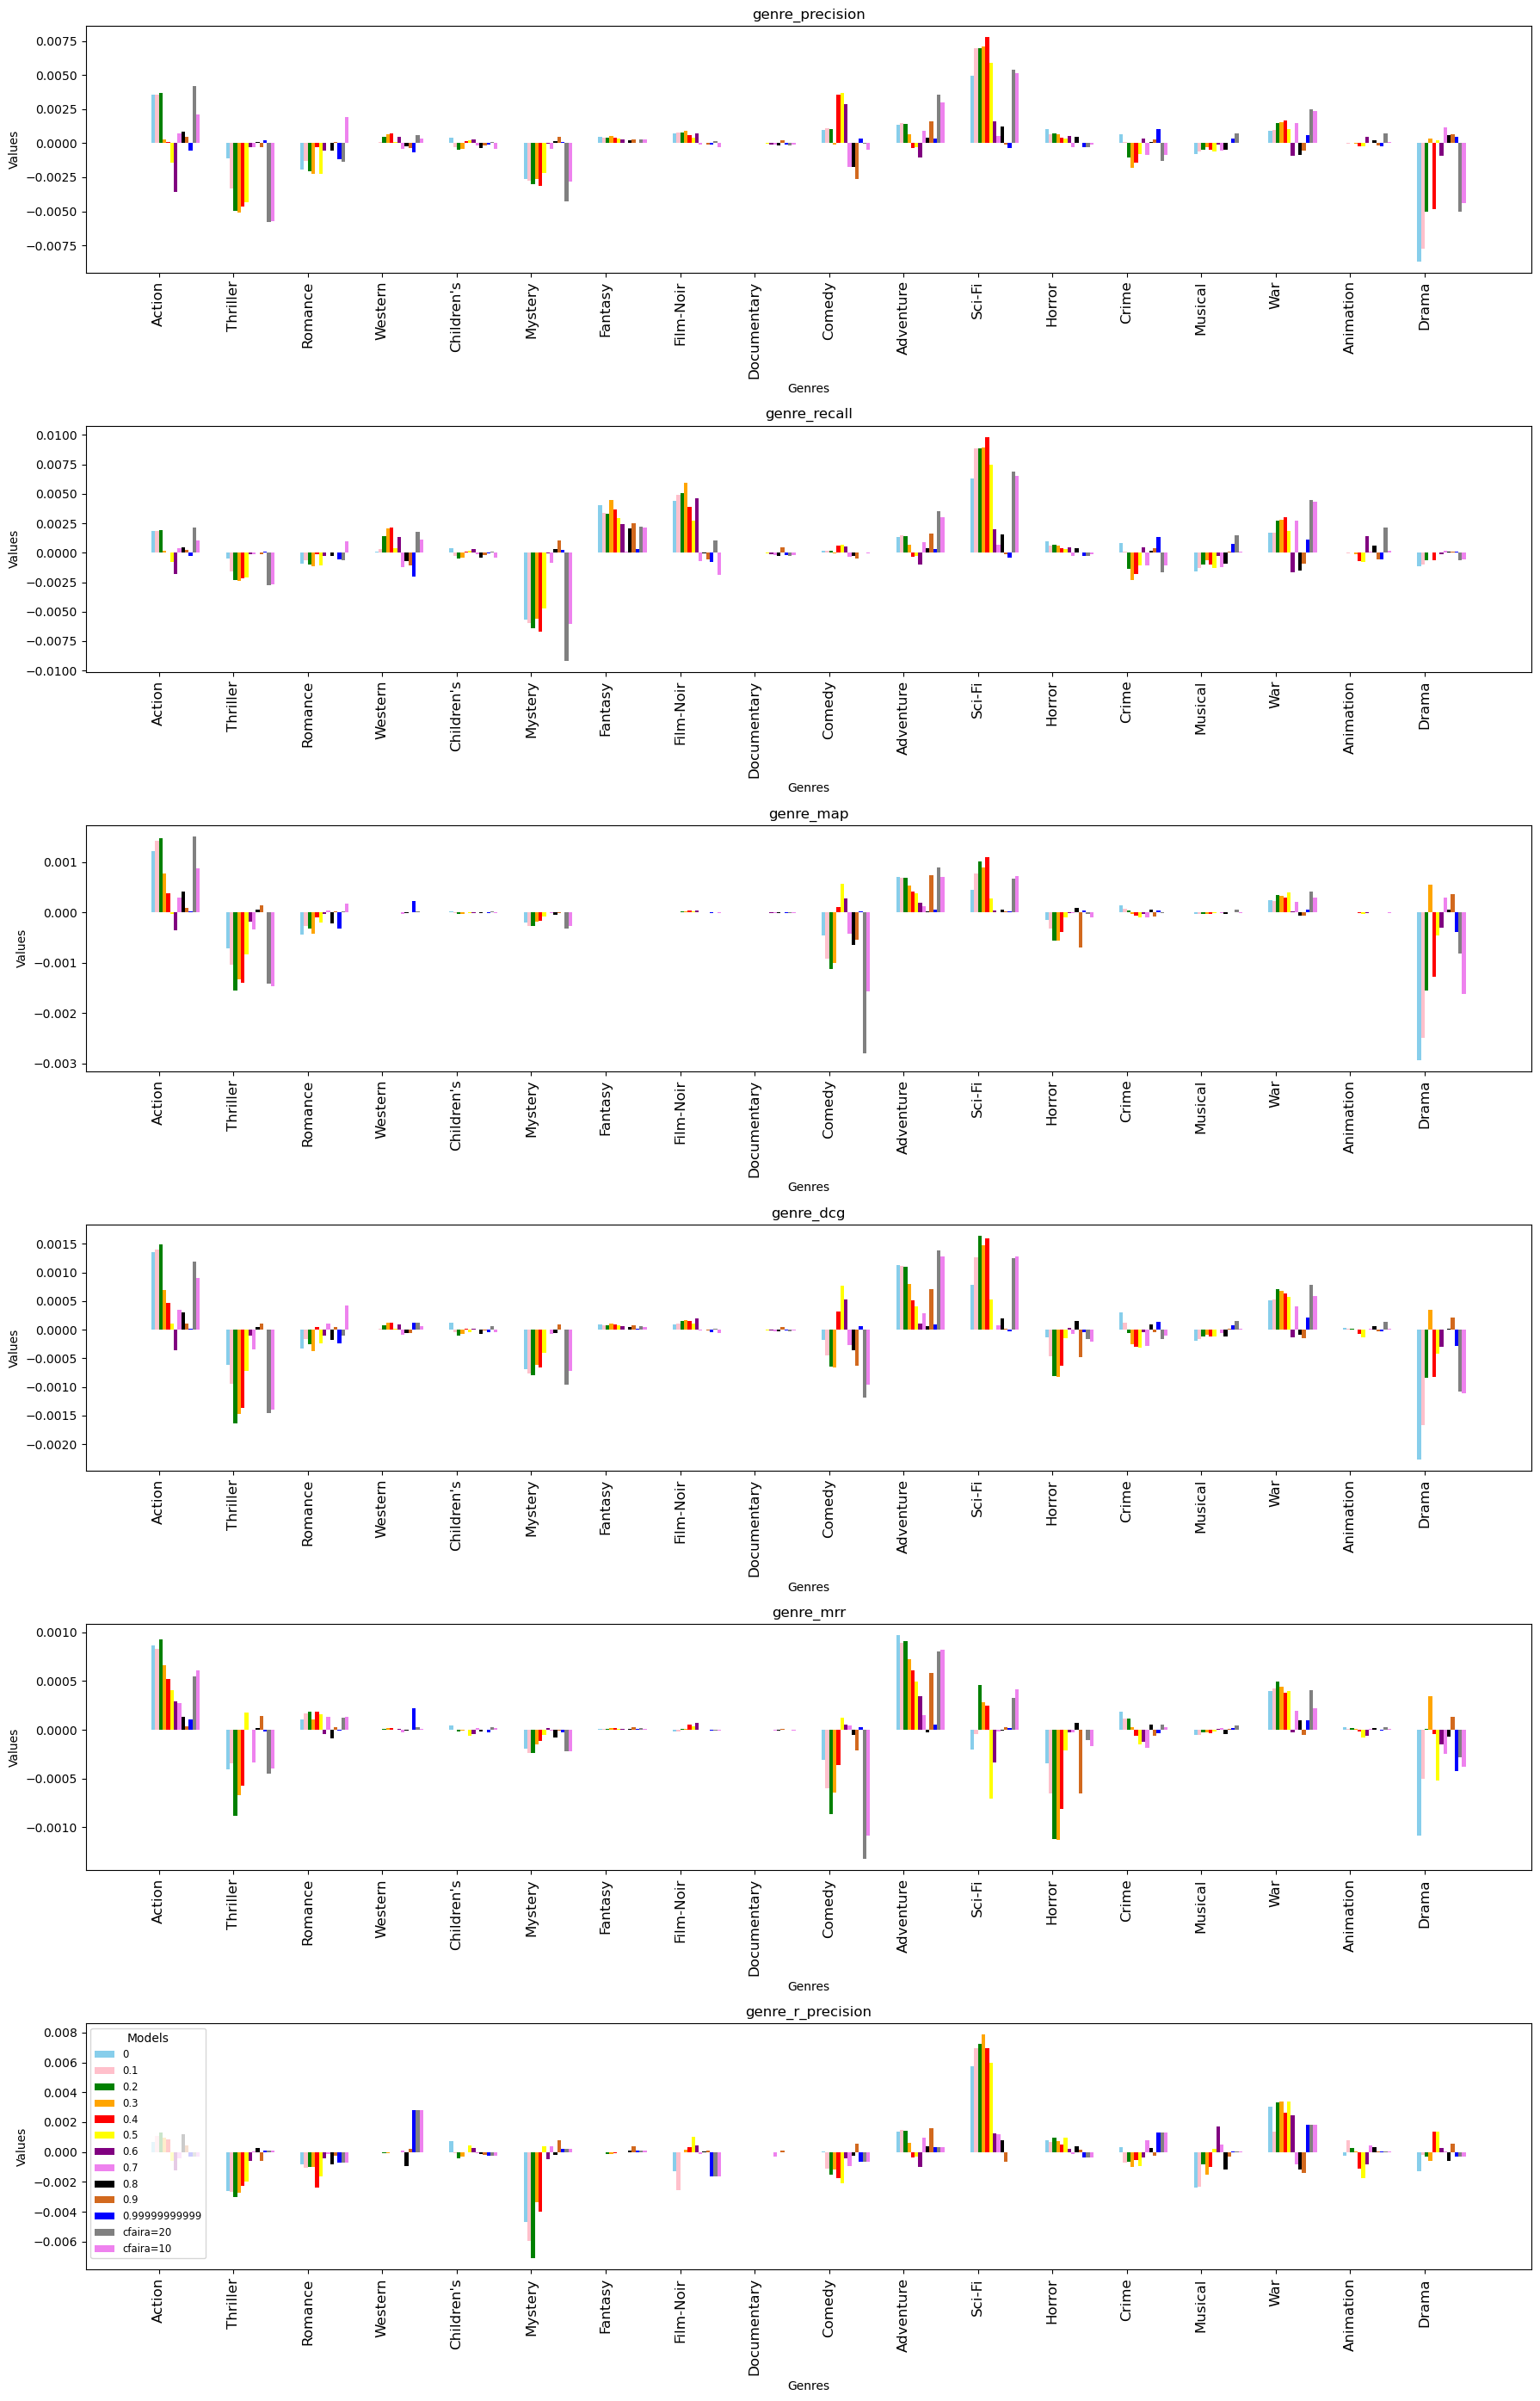

In [28]:


import matplotlib.pyplot as plt
import numpy as np


matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
matrices_4 = [
    model_gps[3][indices],
    model_grs[3][indices],
    model_gms[3][indices],
    model_gdcgs[3][indices],
    model_gmrrs[3][indices],
    model_grps[3][indices],
]
matrices_5 = [
    model_gps[4][indices],
    model_grs[4][indices],
    model_gms[4][indices],
    model_gdcgs[4][indices],
    model_gmrrs[4][indices],
    model_grps[4][indices],
]
matrices_6 = [
    model_gps[5][indices],
    model_grs[5][indices],
    model_gms[5][indices],
    model_gdcgs[5][indices],
    model_gmrrs[5][indices],
    model_grps[5][indices],
]
matrices_7 = [
    model_gps[6][indices],
    model_grs[6][indices],
    model_gms[6][indices],
    model_gdcgs[6][indices],
    model_gmrrs[6][indices],
    model_grps[6][indices],
]
matrices_8 = [
    model_gps[7][indices],
    model_grs[7][indices],
    model_gms[7][indices],
    model_gdcgs[7][indices],
    model_gmrrs[7][indices],
    model_grps[7][indices],
]
matrices_9 = [
    model_gps[8][indices],
    model_grs[8][indices],
    model_gms[8][indices],
    model_gdcgs[8][indices],
    model_gmrrs[8][indices],
    model_grps[8][indices],
]
matrices_10 = [
    model_gps[9][indices],
    model_grs[9][indices],
    model_gms[9][indices],
    model_gdcgs[9][indices],
    model_gmrrs[9][indices],
    model_grps[9][indices],
]
matrices_11 = [
    model_gps[10][indices],
    model_grs[10][indices],
    model_gms[10][indices],
    model_gdcgs[10][indices],
    model_gmrrs[10][indices],
    model_grps[10][indices],
]
matrices_12 = [
    cf_gp[indices],
    cf_gr[indices],
    cf_gm[indices],
    cf_gndcg[indices],
    cf_gmrr[indices],
    model_grps[10][indices],
]
matrices_13 = [
    cf_gp_10[indices],
    cf_gr_10[indices],
    cf_gm_10[indices],
    cf_gndcg_10[indices],
    cf_gmrr_10[indices],
    model_grps[10][indices],
]
# matrices_13 = [
#     model_gps[12][indices],
#     model_grs[12][indices],
#     model_gms[12][indices],
#     model_gdcgs[12][indices],
#     model_gmrrs[12][indices],
#     model_grps[12][indices],
# ]



# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = compare_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 28))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, matrices[i], bar_width, color="skyblue", label=alpha_values[0]
    )
    axs[i].bar(
        x - 1 * bar_width / 2, matrices_2[i], bar_width, color="pink",label=alpha_values[1]
    )
    axs[i].bar(
        x + 1 * bar_width / 2, matrices_3[i], bar_width, color="green", label=alpha_values[2]
    )
    axs[i].bar(
        x + 3 * bar_width / 2, matrices_4[i], bar_width, color="orange", label=alpha_values[3]
    )
    axs[i].bar(
        x + 5 * bar_width / 2, matrices_5[i], bar_width, color="red", label=alpha_values[4]
    )
    axs[i].bar(
        x + 7 * bar_width / 2, matrices_6[i], bar_width, color="yellow", label=alpha_values[5]
    )
    axs[i].bar(
        x + 9 * bar_width / 2, matrices_7[i], bar_width, color="purple", label=alpha_values[6]
    )
    axs[i].bar(
        x + 11 * bar_width / 2, matrices_8[i], bar_width, color="violet", label=alpha_values[7]
    )
    axs[i].bar(
        x + 13 * bar_width / 2, matrices_9[i], bar_width, color="black", label=alpha_values[8]
    )
    axs[i].bar(
        x + 15 * bar_width / 2,
        matrices_10[i],
        bar_width,
        color="chocolate",
       label=alpha_values[9]
    )
    axs[i].bar(
        x + 17 * bar_width / 2, matrices_11[i], bar_width, color="blue", label=alpha_values[10]
    )
    axs[i].bar(
        x + 19 * bar_width / 2, matrices_12[i], bar_width, color="gray", label="cfaira=20"
    )
    axs[i].bar(
        x + 21 * bar_width / 2, matrices_13[i], bar_width, color="violet", label="cfaira=10"
    )
    
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")

# Adjust layout
plt.tight_layout()
plt.savefig("all_res.pdf" , format="pdf")
plt.show()

###################
# a*gender_loss + (1-a)*mseloss
# genderloss * batch_size * 25
###################

['plain', 'a=0.5 with genre reg', 'bp reg']
[<BarContainer object of 18 artists>, <BarContainer object of 18 artists>, <BarContainer object of 18 artists>]


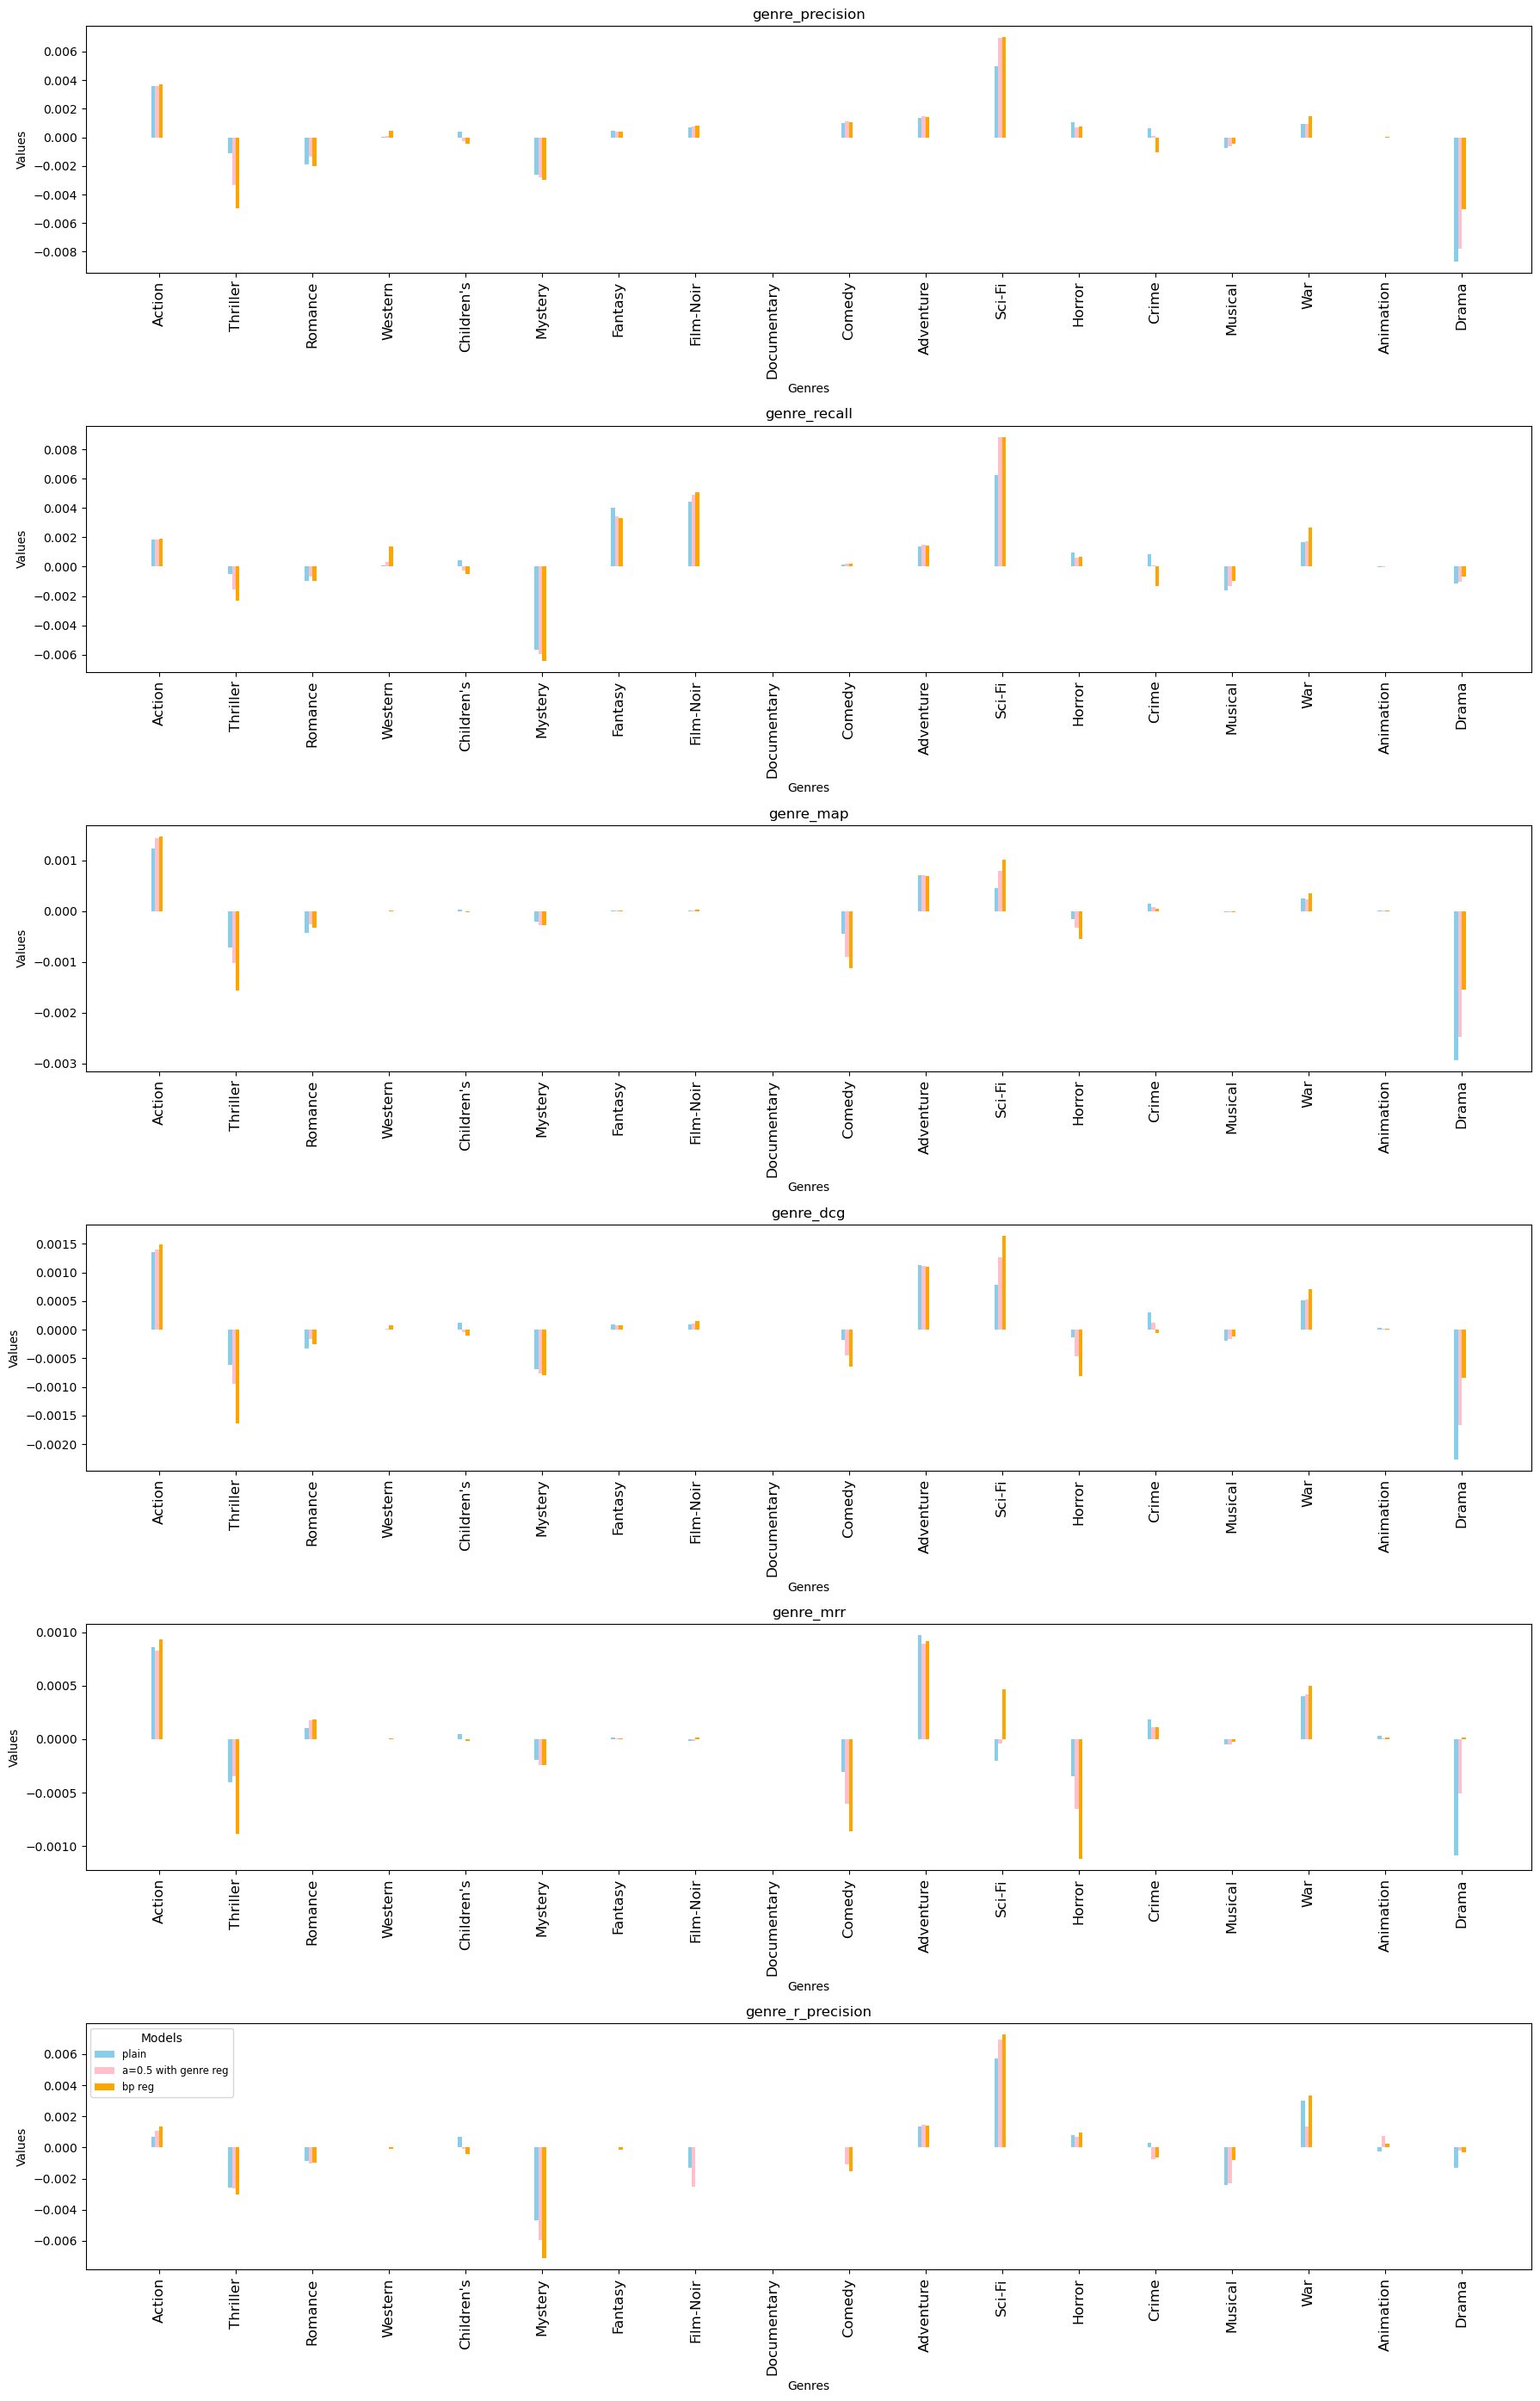

In [29]:
import matplotlib.pyplot as plt
import numpy as np


matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
matrices_2 = [
    model_gps[1][indices],
    model_grs[1][indices],
    model_gms[1][indices],
    model_gdcgs[1][indices],
    model_gmrrs[1][indices],
    model_grps[1][indices],
]
matrices_3 = [
    model_gps[2][indices],
    model_grs[2][indices],
    model_gms[2][indices],
    model_gdcgs[2][indices],
    model_gmrrs[2][indices],
    model_grps[2][indices],
]
# matrices_4 = [
#     model_gps[3][indices],
#     model_grs[3][indices],
#     model_gms[3][indices],
#     model_gdcgs[3][indices],
#     model_gmrrs[3][indices],
#     model_grps[3][indices],
# ]
# matrices_5 = [
#     model_gps[4][indices],
#     model_grs[4][indices],
#     model_gms[4][indices],
#     model_gdcgs[4][indices],
#     model_gmrrs[4][indices],
#     model_grps[4][indices],
# ]
# matrices_6 = [
#     model_gps[5][indices],
#     model_grs[5][indices],
#     model_gms[5][indices],
#     model_gdcgs[5][indices],
#     model_gmrrs[5][indices],
#     model_grps[5][indices],
# ]
# matrices_7 = [
#     model_gps[6][indices],
#     model_grs[6][indices],
#     model_gms[6][indices],
#     model_gdcgs[6][indices],
#     model_gmrrs[6][indices],
#     model_grps[6][indices],
# ]
# matrices_8 = [
#     model_gps[7][indices],
#     model_grs[7][indices],
#     model_gms[7][indices],
#     model_gdcgs[7][indices],
#     model_gmrrs[7][indices],
#     model_grps[7][indices],
# ]
# matrices_9 = [
#     model_gps[8][indices],
#     model_grs[8][indices],
#     model_gms[8][indices],
#     model_gdcgs[8][indices],
#     model_gmrrs[8][indices],
#     model_grps[8][indices],
# ]
# matrices_10 = [
#     model_gps[9][indices],
#     model_grs[9][indices],
#     model_gms[9][indices],
#     model_gdcgs[9][indices],
#     model_gmrrs[9][indices],
#     model_grps[9][indices],
# ]
# matrices_11 = [
#     model_gps[10][indices],
#     model_grs[10][indices],
#     model_gms[10][indices],
#     model_gdcgs[10][indices],
#     model_gmrrs[10][indices],
#     model_grps[10][indices],
# ]
# matrices_12 = [
#     model_gps[11][indices],
#     model_grs[11][indices],
#     model_gms[11][indices],
#     model_gdcgs[11][indices],
#     model_gmrrs[11][indices],
#     model_grps[11][indices],
# ]
# matrices_13 = [
#     model_gps[12][indices],
#     model_grs[12][indices],
#     model_gms[12][indices],
#     model_gdcgs[12][indices],
#     model_gmrrs[12][indices],
#     model_grps[12][indices],
# ]



# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = compare_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 28))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, matrices[i], bar_width, color="skyblue", label="plain"
    )
    axs[i].bar(
        x - 1 * bar_width / 2, matrices_2[i], bar_width, color="pink",label="a=0.5 with genre reg"
    )
    axs[i].bar(
        x +1* bar_width / 2, matrices_3[i], bar_width, color="orange",label="bp reg"
    )
    # axs[i].bar(
    #     x + 1 * bar_width / 2, matrices_3[i], bar_width, color="green", label=alpha_values[2]
    # )
    # axs[i].bar(
    #     x + 3 * bar_width / 2, matrices_4[i], bar_width, color="orange", label=alpha_values[3]
    # )
    # axs[i].bar(
    #     x + 5 * bar_width / 2, matrices_5[i], bar_width, color="red", label=alpha_values[4]
    # )
    # axs[i].bar(
    #     x + 7 * bar_width / 2, matrices_6[i], bar_width, color="yellow", label=alpha_values[5]
    # )
    # axs[i].bar(
    #     x + 9 * bar_width / 2, matrices_7[i], bar_width, color="purple", label=alpha_values[6]
    # )
    # axs[i].bar(
    #     x + 11 * bar_width / 2, matrices_8[i], bar_width, color="violet", label=alpha_values[7]
    # )
    # axs[i].bar(
    #     x + 13 * bar_width / 2, matrices_9[i], bar_width, color="black", label=alpha_values[8]
    # )
    # axs[i].bar(
    #     x + 15 * bar_width / 2,
    #     matrices_10[i],
    #     bar_width,
    #     color="chocolate",
    #    label=alpha_values[9]
    # )
    # axs[i].bar(
    #     x + 17 * bar_width / 2, matrices_11[i], bar_width, color="blue", label=alpha_values[10]
    # )
    # axs[i].bar(
    #     x + 19 * bar_width / 2, matrices_12[i], bar_width, color="blue", label=alpha_values[11]
    # )
    # axs[i].bar(
    #     x + 21 * bar_width / 2, matrices_13[i], bar_width, color="blue", label=alpha_values[12]
    # )
    
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")

# Adjust layout
plt.tight_layout()
plt.show()

In [40]:
x= sum(abs(cf_gndcg_10))
x>gdcg_sum
# gp_sum

array([ True, False, False,  True,  True,  True,  True,  True,  True,
        True,  True])

In [41]:


all_values = [
    ["a=0 mf", 1.0028, 0.5636, 0.0528, 0.6501, 0.0440, 0.1571, 0.0792, 0.0429, 0.1009, 5.9468, 0.6271],
    ["a=0.1 mf", 1.0007, 0.5609, 0.0529, 0.6575, 0.0432, 0.1519, 0.0784, 0.0430, 0.1015, 133.6435, 0.5747],
    ["a=0.2 mf", 0.9963, 0.5596, 0.0530, 0.6554, 0.0435, 0.1534, 0.0789, 0.0431, 0.1014, 131.6855, 0.5737],
    ["a=0.3 mf", 0.9901, 0.5582, 0.0525, 0.6490, 0.0444, 0.1633, 0.0800, 0.0427, 0.1005, 130.1983, 0.5649],
    ["a=0.4 mf", 0.9860, 0.5556, 0.0542, 0.6511, 0.0453, 0.1734, 0.0831, 0.0439, 0.1035, 134.0786, 0.5741],
    ["a=0.5 mf", 0.9841, 0.5531, 0.0542, 0.6394, 0.0452, 0.1683, 0.0825, 0.0440, 0.1036, 148.7229, 0.6262],
    ["a=0.6 mf", 0.9833, 0.5479, 0.0543, 0.6246, 0.0452, 0.1659, 0.0819, 0.0441, 0.1028, 135.8487, 0.5760],
    ["a=0.7 mf", 0.9855, 0.5381, 0.0522, 0.5938, 0.0442, 0.1574, 0.0781, 0.0426, 0.0972, 137.1758, 0.6263],
    ["a=0.8 mf", 0.9974, 0.5237, 0.0498, 0.5758, 0.0424, 0.1607, 0.0747, 0.0407, 0.0923, 135.4480, 0.7201],
    ["a=0.9 mf", 1.0251, 0.4892, 0.0442, 0.5366, 0.0366, 0.1237, 0.0632, 0.0359, 0.0820, 148.9166, 0.6618],
    ["a=1 mf", 1.1464, 0.3459, 0.0118, 0.3033, 0.0159, 0.0428, 0.0150, 0.0106, 0.0179, 126.6729, 0.7206]
]

# RMSE: [1.004, 1.0018, 0.9973, 0.9908, 0.9868, 0.9836, 0.9837, 0.9849, 0.9962, 1.0251, 1.1211]
# AUC: [0.5636, 0.5612, 0.5597, 0.5589, 0.5558, 0.5538, 0.5482, 0.5394, 0.5255, 0.4904, 0.3283]
# F1@50: [0.0529, 0.0527, 0.053, 0.053, 0.0533, 0.0544, 0.0544, 0.0521, 0.0497, 0.0443, 0.0147]
HitRatios= [0.6532, 0.6522, 0.6596, 0.6564, 0.649, 0.6479, 0.6331, 0.6002, 0.5695, 0.5408, 0.3637]
# MAP: [0.0439, 0.0432, 0.0437, 0.0443, 0.045, 0.0458, 0.0451, 0.0441, 0.0423, 0.0369, 0.0212]
# MRR: [0.1558, 0.1511, 0.1547, 0.1607, 0.1727, 0.1734, 0.1617, 0.1579, 0.1571, 0.1254, 0.1018]
NDCG =  [0.0793, 0.0781, 0.0791, 0.0802, 0.0821, 0.0837, 0.0819, 0.0778, 0.0741, 0.0635, 0.0251]
# Precision@50: [0.043, 0.0429, 0.0431, 0.043, 0.0433, 0.0441, 0.0441, 0.0425, 0.0405, 0.0361, 0.0134]
# Recall@50: [0.1015, 0.1012, 0.1017, 0.1017, 0.1022, 0.1043, 0.1034, 0.0972, 0.0923, 0.082, 0.022


rmse_values_extracted = [values[0] for values in all_values]
auc_values_extracted = [values[1] for values in all_values]
recall_values_extracted = [values[7] for values in all_values]
hit_ratio_values_extracted = [values[4] for values in all_values]


In [ ]:
rmse_values_extracted

[0.9496,
 0.9487,
 0.9481,
 0.9476,
 0.9477,
 0.9488,
 0.9516,
 0.9573,
 0.968,
 0.99,
 1.129]

In [31]:
gp_sum = [sum(abs(model_gps[i])) for i in range(len(models))]
gr_sum = [sum(abs(model_grs[i])) for i in range(len(models))]
gm_sum = [sum(abs(model_gms[i])) for i in range(len(models))]
gdcg_sum = [sum(abs(model_gdcgs[i])) for i in range(len(models))]
gmrr_sum = [sum(abs(model_gmrrs[i])) for i in range(len(models))]
grp_sum = [sum(abs(model_grps[i])) for i in range(len(models))]


In [44]:
print(gr_sum)

[0.07174353082883486, 0.060115437391738684, 0.06306751858134393, 0.058454094923073525, 0.0676564870045814, 0.06601775416262434, 0.06347227896403469, 0.06379017012299197, 0.05278366877703885, 0.044255257575615006, 1.0408340855860843e-17]


In [38]:
x =sum(abs(cf_gr_10))
print(x>gp_sum)

[ True  True False  True  True  True  True  True  True  True  True]


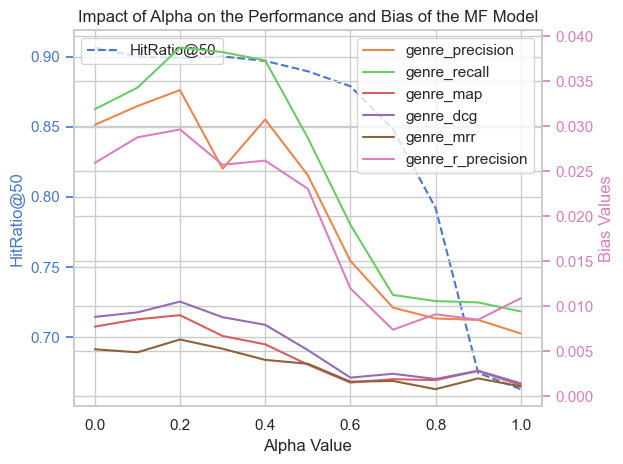

In [33]:

import matplotlib.pyplot as plt
import seaborn as sns


x = alpha_values
upper_bound = len(alpha_values)

sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

fig, ax1 = plt.subplots()
hit_ratio = [0.9067,0.9003,0.8993,0.9003,0.8971,0.8897,0.8791,0.8484,0.7922,0.6744,0.6628]

ax1.plot(x[0:upper_bound], hit_ratio[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
# ax1.plot(x[0:upper_bound], auc_values_extracted[0:upper_bound], linestyle="dotted", color=pastel_palette[0], label="RMSE")
ax1.set_xlabel("Alpha Value")
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0])
ax1.tick_params(axis="y", colors=pastel_palette[0])
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6])
ax2.tick_params(axis="y", colors=pastel_palette[6])
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Impact of Alpha on the Performance and Bias of the MF Model")
plt.tight_layout()
plt.show()

#  models.append(
#         MF(
#             k=20,
#             seed=123,
#             name=f"a={alpha_values[i]} mf",
#             backend="pytorch",
#             verbose=True,
#             optimizer="adam",batch_size=128,
#             alpha=alpha_values[i],
#             learning_rate=0.001,
#             top_k=50, max_iter=10,
#             # early_stopping=True
#         )
#     )

 # models.append(
    #     MF(
    #         k=20,
    #         seed=123,
    #         name=f"a={alpha_values[i]} mf",
    #         backend="pytorch",
    #         verbose=True,
    #         optimizer="adam",batch_size=400,
    #         alpha=alpha_values[i],
    #         learning_rate=0.001,
    #         top_k=50, max_iter=10,
    #         # early_stopping=True
    #     )
    # )

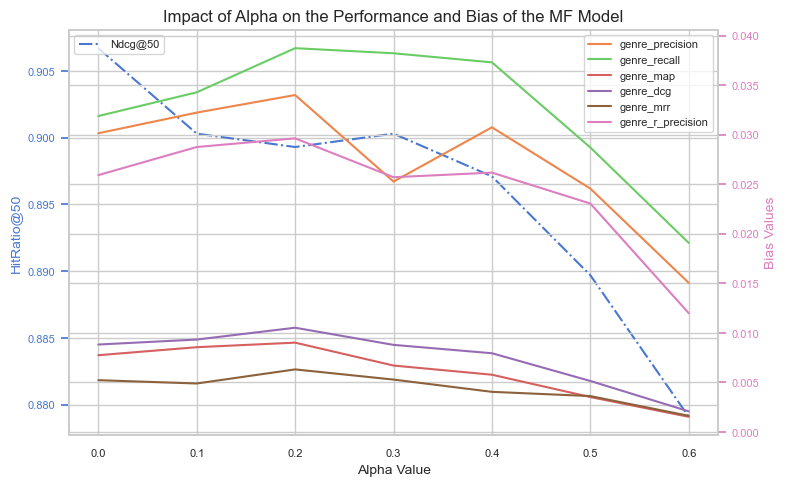

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

x = alpha_values
upper_bound = 

# Set seaborn style and define a pastel color palette
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(8, 5))  # Adjust figure size to make it more compact
hit_ratio = [0.9067,0.9003,0.8993,0.9003,0.8971,0.8897,0.8791,0.8484,0.7922,0.6744,0.6628]

# Plot the HitRatio@50
# ax1.plot(x[0:upper_bound], HitRatios[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
ax1.plot(x[0:upper_bound], hit_ratio[0:upper_bound], linestyle="-.", color=pastel_palette[0], label="Ndcg@50")
ax1.set_xlabel("Alpha Value", fontsize=10)
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0], fontsize=10)
ax1.tick_params(axis="y", colors=pastel_palette[0], labelsize=8)
ax1.tick_params(axis="x", labelsize=8)

# Create a secondary y-axis for bias values
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6], fontsize=10)
ax2.tick_params(axis="y", colors=pastel_palette[6], labelsize=8)

# Adjust the legend font size and position to make it smaller and compact
ax1.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

# Set the title and adjust layout for compactness
plt.title("Impact of Alpha on the Performance and Bias of the MF Model", fontsize=12)
plt.tight_layout(pad=1)  # Reduce padding around the plot
plt.savefig("100kmf.pdf", format="pdf")
plt.show()
# models.append(
    #     MF(
    #         k=20,
    #         seed=123,
    #         name=f"a={alpha_values[i]} mf",
    #         backend="pytorch",
    #         verbose=True,
    #         optimizer="adam",batch_size=400,
    #         alpha=alpha_values[i],
    #         learning_rate=0.001,
    #         top_k=50, max_iter=10,
    #         # early_stopping=True
    #     )
    # )


In [42]:
sum(abs(cf_gp))> gp_sum

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


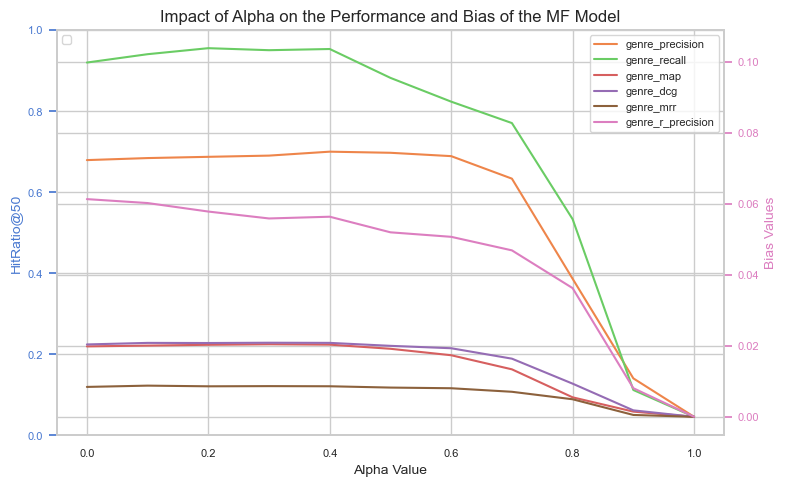

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

x = alpha_values
upper_bound = len(alpha_values)

# Set seaborn style and define a pastel color palette
sns.set(style="whitegrid")
pastel_palette = sns.color_palette("muted")

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(8, 5))  # Adjust figure size to make it more compact

# Plot the HitRatio@50
# ax1.plot(x[0:upper_bound], HitRatios[0:upper_bound], linestyle="--", color=pastel_palette[0], label="HitRatio@50")
# ax1.plot(x[0:upper_bound], NDCG[0:upper_bound], linestyle="-.", color=pastel_palette[0], label="Ndcg@50")
ax1.set_xlabel("Alpha Value", fontsize=10)
ax1.set_ylabel("HitRatio@50", color=pastel_palette[0], fontsize=10)
ax1.tick_params(axis="y", colors=pastel_palette[0], labelsize=8)
ax1.tick_params(axis="x", labelsize=8)

# Create a secondary y-axis for bias values
ax2 = ax1.twinx()
ax2.plot(x[0:upper_bound], gp_sum[0:upper_bound], label=titles[0], color=pastel_palette[1])
ax2.plot(x[0:upper_bound], gr_sum[0:upper_bound], label=titles[1], color=pastel_palette[2])
ax2.plot(x[0:upper_bound], gm_sum[0:upper_bound], label=titles[2], color=pastel_palette[3])
ax2.plot(x[0:upper_bound], gdcg_sum[0:upper_bound], label=titles[3], color=pastel_palette[4])
ax2.plot(x[0:upper_bound], gmrr_sum[0:upper_bound], label=titles[4], color=pastel_palette[5])
ax2.plot(x[0:upper_bound], grp_sum[0:upper_bound], label=titles[5], color=pastel_palette[6])
ax2.set_ylabel("Bias Values", color=pastel_palette[6], fontsize=10)
ax2.tick_params(axis="y", colors=pastel_palette[6], labelsize=8)

# Adjust the legend font size and position to make it smaller and compact
ax1.legend(loc="upper left", fontsize=8)
ax2.legend(loc="upper right", fontsize=8)

# Set the title and adjust layout for compactness
plt.title("Impact of Alpha on the Performance and Bias of the MF Model", fontsize=12)
plt.tight_layout(pad=1)  # Reduce padding around the plot
plt.savefig("100kmf.pdf", format="pdf")
plt.show()


In [ ]:
top_k = 20
reco_matrix_n = np.zeros((len(user_ids), top_k), dtype=int)

for i in range(reco_matrix[0].shape[0]):
    reco_matrix_n[i] = reco_matrix[1][i][:top_k]

reco_matrix_n.shape

In [ ]:
reco_matrix[1].shape[0]
# top_k = 50
# reco_matrix = np.zeros((reco_matrix_all_items.shape[0], top_k), dtype=int)
# for i in range(reco_matrix_all_items.shape[0]):
#     reco_matrix[i] = reco_matrix_all_items[i][:top_k]

In [ ]:
sum(model_gdcg_2)

In [ ]:
# np.where(reco_matrix_mapped_items[1][0]==0)
# reco_matrix_all[1][0][258]
reco_matrix_mapped_scores[1][1][1552]

# reco_matrix_mapped_items[1][1][1552]
# reco_matrix_mapped_items[1][0][258]
# reco_items_scores_all[0]
# mapped_item_index

In [ ]:
reco_items_scores_all[0][0]
# np.save("reco_items_scores_all.npy",reco_items_scores_all)

In [ ]:
# unique_genres = ['Crime',
#  'Film-Noir',
#  'Adventure',
#  'Fantasy',
#  'Sci-Fi',
#  'Documentary',
#  'Drama',
#  'Horror',
#  'War',
#  'Animation',
#  'Romance',
#  "Children's",
#  'Western',
#  'Mystery',
#  'Thriller',
#  'Musical',
#  'Action',
#  'Comedy']

In [ ]:
# tahsin kheya
# last modified 21/07/2024
import pandas as pd
import os
import numpy as np
import torch
import time
from logging import getLogger
import random


class Calibration(object):
    def __init__(self, config, movies, top_k, unique_genres, users):
        self.device = "cuda:0" if torch.cuda.is_available() else "cpu"
        self.device = torch.device(self.device)
        # self.logger = getLogger()
        self.reco_distribution = []
        self.kl = []

        # self.logger = getLogger()
        self.top_k = top_k
        self.gkl = []
        self.gender_df = users
        self.actual_genre_dist = pd.read_csv(
            os.path.join(config["user_genre_dist_file"]),
            sep="\t",
        )
        self.unique_genres = list(self.actual_genre_dist.columns)[1:]

        # self.actual_genre_dist = self.actual_genre_dist.drop(columns=["userID"])

        self.config = config
        self.item_df = movies
        self.actual_distribution_without_id = self.actual_genre_dist.drop(
            columns=["userID"]
        ).to_numpy()
        print(self.unique_genres)
        # print(self.actual_distribution_without_id)

        self.actual_distribution_gender = []

    def get_all_user_recommended_genre_dist(self, topk_reco):

        df_reco = pd.DataFrame(
            {
                "userID": np.repeat(np.arange(topk_reco.shape[0]), self.top_k),
                "itemID": topk_reco.flatten(),
                "rank": np.tile(np.arange(1, self.top_k + 1), topk_reco.shape[0]),
            }
        )

        df_reco["weight_factor"] = 1 / (df_reco["rank"]) ** 0.1
        merged_df = pd.merge(df_reco, self.item_df, on="itemID", how="inner")
        merged_df[self.unique_genres] = merged_df[self.unique_genres].div(
            merged_df[self.unique_genres].sum(axis=1), axis=0
        )

        merged_df[self.unique_genres] = (
            merged_df["weight_factor"].values[:, None] * merged_df[self.unique_genres]
        )
        reco_distribution = merged_df[["userID"] + self.unique_genres]
        reco_distribution = reco_distribution.groupby("userID")[
            self.unique_genres
        ].mean()
        #         reco_distribution[self.unique_genres] = reco_distribution[
        #             self.unique_genres
        #         ].div(reco_distribution[self.unique_genres].sum(axis=1), axis=0)

        return reco_distribution

    def get_recom_distribution(self, reco):

        reco = np.array(reco)
        weights = 1 / (np.arange(len(reco)) + 1) ** 0.1
        item_genre_weights = np.zeros((len(reco), len(self.unique_genres)))

        for i, itemID in enumerate(reco):
            item_index = self.item_df.index.get_loc(itemID)
            item_genre_weights[i] = (
                weights[i] * self.item_df.loc[item_index, self.unique_genres]
            )
        #         print(item_genre_weights)
        # Normalize genre weights so sum is 1
        #         item_genre_weights /= torch.sum(item_genre_weights, axis=1, keepdims=True)

        return item_genre_weights

    def get_kl_div(self, q_dist, p_dist, a, uid):
        kl_div = 0
        qg_u = (1 - a) * q_dist + a * p_dist
        nonzero_indices = np.where(p_dist != 0)

        kl_div = np.sum(
            p_dist[nonzero_indices]
            * np.log10(p_dist[nonzero_indices] / qg_u[nonzero_indices])
        )

        return kl_div

    # def get_gender_representation_one_user(self, reco_dist, uid):
    #     c = []
    #     retVal = []
    #     print(self.actual_distribution[uid])

    #     for i in range(len(self.unique_genres)):
    #         c.append(np.log(reco_dist[i] / self.actual_distribution[uid][i + 1]))
    #     # Assuming self.unique_genres is a list or array-like
    #     genre_columns_count = len(self.unique_genres)

    #     reco_dist_slice = reco_dist[:genre_columns_count]
    #     actual_dist_slice = self.actual_distribution[uid][1 : genre_columns_count + 1]

    #     log_ratios = np.log(reco_dist_slice / actual_dist_slice)
    #     retVal.extend(log_ratios.tolist())

    def compute_diversity_score(self, reco_items, uid, l, scores, user_reco, b):

        # -----------------the diversity term----------------------------------
        alpha = 0.01
        # reco_items=self.reco_distribution[uid]
        sum_score = 0
        reco_dist = self.get_recom_distribution(reco_items)
        # print(reco_dist)
        #
        sum_dist = np.sum(reco_dist, axis=0)
        avg_dist = sum_dist / reco_dist.shape[0]
        # 1x18 array (it already is, but let's reshape explicitly)
        reco_dist = avg_dist.reshape(1, -1)
        # normalise values
        reco_dist = reco_dist / sum(reco_dist[0])
        # print(f"reco item {reco_items}, genre_dist_actual_user {self.actual_distribution_without_id[uid]}, reco genre distribution {reco_dist}")
        kl = self.get_kl_div(
            reco_dist[0], self.actual_distribution_without_id[uid], alpha, uid
        )

        # -----------------the diversity term----------------------------------

        # -----------------the fairness term----------------------------------
        # recommended dist mean for each gender
        male_user_ids = self.gender_df[self.gender_df["Gender"] == 0]["userID"]
        male_user_ids = male_user_ids.to_list()
        gender_genre_dist = self.actual_distribution_gender
        # gender_reco_dist = self.get_gender_representation_one_user(reco_dist[0],uid)
        if uid in male_user_ids:
            compare_dist = gender_genre_dist.to_numpy()[1]
        else:
            compare_dist = gender_genre_dist.to_numpy()[0]

        # gender_kl = self.get_kl_div(reco_dist[0], compare_dist, alpha, uid)
        gender_kl = 0

        # -----------------the fairness term----------------------------------

        for r in range(len(reco_items)):
            sum_score += scores[reco_items[r]]

        # print(f"genderkl {gender_kl}, kl {kl} score{sum_score}")

        # if len(reco_items) == 5:
        #     self.kl.append(kl)
        #     self.gkl.append(gender_kl)
        #     print(":;;;;;;;;;;;")
        #     print(uid)

        #     print(self.kl)
        #     print(self.gkl)
        #     print(":;;;;;;;;;;;")
        # print(f"score {sum_score}, kl {kl}, gender_kl {gender_kl}")

        return (1 - l - b) * sum_score - l * kl - b * gender_kl

    # c.get_improved_reco(reco_matrix,reco_matrix_all_items,reco_matrix_all_scores, users)

    def get_improved_reco(self, top_items, items, scores):

        # reco = torch.cat(batch_matrix_list, dim=0).cpu().numpy()

        # scores = torch.cat(batch_score_list, dim=0).cpu().numpy()
        # self.reco_distribution = self.get_recom_distribution(reco)
        return self.get_new_recommendations(
            reco=top_items, scores=scores, all_items=items
        )

    def get_kl_div_gender(self, female_dist, male_dist, a):
        kl_div = 0
        for i in range(len(self.unique_genres)):
            female_dist = (1 - a) * female_dist[i] + a * male_dist[i]
            if male_dist[i] == 0:
                continue
            kl_div = kl_div + male_dist[i] * np.log10(male_dist[i] / female_dist[i])

        return kl_div

    def get_gender_genre_dist(self, user_reco):
        # gender_df = pd.DataFrame(self.genders.items(), columns=["userID", "gender"])
        actual_dist_gender = pd.merge(
            self.actual_genre_dist, self.gender_df, on="userID"
        )
        recomen_df = pd.merge(user_reco, self.gender_df, on="userID")
        # gender_genre_weights_r = recomen_df.groupby("gender")[
        #     self.unique_genres
        # ].mean()
        gender_genre_weights_a = actual_dist_gender.groupby("Gender")[
            self.unique_genres
        ].mean()
        self.actual_distribution_gender = gender_genre_weights_a.sort_index()

    def get_new_recommendations(self, reco, scores, all_items):
        """reco is 6040x50 and scores is 6040x3416"""

        user_reco_dist = self.get_all_user_recommended_genre_dist(reco)
        self.get_gender_genre_dist(user_reco_dist)

        #####
        # gender_discriminated_agaisnt = self.get_gender_discriminated_agaisnt(
        #     user_reco_dist
        # )
        # male_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 0]
        # female_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 1]
        # for each gender clculate the skew for each genre:
        b = 0.69  # beta
        l = 0.29  # lambda
        all_users = []

        #####

        top_k = self.top_k

        n_users, n_items = all_items.shape

        for u in range(0, 50):
            # remaining_items = all_items
            remaining_items = list(all_items[u])
            # print(remaining_items)

            #             u_calibrated = [623, 1612, 558, 1087, 1347, 3368, 196, 3256, 3127, 882, 831, 1271, 1870, 2594, 3279, 2624, 393, 1496, 3099, 2414, 1232, 1773, 1313, 610, 500, 2855, 1973, 1872, 3334, 3296, 649, 769, 1573, 2474, 2133, 2161, 3387, 2640, 1583, 3287, 753, 384, 2192, 709, 1981, 3311 ]
            u_calibrated = []
            for k in range(top_k):
                diversity_scores = [
                    self.compute_diversity_score(
                        u_calibrated + [i], u, l, scores[u], user_reco_dist, b
                    )
                    for i in remaining_items
                ]
                max_index = np.argmax(diversity_scores)

                best_item = remaining_items[max_index]
                u_calibrated.append(best_item)
                remaining_items.pop(max_index)
                print(u_calibrated)
                # self.logger.info(u_calibrated)

            # self.logger.info(u_calibrated)

            all_users.append(u_calibrated)

        return np.array(all_users)

In [ ]:
reco_matrix_all[1].shape

In [ ]:
score_dicts[1][889]
reco_matrix_all[1][0][0]
score_dicts[1][0]

In [ ]:
# from cornac.reranking.Calibration import Calibration
config = {"user_genre_dist_file": "./cornac/data_c/user_genre_dist_new.csv"}
c = Calibration(
    config=config, movies=movies, top_k=50, unique_genres=unique_genres, users=users
)
# for itemknn

reranked_reco = c.get_improved_reco(reco_matrix[1], reco_matrix_all[1], score_dicts)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(user_features_numpy[:, 1].shape)

In [ ]:
# Calculate total number of genres
total_genres = len(unique_genres)  # Exclude 'itemID'
# Assuming 'column_name' is the name of the column you want to convert to float
movies[unique_genres] = movies[unique_genres].astype(float)

# Iterate over each row
for index, row in movies.iterrows():
    # Find genres with value 1
    present_genres = [genre for genre in unique_genres if row[genre] == 1]
    num_present_genres = len(present_genres)

    # Calculate weight for each present genre
    if num_present_genres > 0:
        weight_per_genre = 1 / num_present_genres
        for genre in present_genres:
            if movies.at[index, genre] == 1:
                movies.at[index, genre] = weight_per_genre

In [ ]:
# mergde_pd = pd.merge(rating_data_pd,users, how="inner", on="userID")
mergde_pd = pd.merge(rating_data_pd, movies, how="inner", on="itemID")
mergde_pd

In [ ]:
user_genre_means = mergde_pd.groupby("userID")[unique_genres].mean()
user_genre_means

In [ ]:
users

In [ ]:
useer = pd.merge(user_genre_means, users, on="userID", how="inner")
user_genre_gender = useer.groupby("Gender")[unique_genres].mean()
user_genre_gender

In [ ]:
rating_data_pd

In [ ]:
# inter_movies
z = inter_movies[["userID", "itemID", "Gender"]]
mergz = pd.merge(z, movies, on="itemID", how="left")
mergz
user_genre_gender = mergz.groupby("Gender")[unique_genres].mean()
user_genre_gender

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender.iloc[0] * 100,
    bar_width,
    label="male (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender.iloc[1] * 100,
    bar_width,
    label="feMale (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender.iloc[0] * 100,
    bar_width,
    label="male (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender.iloc[1] * 100,
    bar_width,
    label="female (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# inter_movies["itemID"].nunique()
reco_matrix_new.shape

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix_new.shape[0] + 1).repeat(reco_matrix_new.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix_new.flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_2 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_2
# Print the DataFrame

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
##use 0 and 0.5 as alpha

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({"userID": user_ids, "itemID": flat_movie_ids})

mepd = pd.merge(df, movies, on="itemID", how="inner")
mepd = pd.merge(mepd, users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby("Gender")[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(
    x - 3 * bar_width / 2,
    user_genre_gender_1.iloc[0] * 100,
    bar_width,
    label="Female (Top 50)",
    color="#bca0dc",
)
rects2 = ax.bar(
    x + bar_width / 2,
    user_genre_gender_1.iloc[1] * 100,
    bar_width,
    label="Male (Top 50)",
    color="#ff3c00",
)

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Genres", fontsize=14)
ax.set_ylabel("% Values", fontsize=14)
ax.set_title("Values by Genre and Gender top 50 vs All Data", fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
inter_movies

In [ ]:
inter_movies.to_csv("biased_movie_lens.csv")

In [ ]:
movies_df

In [ ]:

np.save('reco_matrix.npy', reco_matrix)
np.save('reco_matrix_mapped_items.npy', reco_matrix_mapped_items)
np.save('reco_matrix_mapped_scores.npy', reco_matrix_mapped_scores)
np.save('reco_matrix_all.npy', reco_matrix_all)np.save('reco_items_scores_all.npy' , reco_matrix_all_edited)

#reco_matrix_all_items

In [ ]:
import torch

In [ ]:
x=t[..., 1].sum()

In [ ]:
x

tensor(6.1665)

In [1]:
model_gps[0]

NameError: name 'model_gps' is not defined

In [27]:
import numpy as np

def sigmoid_adjustment(original_value, k):
    return 1 / (1 + np.exp(-k * (original_value - 0.5)))

original_value = 0.042
k = 0.1

transformed_value = sigmoid_adjustment(original_value, k)
print(transformed_value)


0.4885520010784135


['0', '0.6', 'cfaira=10', 'cfaira=10']
[<BarContainer object of 6 artists>, <BarContainer object of 6 artists>, <BarContainer object of 6 artists>, <BarContainer object of 6 artists>]


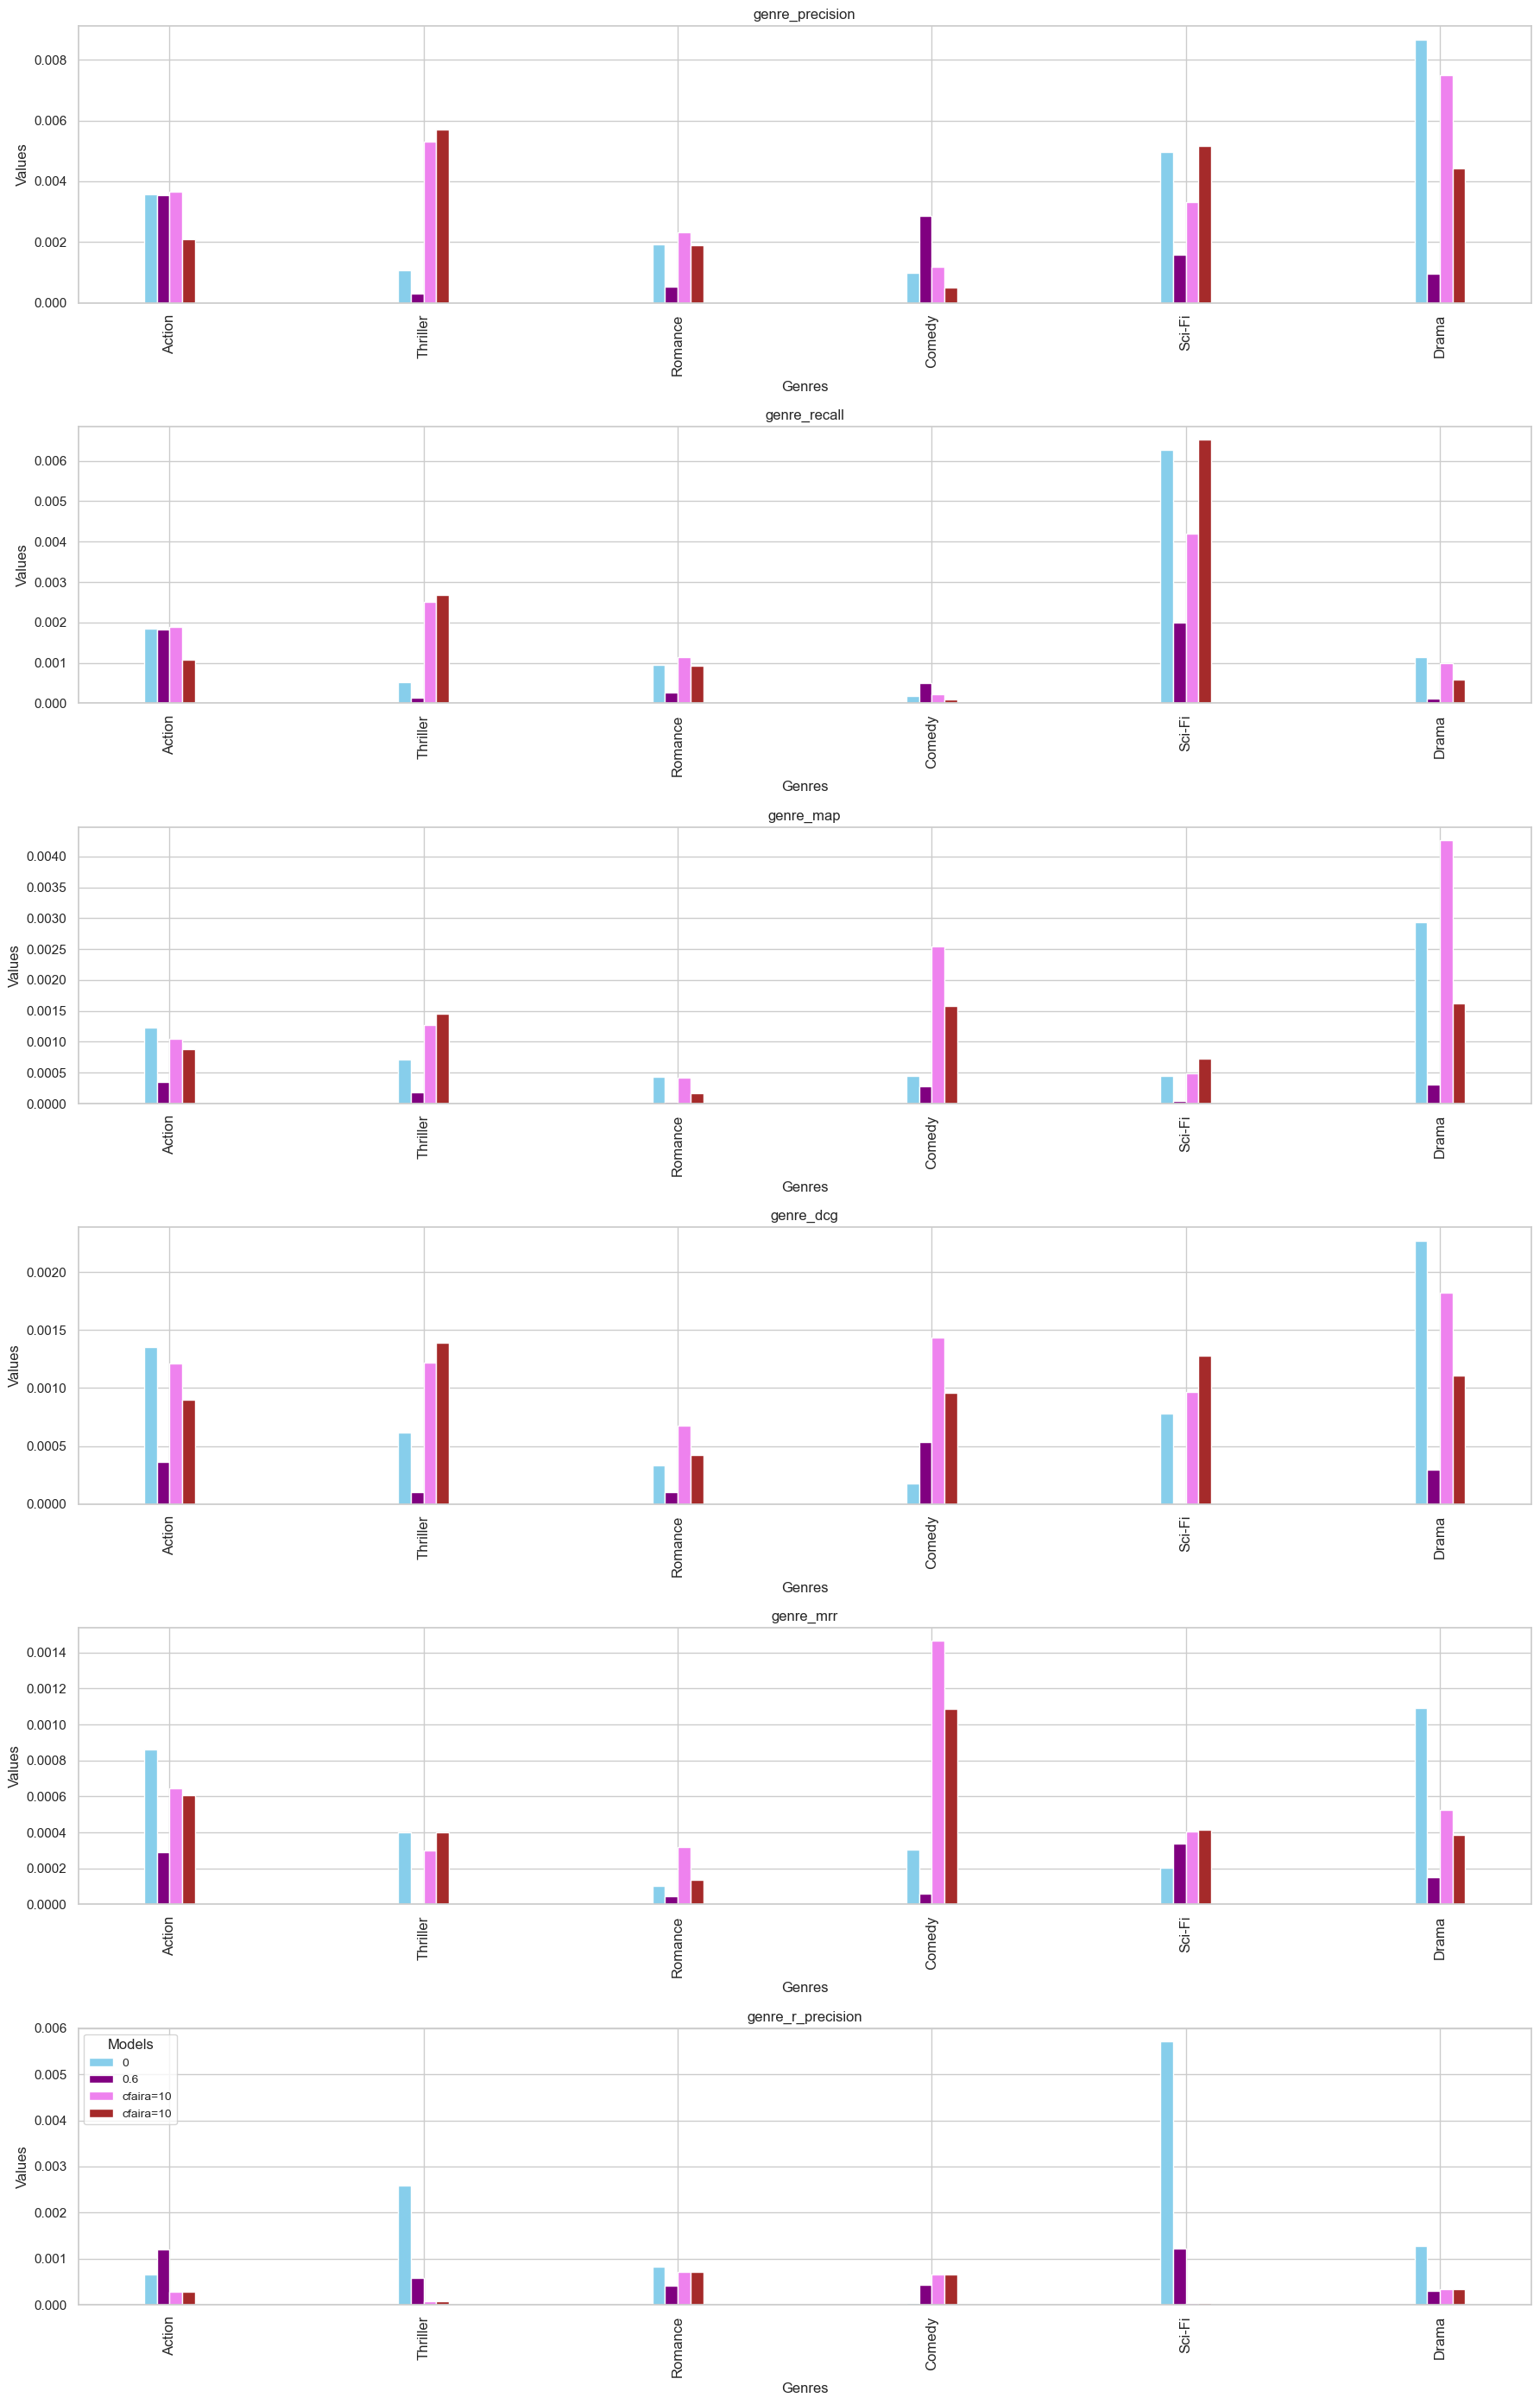

In [56]:


import matplotlib.pyplot as plt
import numpy as np


matrices = [
    model_gps[0][indices],
    model_grs[0][indices],
    model_gms[0][indices],
    model_gdcgs[0][indices],
    model_gmrrs[0][indices],
    model_grps[0][indices],
]
# matrices_2 = [
#     model_gps[1][indices],
#     model_grs[1][indices],
#     model_gms[1][indices],
#     model_gdcgs[1][indices],
#     model_gmrrs[1][indices],
#     model_grps[1][indices],
# ]
# matrices_3 = [
#     model_gps[2][indices],
#     model_grs[2][indices],
#     model_gms[2][indices],
#     model_gdcgs[2][indices],
#     model_gmrrs[2][indices],
#     model_grps[2][indices],
# ]
# matrices_4 = [
#     model_gps[3][indices],
#     model_grs[3][indices],
#     model_gms[3][indices],
#     model_gdcgs[3][indices],
#     model_gmrrs[3][indices],
#     model_grps[3][indices],
# ]
# matrices_5 = [
#     model_gps[4][indices],
#     model_grs[4][indices],
#     model_gms[4][indices],
#     model_gdcgs[4][indices],
#     model_gmrrs[4][indices],
#     model_grps[4][indices],
# ]
# matrices_6 = [
#     model_gps[5][indices],
#     model_grs[5][indices],
#     model_gms[5][indices],
#     model_gdcgs[5][indices],
#     model_gmrrs[5][indices],
#     model_grps[5][indices],
# ]
matrices_7 = [
    model_gps[6][indices],
    model_grs[6][indices],
    model_gms[6][indices],
    model_gdcgs[6][indices],
    model_gmrrs[6][indices],
    model_grps[6][indices],
]
# matrices_8 = [
#     model_gps[7][indices],
#     model_grs[7][indices],
#     model_gms[7][indices],
#     model_gdcgs[7][indices],
#     model_gmrrs[7][indices],
#     model_grps[7][indices],
# ]
# matrices_9 = [
#     model_gps[8][indices],
#     model_grs[8][indices],
#     model_gms[8][indices],
#     model_gdcgs[8][indices],
#     model_gmrrs[8][indices],
#     model_grps[8][indices],
# ]
# matrices_10 = [
#     model_gps[9][indices],
#     model_grs[9][indices],
#     model_gms[9][indices],
#     model_gdcgs[9][indices],
#     model_gmrrs[9][indices],
#     model_grps[9][indices],
# ]
# matrices_11 = [
#     model_gps[10][indices],
#     model_grs[10][indices],
#     model_gms[10][indices],
#     model_gdcgs[10][indices],
#     model_gmrrs[10][indices],
#     model_grps[10][indices],
# ]
# matrices_12 = [
#     cf_gp[indices],
#     cf_gr[indices],
#     cf_gm[indices],
#     cf_gndcg[indices],
#     cf_gmrr[indices],
#     model_grps[10][indices],
# ]
matrices_13 = [
    cf_gp[indices],
    cf_gr[indices],
    cf_gm[indices],
    cf_gndcg[indices],
    cf_gmrr[indices],
    model_grps[10][indices],
]
matrices_14 = [
    cf_gp_10[indices],
    cf_gr_10[indices],
    cf_gm_10[indices],
    cf_gndcg_10[indices],
    cf_gmrr_10[indices],
    model_grps[10][indices],
]



# matrices_2 = [
#     model_gp_2,
#     model_gr_2,
#     model_gm_2,
#     model_gdcg_2,
#     model_gmrr_2,
#     model_grp_2,
# ]
# matrices_3 = [
#     model_gp_3,
#     model_gr_3,
#     model_gm_3,
#     model_gdcg_3,
#     model_gmrr_3,
#     model_grp_3,
# ]

# values2 = matrices[1]
labels = compare_genres
# bar_width = 0.20
titles = [
    "genre_precision",
    "genre_recall",
    "genre_map",
    "genre_dcg",
    "genre_mrr",
    "genre_r_precision",
]


fig, axs = plt.subplots(6, 1, figsize=(18, 28))
axs = axs.flatten()
x = np.arange(len(compare_genres))  # the label locations
bar_width = 0.05  # the width of the bars
# rects1 = ax.bar(x - 3*bar_width/2, gender_genre_weights_topk_recom.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")


for i in range(len(titles)):
    axs[i].bar(
        x - 3 * bar_width / 2, abs(matrices[i]), bar_width, color="skyblue", label=alpha_values[0]
    )
    
    axs[i].bar(
        x -1 * bar_width / 2, abs(matrices_7[i]), bar_width, color="purple", label=alpha_values[6]
    )
    
    axs[i].bar(
        x + 1 * bar_width / 2, abs(matrices_13[i]), bar_width, color="violet", label="cfaira=10"
    )
    axs[i].bar(
        x + 3 * bar_width / 2, abs(matrices_14[i]), bar_width, color="brown", label="cfaira=10"
    )
    
    # axs[i].bar(x+2*bar_width/2, matrices_3[i], bar_width,color="green")
    # axs[i].bar(labels, matrices_2[i], color="skyblue")
    axs[i].set_xticks(x)
    axs[i].set_xticklabels(compare_genres, rotation=90, fontsize=12)

    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# plt.legend(loc='upper left', fontsize='small', title='Groups')

handles, labels = axs[0].get_legend_handles_labels()
print(labels)
print(handles)
plt.legend(handles, labels, loc="upper left", fontsize="small", title="Models")

# Adjust layout
plt.tight_layout()
plt.savefig("all_res.pdf" , format="pdf")
plt.show()

###################
# a*gender_loss + (1-a)*mseloss
# genderloss * batch_size * 25
###################

In [44]:
from operator import itemgetter

# unique_genres
indices = [0, 1, 2,9, 11, 17]
compare_genres = itemgetter(*indices)(unique_genres)
# compare_genres = unique_genres
# indices = range(18)
list(compare_genres)

['Action', 'Thriller', 'Romance', 'Comedy', 'Sci-Fi', 'Drama']

In [61]:
sum(abs(cf_gmrr) )> gmrr_sum

array([ True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True])

In [57]:
gp_sum

[0.03015047108778454,
 0.03223748291509486,
 0.034010172580321824,
 0.025276128514934482,
 0.030750919395695457,
 0.02456337725292949,
 0.015047578955041663,
 0.009851785030889534,
 0.008645020319647203,
 0.008493987935778956,
 0.006976698922967548]